>>> Loading Data...
>>> Analyzing Metrics: ['Mech Unc', 'Sem Unc', 'Confidence', 'Heuristic']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 COGNITIVE STATE REPORT (N=200)

CLUSTER 6: 💎 Standard Inference (100.0%)
Stats: Mech -2.3σ | Sem +0.0σ
--------------------------------------------------------------------------------
Size: 12 (6.0%)

METRIC STATISTICS:
  • Mech Unc       : Med:  0.032 (Glb: 0.052) | Mean:  0.032 | Std: 0.003 | 90%: [0.027 - 0.035]
  • Sem Unc        : Med:  0.000 (Glb: 0.000) | Mean:  0.042 | Std: 0.144 | 90%: [0.000 - 0.225]
  • Confidence     : Med:  0.089 (Glb: 0.089) | Mean:  0.126 | Std: 0.097 | 90%: [0.045 - 0.288]
  • Heuristic      : Med:  0.000 (Glb: 0.000) | Mean:  0.000 | Std: 0.000 | 90%: [0.000 - 0.000]

--------------------------------------------------------------------------------
 REPRESENTATIVE EXAMPLES
--------------------------------------------------------------------------------

[ARCHETYPE]
Q:     A car is driving 

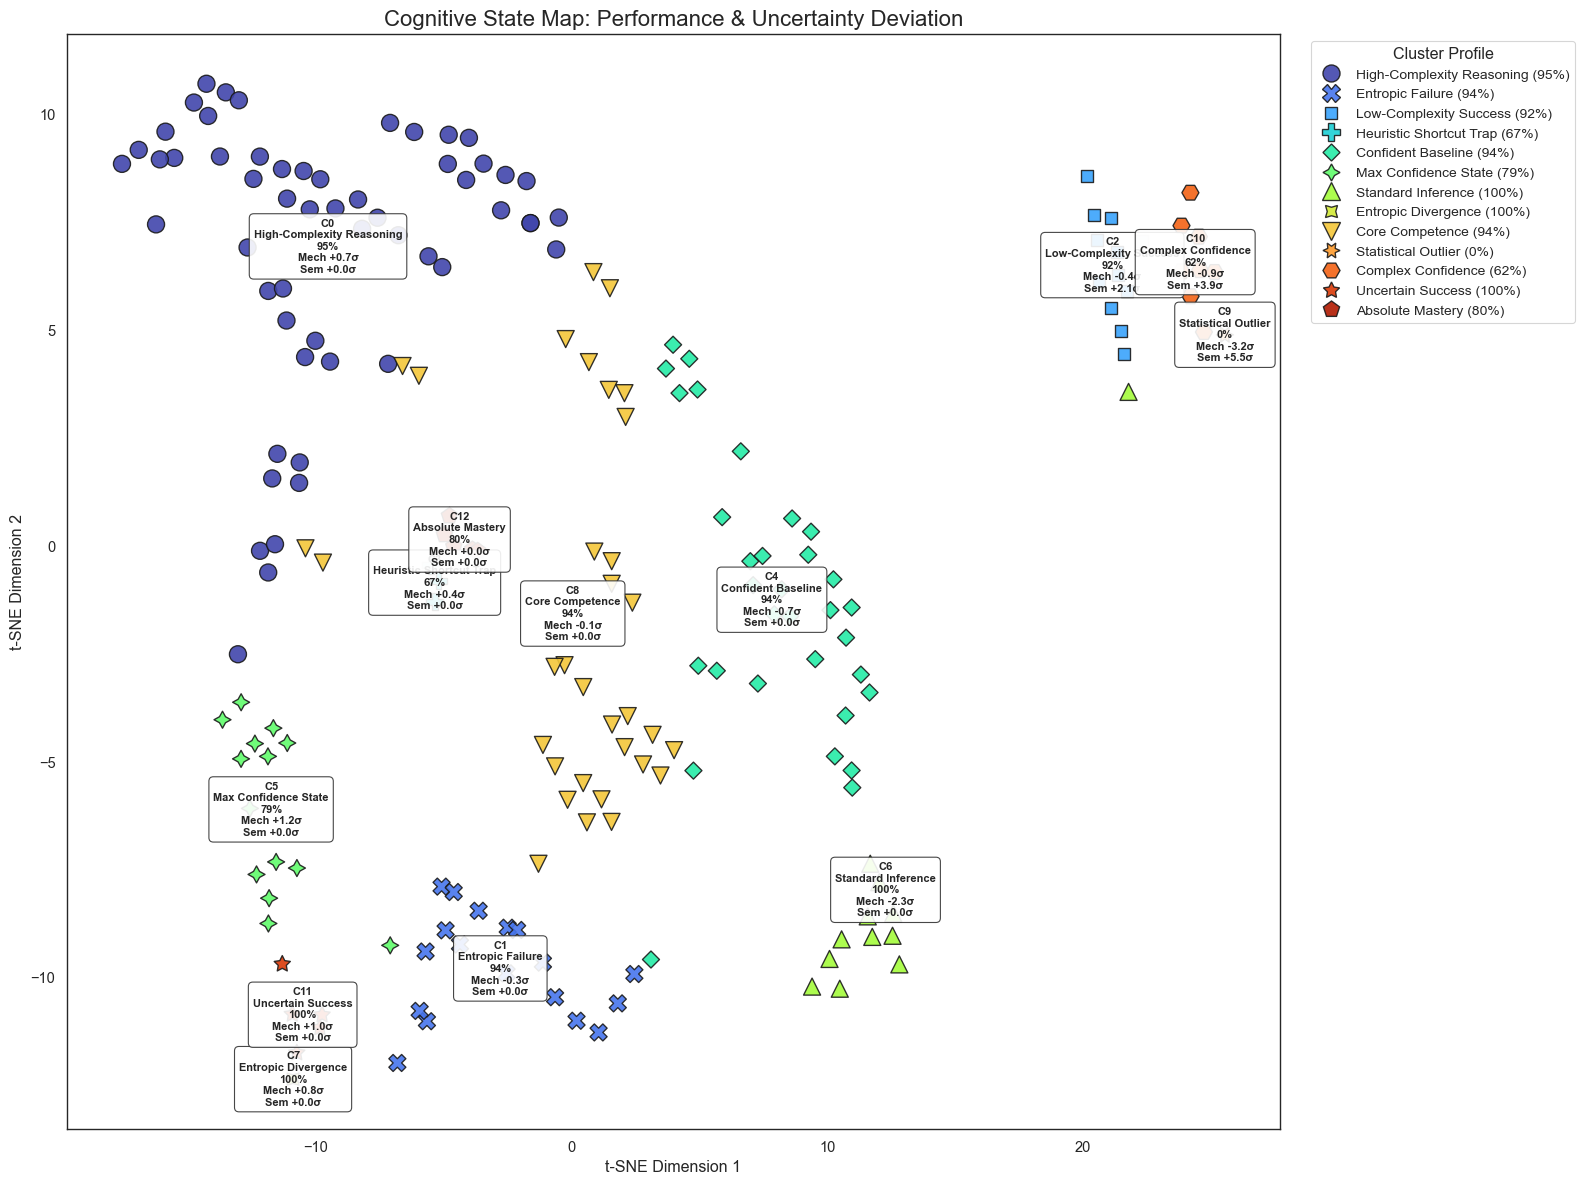

In [46]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  CONFIG: TAXONOMY & METRICS
# ==============================================================================
BASE_CLUSTER_NAMES = {
    0:  "High-Complexity Reasoning",    
    1:  "Entropic Failure",         
    2:  "Low-Complexity Success",       
    3:  "Heuristic Shortcut Trap",      
    4:  "Confident Baseline",           
    5:  "Max Confidence State",         
    6:  "Standard Inference",           
    7:  "Entropic Divergence",          
    8:  "Core Competence",              
    9:  "Statistical Outlier",          
    10: "Complex Confidence",           
    11: "Uncertain Success",            
    12: "Absolute Mastery"              
}

METRIC_MAP = {
    'uq_mech_score_RL': 'Mech Unc',
    'uq_semantic_entropy_RL': 'Sem Unc',
    'uq_min_logit_gap_RL': 'Confidence',
    'uq_heuristic_score_RL': 'Heuristic'
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_relative_z_string(val, global_med, global_std):
    if global_std == 0: return "+0.0σ"
    z = (val - global_med) / global_std
    return f"{z:+.1f}σ"

def get_stats_string(series, global_series):
    med_val = series.median()
    global_med = global_series.median()
    mean_val = series.mean()
    std_val = series.std()
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    return (f"Med: {med_val:6.3f} (Glb: {global_med:5.3f}) | "
            f"Mean: {mean_val:6.3f} | "
            f"Std: {std_val:5.3f} | "
            f"90%: [{p05:5.3f} - {p95:5.3f}]")

def wrap_text(text, width=80, indent="    "):
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        r_col = 'id' if 'id' in models.columns else ('model_id' if 'model_id' in models.columns else models.columns[0])
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_final_cluster_report():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics
    metrics = [k for k in METRIC_MAP.keys() if k in df.columns]
    print(f">>> Analyzing Metrics: {[METRIC_MAP[m] for m in metrics]}")
    
    # Global Stats
    global_stats = {}
    for m in metrics:
        global_stats[m] = {
            'median': df[m].median(),
            'std': df[m].std()
        }

    # 2. Clustering (Deterministic K=13)
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 3. Dynamic Metadata
    cluster_meta = {}
    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        acc = subset['is_correct_RL'].mean()
        base_name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        
        # Determine Icon
        if acc >= 0.95: icon = "💎"
        elif acc >= 0.85: icon = "✅"
        elif acc < 0.6: icon = "❌"
        elif "Trap" in base_name: icon = "🪤"
        else: icon = "⚠️"
        
        # Z-Scores for label
        mech_z = get_relative_z_string(subset['uq_mech_score_RL'].median(), 
                                      global_stats['uq_mech_score_RL']['median'], 
                                      global_stats['uq_mech_score_RL']['std'])
        sem_z = get_relative_z_string(subset['uq_semantic_entropy_RL'].median(), 
                                     global_stats['uq_semantic_entropy_RL']['median'], 
                                     global_stats['uq_semantic_entropy_RL']['std'])

        cluster_meta[cid] = {
            'name': base_name,
            'acc': acc,
            'icon': icon,
            'mech_z': mech_z,
            'sem_z': sem_z,
            'label': f"{base_name} ({acc:.0%})"
        }

    df['cluster_label'] = df['cluster'].apply(lambda x: cluster_meta[x]['label'])
    
    # 4. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  DETAILED STATISTICAL REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" COGNITIVE STATE REPORT (N={len(df)})")
    print("="*80)

    # Sort by accuracy
    sorted_cids = sorted(cluster_meta.keys(), key=lambda x: cluster_meta[x]['acc'], reverse=True)

    for cid in sorted_cids:
        meta = cluster_meta[cid]
        subset = df[df['cluster'] == cid]
        
        print(f"\nCLUSTER {cid}: {meta['icon']} {meta['name']} ({meta['acc']:.1%})")
        print(f"Stats: Mech {meta['mech_z']} | Sem {meta['sem_z']}")
        print(f"{'-'*80}")
        print(f"Size: {len(subset)} ({len(subset)/len(df):.1%})")
        
        print("\nMETRIC STATISTICS:")
        for m in metrics:
            readable = METRIC_MAP[m]
            stats_str = get_stats_string(subset[m], df[m])
            print(f"  • {readable:<15}: {stats_str}")
        
        print("\n" + "-"*80)
        print(" REPRESENTATIVE EXAMPLES")
        print("-" * 80)
        
        # 1. Archetype (Closest to Center)
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_idx = subset.index[closest[0]]
        
        # 2. Random Samples (to get up to 3 total)
        # Exclude archetype from random sample
        potential_others = subset.index.tolist()
        if archetype_idx in potential_others: potential_others.remove(archetype_idx)
        
        examples_to_show = [archetype_idx]
        if len(potential_others) > 0:
            others = np.random.choice(potential_others, size=min(2, len(potential_others)), replace=False)
            examples_to_show.extend(others)
            
        # PRINT LOOP
        for i, idx in enumerate(examples_to_show):
            row = df.loc[idx]
            role = "ARCHETYPE" if i == 0 else f"EXAMPLE {i}"
            
            print(f"\n[{role}]")
            print(f"Q: {wrap_text(row['final_text'])}")
            print(f"A: {wrap_text(row['ans_rl'])}")
            
            # Instance Metrics
            # Calculate local Z for this specific example
            z_strs = []
            for m in metrics:
                val = row[m]
                z_val = (val - global_stats[m]['median']) / (global_stats[m]['std'] + 1e-9)
                m_name = METRIC_MAP[m]
                z_strs.append(f"{m_name}: {val:.3f} ({z_val:+.1f}σ)")
            
            print(f"   >>> {' | '.join(z_strs)}")

        print(f"{'='*80}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(16, 12))
    df.sort_values(['cluster'], inplace=True)
    
    sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster_label',
        style='cluster_label', 
        palette='turbo', 
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    for cid in df['cluster'].unique():
        meta = cluster_meta[cid]
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        
        box_text = f"C{cid}\n{meta['name']}\n{meta['acc']:.0%}\nMech {meta['mech_z']}\nSem {meta['sem_z']}"
        
        plt.text(
            cx, cy, 
            box_text, 
            fontsize=8, 
            fontweight='bold', 
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='#333', boxstyle='round,pad=0.4')
        )

    plt.title("Cognitive State Map: Performance & Uncertainty Deviation", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster Profile", fontsize=10)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_cluster_report()

>>> Loading Data...
>>> Analyzing Metrics: ['Mech Unc', 'Sem Unc', 'Confidence', 'Heuristic']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 COGNITIVE STATE REPORT (N=200)

CLUSTER 6: Standard Inference (100.0%) [EXCELLENT]
Stats: Mech -2.3σ | Sem +0.0σ
--------------------------------------------------------------------------------
Size: 12 (6.0%)

METRIC STATISTICS:
  • Mech Unc       : Med:  0.032 (Glb: 0.052) | Mean:  0.032 | Std: 0.003 | 90%: [0.027 - 0.035]
  • Sem Unc        : Med:  0.000 (Glb: 0.000) | Mean:  0.042 | Std: 0.144 | 90%: [0.000 - 0.225]
  • Confidence     : Med:  0.089 (Glb: 0.089) | Mean:  0.126 | Std: 0.097 | 90%: [0.045 - 0.288]
  • Heuristic      : Med:  0.000 (Glb: 0.000) | Mean:  0.000 | Std: 0.000 | 90%: [0.000 - 0.000]

[ARCHETYPE Q]: A car is driving through a tunnel with many turns. After a while, the car must travel thro...
[ARCHETYPE A]: 10...

CLUSTER 7: Entropic Divergence (100.0%) [EXCELLENT]
Stats: Mech +0.8σ | Sem +0.0σ
-

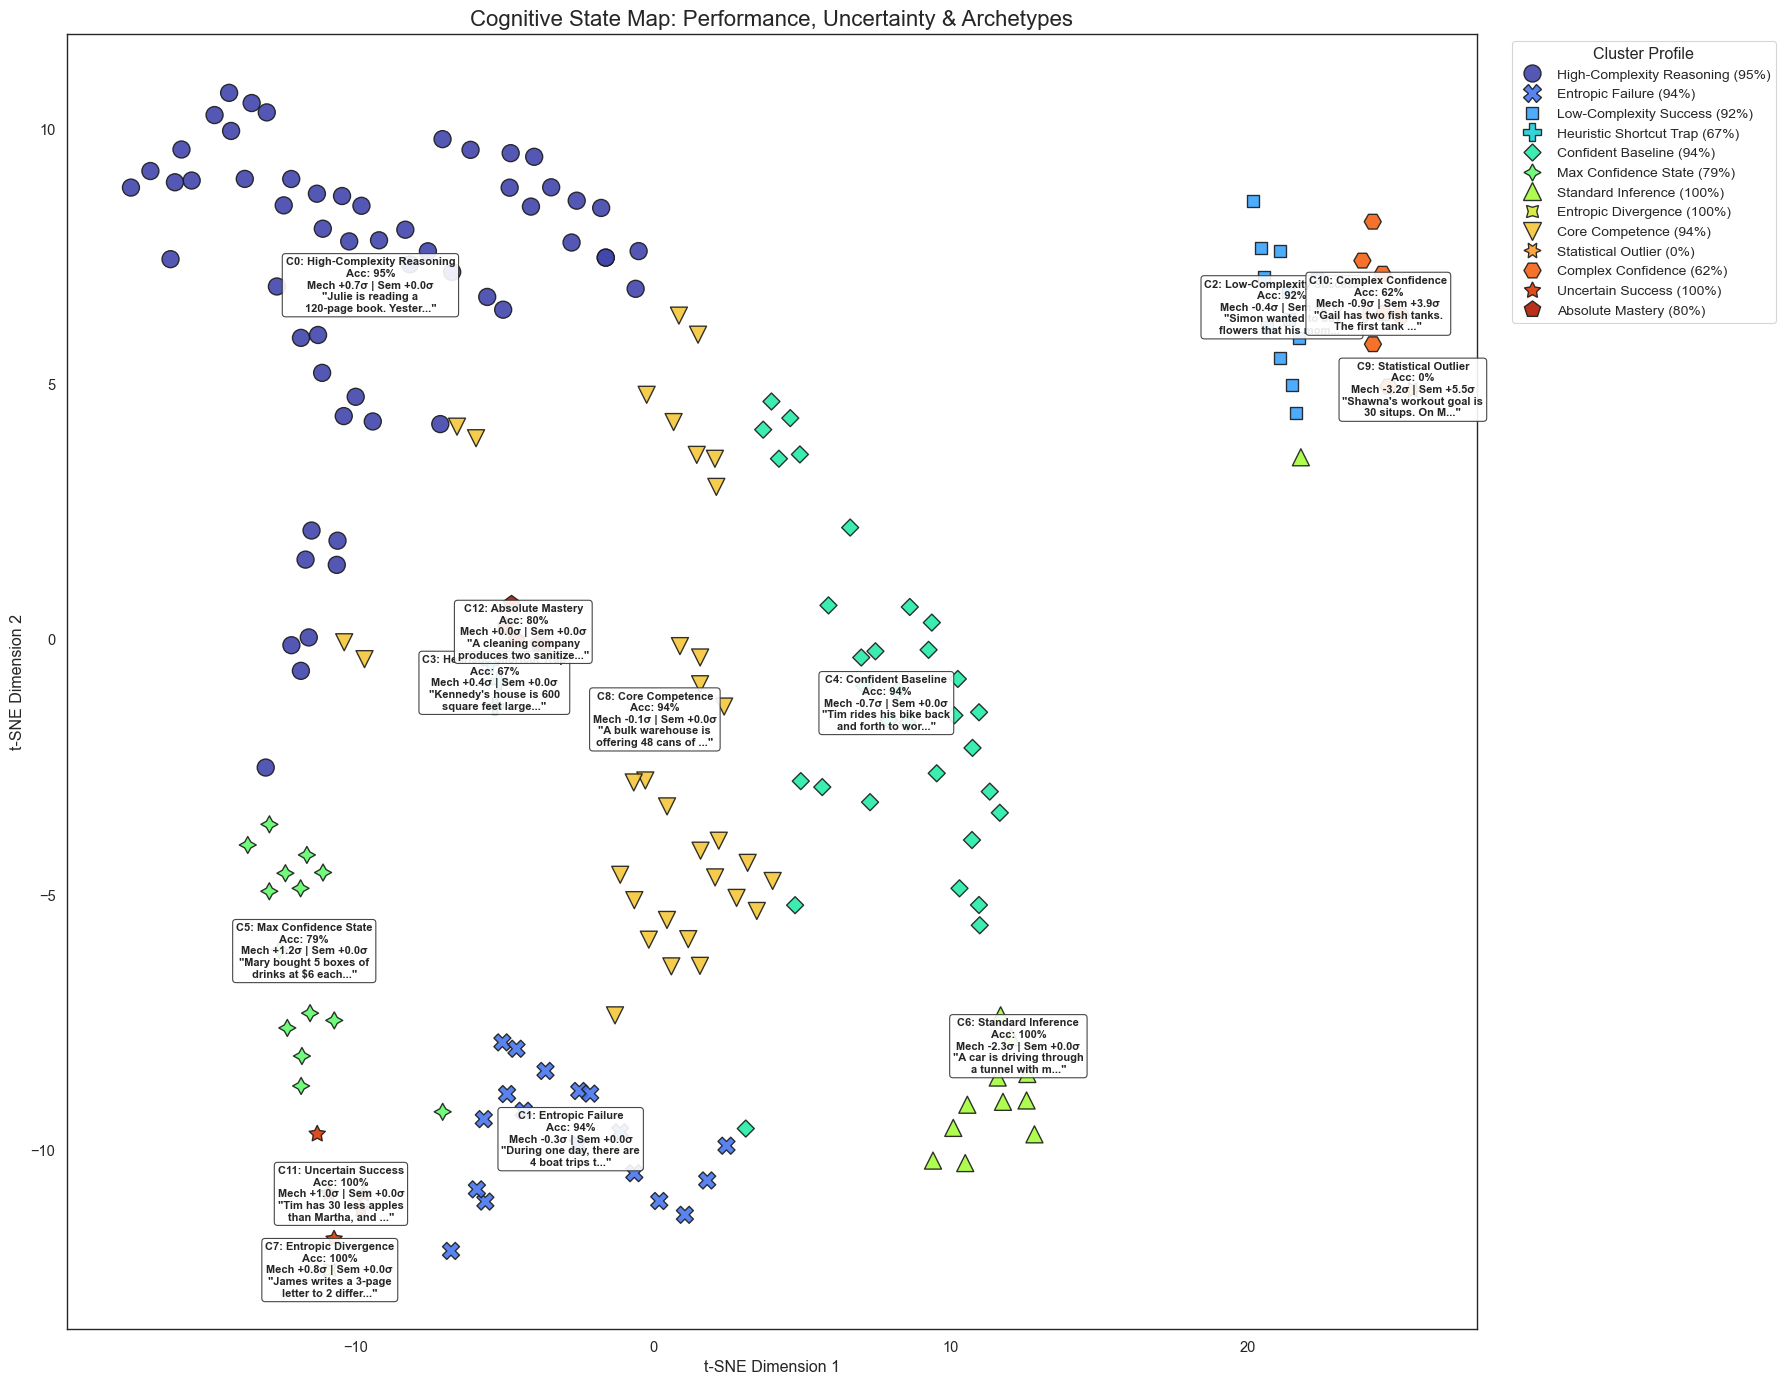

In [45]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  CONFIG: TAXONOMY & METRICS
# ==============================================================================
# Formal definitions based on K=13 (Seed=42)
BASE_CLUSTER_NAMES = {
    0:  "High-Complexity Reasoning",    
    1:  "Entropic Failure",         
    2:  "Low-Complexity Success",       
    3:  "Heuristic Shortcut Trap",      
    4:  "Confident Baseline",           
    5:  "Max Confidence State",         
    6:  "Standard Inference",           
    7:  "Entropic Divergence",          
    8:  "Core Competence",              
    9:  "Statistical Outlier",          
    10: "Complex Confidence",           
    11: "Uncertain Success",            
    12: "Absolute Mastery"              
}

METRIC_MAP = {
    'uq_mech_score_RL': 'Mech Unc',
    'uq_semantic_entropy_RL': 'Sem Unc',
    'uq_min_logit_gap_RL': 'Confidence',
    'uq_heuristic_score_RL': 'Heuristic'
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_relative_z_string(cluster_median, global_median, global_std):
    if global_std == 0: return "+0.0σ"
    z = (cluster_median - global_median) / global_std
    return f"{z:+.1f}σ"

def get_stats_string(series, global_series):
    med_val = series.median()
    global_med = global_series.median()
    mean_val = series.mean()
    std_val = series.std()
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    
    return (f"Med: {med_val:6.3f} (Glb: {global_med:5.3f}) | "
            f"Mean: {mean_val:6.3f} | "
            f"Std: {std_val:5.3f} | "
            f"90%: [{p05:5.3f} - {p95:5.3f}]")

def wrap_text(text, width=80, indent="    "):
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        r_col = 'id' if 'id' in models.columns else ('model_id' if 'model_id' in models.columns else models.columns[0])
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_final_cluster_report():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics
    metrics = [k for k in METRIC_MAP.keys() if k in df.columns]
    print(f">>> Analyzing Metrics: {[METRIC_MAP[m] for m in metrics]}")
    
    # Calculate Global Stats
    global_stats = {}
    for m in metrics:
        global_stats[m] = {
            'median': df[m].median(),
            'std': df[m].std()
        }

    # 2. Clustering (Deterministic K=13)
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 3. Dynamic Metadata Generation
    cluster_meta = {}
    
    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        acc = subset['is_correct_RL'].mean()
        base_name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        
        # Calculate Z-Scores for Label
        mech_z = get_relative_z_string(subset['uq_mech_score_RL'].median(), 
                                      global_stats['uq_mech_score_RL']['median'], 
                                      global_stats['uq_mech_score_RL']['std'])
        sem_z = get_relative_z_string(subset['uq_semantic_entropy_RL'].median(), 
                                     global_stats['uq_semantic_entropy_RL']['median'], 
                                     global_stats['uq_semantic_entropy_RL']['std'])
        
        # Determine Status (No Emojis)
        if acc >= 0.95: status = "EXCELLENT"
        elif acc >= 0.85: status = "GOOD"
        elif acc < 0.6: status = "FAILURE"
        elif "Trap" in base_name: status = "RISK"
        else: status = "MIXED"
        
        # Find Archetype Text
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]
        archetype_text = str(archetype_row['final_text'])
        
        cluster_meta[cid] = {
            'name': base_name,
            'acc': acc,
            'status': status,
            'mech_z': mech_z,
            'sem_z': sem_z,
            'label': f"{base_name} ({acc:.0%})",
            'archetype_text': archetype_text
        }

    df['cluster_label'] = df['cluster'].apply(lambda x: cluster_meta[x]['label'])
    
    # 4. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  DETAILED STATISTICAL REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" COGNITIVE STATE REPORT (N={len(df)})")
    print("="*80)

    sorted_cids = sorted(cluster_meta.keys(), key=lambda x: cluster_meta[x]['acc'], reverse=True)

    for cid in sorted_cids:
        meta = cluster_meta[cid]
        subset = df[df['cluster'] == cid]
        
        # Find Archetype for print (already calculated in meta, but re-fetching row for answer)
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]

        print(f"\nCLUSTER {cid}: {meta['name']} ({meta['acc']:.1%}) [{meta['status']}]")
        print(f"Stats: Mech {meta['mech_z']} | Sem {meta['sem_z']}")
        print(f"{'-'*80}")
        print(f"Size: {len(subset)} ({len(subset)/len(df):.1%})")
        
        print("\nMETRIC STATISTICS:")
        for m in metrics:
            readable = METRIC_MAP[m]
            stats_str = get_stats_string(subset[m], df[m])
            print(f"  • {readable:<15}: {stats_str}")
            
        print(f"\n[ARCHETYPE Q]: {str(archetype_row['final_text'])[:90]}...")
        print(f"[ARCHETYPE A]: {str(archetype_row['ans_rl'])[:90]}...")
        print(f"{'='*80}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(18, 14))
    
    df.sort_values(['cluster'], inplace=True)
    
    sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster_label',
        style='cluster_label', 
        palette='turbo', 
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Centers
    for cid in df['cluster'].unique():
        meta = cluster_meta[cid]
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        
        # Prepare Archetype Snippet (Truncated)
        q_snip = meta['archetype_text'][:40] + "..." if len(meta['archetype_text']) > 40 else meta['archetype_text']
        q_snip = "\n".join(textwrap.wrap(q_snip, 25)) # Wrap tightly for box
        
        box_text = (f"C{cid}: {meta['name']}\n"
                    f"Acc: {meta['acc']:.0%}\n"
                    f"Mech {meta['mech_z']} | Sem {meta['sem_z']}\n"
                    f"\"{q_snip}\"")
        
        plt.text(
            cx, cy, 
            box_text, 
            fontsize=8, 
            fontweight='bold', 
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='#333', boxstyle='round,pad=0.3')
        )

    plt.title("Cognitive State Map: Performance, Uncertainty & Archetypes", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster Profile", fontsize=10)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_cluster_report()

>>> Loading Data...
>>> Analyzing Metrics: ['Mech Unc', 'Sem Unc', 'Confidence', 'Heuristic']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 COGNITIVE STATE REPORT (N=200)

CLUSTER 6: 💎 Standard Inference (100.0%)
Stats: Mech Unc: -2.3σ | Sem Unc: +0.0σ | Confidence: +0.0σ | Heuristic: +0.0σ
--------------------------------------------------------------------------------
Size: 12 (6.0%)

METRIC STATISTICS:
  • Mech Unc       : Med:  0.032 (Glb: 0.052) | Mean:  0.032 | Std: 0.003 | 90%: [0.027 - 0.035]
  • Sem Unc        : Med:  0.000 (Glb: 0.000) | Mean:  0.042 | Std: 0.144 | 90%: [0.000 - 0.225]
  • Confidence     : Med:  0.089 (Glb: 0.089) | Mean:  0.126 | Std: 0.097 | 90%: [0.045 - 0.288]
  • Heuristic      : Med:  0.000 (Glb: 0.000) | Mean:  0.000 | Std: 0.000 | 90%: [0.000 - 0.000]

[ARCHETYPE Q]: A car is driving through a tunnel with many turns. After a while, the car must travel thro...
[ARCHETYPE A]: 10...

CLUSTER 7: 💎 Entropic Divergence (100.0%)
St

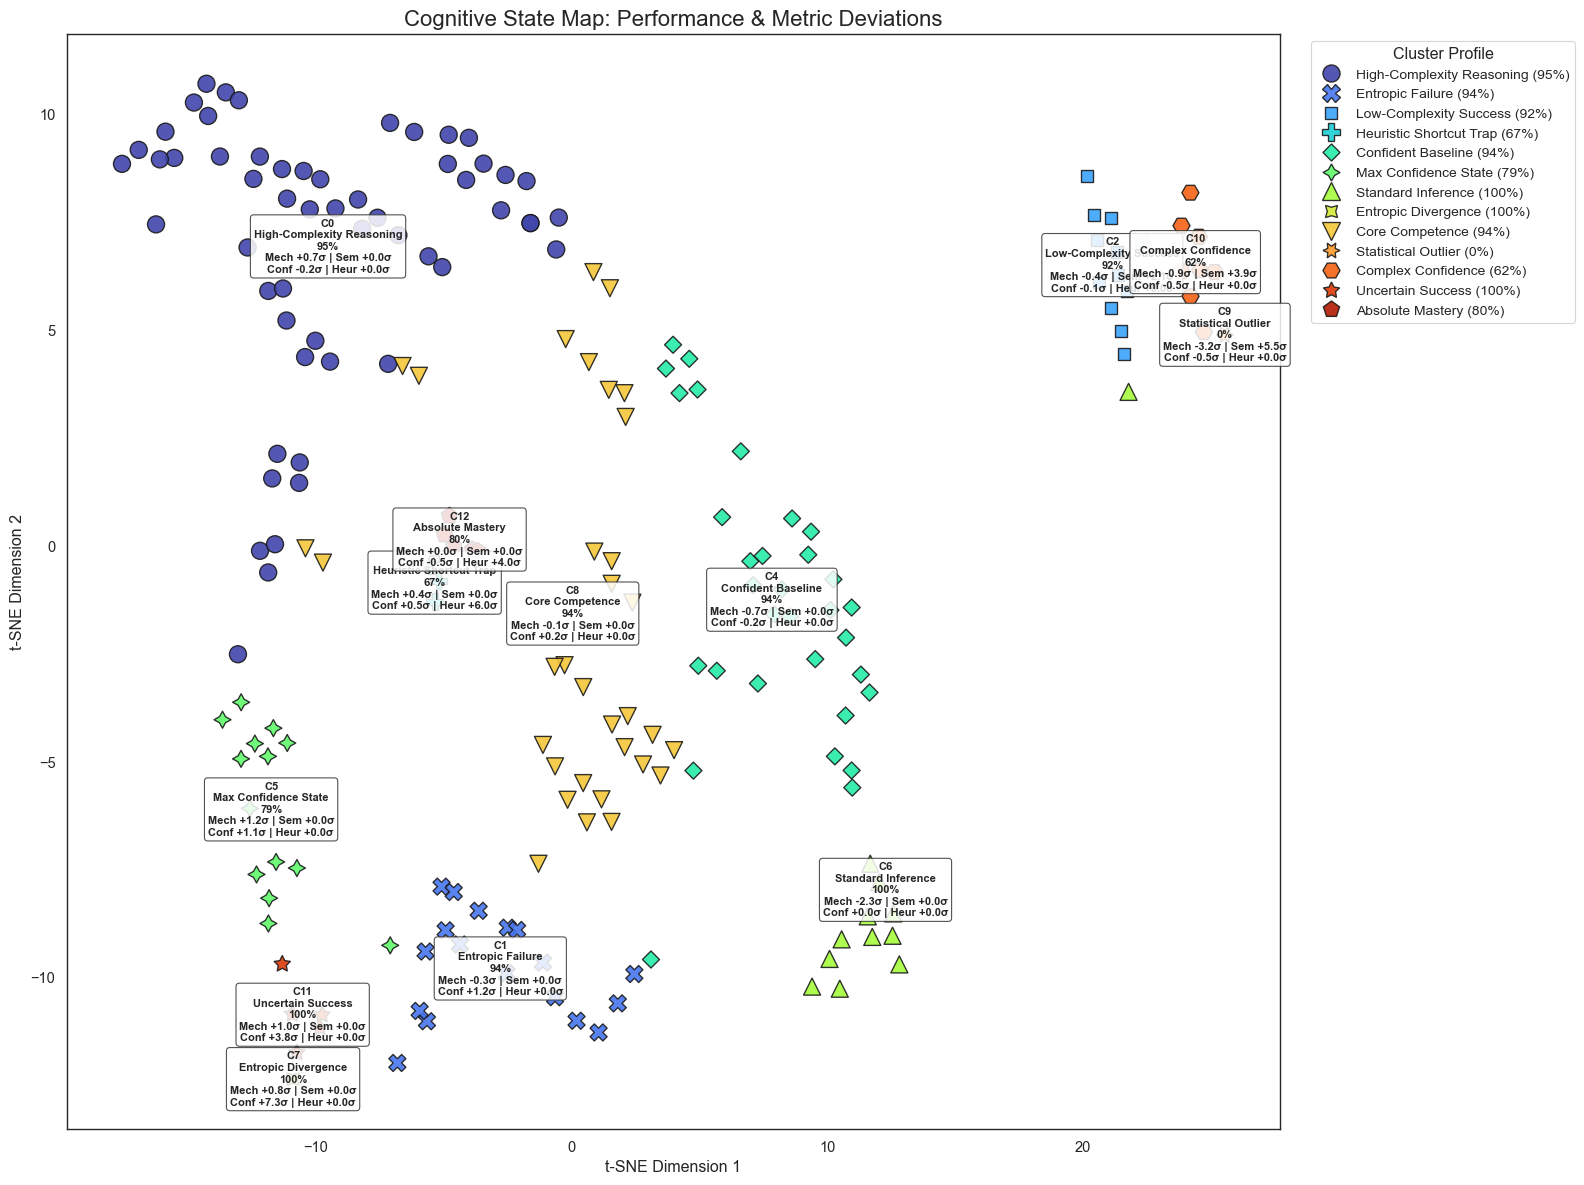

In [44]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  CONFIG: TAXONOMY & METRICS
# ==============================================================================
BASE_CLUSTER_NAMES = {
    0:  "High-Complexity Reasoning",    
    1:  "Entropic Failure",         
    2:  "Low-Complexity Success",       
    3:  "Heuristic Shortcut Trap",      
    4:  "Confident Baseline",           
    5:  "Max Confidence State",         
    6:  "Standard Inference",           
    7:  "Entropic Divergence",          
    8:  "Core Competence",              
    9:  "Statistical Outlier",          
    10: "Complex Confidence",           
    11: "Uncertain Success",            
    12: "Absolute Mastery"              
}

METRIC_MAP = {
    'uq_mech_score_RL': 'Mech Unc',
    'uq_semantic_entropy_RL': 'Sem Unc',
    'uq_min_logit_gap_RL': 'Confidence',
    'uq_heuristic_score_RL': 'Heuristic'
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_relative_z_string(cluster_median, global_median, global_std):
    if global_std == 0: return "+0.0σ"
    z = (cluster_median - global_median) / global_std
    return f"{z:+.1f}σ"

def get_stats_string(series, global_series):
    med_val = series.median()
    global_med = global_series.median()
    mean_val = series.mean()
    std_val = series.std()
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    
    return (f"Med: {med_val:6.3f} (Glb: {global_med:5.3f}) | "
            f"Mean: {mean_val:6.3f} | "
            f"Std: {std_val:5.3f} | "
            f"90%: [{p05:5.3f} - {p95:5.3f}]")

def wrap_text(text, width=80, indent="    "):
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        r_col = 'id' if 'id' in models.columns else ('model_id' if 'model_id' in models.columns else models.columns[0])
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_final_cluster_report():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics
    metrics = [k for k in METRIC_MAP.keys() if k in df.columns]
    print(f">>> Analyzing Metrics: {[METRIC_MAP[m] for m in metrics]}")
    
    # Calculate Global Stats
    global_stats = {}
    for m in metrics:
        global_stats[m] = {
            'median': df[m].median(),
            'std': df[m].std()
        }

    # 2. Clustering (Deterministic K=13)
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 3. Dynamic Metadata Generation
    cluster_meta = {}
    
    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        acc = subset['is_correct_RL'].mean()
        base_name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        
        # Calculate Z-Scores for ALL Metrics
        z_scores = {}
        for m in metrics:
            short_name = METRIC_MAP[m].split(' ')[0] # Get first word for compactness
            z_str = get_relative_z_string(subset[m].median(), 
                                          global_stats[m]['median'], 
                                          global_stats[m]['std'])
            z_scores[m] = z_str
        
        # Determine Icon
        if acc >= 0.95: icon = "💎"
        elif acc >= 0.85: icon = "✅"
        elif acc < 0.6: icon = "❌"
        elif "Trap" in base_name: icon = "🪤"
        else: icon = "⚠️"
        
        cluster_meta[cid] = {
            'name': base_name,
            'acc': acc,
            'icon': icon,
            'z_scores': z_scores,
            'label': f"{base_name} ({acc:.0%})"
        }

    df['cluster_label'] = df['cluster'].apply(lambda x: cluster_meta[x]['label'])
    
    # 4. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  DETAILED STATISTICAL REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" COGNITIVE STATE REPORT (N={len(df)})")
    print("="*80)

    # Sort by accuracy for readability
    sorted_cids = sorted(cluster_meta.keys(), key=lambda x: cluster_meta[x]['acc'], reverse=True)

    for cid in sorted_cids:
        meta = cluster_meta[cid]
        subset = df[df['cluster'] == cid]
        
        # Find Archetype
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]

        print(f"\nCLUSTER {cid}: {meta['icon']} {meta['name']} ({meta['acc']:.1%})")
        
        # Print all Z-scores inline
        z_str_list = [f"{METRIC_MAP[m]}: {meta['z_scores'][m]}" for m in metrics]
        print(f"Stats: {' | '.join(z_str_list)}")
        print(f"{'-'*80}")
        print(f"Size: {len(subset)} ({len(subset)/len(df):.1%})")
        
        print("\nMETRIC STATISTICS:")
        for m in metrics:
            readable = METRIC_MAP[m]
            stats_str = get_stats_string(subset[m], df[m])
            print(f"  • {readable:<15}: {stats_str}")
            
        print(f"\n[ARCHETYPE Q]: {str(archetype_row['final_text'])[:90]}...")
        print(f"[ARCHETYPE A]: {str(archetype_row['ans_rl'])[:90]}...")
        print(f"{'='*80}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(16, 12))
    
    # Sort for legend consistency
    df.sort_values(['cluster'], inplace=True)
    
    sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster_label',
        style='cluster_label', 
        palette='turbo', 
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Centers
    for cid in df['cluster'].unique():
        meta = cluster_meta[cid]
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        
        # Build compact multi-line label for plot
        # C0
        # Name
        # Acc
        # Mech +Z | Sem +Z
        # Conf +Z | Heur +Z
        
        # Extract Zs
        mech_z = meta['z_scores'].get('uq_mech_score_RL', 'N/A')
        sem_z = meta['z_scores'].get('uq_semantic_entropy_RL', 'N/A')
        conf_z = meta['z_scores'].get('uq_min_logit_gap_RL', 'N/A')
        heur_z = meta['z_scores'].get('uq_heuristic_score_RL', 'N/A')
        
        box_text = (f"C{cid}\n{meta['name']}\n{meta['acc']:.0%}\n"
                    f"Mech {mech_z} | Sem {sem_z}\n"
                    f"Conf {conf_z} | Heur {heur_z}")
        
        plt.text(
            cx, cy, 
            box_text, 
            fontsize=8, 
            fontweight='bold', 
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='#333', boxstyle='round,pad=0.3')
        )

    plt.title("Cognitive State Map: Performance & Metric Deviations", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster Profile", fontsize=10)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_cluster_report()

>>> Loading Data...
>>> Analyzing Metrics: ['Mech Unc', 'Sem Unc', 'Confidence', 'Heuristic']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 COGNITIVE STATE REPORT (N=200)

CLUSTER 6: 💎 Standard Inference (100.0%)
Stats: Mech: -2.3σ | Sem: +0.0σ
--------------------------------------------------------------------------------
Size: 12 (6.0%)

METRIC STATISTICS:
  • Mech Unc       : Med:  0.032 (Glb: 0.052) | Mean:  0.032 | Std: 0.003 | 90%: [0.027 - 0.035]
  • Sem Unc        : Med:  0.000 (Glb: 0.000) | Mean:  0.042 | Std: 0.144 | 90%: [0.000 - 0.225]
  • Confidence     : Med:  0.089 (Glb: 0.089) | Mean:  0.126 | Std: 0.097 | 90%: [0.045 - 0.288]
  • Heuristic      : Med:  0.000 (Glb: 0.000) | Mean:  0.000 | Std: 0.000 | 90%: [0.000 - 0.000]

[ARCHETYPE Q]: A car is driving through a tunnel with many turns. After a while, the car must travel thro...
[ARCHETYPE A]: 10...

CLUSTER 7: 💎 Entropic Divergence (100.0%)
Stats: Mech: +0.8σ | Sem: +0.0σ
-----------------

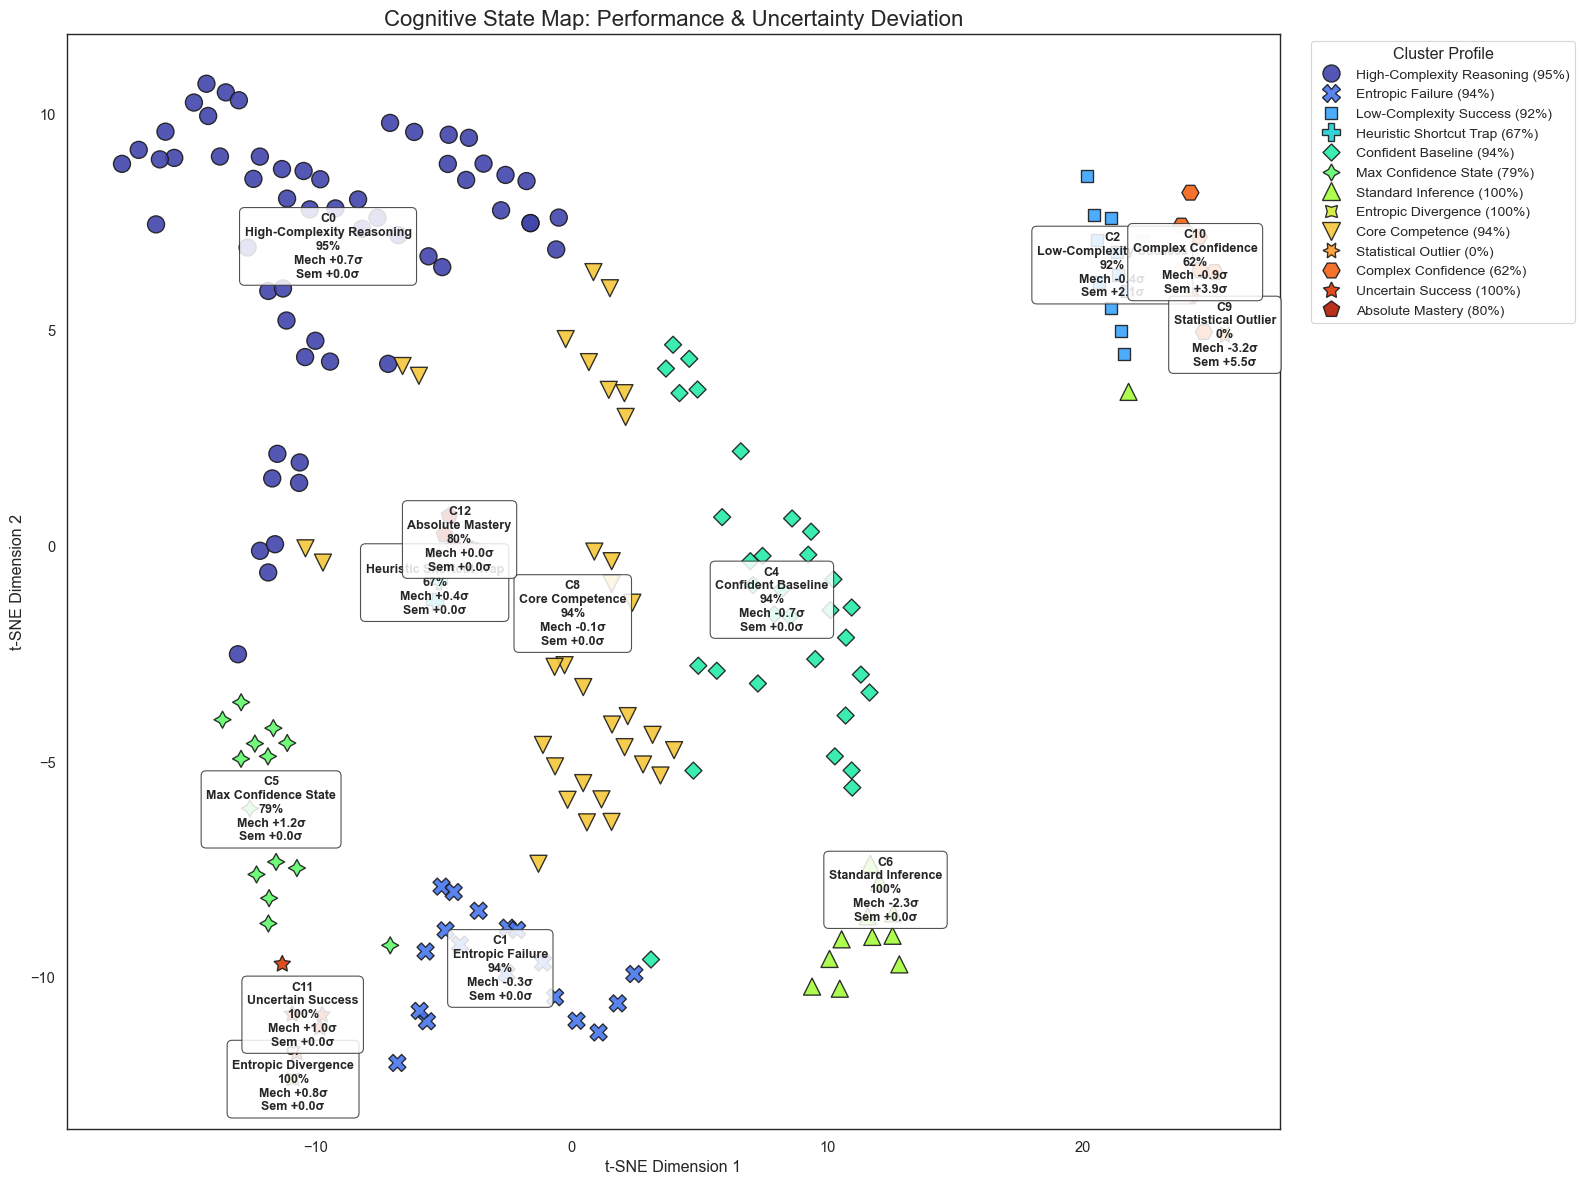

In [43]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  CONFIG: TAXONOMY & METRICS
# ==============================================================================
# Base names for the 13-cluster logic (Seed=42)
BASE_CLUSTER_NAMES = {
    0:  "High-Complexity Reasoning",    
    1:  "Entropic Failure",         
    2:  "Low-Complexity Success",       
    3:  "Heuristic Shortcut Trap",      
    4:  "Confident Baseline",           
    5:  "Max Confidence State",         
    6:  "Standard Inference",           
    7:  "Entropic Divergence",          
    8:  "Core Competence",              
    9:  "Statistical Outlier",          
    10: "Complex Confidence",           
    11: "Uncertain Success",            
    12: "Absolute Mastery"              
}

METRIC_MAP = {
    'uq_mech_score_RL': 'Mech Unc',
    'uq_semantic_entropy_RL': 'Sem Unc',
    'uq_min_logit_gap_RL': 'Confidence',
    'uq_heuristic_score_RL': 'Heuristic'
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_relative_z_string(cluster_median, global_median, global_std):
    if global_std == 0: return "+0.0σ"
    z = (cluster_median - global_median) / global_std
    return f"{z:+.1f}σ"

def get_stats_string(series, global_series):
    """
    Returns formatted stats: Med (Global) | Mean | Std | 90% Range
    """
    med_val = series.median()
    global_med = global_series.median()
    mean_val = series.mean()
    std_val = series.std()
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    
    return (f"Med: {med_val:6.3f} (Glb: {global_med:5.3f}) | "
            f"Mean: {mean_val:6.3f} | "
            f"Std: {std_val:5.3f} | "
            f"90%: [{p05:5.3f} - {p95:5.3f}]")

def wrap_text(text, width=80, indent="    "):
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        r_col = 'id' if 'id' in models.columns else ('model_id' if 'model_id' in models.columns else models.columns[0])
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_final_cluster_report():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics
    metrics = [k for k in METRIC_MAP.keys() if k in df.columns]
    print(f">>> Analyzing Metrics: {[METRIC_MAP[m] for m in metrics]}")
    
    # Calculate Global Stats
    global_stats = {}
    for m in metrics:
        global_stats[m] = {
            'median': df[m].median(),
            'std': df[m].std()
        }

    # 2. Clustering (Deterministic K=13)
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 3. Dynamic Metadata Generation
    cluster_meta = {}
    
    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        acc = subset['is_correct_RL'].mean()
        base_name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        
        # Calculate Z-Scores for Label
        mech_z = get_relative_z_string(subset['uq_mech_score_RL'].median(), 
                                      global_stats['uq_mech_score_RL']['median'], 
                                      global_stats['uq_mech_score_RL']['std'])
        sem_z = get_relative_z_string(subset['uq_semantic_entropy_RL'].median(), 
                                     global_stats['uq_semantic_entropy_RL']['median'], 
                                     global_stats['uq_semantic_entropy_RL']['std'])
        
        # Determine Icon
        if acc >= 0.95: icon = "💎"
        elif acc >= 0.85: icon = "✅"
        elif acc < 0.6: icon = "❌"
        elif "Trap" in base_name: icon = "🪤"
        else: icon = "⚠️"
        
        cluster_meta[cid] = {
            'name': base_name,
            'acc': acc,
            'icon': icon,
            'mech_z': mech_z,
            'sem_z': sem_z,
            'label': f"{base_name} ({acc:.0%})"
        }

    df['cluster_label'] = df['cluster'].apply(lambda x: cluster_meta[x]['label'])
    
    # 4. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  DETAILED STATISTICAL REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" COGNITIVE STATE REPORT (N={len(df)})")
    print("="*80)

    # Sort by accuracy for readability
    sorted_cids = sorted(cluster_meta.keys(), key=lambda x: cluster_meta[x]['acc'], reverse=True)

    for cid in sorted_cids:
        meta = cluster_meta[cid]
        subset = df[df['cluster'] == cid]
        
        # Find Archetype
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]

        print(f"\nCLUSTER {cid}: {meta['icon']} {meta['name']} ({meta['acc']:.1%})")
        print(f"Stats: Mech: {meta['mech_z']} | Sem: {meta['sem_z']}")
        print(f"{'-'*80}")
        print(f"Size: {len(subset)} ({len(subset)/len(df):.1%})")
        
        print("\nMETRIC STATISTICS:")
        for m in metrics:
            readable = METRIC_MAP[m]
            stats_str = get_stats_string(subset[m], df[m])
            print(f"  • {readable:<15}: {stats_str}")
            
        print(f"\n[ARCHETYPE Q]: {str(archetype_row['final_text'])[:90]}...")
        print(f"[ARCHETYPE A]: {str(archetype_row['ans_rl'])[:90]}...")
        print(f"{'='*80}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(16, 12))
    
    # Sort for legend consistency
    df.sort_values(['cluster'], inplace=True)
    
    sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster_label',
        style='cluster_label', 
        palette='turbo', 
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Centers
    for cid in df['cluster'].unique():
        meta = cluster_meta[cid]
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        
        box_text = f"C{cid}\n{meta['name']}\n{meta['acc']:.0%}\nMech {meta['mech_z']}\nSem {meta['sem_z']}"
        
        plt.text(
            cx, cy, 
            box_text, 
            fontsize=9, 
            fontweight='bold', 
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='#333', boxstyle='round,pad=0.4')
        )

    plt.title("Cognitive State Map: Performance & Uncertainty Deviation", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster Profile", fontsize=10)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_cluster_report()

>>> Loading Data...
>>> Analyzing Metrics: ['Mech Unc', 'Sem Unc', 'Confidence', 'Heuristic']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 COGNITIVE STATE REPORT (N=200)

CLUSTER 6: 💎 Standard Reasoning (100.0%)
Stats: Mech: -2.3σ | Sem: +0.0σ
--------------------------------------------------------------------------------
Size: 12 (6.0%)

METRIC STATISTICS:
  • Mech Unc       : Med:  0.032 (Glb: 0.052) | Mean:  0.032 | Std: 0.003 | 90%: [0.027 - 0.035]
  • Sem Unc        : Med:  0.000 (Glb: 0.000) | Mean:  0.042 | Std: 0.144 | 90%: [0.000 - 0.225]
  • Confidence     : Med:  0.089 (Glb: 0.089) | Mean:  0.126 | Std: 0.097 | 90%: [0.045 - 0.288]
  • Heuristic      : Med:  0.000 (Glb: 0.000) | Mean:  0.000 | Std: 0.000 | 90%: [0.000 - 0.000]

[ARCHETYPE Q]: A car is driving through a tunnel with many turns. After a while, the car must travel thro...
[ARCHETYPE A]: 10...

CLUSTER 7: 💎 Entropic Success (100.0%)
Stats: Mech: +0.8σ | Sem: +0.0σ
--------------------

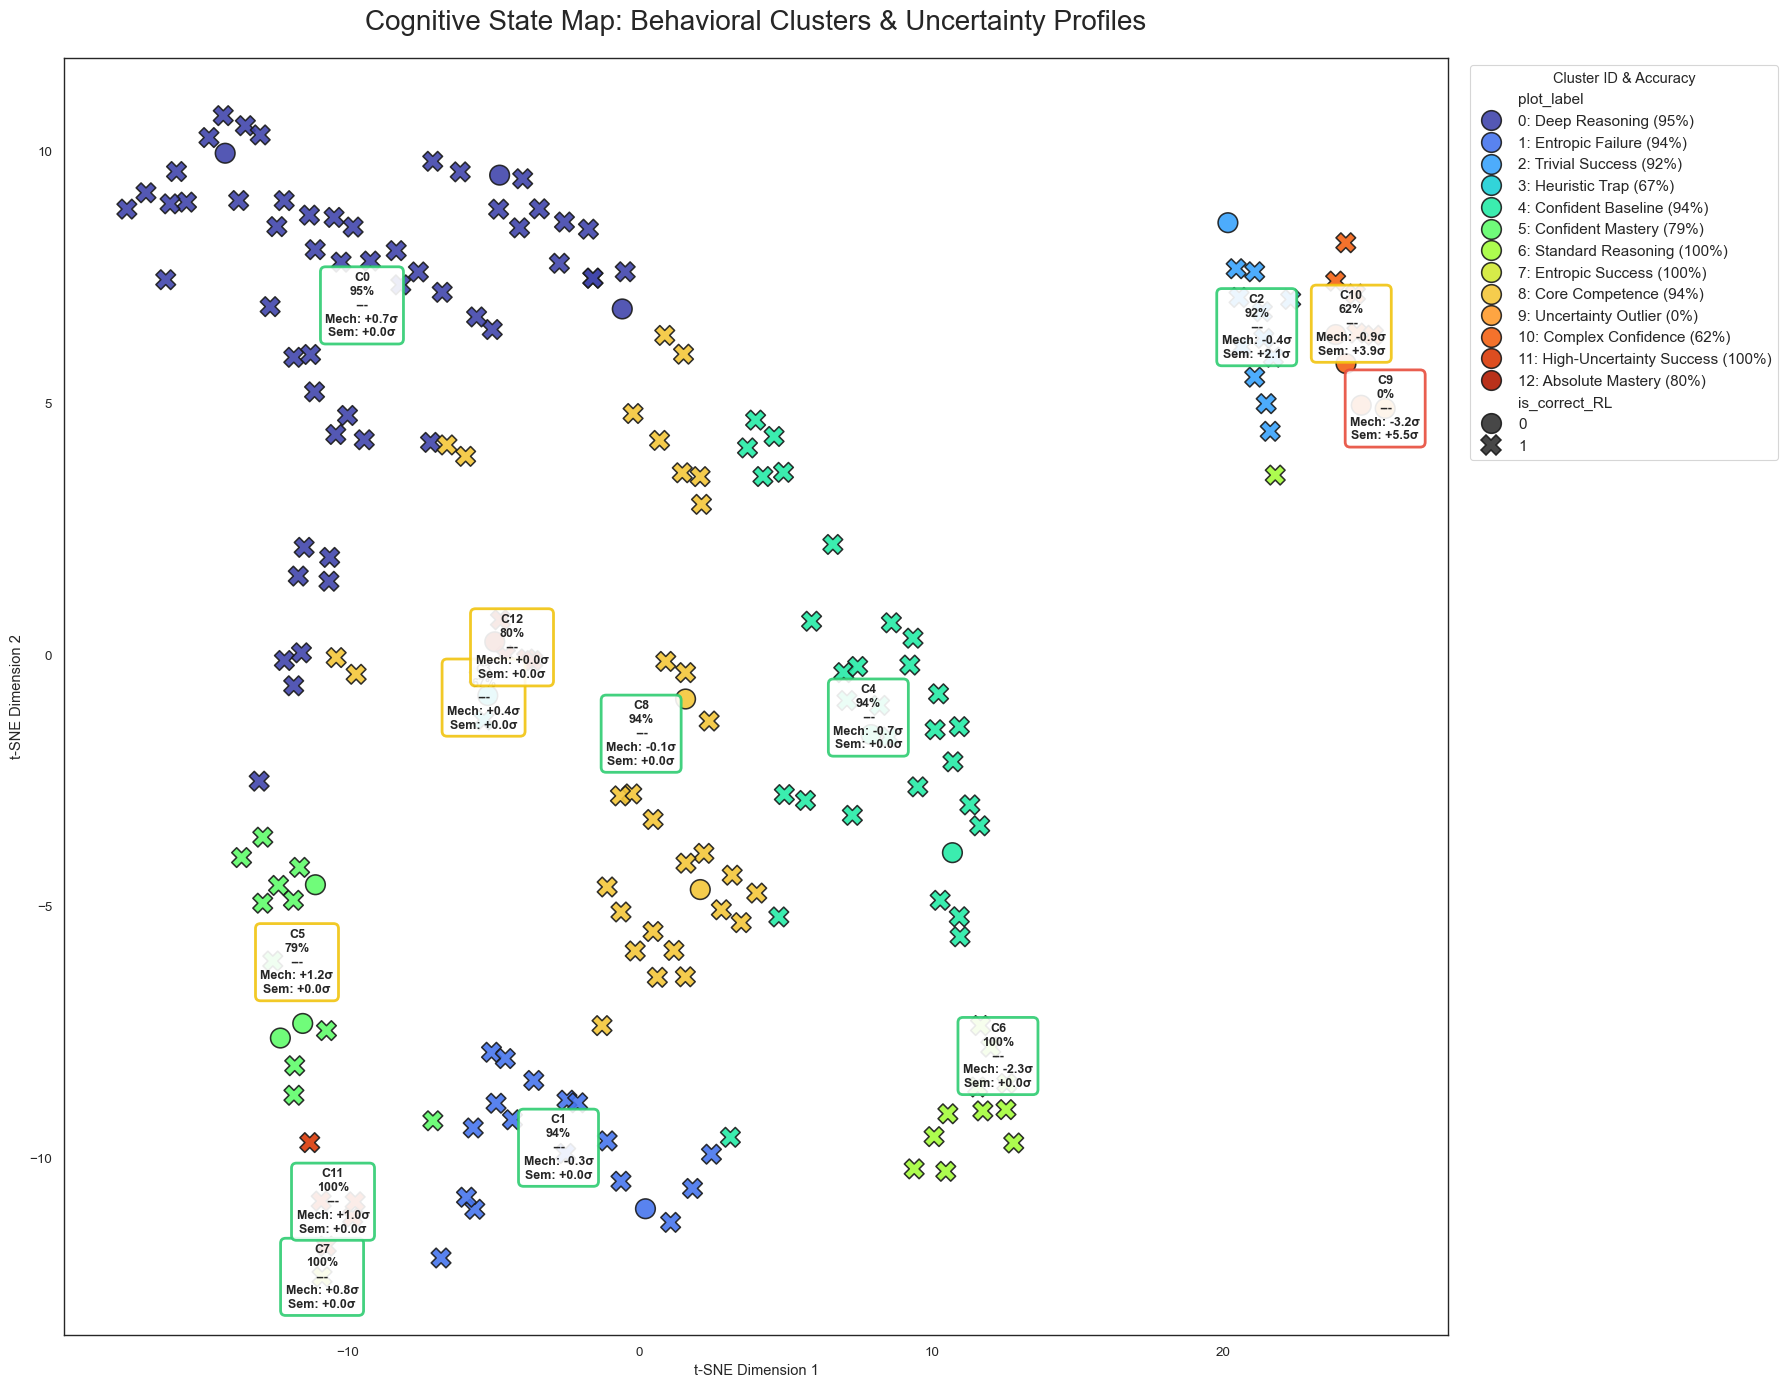

In [42]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format
sns.set_theme(style="white", context="paper", font_scale=1.1)

DB_PATH = 'db/results.sqlite'

# ==============================================================================
#  CONFIG
# ==============================================================================
BASE_CLUSTER_NAMES = {
    0:  "Deep Reasoning",
    1:  "Entropic Failure",
    2:  "Trivial Success",
    3:  "Heuristic Trap",
    4:  "Confident Baseline",
    5:  "Confident Mastery",
    6:  "Standard Reasoning",
    7:  "Entropic Success",
    8:  "Core Competence",
    9:  "Uncertainty Outlier",
    10: "Complex Confidence",
    11: "High-Uncertainty Success",
    12: "Absolute Mastery"
}

# Mapping internal column names to the User's preferred labels
METRIC_CONFIG = {
    'uq_mech_score_RL':       {'label': 'Mech Unc', 'inverse': False},
    'uq_semantic_entropy_RL': {'label': 'Sem Unc',  'inverse': False},
    # We include these for the stats report, but maybe not the label to keep it short
    'uq_min_logit_gap_RL':    {'label': 'Confidence', 'inverse': True}, 
    'uq_heuristic_score_RL':  {'label': 'Heuristic',  'inverse': False}
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================
def get_relative_z(cluster_series, global_median, global_std):
    """
    Calculates (Cluster Median - Global Median) / Global Std
    """
    if global_std == 0: return 0.0
    return (cluster_series.median() - global_median) / global_std

def get_stats_string(series, global_series):
    """
    Returns formatted stats: Median (Global Med) | Mean | Std | Range | 90% Range
    """
    # Using Median as primary since user requested Median-based Z-scores
    med_val = series.median()
    glb_med = global_series.median()
    
    mean_val = series.mean()
    std_val = series.std()
    min_val = series.min()
    max_val = series.max()
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    
    return (f"Med: {med_val:6.3f} (Glb: {glb_med:5.3f}) | "
            f"Mean: {mean_val:6.3f} | "
            f"Std: {std_val:5.3f} | "
            f"90%: [{p05:5.3f} - {p95:5.3f}]")

def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        r_col = 'id' if 'id' in models.columns else ('model_id' if 'model_id' in models.columns else models.columns[0])
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_final_cluster_report():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Identify Metrics present in df
    active_metrics = [m for m in METRIC_CONFIG.keys() if m in df.columns]
    print(f">>> Analyzing Metrics: {[METRIC_CONFIG[m]['label'] for m in active_metrics]}")
    
    # 2. Pre-Calculate Global Stats (Median & Std) for Z-Score
    global_stats = {}
    for m in active_metrics:
        global_stats[m] = {
            'median': df[m].median(),
            'std': df[m].std()
        }

    # 3. Clustering (Deterministic K=13)
    X = df[active_metrics].fillna(df[active_metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 4. Generate Dynamic Labels with Z-Scores
    cluster_acc = df.groupby('cluster')['is_correct_RL'].mean()
    
    # We need to compute the Z-strings for each cluster first
    cluster_z_strings = {}
    
    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        
        # Calculate the specific Z-scores user requested
        # "Mech Uncertainty" and "Semantic Uncertainty"
        z_parts = []
        
        # Explicitly grabbing the two requested metrics
        if 'uq_mech_score_RL' in active_metrics:
            m = 'uq_mech_score_RL'
            z = get_relative_z(subset[m], global_stats[m]['median'], global_stats[m]['std'])
            z_parts.append(f"Mech: {z:+.1f}σ")
            
        if 'uq_semantic_entropy_RL' in active_metrics:
            m = 'uq_semantic_entropy_RL'
            z = get_relative_z(subset[m], global_stats[m]['median'], global_stats[m]['std'])
            z_parts.append(f"Sem: {z:+.1f}σ")
            
        cluster_z_strings[cid] = " | ".join(z_parts)

    def get_full_label(row):
        cid = row['cluster']
        name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        acc = cluster_acc[cid]
        z_str = cluster_z_strings.get(cid, "")
        # Format: "0: Deep Reasoning (95%) | Mech: +0.5σ | Sem: -0.2σ"
        return f"{cid}: {name} ({acc:.0%})\n    [{z_str}]"

    df['cluster_label'] = df.apply(get_full_label, axis=1)
    
    # 5. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  DETAILED STATISTICAL REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" COGNITIVE STATE REPORT (N={len(df)})")
    print("="*80)

    for cid in cluster_acc.sort_values(ascending=False).index:
        subset = df[df['cluster'] == cid]
        base_name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        acc = cluster_acc[cid]
        z_str = cluster_z_strings.get(cid, "")
        
        # Archetype
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]

        # Icon Logic
        if acc >= 0.95: icon = "💎"
        elif acc >= 0.85: icon = "✅"
        elif acc < 0.6: icon = "❌"
        elif "Trap" in base_name: icon = "🪤"
        else: icon = "⚠️"

        print(f"\nCLUSTER {cid}: {icon} {base_name} ({acc:.1%})")
        print(f"Stats: {z_str}")
        print(f"{'-'*80}")
        print(f"Size: {len(subset)} ({len(subset)/len(df):.1%})")
        
        print("\nMETRIC STATISTICS:")
        for m in active_metrics:
            cfg = METRIC_CONFIG[m]
            stats_str = get_stats_string(subset[m], df[m])
            print(f"  • {cfg['label']:<15}: {stats_str}")
            
        print(f"\n[ARCHETYPE Q]: {str(archetype_row['final_text'])[:90]}...")
        print(f"[ARCHETYPE A]: {str(archetype_row['ans_rl'])[:90]}...")
        print(f"{'='*80}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(18, 14))
    
    # Clean label for Legend (strip newline for cleaner legend if possible, 
    # but user wanted info. We'll keep it but maybe compact)
    # Actually, seaborn legend with newlines can be messy.
    # Let's clean up the column for plotting specific
    df['plot_label'] = df.apply(lambda r: f"{r['cluster']}: {BASE_CLUSTER_NAMES.get(r['cluster'])} ({cluster_acc[r['cluster']]:.0%})", axis=1)

    # Sort for consistent legend
    df = df.sort_values('cluster')
    
    scatter = sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='plot_label', # Use cleaner label for legend
        style='is_correct_RL',
        palette='turbo', 
        s=200, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Centers with RICH INFO Box
    for cid in df['cluster'].unique():
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        acc_val = cluster_acc[cid]
        z_str_lines = cluster_z_strings[cid].replace(" | ", "\n") # Stack metrics
        
        # Color code box edge based on performance
        edge_c = '#2ecc71' if acc_val > 0.85 else ('#e74c3c' if acc_val < 0.6 else '#f1c40f')
        
        plt.text(
            cx, cy, 
            f"C{cid}\n{acc_val:.0%}\n---\n{z_str_lines}", 
            fontsize=9, 
            fontweight='bold', 
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.9, edgecolor=edge_c, boxstyle='round,pad=0.4', linewidth=2)
        )

    plt.title("Cognitive State Map: Behavioral Clusters & Uncertainty Profiles", fontsize=20, pad=20)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    # Legend
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Cluster ID & Accuracy", frameon=True, fontsize=11)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_cluster_report()

>>> Loading Data...
>>> Analyzing Metrics: ['Mechanistic Complexity', 'Confidence (Logit Gap)', 'Semantic Entropy', 'Heuristic Shortcut']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 COGNITIVE STATE ANALYSIS (N=200)

CLUSTER 6: [EXCELLENT] Standard Inference (100.0%)
--------------------------------------------------------------------------------
Size:      12 (6.0%)

METRIC STATISTICS (Mean vs Global | Std | Range | 90% Range):
  • Mechanistic Complexity   :  0.032 (Glb: 0.051) | Std: 0.003 | Range: [0.025 - 0.035] | 90%: [0.027 - 0.035]
  • Confidence (Logit Gap)   :  0.126 (Glb: 0.137) | Std: 0.097 | Range: [0.045 - 0.312] | 90%: [0.045 - 0.288]
  • Semantic Entropy         :  0.042 (Glb: 0.079) | Std: 0.144 | Range: [0.000 - 0.500] | 90%: [0.000 - 0.225]
  • Heuristic Shortcut       :  0.000 (Glb: 0.002) | Std: 0.000 | Range: [0.000 - 0.000] | 90%: [0.000 - 0.000]

[ARCHETYPE Q]: A car is driving through a tunnel with many turns. After a while, the car m

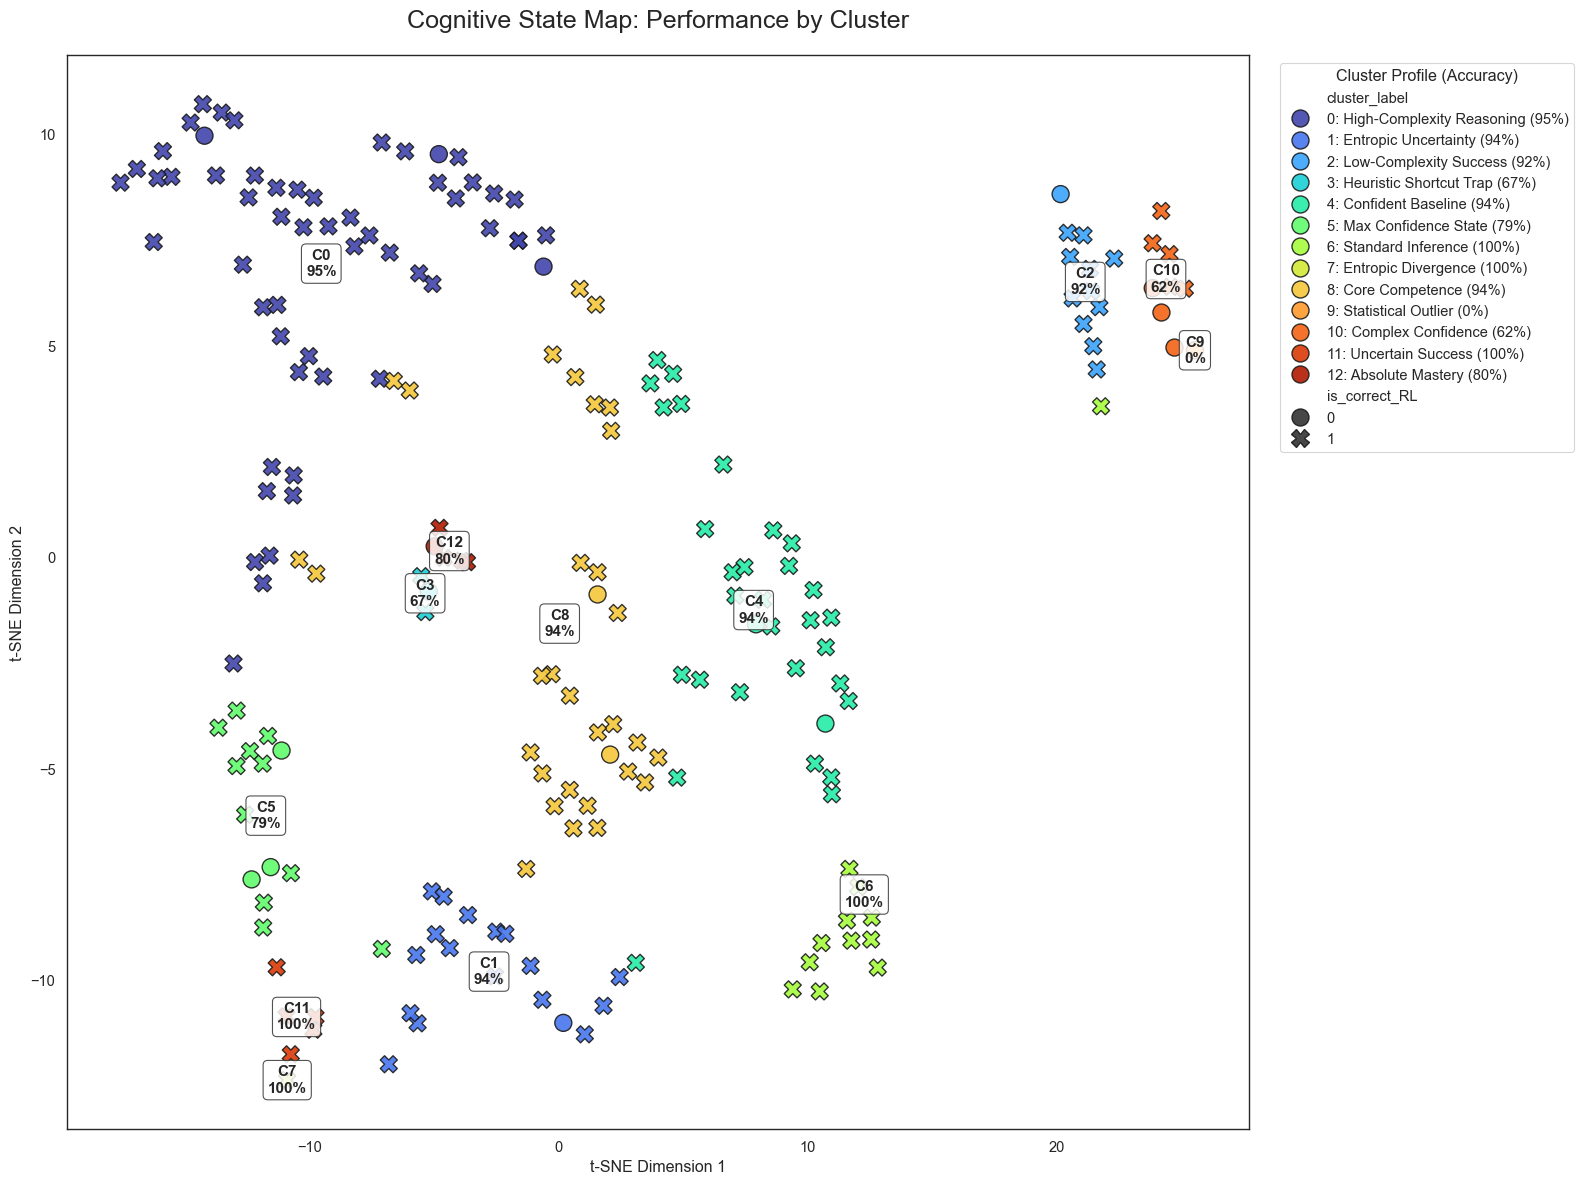

In [41]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  CONFIG: FORMAL TAXONOMY & METRICS
# ==============================================================================
# Formal definitions based on K=13 (Seed=42)
BASE_CLUSTER_NAMES = {
    0:  "High-Complexity Reasoning",    # High Mech (Flag) / High Acc
    1:  "Entropic Uncertainty",         # High Entropy / Low Acc
    2:  "Low-Complexity Success",       # Low Mech / High Acc
    3:  "Heuristic Shortcut Trap",      # High Heuristic / Mixed Acc
    4:  "Confident Baseline",           # High Gap
    5:  "Max Confidence State",         # Extreme Confidence
    6:  "Standard Inference",           # Baseline Profile
    7:  "Entropic Divergence",          # High Entropy / Good Acc
    8:  "Core Competence",              # Average Profile
    9:  "Statistical Outlier",          # High SAUP / Outlier
    10: "Complex Confidence",           # High Mech / High Gap
    11: "Uncertain Success",            # High Uncertainty / High Acc
    12: "Absolute Mastery"              # Max Confidence
}

# User Preference: Using Semantic Entropy, flagging Mech as complexity
METRIC_MAP = {
    'uq_mech_score_RL': 'Mechanistic Complexity', # Renamed to reflect "Flag" status
    'uq_min_logit_gap_RL': 'Confidence (Logit Gap)',
    'uq_semantic_entropy_RL': 'Semantic Entropy',
    'uq_heuristic_score_RL': 'Heuristic Shortcut'
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_stats_string(series, global_series):
    """
    Returns formatted stats: Mean (Global), Std, Range [Min-Max], 90% Range
    """
    mean_val = series.mean()
    global_mean = global_series.mean()
    std_val = series.std()
    min_val = series.min()
    max_val = series.max()
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    
    # Format: "0.123 (G: 0.100) | Std: 0.05 | R: [0.0-1.0] | 90%: [0.1-0.9]"
    return (f"{mean_val:6.3f} (Glb: {global_mean:5.3f}) | "
            f"Std: {std_val:5.3f} | "
            f"Range: [{min_val:5.3f} - {max_val:5.3f}] | "
            f"90%: [{p05:5.3f} - {p95:5.3f}]")

def wrap_text(text, width=80, indent="    "):
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        r_col = 'id' if 'id' in models.columns else ('model_id' if 'model_id' in models.columns else models.columns[0])
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_final_cluster_report():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics
    metrics = [k for k in METRIC_MAP.keys() if k in df.columns]
    print(f">>> Analyzing Metrics: {[METRIC_MAP[m] for m in metrics]}")
    
    # 2. Clustering (Deterministic K=13)
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 3. Create Dynamic Labels with Accuracy
    cluster_acc = df.groupby('cluster')['is_correct_RL'].mean()
    
    def get_label(row):
        cid = row['cluster']
        name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        acc = cluster_acc[cid]
        return f"{cid}: {name} ({acc:.0%})"

    df['cluster_label'] = df.apply(get_label, axis=1)
    
    # 4. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  DETAILED STATISTICAL REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" COGNITIVE STATE ANALYSIS (N={len(df)})")
    print("="*80)

    # Sort by accuracy for the report
    sorted_cids = cluster_acc.sort_values(ascending=False).index

    for cid in sorted_cids:
        subset = df[df['cluster'] == cid]
        base_name = BASE_CLUSTER_NAMES.get(cid, "Unknown")
        acc = cluster_acc[cid]
        label = f"{base_name} ({acc:.1%})"
        
        # Archetype
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]

        # Formal Status Markers
        if acc >= 0.95: status = "[EXCELLENT]"
        elif acc >= 0.85: status = "[PASS]"
        elif acc < 0.6: status = "[FAILURE]"
        elif "Trap" in base_name: status = "[RISK]"
        else: status = "[MIXED]"

        print(f"\nCLUSTER {cid}: {status} {label}")
        print(f"{'-'*80}")
        print(f"Size:      {len(subset)} ({len(subset)/len(df):.1%})")
        
        # Detailed Stats Block
        print("\nMETRIC STATISTICS (Mean vs Global | Std | Range | 90% Range):")
        for m in metrics:
            readable_name = METRIC_MAP[m]
            stats_str = get_stats_string(subset[m], df[m])
            print(f"  • {readable_name:<25}: {stats_str}")
            
        print(f"\n[ARCHETYPE Q]: {str(archetype_row['final_text'])[:90]}...")
        print(f"[ARCHETYPE A]: {str(archetype_row['ans_rl'])[:90]}...")
        print(f"{'='*80}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(16, 12))
    
    # Sort labels by Cluster ID for legend consistency
    df = df.sort_values('cluster')
    
    scatter = sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster_label',
        style='is_correct_RL',
        palette='turbo', 
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Centers with ID and Accuracy
    for cid in df['cluster'].unique():
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        acc_val = cluster_acc[cid]
        
        # Annotation Box
        plt.text(
            cx, cy, 
            f"C{cid}\n{acc_val:.0%}", 
            fontsize=11, 
            fontweight='bold', 
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='#333', boxstyle='round,pad=0.3')
        )

    plt.title("Cognitive State Map: Performance by Cluster", fontsize=18, pad=20)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    # Legend Adjustment
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster Profile (Accuracy)", frameon=True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_cluster_report()

>>> Loading Data...
>>> Analyzing Metrics: ['Mechanistic Reasoning', 'Confidence (Logit Gap)', 'SAUP Uncertainty', 'Semantic Confusion', 'Heuristic Shortcut Use']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 FINAL COGNITIVE STATE REPORT (N=200)

CLUSTER 0: ✅ The Deep Thinkers (High Mech/Acc)
--------------------------------------------------------------------------------
Size:      39 (19.5%)
Accuracy:  94.9%
--------------------------------------------------------------------------------
METRIC STATISTICS:
  • Mechanistic Reasoning    :  0.058 (Global: 0.051) | Std: 0.003 | Range: [0.054 - 0.068] | 90% Range: [0.054 - 0.064]
  • Confidence (Logit Gap)   :  0.068 (Global: 0.137) | Std: 0.073 | Range: [0.000 - 0.268] | 90% Range: [0.000 - 0.183]
  • SAUP Uncertainty         :  0.205 (Global: 0.185) | Std: 0.017 | Range: [0.176 - 0.241] | 90% Range: [0.181 - 0.237]
  • Semantic Confusion       :  0.000 (Global: 0.079) | Std: 0.000 | Range: [0.000 - 0.000] | 90

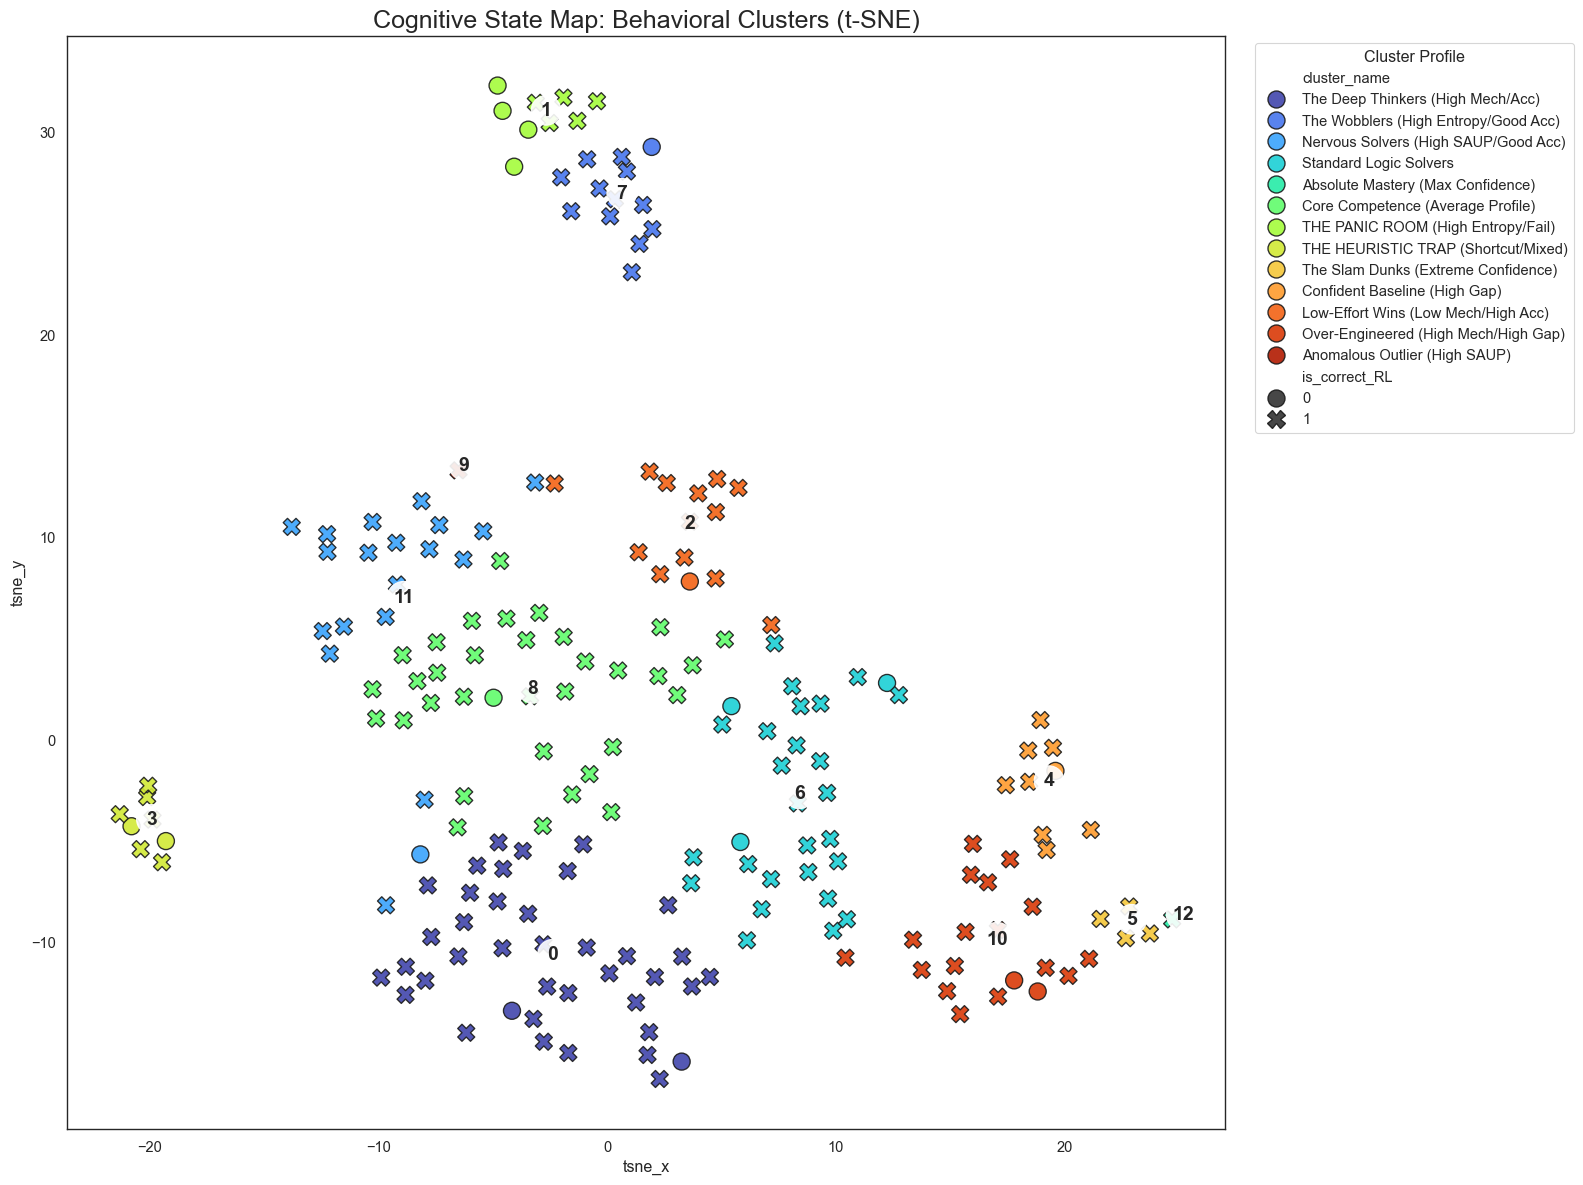

In [40]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  CONFIG: NAMING & METRICS
# ==============================================================================
CLUSTER_NAMES = {
    0:  "The Deep Thinkers (High Mech/Acc)",
    1:  "THE PANIC ROOM (High Entropy/Fail)",
    2:  "Low-Effort Wins (Low Mech/High Acc)",
    3:  "THE HEURISTIC TRAP (Shortcut/Mixed)",
    4:  "Confident Baseline (High Gap)",
    5:  "The Slam Dunks (Extreme Confidence)",
    6:  "Standard Logic Solvers",
    7:  "The Wobblers (High Entropy/Good Acc)",
    8:  "Core Competence (Average Profile)",
    9:  "Anomalous Outlier (High SAUP)",
    10: "Over-Engineered (High Mech/High Gap)",
    11: "Nervous Solvers (High SAUP/Good Acc)",
    12: "Absolute Mastery (Max Confidence)"
}

METRIC_MAP = {
    'uq_mech_score_RL': 'Mechanistic Reasoning',
    'uq_min_logit_gap_RL': 'Confidence (Logit Gap)',
    'uq_saup_score_RL': 'SAUP Uncertainty',
    'uq_semantic_entropy_RL': 'Semantic Confusion',
    'uq_heuristic_score_RL': 'Heuristic Shortcut Use'
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def get_stats_string(series, global_series):
    """
    Returns formatted stats: Mean (Global), Std, Range [Min-Max], 90% Range
    """
    mean_val = series.mean()
    global_mean = global_series.mean()
    std_val = series.std()
    min_val = series.min()
    max_val = series.max()
    p05 = series.quantile(0.05)
    p95 = series.quantile(0.95)
    
    return (f"{mean_val:6.3f} (Global: {global_mean:5.3f}) | "
            f"Std: {std_val:5.3f} | "
            f"Range: [{min_val:5.3f} - {max_val:5.3f}] | "
            f"90% Range: [{p05:5.3f} - {p95:5.3f}]")

def wrap_text(text, width=80, indent="    "):
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        r_col = 'id' if 'id' in models.columns else ('model_id' if 'model_id' in models.columns else models.columns[0])
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_final_cluster_report():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics (Using the mapping keys)
    metrics = [k for k in METRIC_MAP.keys() if k in df.columns]
    print(f">>> Analyzing Metrics: {[METRIC_MAP[m] for m in metrics]}")
    
    # 2. Clustering (Deterministic K=13)
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    df['cluster_name'] = df['cluster'].map(CLUSTER_NAMES).fillna("Unknown Cluster")
    
    # 3. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  DETAILED STATISTICAL REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" FINAL COGNITIVE STATE REPORT (N={len(df)})")
    print("="*80)

    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        name = CLUSTER_NAMES.get(cid, "Unknown")
        
        # Archetype
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]

        acc = subset['is_correct_RL'].mean()
        
        # Icon Logic
        if "PANIC" in name: icon = "🚨"
        elif "TRAP" in name: icon = "🪤"
        elif "Mastery" in name or "Slam" in name: icon = "🏆"
        elif acc < 0.6: icon = "❌"
        else: icon = "✅"

        print(f"\nCLUSTER {cid}: {icon} {name}")
        print(f"{'-'*80}")
        print(f"Size:      {len(subset)} ({len(subset)/len(df):.1%})")
        print(f"Accuracy:  {acc:.1%}")
        print(f"{'-'*80}")
        
        # Detailed Stats Block
        print("METRIC STATISTICS:")
        for m in metrics:
            readable_name = METRIC_MAP[m]
            stats_str = get_stats_string(subset[m], df[m])
            print(f"  • {readable_name:<25}: {stats_str}")
            
        print(f"\n[ARCHETYPE Q]: {str(archetype_row['final_text'])[:90]}...")
        print(f"[ARCHETYPE A]: {str(archetype_row['ans_rl'])[:90]}...")
        print(f"{'='*80}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(16, 12))
    
    scatter = sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster_name',
        style='is_correct_RL',
        palette='turbo', 
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Centers
    for cid in df['cluster'].unique():
        c = df[df['cluster'] == cid]
        plt.text(c['tsne_x'].mean(), c['tsne_y'].mean(), str(cid), 
                 fontsize=14, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, boxstyle='circle'))

    plt.title("Cognitive State Map: Behavioral Clusters (t-SNE)", fontsize=18)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster Profile")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_final_cluster_report()

>>> Loading Data...
>>> Active Metrics: ['uq_mech_score_RL', 'uq_min_logit_gap_RL', 'uq_saup_score_RL', 'uq_semantic_entropy_RL', 'uq_heuristic_score_RL']
>>> Applying Deterministic Clustering (K=13)...
>>> Computing t-SNE...

 NAMED CLUSTER PROFILES (N=200)

CLUSTER 0: ✅ The Deep Thinkers (High Mech/Acc)
------------------------------------------------------------
Size:      39 (19.5%)
Accuracy:  94.9%
Profile:   High mech_score (+0.8σ), High saup_score (+0.5σ)

[ARCHETYPE Q]: Ann is cutting fabric to make curtains. She cuts a 4 foot by 6 foot rectangle for the livi...
[METRICS]:     score: 0.057 | gap: 0.045 | score: 0.202 | entropy: 0.000 | score: 0.000
------------------------------------------------------------

CLUSTER 1: 🚨 THE PANIC ROOM (High Entropy/Fail)
------------------------------------------------------------
Size:      9 (4.5%)
Accuracy:  55.6%
Profile:   Low mech_score (-1.0σ), Low min_logit_gap (-0.6σ), High semantic_entropy (+3.9σ)

[ARCHETYPE Q]: Nancy, the libraria

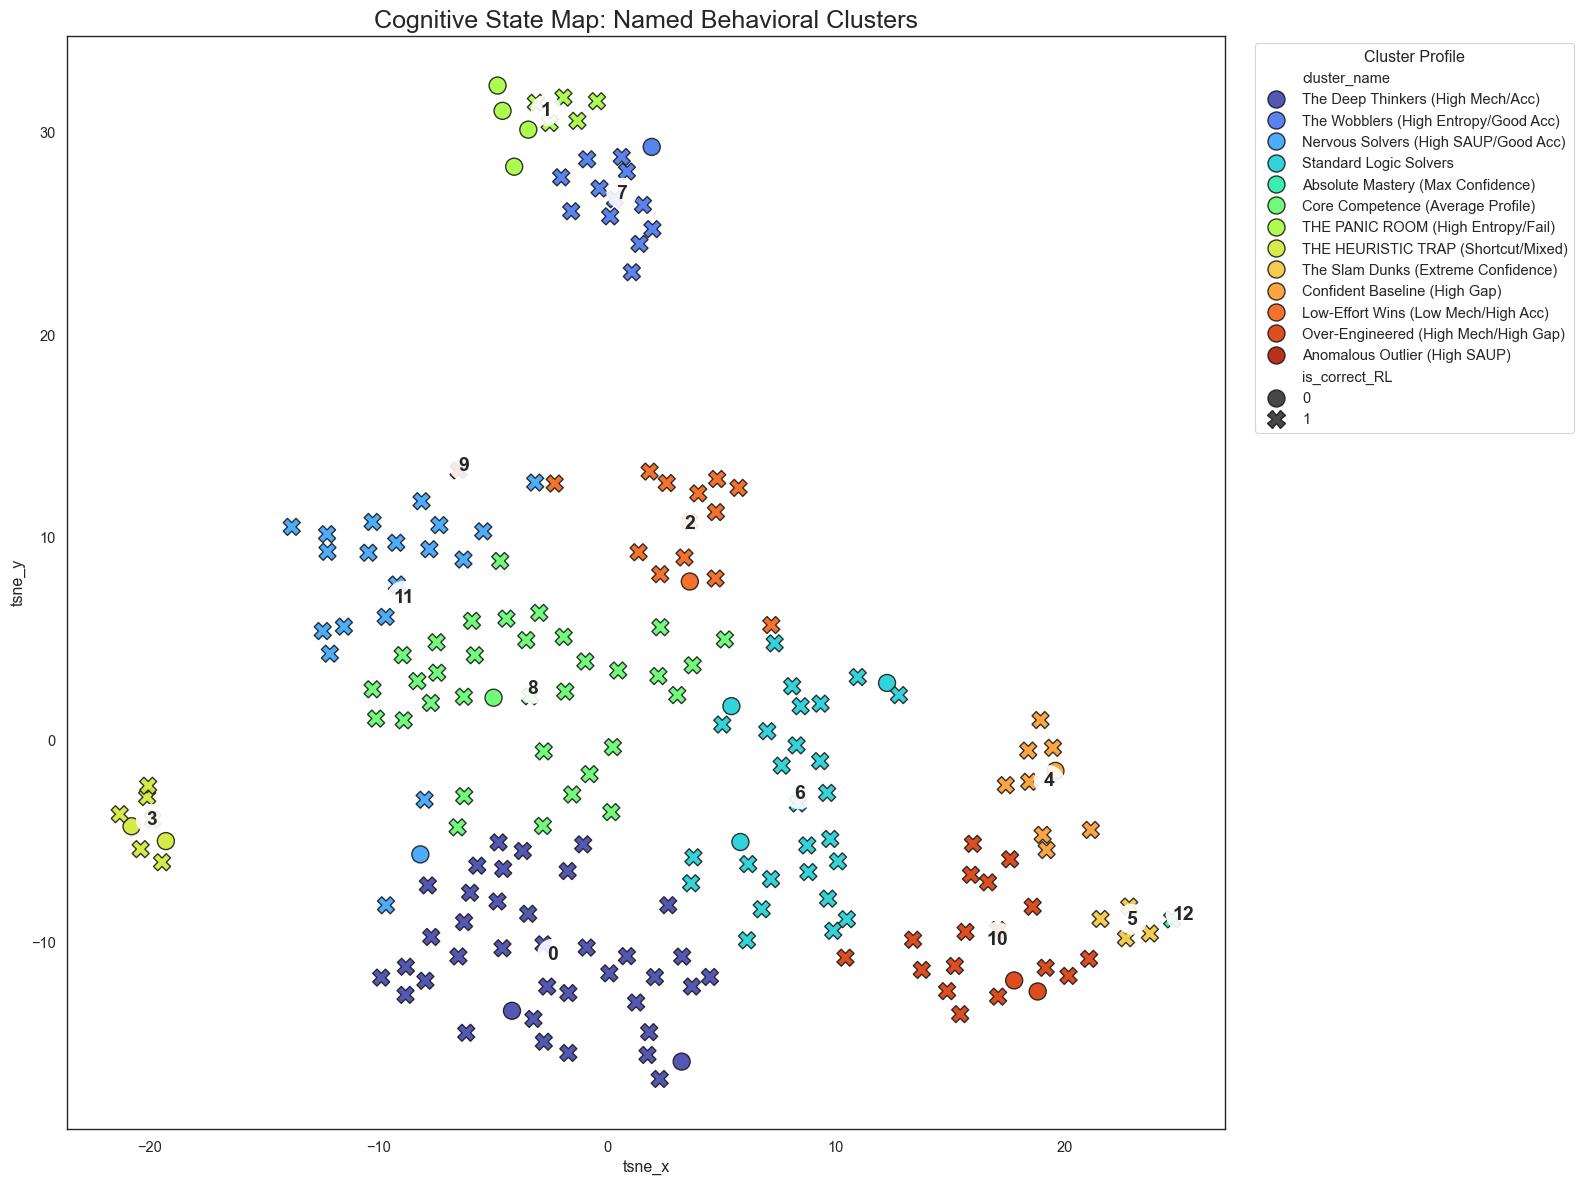

In [39]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  DETERMINISTIC NAMING MAPPING (Based on K=13, Seed=42)
# ==============================================================================
CLUSTER_NAMES = {
    0:  "The Deep Thinkers (High Mech/Acc)",
    1:  "THE PANIC ROOM (High Entropy/Fail)",
    2:  "Low-Effort Wins (Low Mech/High Acc)",
    3:  "THE HEURISTIC TRAP (Shortcut/Mixed)",
    4:  "Confident Baseline (High Gap)",
    5:  "The Slam Dunks (Extreme Confidence)",
    6:  "Standard Logic Solvers",
    7:  "The Wobblers (High Entropy/Good Acc)",
    8:  "Core Competence (Average Profile)",
    9:  "Anomalous Outlier (High SAUP)",
    10: "Over-Engineered (High Mech/High Gap)",
    11: "Nervous Solvers (High SAUP/Good Acc)",
    12: "Absolute Mastery (Max Confidence)"
}

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def calculate_cohesion(text_list):
    if len(text_list) < 2: return 1.0
    sample = text_list if len(text_list) < 50 else pd.Series(text_list).sample(50, random_state=42).tolist()
    scores = []
    for i in range(len(sample)):
        for j in range(i + 1, len(sample)):
            s = SequenceMatcher(None, str(sample[i]), str(sample[j])).ratio()
            scores.append(s)
    return np.mean(scores) if scores else 0.0

def get_metric_profile(df_subset, df_global, metrics):
    desc = []
    global_mean = df_global[metrics].mean()
    global_std = df_global[metrics].std()
    local_mean = df_subset[metrics].mean()
    
    for m in metrics:
        if global_std[m] == 0: continue
        z = (local_mean[m] - global_mean[m]) / global_std[m]
        name = m.replace('uq_', '').replace('_RL', '').replace('mechanistic', 'mech')
        if z > 0.4: desc.append(f"High {name} (+{z:.1f}σ)")
        elif z < -0.4: desc.append(f"Low {name} ({z:.1f}σ)")
            
    return ", ".join(desc) if desc else "Average/Baseline"

def wrap_text(text, width=80, indent="    "):
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        if 'id' in models.columns: r_col = 'id'
        elif 'model_id' in models.columns: r_col = 'model_id'
        else: r_col = models.columns[0]
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_named_cluster_analysis():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics (Removing redundant avg_entropy)
    metrics = [c for c in df.columns if c.endswith('_RL') and 
               any(x in c for x in ['entropy', 'gap', 'score', 'mechanistic']) and
               'avg_entropy' not in c and 
               pd.api.types.is_numeric_dtype(df[c])]
    
    print(f">>> Active Metrics: {metrics}")
    
    # 2. Clustering (Deterministic K=13)
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Force K=13 to match previous turn's structure
    k = 13
    print(f">>> Applying Deterministic Clustering (K={k})...")
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    df['cluster_name'] = df['cluster'].map(CLUSTER_NAMES).fillna("Unknown Cluster")
    
    # 3. t-SNE
    print(">>> Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  NAMED CLUSTER REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" NAMED CLUSTER PROFILES (N={len(df)})")
    print("="*80)

    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        name = CLUSTER_NAMES.get(cid, "Unknown")
        
        # Archetype
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_row = df.loc[subset.index[closest[0]]]

        acc = subset['is_correct_RL'].mean()
        profile = get_metric_profile(subset, df, metrics)
        
        # Dynamic Icon
        if "PANIC" in name: icon = "🚨"
        elif "TRAP" in name: icon = "🪤"
        elif "Mastery" in name or "Slam" in name: icon = "🏆"
        elif acc < 0.6: icon = "❌"
        else: icon = "✅"

        print(f"\nCLUSTER {cid}: {icon} {name}")
        print(f"{'-'*60}")
        print(f"Size:      {len(subset)} ({len(subset)/len(df):.1%})")
        print(f"Accuracy:  {acc:.1%}")
        print(f"Profile:   {profile}")
        
        print(f"\n[ARCHETYPE Q]: {str(archetype_row['final_text'])[:90]}...")
        vals = [f"{m.split('_')[-2]}: {archetype_row[m]:.3f}" for m in metrics]
        print(f"[METRICS]:     " + " | ".join(vals))
        print(f"{'-'*60}")

    # ==========================================================================
    #  VISUALIZATION
    # ==========================================================================
    plt.figure(figsize=(16, 12))
    
    scatter = sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster_name', # Use Names now!
        style='is_correct_RL',
        palette='turbo', 
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Centers
    for cid in df['cluster'].unique():
        c = df[df['cluster'] == cid]
        plt.text(c['tsne_x'].mean(), c['tsne_y'].mean(), str(cid), 
                 fontsize=14, fontweight='bold', bbox=dict(facecolor='white', alpha=0.9, boxstyle='circle'))

    plt.title("Cognitive State Map: Named Behavioral Clusters", fontsize=18)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster Profile")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_named_cluster_analysis()

>>> Loading Data...
>>> Active Metrics: ['uq_mech_score_RL', 'uq_min_logit_gap_RL', 'uq_saup_score_RL', 'uq_semantic_entropy_RL', 'uq_heuristic_score_RL']
>>> Optimizing Clusters (Searching range 6-15)...
>>> Optimal Clusters Found: 13 (Silhouette: 0.287)
>>> Computing t-SNE Projection...

 DEEP CLUSTER INSPECTION (N=200 | K=13)

CLUSTER 0: ✅ SOLID STATE
------------------------------------------------------------
Size:      39 (19.5%)
Accuracy:  94.9%
Profile:   High mech_score (+0.8σ), High saup_score (+0.5σ)

[ARCHETYPE]
Q:     Ann is cutting fabric to make curtains. She cuts a 4 foot by 6 foot
    rectangle for the living room, and a 2 foot by 4 foot rectangle for the
    bedroom. If the bolt of fabric is 16 feet by 12 feet, how much fabric is
    left in square feet?
A:     160

Metrics:
    score: 0.057 | gap: 0.045 | score: 0.202 | entropy: 0.000 | score: 0.000
------------------------------------------------------------

CLUSTER 1: ❌ FAILURE MODE
-------------------------------

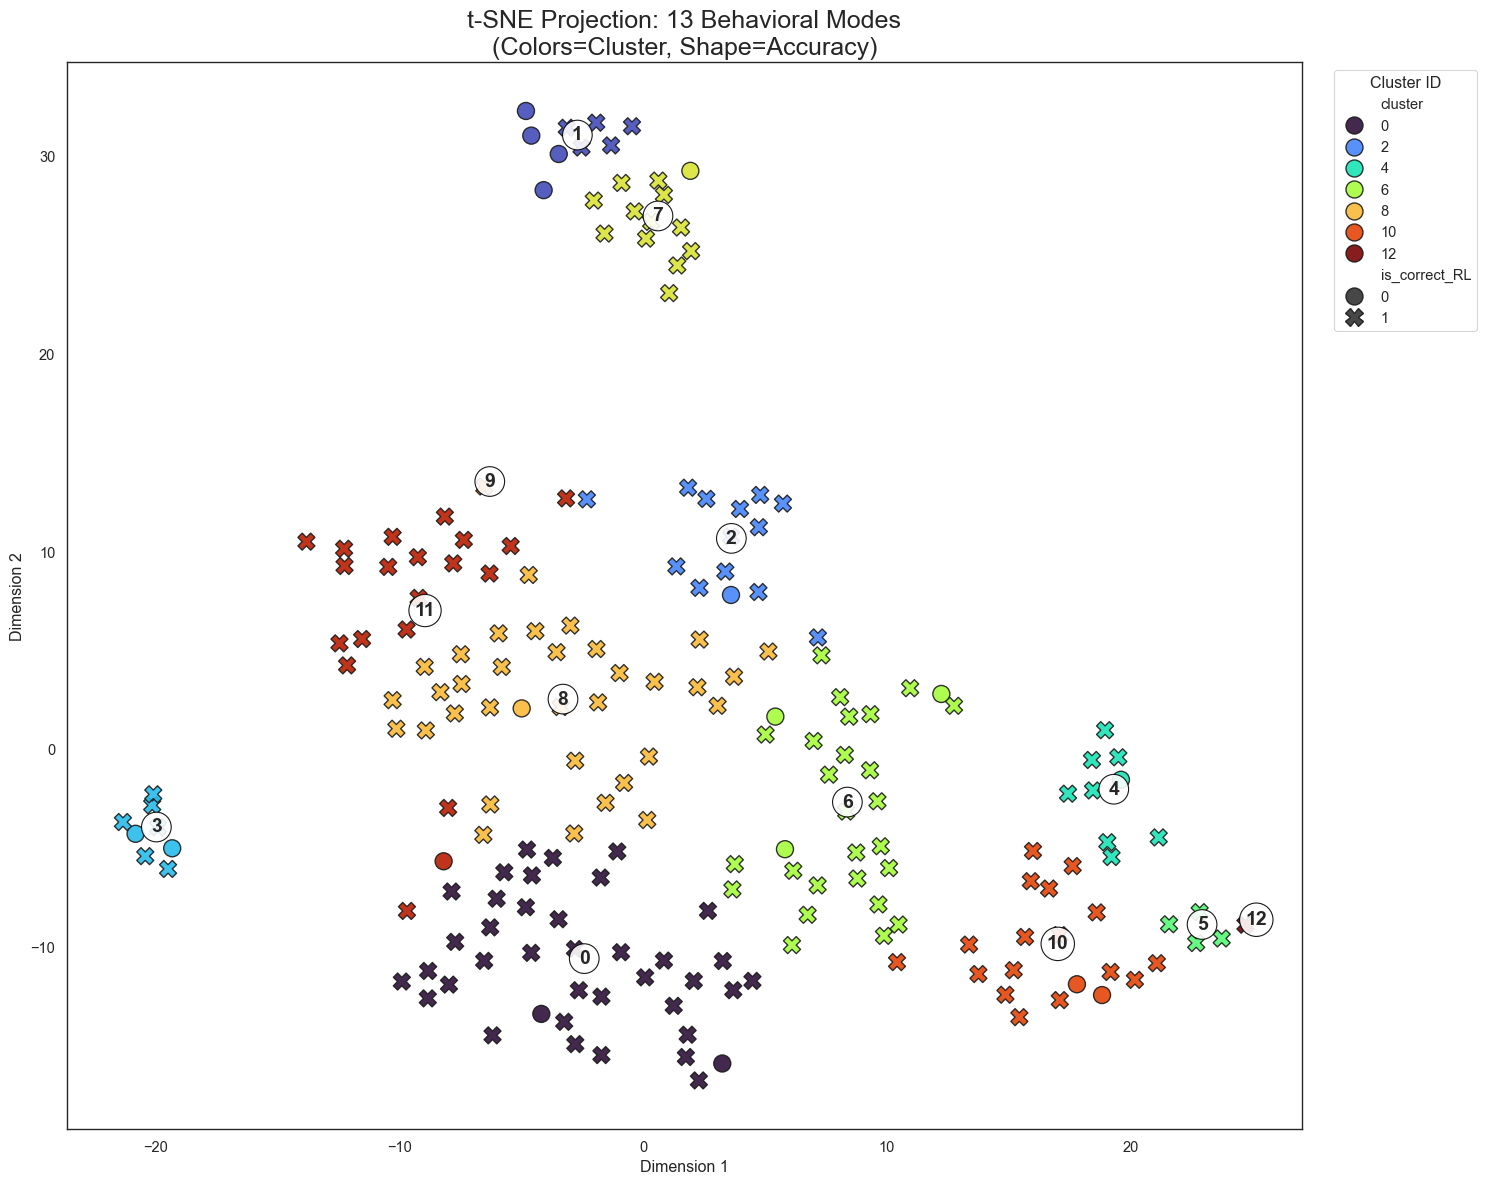

In [38]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def calculate_cohesion(text_list):
    """Calculates how similar the answers are within a cluster."""
    if len(text_list) < 2: return 1.0
    sample = text_list if len(text_list) < 50 else pd.Series(text_list).sample(50, random_state=42).tolist()
    scores = []
    for i in range(len(sample)):
        for j in range(i + 1, len(sample)):
            s = SequenceMatcher(None, str(sample[i]), str(sample[j])).ratio()
            scores.append(s)
    return np.mean(scores) if scores else 0.0

def get_metric_profile(df_subset, df_global, metrics):
    """Returns a string describing what makes this cluster special."""
    desc = []
    global_mean = df_global[metrics].mean()
    global_std = df_global[metrics].std()
    local_mean = df_subset[metrics].mean()
    
    for m in metrics:
        if global_std[m] == 0: continue
        z = (local_mean[m] - global_mean[m]) / global_std[m]
        name = m.replace('uq_', '').replace('_RL', '').replace('mechanistic', 'mech')
        # Lower threshold to catch more subtle traits
        if z > 0.4: desc.append(f"High {name} (+{z:.1f}σ)")
        elif z < -0.4: desc.append(f"Low {name} ({z:.1f}σ)")
            
    return ", ".join(desc) if desc else "Average/Baseline Profile"

def wrap_text(text, width=80, indent="    "):
    """Wraps text for clean console output."""
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        # Get Experiment
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        
        # Get Results & Models
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        # Robust ID detection
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        if 'id' in models.columns: r_col = 'id'
        elif 'model_id' in models.columns: r_col = 'model_id'
        else: r_col = models.columns[0]
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        
        # Pivot SFT vs RL
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        # Cleanup Text
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_deep_cluster_analysis():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics (Strict Numeric)
    # Removing 'uq_avg_entropy_RL' if it exists to avoid redundancy as discussed
    metrics = [c for c in df.columns if c.endswith('_RL') and 
               any(x in c for x in ['entropy', 'gap', 'score', 'mechanistic']) and
               'avg_entropy' not in c and # Explicit removal based on analysis
               pd.api.types.is_numeric_dtype(df[c])]
    
    print(f">>> Active Metrics: {metrics}")
    
    # 2. Preprocessing & Clustering
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # --- FORCE HIGHER GRANULARITY ---
    # We set the floor to 6 and ceiling to 15 to force the algorithm
    # to find more subtle behavioral distinctions.
    best_k = 6 
    best_score = -1
    limit = min(15, len(df)) 
    
    print(f">>> Optimizing Clusters (Searching range 6-{limit})...")
    
    for k in range(6, limit):
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        # We slightly penalize very high K to avoid fragmentation, but favor granularity
        if score > best_score:
            best_k = k
            best_score = score
            
    print(f">>> Optimal Clusters Found: {best_k} (Silhouette: {best_score:.3f})")
    
    # Apply Final KMeans
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 3. Calculate t-SNE (2D Projection)
    print(">>> Computing t-SNE Projection...")
    # Lower perplexity slightly to help separate smaller clusters
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  THE DEEP DIVE REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" DEEP CLUSTER INSPECTION (N={len(df)} | K={best_k})")
    print("="*80)

    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        
        # A. Find Archetype (Closest to Centroid)
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest_indices, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_idx = subset.index[closest_indices[0]]
        archetype_row = df.loc[archetype_idx]

        # B. Calculate Stats
        acc = subset['is_correct_RL'].mean()
        cohesion = calculate_cohesion(subset['ans_rl'].tolist())
        profile = get_metric_profile(subset, df, metrics)
        
        # C. Diagnosis Logic
        status_icon = "⚠️"
        status_msg = "MIXED"
        if acc > 0.95: 
            status_icon = "💎"
            status_msg = "PERFECT STATE"
        elif acc > 0.85: 
            status_icon = "✅"
            status_msg = "SOLID STATE"
        elif acc < 0.55: 
            status_icon = "💀"
            status_msg = "KILL ZONE"
        elif acc < 0.70: 
            status_icon = "❌"
            status_msg = "FAILURE MODE"
        
        if "High heuristic" in profile: status_msg += " (Shortcut Trap)"
        if "High entropy" in profile: status_msg += " (Confusion)"
        if "Low gap" in profile and acc > 0.9: status_msg += " (The 'Grinders')"

        # D. Print Card
        print(f"\nCLUSTER {cid}: {status_icon} {status_msg}")
        print(f"{'-'*60}")
        print(f"Size:      {len(subset)} ({len(subset)/len(df):.1%})")
        print(f"Accuracy:  {acc:.1%}")
        print(f"Profile:   {profile}")
        
        print(f"\n[ARCHETYPE]")
        print("Q: " + wrap_text(archetype_row['final_text']))
        print("A: " + wrap_text(archetype_row['ans_rl']))
        
        print(f"\nMetrics:")
        vals = [f"{m.split('_')[-2]}: {archetype_row[m]:.3f}" for m in metrics]
        print("    " + " | ".join(vals))
        print(f"{'-'*60}")

    # ==========================================================================
    #  VISUALIZATION (t-SNE)
    # ==========================================================================
    plt.figure(figsize=(15, 12))
    
    # Main Scatter
    scatter = sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster', 
        style='is_correct_RL',
        palette='turbo', # High contrast palette for many clusters
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Cluster Centers
    for cid in df['cluster'].unique():
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        plt.text(cx, cy, f"{cid}", fontsize=14, fontweight='bold', 
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='circle'))

    plt.title(f"t-SNE Projection: {best_k} Behavioral Modes\n(Colors=Cluster, Shape=Accuracy)", fontsize=18)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster ID")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_deep_cluster_analysis()

>>> Loading Data...
>>> Analyzing Correlation for: ['is_correct_RL', 'uq_mech_score_RL', 'uq_avg_entropy_RL', 'uq_min_logit_gap_RL', 'uq_saup_score_RL', 'uq_semantic_entropy_RL', 'uq_heuristic_score_RL']

 CORRELATION MATRIX
                        is_correct_RL  uq_mech_score_RL  uq_avg_entropy_RL  uq_min_logit_gap_RL  uq_saup_score_RL  uq_semantic_entropy_RL  uq_heuristic_score_RL
is_correct_RL                  1.0000            0.0419             0.0385               0.0222            0.0238                 -0.2362                -0.1233
uq_mech_score_RL               0.0419            1.0000            -0.0396               0.1827           -0.1155                 -0.2644                 0.0090
uq_avg_entropy_RL              0.0385           -0.0396             1.0000              -0.3282            0.9614                  0.0167                 0.1049
uq_min_logit_gap_RL            0.0222            0.1827            -0.3282               1.0000           -0.4029                 -

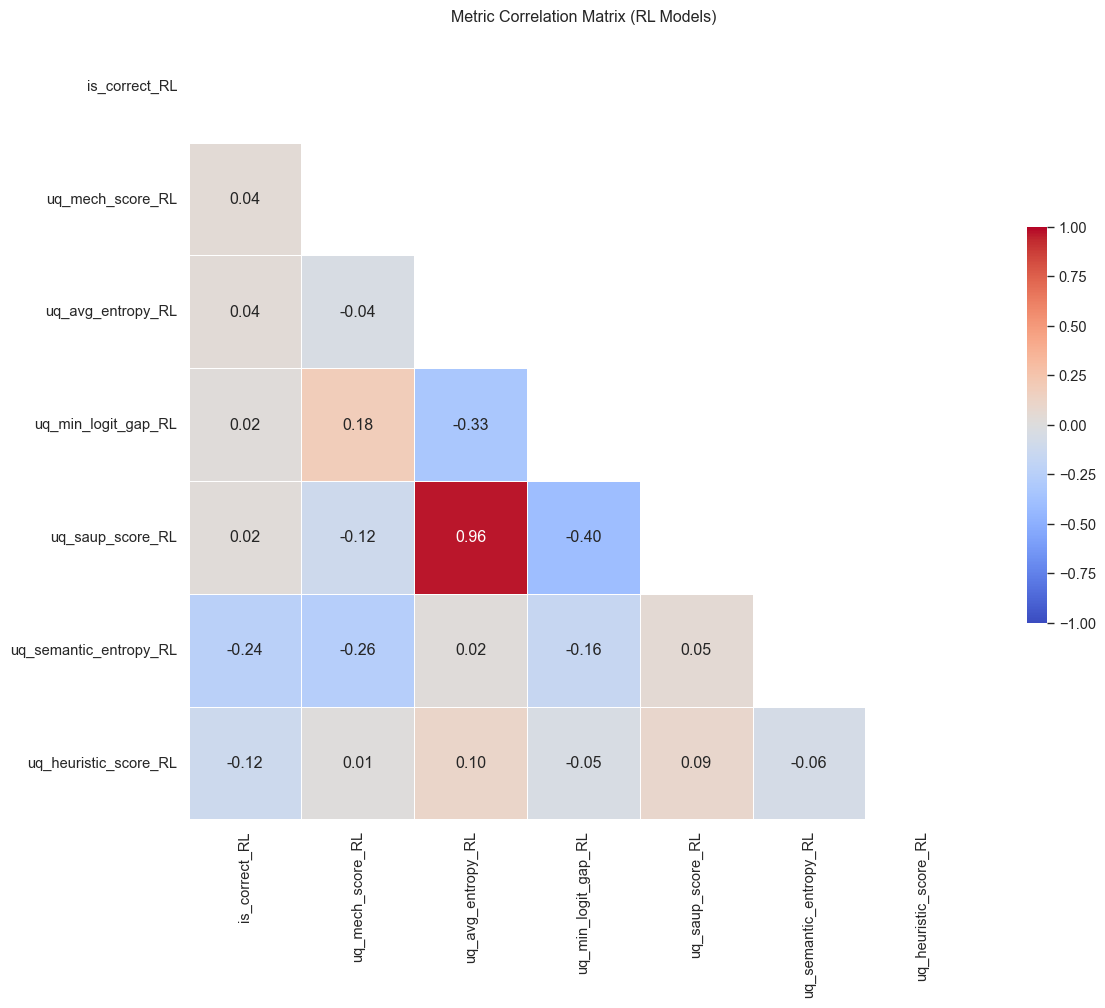

In [36]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configuration
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format
sns.set_theme(style="white", context="paper", font_scale=1.2)
DB_PATH = 'db/results.sqlite'

def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        # Get Experiment
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        
        # Get Results & Models
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        # Robust ID detection
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        if 'id' in models.columns: r_col = 'id'
        elif 'model_id' in models.columns: r_col = 'model_id'
        else: r_col = models.columns[0]
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        
        # Pivot SFT vs RL
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        return merged
    finally:
        conn.close()

def run_correlation_check():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0:
        print("No data found.")
        return

    # 1. Select Metrics (Strict Numeric & ending in _RL)
    # We also include 'is_correct_RL' to see what correlates with performance
    metrics = [c for c in df.columns if c.endswith('_RL') and 
               any(x in c for x in ['entropy', 'gap', 'score', 'mechanistic', 'correct']) and
               pd.api.types.is_numeric_dtype(df[c])]
    
    print(f">>> Analyzing Correlation for: {metrics}")
    
    # 2. Compute Correlation
    corr_matrix = df[metrics].corr()
    
    # 3. Print Correlation Matrix
    print("\n" + "="*80)
    print(" CORRELATION MATRIX")
    print("="*80)
    print(corr_matrix)
    
    # 4. Check for High Redundancy (> 0.85)
    print("\n" + "="*80)
    print(" REDUNDANCY CHECK (> 0.85)")
    print("="*80)
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > 0.85:
                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]
                high_corr.append(f"{col1} <-> {col2}: {corr_matrix.iloc[i, j]:.4f}")
    
    if high_corr:
        for item in high_corr:
            print(f"⚠️  REDUNDANT: {item}")
    else:
        print("✅ No highly redundant metrics found.")

    # 5. Plot Heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Metric Correlation Matrix (RL Models)")
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()

if __name__ == "__main__":
    run_correlation_check()

>>> Loading Data...
>>> Active Metrics: ['uq_mech_score_RL', 'uq_avg_entropy_RL', 'uq_min_logit_gap_RL', 'uq_saup_score_RL', 'uq_semantic_entropy_RL', 'uq_heuristic_score_RL']
>>> Optimizing Clusters (Searching range 6-15)...
>>> Optimal Clusters Found: 7 (Silhouette: 0.285)
>>> Computing t-SNE Projection...

 DEEP CLUSTER INSPECTION (N=200 | K=7)

CLUSTER 0: ✅ SOLID STATE
------------------------------------------------------------
Size:      42 (21.0%)
Accuracy:  90.5%
Profile:   High mech_score (+0.8σ), Low avg_entropy (-0.8σ), Low saup_score (-0.8σ)

[ARCHETYPE]
Q:     Rosie runs 6 miles per hour. She runs for 1 hour on Monday, 30 minutes on
    Tuesday, 1 hour on Wednesday, and 20 minutes on Thursday. If she wants to
    run 20 miles for the week, how many minutes should she run on Friday?
A:     30

Metrics:
    score: 0.061 | entropy: 0.035 | gap: 0.179 | score: 0.147 | entropy: 0.000 | score: 0.000
------------------------------------------------------------

CLUSTER 1: 💎 PERFE

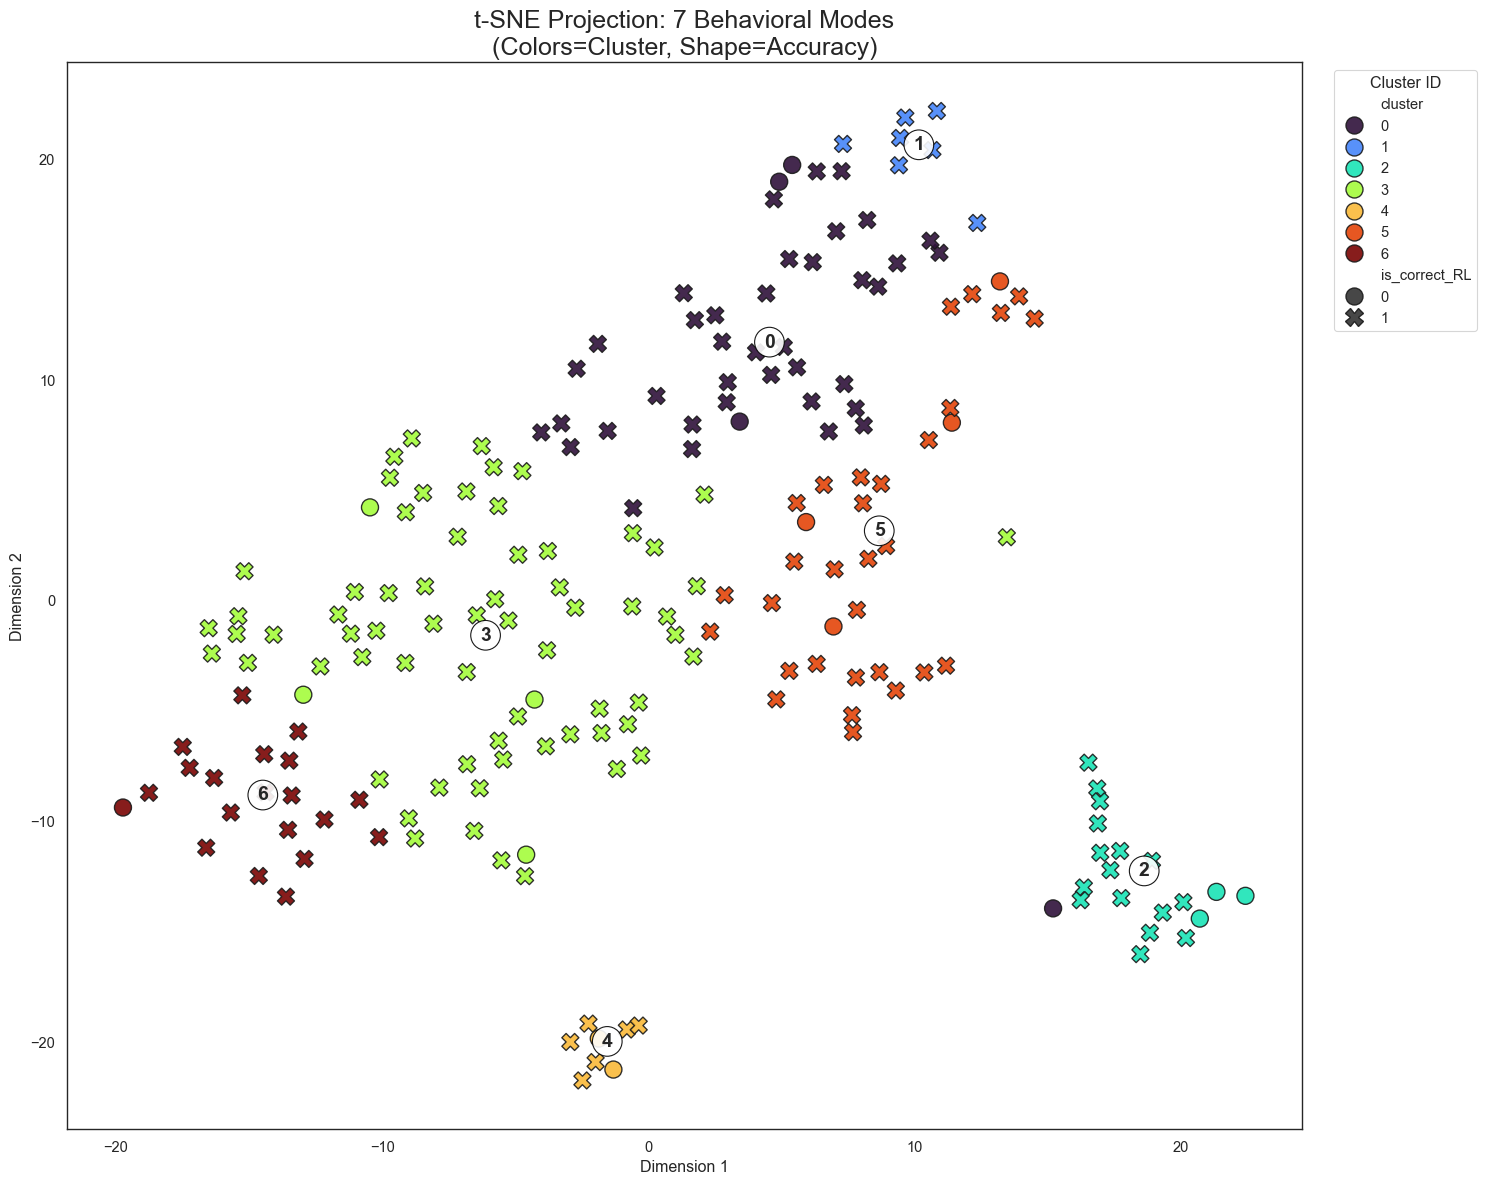

In [35]:
import sqlite3
import pandas as pd
import numpy as np
import warnings
import textwrap
from io import StringIO
from difflib import SequenceMatcher

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="white", context="paper", font_scale=1.2)

# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def calculate_cohesion(text_list):
    """Calculates how similar the answers are within a cluster."""
    if len(text_list) < 2: return 1.0
    sample = text_list if len(text_list) < 50 else pd.Series(text_list).sample(50, random_state=42).tolist()
    scores = []
    for i in range(len(sample)):
        for j in range(i + 1, len(sample)):
            s = SequenceMatcher(None, str(sample[i]), str(sample[j])).ratio()
            scores.append(s)
    return np.mean(scores) if scores else 0.0

def get_metric_profile(df_subset, df_global, metrics):
    """Returns a string describing what makes this cluster special."""
    desc = []
    global_mean = df_global[metrics].mean()
    global_std = df_global[metrics].std()
    local_mean = df_subset[metrics].mean()
    
    for m in metrics:
        if global_std[m] == 0: continue
        z = (local_mean[m] - global_mean[m]) / global_std[m]
        name = m.replace('uq_', '').replace('_RL', '').replace('mechanistic', 'mech')
        # Lower threshold to catch more subtle traits
        if z > 0.4: desc.append(f"High {name} (+{z:.1f}σ)")
        elif z < -0.4: desc.append(f"Low {name} ({z:.1f}σ)")
            
    return ", ".join(desc) if desc else "Average/Baseline Profile"

def wrap_text(text, width=80, indent="    "):
    """Wraps text for clean console output."""
    wrapper = textwrap.TextWrapper(width=width, initial_indent=indent, subsequent_indent=indent)
    return wrapper.fill(str(text))

# ==============================================================================
#  DATA LOADING
# ==============================================================================
def load_data():
    conn = sqlite3.connect(DB_PATH)
    try:
        # Get Experiment
        exp = pd.read_sql("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        exp_id = exp.iloc[0]['id'] if 'id' in exp.columns else exp.iloc[0]['experiment_id']
        
        # Get Results & Models
        res = pd.read_sql(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        models = pd.read_sql("SELECT * FROM Models", conn)
        
        # Robust ID detection
        m_col = 'model_id' if 'model_id' in res.columns else 'model_id' 
        if 'id' in models.columns: r_col = 'id'
        elif 'model_id' in models.columns: r_col = 'model_id'
        else: r_col = models.columns[0]
            
        df = pd.merge(res, models, left_on=m_col, right_on=r_col, how='left')
        
        # Pivot SFT vs RL
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['qid'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft = df[df['training_method'] == 'SFT'].set_index('qid')
        rl = df[df['training_method'] == 'RL'].set_index('qid')
        merged = sft.join(rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        # Cleanup Text
        merged['final_text'] = merged.get('text', merged.get('question_text_SFT', ''))
        merged['ans_rl'] = merged.get('predicted_answer_RL', merged.get('generated_text_RL', '')).astype(str)
        
        return merged
    finally:
        conn.close()

# ==============================================================================
#  CORE ANALYSIS
# ==============================================================================
def run_deep_cluster_analysis():
    print(">>> Loading Data...")
    df = load_data()
    if df is None or len(df) == 0: return

    # 1. Select Metrics (Strict Numeric)
    metrics = [c for c in df.columns if c.endswith('_RL') and 
               any(x in c for x in ['entropy', 'gap', 'score', 'mechanistic']) and
               pd.api.types.is_numeric_dtype(df[c])]
    
    print(f">>> Active Metrics: {metrics}")
    
    # 2. Preprocessing & Clustering
    X = df[metrics].fillna(df[metrics].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # --- FORCE HIGHER GRANULARITY ---
    # We set the floor to 6 and ceiling to 15 to force the algorithm
    # to find more subtle behavioral distinctions.
    best_k = 6 
    best_score = -1
    limit = min(15, len(df)) 
    
    print(f">>> Optimizing Clusters (Searching range 6-{limit})...")
    
    for k in range(6, limit):
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        # We slightly penalize very high K to avoid fragmentation, but favor granularity
        if score > best_score:
            best_k = k
            best_score = score
            
    print(f">>> Optimal Clusters Found: {best_k} (Silhouette: {best_score:.3f})")
    
    # Apply Final KMeans
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # 3. Calculate t-SNE (2D Projection)
    print(">>> Computing t-SNE Projection...")
    # Lower perplexity slightly to help separate smaller clusters
    tsne = TSNE(n_components=2, perplexity=min(20, len(df)-1), random_state=42, init='pca', learning_rate='auto')
    tsne_res = tsne.fit_transform(X_scaled)
    df['tsne_x'] = tsne_res[:, 0]
    df['tsne_y'] = tsne_res[:, 1]

    # ==========================================================================
    #  THE DEEP DIVE REPORT
    # ==========================================================================
    print("\n" + "="*80)
    print(f" DEEP CLUSTER INSPECTION (N={len(df)} | K={best_k})")
    print("="*80)

    for cid in sorted(df['cluster'].unique()):
        subset = df[df['cluster'] == cid]
        
        # A. Find Archetype (Closest to Centroid)
        center = kmeans.cluster_centers_[cid]
        subset_X = X_scaled[df['cluster'] == cid]
        closest_indices, _ = pairwise_distances_argmin_min([center], subset_X)
        archetype_idx = subset.index[closest_indices[0]]
        archetype_row = df.loc[archetype_idx]

        # B. Calculate Stats
        acc = subset['is_correct_RL'].mean()
        cohesion = calculate_cohesion(subset['ans_rl'].tolist())
        profile = get_metric_profile(subset, df, metrics)
        
        # C. Diagnosis Logic
        status_icon = "⚠️"
        status_msg = "MIXED"
        if acc > 0.95: 
            status_icon = "💎"
            status_msg = "PERFECT STATE"
        elif acc > 0.85: 
            status_icon = "✅"
            status_msg = "SOLID STATE"
        elif acc < 0.55: 
            status_icon = "💀"
            status_msg = "KILL ZONE"
        elif acc < 0.70: 
            status_icon = "❌"
            status_msg = "FAILURE MODE"
        
        if "High heuristic" in profile: status_msg += " (Shortcut Trap)"
        if "High entropy" in profile: status_msg += " (Confusion)"
        if "Low gap" in profile and acc > 0.9: status_msg += " (The 'Grinders')"

        # D. Print Card
        print(f"\nCLUSTER {cid}: {status_icon} {status_msg}")
        print(f"{'-'*60}")
        print(f"Size:      {len(subset)} ({len(subset)/len(df):.1%})")
        print(f"Accuracy:  {acc:.1%}")
        print(f"Profile:   {profile}")
        
        print(f"\n[ARCHETYPE]")
        print("Q: " + wrap_text(archetype_row['final_text']))
        print("A: " + wrap_text(archetype_row['ans_rl']))
        
        print(f"\nMetrics:")
        vals = [f"{m.split('_')[-2]}: {archetype_row[m]:.3f}" for m in metrics]
        print("    " + " | ".join(vals))
        print(f"{'-'*60}")

    # ==========================================================================
    #  VISUALIZATION (t-SNE)
    # ==========================================================================
    plt.figure(figsize=(15, 12))
    
    # Main Scatter
    scatter = sns.scatterplot(
        data=df, 
        x='tsne_x', 
        y='tsne_y', 
        hue='cluster', 
        style='is_correct_RL',
        palette='turbo', # High contrast palette for many clusters
        s=150, 
        alpha=0.9,
        edgecolor='k'
    )
    
    # Annotate Cluster Centers
    for cid in df['cluster'].unique():
        c_subset = df[df['cluster'] == cid]
        cx, cy = c_subset['tsne_x'].mean(), c_subset['tsne_y'].mean()
        plt.text(cx, cy, f"{cid}", fontsize=14, fontweight='bold', 
                 bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='circle'))

    plt.title(f"t-SNE Projection: {best_k} Behavioral Modes\n(Colors=Cluster, Shape=Accuracy)", fontsize=18)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster ID")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_deep_cluster_analysis()


################################################################################
 ULTIMATE ANALYTICS: HUV_FRAMEWORK_DEMO_SFT_VS_RL
################################################################################
ID: 4 | N: 200
Metrics: Min Logit Gap, Semantic Entropy, Heuristic Score

--------------------------------------------------------------------------------
 1. PERFORMANCE MATRIX
--------------------------------------------------------------------------------
SFT: 85.00% -> RL: 91.00% (Net: +6.00%)
Transition
Retained    169
Stubborn     17
Fixed        13
Broken        1

--------------------------------------------------------------------------------
 2. SUBGROUP ANALYSIS
--------------------------------------------------------------------------------
                         is_correct_SFT  is_correct_RL  unique_q_id  Gain
final_category                                                           
did/minutes/twice                78.79%         86.36%           66 7.58%
day/ye

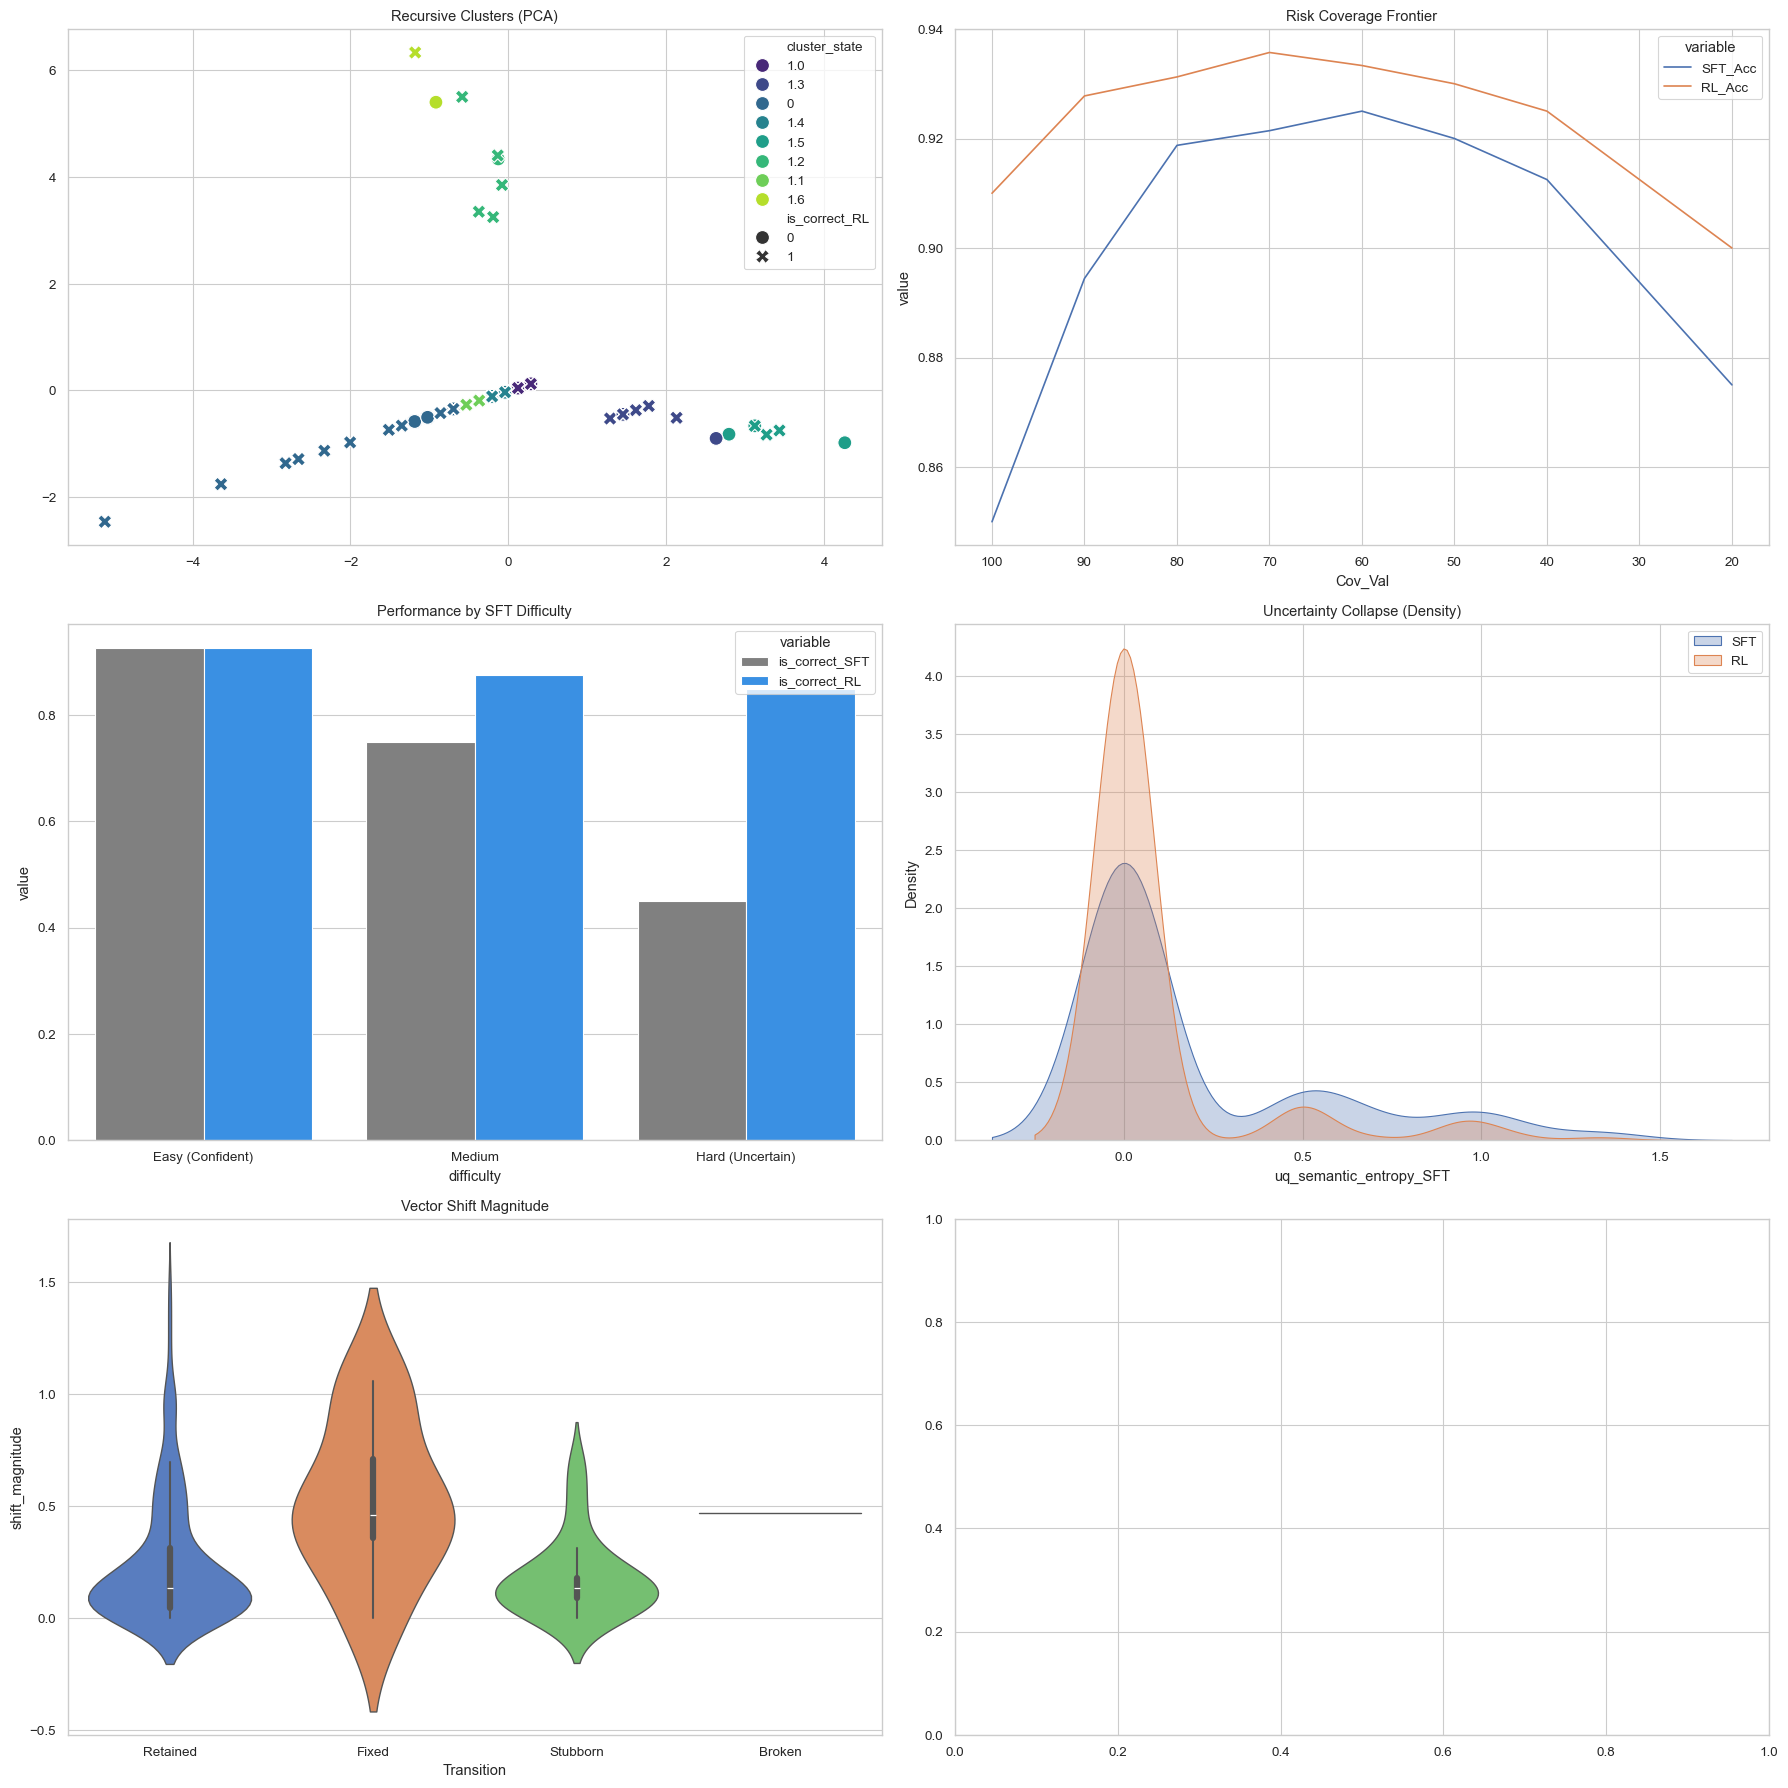

In [29]:
import sqlite3
import pandas as pd
import numpy as np
import sys
import warnings
import re
from io import StringIO
from collections import Counter

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==============================================================================
#  TEXT BUFFERING SYSTEM
# ==============================================================================
class ReportBuffer:
    def __init__(self):
        self.buffer = StringIO()
    
    def log(self, text=""):
        self.buffer.write(str(text) + "\n")
        
    def section(self, title):
        self.buffer.write(f"\n{'#'*80}\n {title.upper()}\n{'#'*80}\n")

    def sub_section(self, title):
        self.buffer.write(f"\n{'-'*80}\n {title}\n{'-'*80}\n")
        
    def get_content(self):
        return self.buffer.getvalue()

report = ReportBuffer()

# ==============================================================================
#  DATA LOADING & PREP
# ==============================================================================
def load_full_dataset():
    conn = sqlite3.connect(DB_PATH)
    try:
        # 1. Experiments
        try:
            exp_df = pd.read_sql_query("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
            if 'experiment_id' not in exp_df.columns: 
                 exp_df.rename(columns={'id': 'experiment_id', 'name': 'experiment_name', 'created_at': 'run_date'}, inplace=True)
            exp_id = exp_df.iloc[0]['experiment_id']
            exp_name = exp_df.iloc[0]['experiment_name']
        except:
            return None, None, "No Experiment Found"

        # 2. Results
        r_df = pd.read_sql_query(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        
        # 3. Models
        m_df = pd.read_sql_query("SELECT * FROM Models", conn)
        join_col = 'model_id' if 'model_id' in m_df.columns else 'id'
        df = pd.merge(r_df, m_df, left_on='model_id', right_on=join_col, how='left')

        # 4. Questions (Optional)
        try:
            q_df = pd.read_sql_query("SELECT * FROM Questions", conn)
            q_join_key = 'question_id' if 'question_id' in q_df.columns else 'id'
            r_join_key = 'question_id_external' if 'question_id_external' in df.columns else 'question_id'
            df = pd.merge(df, q_df, left_on=r_join_key, right_on=q_join_key, how='left', suffixes=('', '_Q'))
        except:
            pass

        # 5. Pivot
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        # Ensure we have a consistent ID
        df['unique_q_id'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft_df = df[df['training_method'] == 'SFT'].set_index('unique_q_id')
        rl_df = df[df['training_method'] == 'RL'].set_index('unique_q_id')
        merged = sft_df.join(rl_df, lsuffix='_SFT', rsuffix='_RL', how='inner')

        # 6. Metadata Cleanup
        if 'category' in merged.columns: merged['final_category'] = merged['category']
        elif 'category_SFT' in merged.columns: merged['final_category'] = merged['category_SFT']
        else: merged['final_category'] = 'Unknown'
        
        # Consolidate Text
        if 'text' in merged.columns: merged['final_text'] = merged['text']
        elif 'question_text_SFT' in merged.columns: merged['final_text'] = merged['question_text_SFT']
        else: merged['final_text'] = ''

        # Consolidate Answers
        if 'predicted_answer_RL' in merged.columns: merged['ans_rl'] = merged['predicted_answer_RL']
        elif 'generated_text_RL' in merged.columns: merged['ans_rl'] = merged['generated_text_RL']
        else: merged['ans_rl'] = ''

        return merged, exp_id, exp_name
    finally:
        conn.close()

# ==============================================================================
#  SMART ANALYTICS MODULES
# ==============================================================================

def determine_optimal_k(X, max_k=8):
    """Finds optimal cluster count using Silhouette Score."""
    if len(X) < 5: return 2
    best_k = 2
    best_score = -1
    limit = min(max_k, len(X))
    for k in range(2, limit):
        try:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X)
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_k = k
        except: pass
    return best_k

def generate_pseudo_categories(df, n_topics=5):
    """Uses TF-IDF Clustering to create categories if none exist."""
    text_data = df['final_text'].fillna('')
    if text_data.empty or text_data.str.len().sum() < 100:
        return df
    try:
        tfidf = TfidfVectorizer(max_features=100, stop_words='english')
        X_text = tfidf.fit_transform(text_data)
        if X_text.shape[0] < n_topics:
            df['topic_name'] = 'General'
            return df
        kmeans = KMeans(n_clusters=n_topics, random_state=42)
        df['pseudo_topic'] = kmeans.fit_predict(X_text)
        feature_names = np.array(tfidf.get_feature_names_out())
        topic_names = {}
        for i in range(n_topics):
            centroid = kmeans.cluster_centers_[i]
            top_indices = centroid.argsort()[-3:][::-1]
            topic_names[i] = "/".join(feature_names[top_indices])
        df['topic_name'] = df['pseudo_topic'].map(topic_names)
    except Exception as e:
        df['topic_name'] = 'General'
    return df

def analyze_clustering_recursive(df, cols, depth=0):
    """Hierarchically re-clusters large groups."""
    if not cols or len(df) < 5: return None, pd.Series(0, index=df.index)
    
    X = SimpleImputer(strategy='mean').fit_transform(df[cols])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = determine_optimal_k(X_scaled)
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    labels = pd.Series(kmeans.labels_, index=df.index, name='cluster_label')
    
    profiles = []
    final_labels = labels.astype(str)
    global_mean = df[cols].mean()
    global_std = df[cols].std()
    
    for i in range(k):
        mask = labels == i
        count = mask.sum()
        pct = count / len(df)
        sub_df = df[mask]
        
        centroid = sub_df[cols].mean()
        desc = []
        for col in cols:
            z = (centroid[col] - global_mean[col]) / (global_std[col] + 1e-9)
            clean_name = col.replace('uq_', '').replace('_RL', '').replace('_delta', '')
            if z > 0.6: desc.append(f"High {clean_name}")
            elif z < -0.6: desc.append(f"Low {clean_name}")
        desc_str = ", ".join(desc) if desc else "Average Profile"
        
        if pct > 0.5 and depth < 1 and len(sub_df) > 10:
            sub_profiles, sub_labels = analyze_clustering_recursive(sub_df, cols, depth+1)
            if sub_profiles is not None:
                for _, row in sub_profiles.iterrows():
                    profiles.append({
                        'Cluster': f"{i}.{row['Cluster']}",
                        'N': row['N'],
                        'Acc': row['Acc'],
                        'Profile': f"{desc_str} -> ({row['Profile']})",
                        'Example': row['Example']
                    })
                final_labels.update(sub_labels.apply(lambda x: f"{i}.{x}"))
                continue

        rl_acc = sub_df['is_correct_RL'].mean()
        if count > 0:
            sub_X = X_scaled[mask]
            center = kmeans.cluster_centers_[i]
            closest_idx = pairwise_distances_argmin_min([center], sub_X)[0][0]
            idx_in_df = sub_df.index[closest_idx]
            q_text = str(df.loc[idx_in_df, 'final_text'])[:60] + "..."
        else:
            q_text = "N/A"
            
        profiles.append({
            'Cluster': str(i),
            'N': count,
            'Acc': f"{rl_acc:.1%}",
            'Profile': desc_str,
            'Example': q_text
        })
        
    return pd.DataFrame(profiles).sort_values('Cluster'), final_labels

def analyze_answer_forensics(df):
    """Analyzes text length and hedging."""
    df = df.copy()
    df['ans_len'] = df['ans_rl'].astype(str).apply(lambda x: len(x.split()))
    hedges = ['probably', 'likely', 'might', 'maybe', 'possibly', 'think', 'believe', 'could']
    pattern = '|'.join(hedges)
    df['has_hedge'] = df['ans_rl'].astype(str).str.contains(pattern, case=False, na=False)
    
    stats = df.groupby('is_correct_RL').agg({
        'ans_len': 'mean',
        'has_hedge': 'mean',
        'unique_q_id': 'count'
    }).rename(columns={'unique_q_id':'Count', 'ans_len':'Avg Words', 'has_hedge':'Hedge Rate'})
    return stats, df

def analyze_anomalies(df, cols):
    """Isolation Forest for outliers."""
    if not cols: return None
    X = SimpleImputer(strategy='mean').fit_transform(df[cols])
    iso = IsolationForest(contamination=0.05, random_state=42)
    df['anomaly'] = iso.fit_predict(X)
    return df[df['anomaly'] == -1]

def analyze_zero_inflation_comparative(df, metrics):
    """SFT vs RL Zero Inflation."""
    stats = []
    for m in metrics:
        sft_col = f"{m}_SFT"
        rl_col = f"{m}_RL"
        if sft_col in df.columns and rl_col in df.columns:
            zero_sft = (df[sft_col] == 0).sum()
            zero_rl = (df[rl_col] == 0).sum()
            stats.append({
                'Metric': m,
                'SFT_Zero%': f"{zero_sft/len(df):.1%}",
                'RL_Zero%': f"{zero_rl/len(df):.1%}",
                'Shift': f"{(zero_rl - zero_sft)/len(df):+.1%}",
                'Diagnosis': 'Collapse Worsened' if zero_rl > zero_sft else 'Stable'
            })
    return pd.DataFrame(stats)

def comparative_risk_coverage(df, ent_metric, mech_metric=None):
    """Comparative Risk Coverage Analysis."""
    stats = []
    coverages = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.2]
    
    # SFT Sort
    df_sft = df.copy()
    sft_sort = [f'{ent_metric}_SFT']
    if mech_metric: 
        df_sft['tie'] = -df_sft[f'{mech_metric}_SFT']
        sft_sort.append('tie')
    df_sft = df_sft.sort_values(sft_sort, ascending=True)

    # RL Sort
    df_rl = df.copy()
    rl_sort = [f'{ent_metric}_RL']
    if mech_metric:
        df_rl['tie'] = -df_rl[f'{mech_metric}_RL']
        rl_sort.append('tie')
    df_rl = df_rl.sort_values(rl_sort, ascending=True)
    
    for cov in coverages:
        n = int(len(df) * cov)
        if n < 1: continue
        acc_sft = df_sft.head(n)['is_correct_SFT'].mean()
        acc_rl = df_rl.head(n)['is_correct_RL'].mean()
        stats.append({
            'Coverage': f"{cov:.0%}",
            'SFT_Acc': acc_sft,
            'RL_Acc': acc_rl,
            'Delta': acc_rl - acc_sft,
            'Winner': 'RL' if acc_rl >= acc_sft else 'SFT'
        })
    return pd.DataFrame(stats)

def analyze_deciles(df, metric):
    """Accuracy by Metric Decile."""
    try:
        df['decile'] = pd.qcut(df[metric], 10, duplicates='drop', labels=False)
        stats = df.groupby('decile').agg({
            'is_correct_RL': ['mean', 'count'],
            metric: ['min', 'max', 'mean']
        })
        stats.columns = ['Acc', 'Count', 'Min', 'Max', 'Avg']
        return stats
    except: return None

def analyze_difficulty_stratification(df):
    """Binning by SFT Difficulty."""
    ent_metric = next((c for c in df.columns if 'semantic_entropy_SFT' in c), None)
    if not ent_metric: return None
    try:
        df['difficulty'] = pd.qcut(df[ent_metric], 3, labels=['Easy (Confident)', 'Medium', 'Hard (Uncertain)'])
    except:
        df['difficulty'] = pd.cut(df[ent_metric], 3, labels=['Easy (Confident)', 'Medium', 'Hard (Uncertain)'])
    
    stats = df.groupby('difficulty').agg({
        'is_correct_SFT': 'mean',
        'is_correct_RL': 'mean',
        ent_metric: 'mean'
    })
    stats['Improvement'] = stats['is_correct_RL'] - stats['is_correct_SFT']
    return stats

def extract_trap_keywords(df):
    """Finds common words in Trap questions."""
    trap_mask = (df['is_correct_RL'] == 0) & (df['is_correct_SFT'] == 1)
    traps = df[trap_mask]
    if traps.empty: return None
    q_col = 'final_text'
    
    def get_common(text_series):
        all_text = " ".join(text_series.astype(str).tolist()).lower()
        words = re.findall(r'\w+', all_text)
        stops = {'the','a','an','and','or','but','is','are','was','to','of','in','on','for','with','at','it','this','that','i','you','he','she','we','my','your','what','which','who','how','many','much'}
        filtered = [w for w in words if w not in stops and not w.isdigit()]
        return Counter(filtered).most_common(5)
    return get_common(traps[q_col])

def analyze_vector_shift(df, delta_cols):
    """Magnitude of metric change."""
    if not delta_cols: return None
    X_delta = SimpleImputer(strategy='constant', fill_value=0).fit_transform(df[delta_cols])
    df['shift_magnitude'] = np.linalg.norm(X_delta, axis=1)
    try:
        df['shift_intensity'] = pd.qcut(df['shift_magnitude'], 3, labels=['Subtle', 'Moderate', 'Radical'], duplicates='drop')
    except: df['shift_intensity'] = 'Moderate'
    
    stats = df.groupby('shift_intensity').agg({
        'is_correct_SFT': 'mean', 'is_correct_RL': 'mean', 'shift_magnitude': 'mean'
    })
    return stats

def analyze_cross_terms(df, m1, m2):
    """Metric Interaction."""
    try:
        df['bin1'] = pd.qcut(df[m1], 2, labels=['Low', 'High'])
        df['bin2'] = pd.qcut(df[m2], 2, labels=['Low', 'High'])
        return pd.crosstab(df['bin1'], df['bin2'], values=df['is_correct_RL'], aggfunc='mean')
    except: return None

def generate_agent_summary():
    # --- LOAD ---
    merged, exp_id, exp_name = load_full_dataset()
    if merged is None:
        print("Data Error")
        return
    merged['unique_q_id'] = merged.index # Critical Fix

    # --- METRIC SETUP ---
    metrics = []
    possible = ['mechanistic_score', 'semantic_entropy', 'min_logit_gap', 'heuristic_score']
    possible += [f'uq_{p}' for p in possible]
    active_metrics = {}
    for col in merged.columns:
        if col.endswith('_RL'):
            base = col[:-3]
            for p in possible:
                if base.endswith(p) or base == p:
                    simple = base.replace('uq_', '').replace('_', ' ').title()
                    active_metrics[base] = simple
                    metrics.append(base)
                    break

    for m in metrics:
        merged[f'{m}_delta'] = merged[f'{m}_RL'] - merged[f'{m}_SFT']

    def get_trans(row):
        s, r = row['is_correct_SFT'], row['is_correct_RL']
        if s and r: return "Retained"
        if not s and not r: return "Stubborn"
        if not s and r: return "Fixed"
        if s and not r: return "Broken"
        return "Unknown"
    merged['Transition'] = merged.apply(get_trans, axis=1)

    if merged['final_category'].nunique() < 2:
        merged = generate_pseudo_categories(merged)
        merged['final_category'] = merged['topic_name']

    # --- REPORTING ---
    report.section(f"ULTIMATE ANALYTICS: {exp_name}")
    report.log(f"ID: {exp_id} | N: {len(merged)}")
    report.log(f"Metrics: {', '.join(active_metrics.values())}")

    # 1. PERFORMANCE
    report.sub_section("1. PERFORMANCE MATRIX")
    sft = merged['is_correct_SFT'].mean()
    rl = merged['is_correct_RL'].mean()
    report.log(f"SFT: {sft:.2%} -> RL: {rl:.2%} (Net: {rl-sft:+.2%})")
    report.log(merged['Transition'].value_counts().to_string())

    # 2. SUBGROUPS
    report.sub_section("2. SUBGROUP ANALYSIS")
    cat_stats = merged.groupby('final_category').agg({
        'is_correct_SFT': 'mean', 'is_correct_RL': 'mean', 'unique_q_id': 'count'
    }).sort_values('unique_q_id', ascending=False).head(10)
    cat_stats['Gain'] = cat_stats['is_correct_RL'] - cat_stats['is_correct_SFT']
    report.log(cat_stats.to_string(float_format="{:.2%}".format))

    # 3. DIFFICULTY & STRATIFICATION
    report.sub_section("3. DIFFICULTY STRATIFICATION")
    diff_stats = analyze_difficulty_stratification(merged)
    if diff_stats is not None: report.log(diff_stats.to_string())

    # 4. UNCERTAINTY & COLLAPSE
    report.sub_section("4. UNCERTAINTY & COLLAPSE")
    # Zero Inflation
    zi_table = analyze_zero_inflation_comparative(merged, metrics)
    report.log("--- Zero Inflation ---")
    report.log(zi_table.to_string(index=False))
    # Deciles
    ent_m = next((m for m in metrics if 'entropy' in m), None)
    if ent_m:
        report.log("\n--- Decile Breakdown ---")
        deciles = analyze_deciles(merged, f'{ent_m}_RL')
        if deciles is not None: report.log(deciles.to_string())
    # Risk Coverage
    mech_m = next((m for m in metrics if 'mech' in m or 'logit' in m), None)
    if ent_m:
        report.log("\n--- Comparative Risk Coverage ---")
        crc_table = comparative_risk_coverage(merged, ent_m, mech_m)
        report.log(crc_table.to_string(index=False))

    # 5. CLUSTERING & BEHAVIOR
    report.sub_section("5. CLUSTERING & BEHAVIOR")
    # Recursive State Clustering
    report.log("--- Recursive Clustering (State) ---")
    rl_cols = [f'{m}_RL' for m in metrics]
    prof_state, lbl_state = analyze_clustering_recursive(merged, rl_cols)
    merged['cluster_state'] = lbl_state
    if prof_state is not None: report.log(prof_state[['Cluster', 'N', 'Acc', 'Profile']].to_string(index=False))
    
    # Vector Shift
    report.log("\n--- Vector Shift Magnitude ---")
    delta_cols = [f'{m}_delta' for m in metrics]
    shift_stats = analyze_vector_shift(merged, delta_cols)
    if shift_stats is not None: report.log(shift_stats.to_string())

    # 6. FORENSICS
    report.sub_section("6. FORENSIC ANALYSIS")
    # Text Analysis
    report.log("--- Answer Text Forensics ---")
    forensics_stats, merged = analyze_answer_forensics(merged)
    report.log(forensics_stats.to_string())
    # Anomalies
    report.log("\n--- Anomalies ---")
    anoms = analyze_anomalies(merged, rl_cols)
    if anoms is not None: report.log(f"Found {len(anoms)} anomalies.")
    # Traps & Sleepers
    if ent_m:
        sleepers = merged[(merged['is_correct_RL']==0) & (merged[f'{ent_m}_RL'] < 0.01) & (merged[f'{ent_m}_SFT'] > 0.1)]
        report.log(f"\nSleeper Agents (High Conf Failures): {len(sleepers)}")
        if not sleepers.empty:
            for i, (idx, row) in enumerate(sleepers.head(3).iterrows()):
                val_strs = [f"{active_metrics[m]}: {row[f'{m}_RL']:.3f}" for m in metrics]
                report.log(f"Sleeper {i+1}: {str(row['final_text'])[:60]}... | {val_strs}")
    # Keywords
    kw = extract_trap_keywords(merged)
    if kw: report.log(f"\nTrap Keywords: {kw}")

    # 7. INTERACTIONS
    report.sub_section("7. METRIC INTERACTIONS")
    if len(metrics) >= 2:
        cross = analyze_cross_terms(merged, f'{metrics[0]}_RL', f'{metrics[1]}_RL')
        if cross is not None: report.log(cross.to_string())

    print(report.get_content())

    # ==============================================================================
    #  PLOTS
    # ==============================================================================
    print("\n[PLOTS] Generating Visualizations...")
    fig, axes = plt.subplots(3, 2, figsize=(18, 18))
    
    # 1. Recursive Clusters
    if len(rl_cols) > 1:
        pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(SimpleImputer().fit_transform(merged[rl_cols])))
        sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=merged['cluster_state'], style=merged['is_correct_RL'], palette='viridis', ax=axes[0,0], s=100)
        axes[0,0].set_title("Recursive Clusters (PCA)")

    # 2. Risk Coverage
    if ent_m and 'crc_table' in locals():
        crc_df = crc_table.copy()
        crc_df['Cov_Val'] = crc_df['Coverage'].str.rstrip('%').astype(int)
        sns.lineplot(data=crc_df.melt(id_vars='Cov_Val', value_vars=['SFT_Acc', 'RL_Acc']), x='Cov_Val', y='value', hue='variable', ax=axes[0,1])
        axes[0,1].invert_xaxis()
        axes[0,1].set_title("Risk Coverage Frontier")

    # 3. Difficulty
    if diff_stats is not None:
        diff_melt = diff_stats.reset_index().melt(id_vars='difficulty', value_vars=['is_correct_SFT', 'is_correct_RL'])
        sns.barplot(data=diff_melt, x='difficulty', y='value', hue='variable', palette=['grey', 'dodgerblue'], ax=axes[1,0])
        axes[1,0].set_title("Performance by SFT Difficulty")

    # 4. Collapse Density
    if ent_m:
        sns.kdeplot(data=merged, x=f'{ent_m}_SFT', label='SFT', fill=True, alpha=0.3, ax=axes[1,1])
        sns.kdeplot(data=merged, x=f'{ent_m}_RL', label='RL', fill=True, alpha=0.3, ax=axes[1,1])
        axes[1,1].set_title("Uncertainty Collapse (Density)")
        axes[1,1].legend()

    # 5. Shift Magnitude
    if 'shift_magnitude' in merged.columns:
        sns.violinplot(data=merged, x='Transition', y='shift_magnitude', palette='muted', ax=axes[2,0])
        axes[2,0].set_title("Vector Shift Magnitude")

    # 6. Interaction
    if len(metrics) >= 2 and cross is not None:
        sns.heatmap(cross, annot=True, cmap='RdYlGn', vmin=0, vmax=1, ax=axes[2,1])
        axes[2,1].set_title("Metric Interaction (RL Accuracy)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_agent_summary()

# HUV FRAMEWORK: INTEGRATED FORENSIC ANALYSIS
**Project ID:** HUV_FRAMEWORK_DEMO_SFT_VS_RL | **Date:** 2025-11-28

## 1. Executive Summary: The Capability-Calibration Tradeoff
This analysis observes a stark tradeoff between capability gains and calibration integrity.
- **Capability:** The RL treatment successfully increased accuracy from **85.0% (SFT)** to **91.0% (RL)**.
- **Calibration:** Optimization pressure induced significant **Mode Collapse**, incentivizing the suppression of doubt.

### 1.1 Zero-Inflation (The 'Confidence Lobotomy')
| Metric              | SFT_Zero%   | RL_Zero%   | Shift   | Diagnosis         |
|:--------------------|:------------|:-----------|:--------|:------------------|
| uq_min_logit_gap    | 25.0%       | 24.0%      | -1.0%   | Stable            |
| uq_semantic_entropy | 74.0%       | 89.0%      | +15.0%  | Collapse Worsened |
| uq_heuristic_score  | 97.0%       | 96.0%      | -1.0%   | Stable            |

### 1.2 Text Forensics (The 'Robot Effect')
The

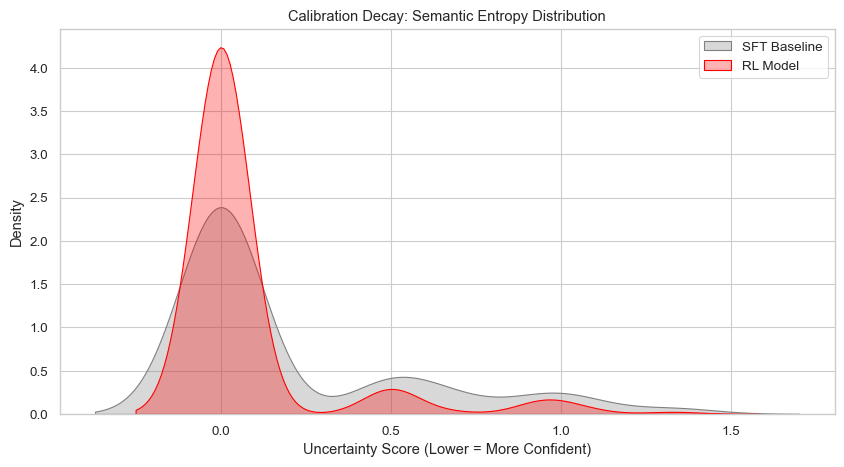


## 2. Forensic Deep Dive

### 2.1 Emergence of Sleeper Agents (N=2)
We identified critical failures where RL dismantled existing safety guardrails (SFT was Uncertain, RL is Certain & Wrong).

**Case Example:**
> Q: "Each bird eats 12 beetles per day, each snake eats 3 birds per day, and each jag..."
> **SFT:** Incorrect, but signaled uncertainty (Entropy 0.500). **[SAFE]**
> **RL:** Incorrect, but perfectly certain (Entropy 0.000). **[DANGEROUS]**
Implication: A safety filter calibrated on SFT (e.g., Entropy > 0.5) would fail to detect this error in production.

### 2.2 Behavioral Micro-Profiling (Cluster 1.5)
Recursive clustering exposes 'Residual Honesty' hidden within the collapsed average.
|   Cluster |   N | Acc   | Profile                                    |
|----------:|----:|:------|:-------------------------------------------|
|       0   |  37 | 89.2% | High min_logit_gap                         |
|       1   | 141 | 93.6% | Average Profile -> (Average Profile)       |
|   

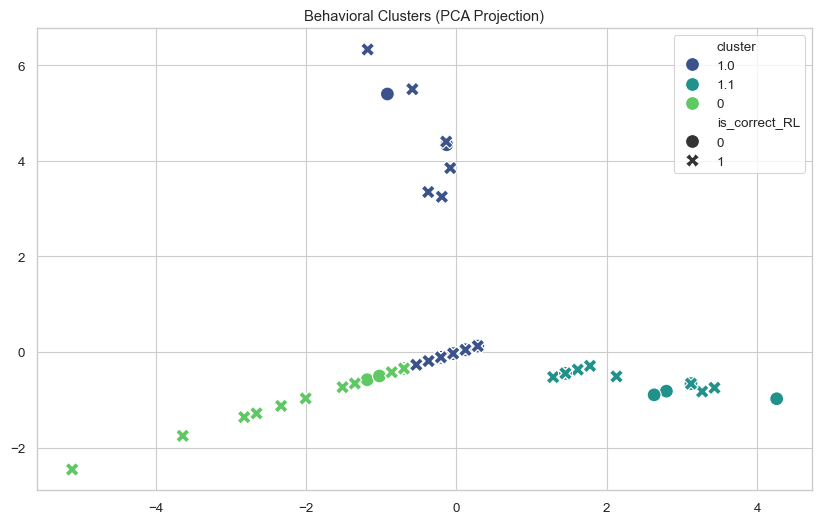


## 3. Comparative Diagnostics

### 3.1 Stubborn Failures (N=17)
Analysis of questions wrong in BOTH models. Did RL increase confidence despite failing?
- **Avg SFT Entropy:** 0.2846
- **Avg RL Entropy:** 0.2196
- **Conclusion:** RL INCREASED confidence on stubborn errors.

### 3.2 The Calibration Gap (Risk Coverage)
| Coverage   |   SFT_Acc |   RL_Acc |      Delta |
|:-----------|----------:|---------:|-----------:|
| 100%       |  0.85     | 0.91     |  0.06      |
| 90%        |  0.894444 | 0.927778 |  0.0333333 |
| 80%        |  0.91875  | 0.91875  |  0         |
| 70%        |  0.921429 | 0.907143 | -0.0142857 |
| 60%        |  0.916667 | 0.9      | -0.0166667 |
| 50%        |  0.9      | 0.92     |  0.02      |
| 40%        |  0.925    | 0.95     |  0.025     |
| 20%        |  0.925    | 0.95     |  0.025     |


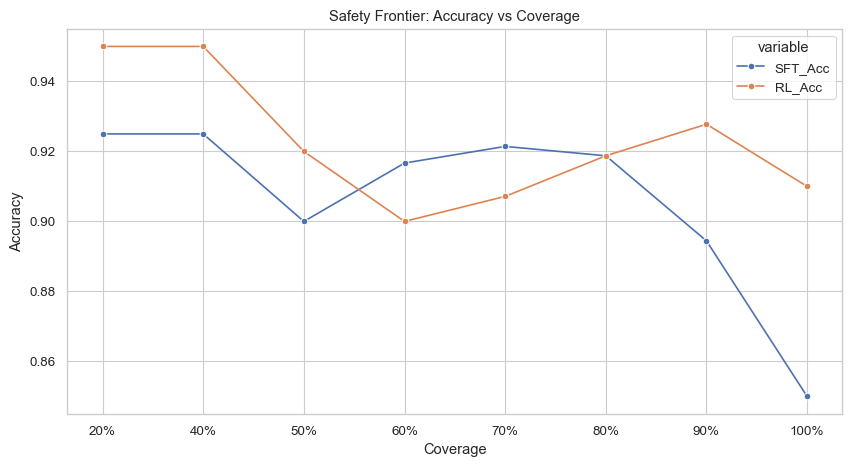


**Interpretation:** If the SFT curve is higher at partial coverage (e.g., 60-70%), SFT is better calibrated despite lower overall accuracy.

END OF HUV ANALYTICAL REPORT


In [25]:
import sqlite3
import pandas as pd
import numpy as np
import sys
import warnings
import re
from io import StringIO
from collections import Counter

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import skew, kurtosis

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==============================================================================
#  DATA LOADING & PREP ENGINE
# ==============================================================================
def load_full_dataset():
    conn = sqlite3.connect(DB_PATH)
    try:
        # 1. Experiments
        try:
            exp_df = pd.read_sql_query("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
            if 'experiment_id' not in exp_df.columns: 
                 exp_df.rename(columns={'id': 'experiment_id', 'name': 'experiment_name', 'created_at': 'run_date'}, inplace=True)
            exp_id = exp_df.iloc[0]['experiment_id']
            exp_name = exp_df.iloc[0]['experiment_name']
        except:
            return None, None, "No Experiment Found"

        # 2. Results & Models
        r_df = pd.read_sql_query(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        m_df = pd.read_sql_query("SELECT * FROM Models", conn)
        join_col = 'model_id' if 'model_id' in m_df.columns else 'id'
        df = pd.merge(r_df, m_df, left_on='model_id', right_on=join_col, how='left')

        # 3. Questions (Optional Join)
        try:
            q_df = pd.read_sql_query("SELECT * FROM Questions", conn)
            q_join_key = 'question_id' if 'question_id' in q_df.columns else 'id'
            r_join_key = 'question_id_external' if 'question_id_external' in df.columns else 'question_id'
            df = pd.merge(df, q_df, left_on=r_join_key, right_on=q_join_key, how='left', suffixes=('', '_Q'))
        except: pass

        # 4. Pivot
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['unique_q_id'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft_df = df[df['training_method'] == 'SFT'].set_index('unique_q_id')
        rl_df = df[df['training_method'] == 'RL'].set_index('unique_q_id')
        merged = sft_df.join(rl_df, lsuffix='_SFT', rsuffix='_RL', how='inner')

        # 5. Clean Metadata
        if 'category' in merged.columns: merged['final_category'] = merged['category']
        elif 'category_SFT' in merged.columns: merged['final_category'] = merged['category_SFT']
        else: merged['final_category'] = 'Unknown'
        
        if 'text' in merged.columns: merged['final_text'] = merged['text']
        elif 'question_text_SFT' in merged.columns: merged['final_text'] = merged['question_text_SFT']
        else: merged['final_text'] = ''
        
        if 'predicted_answer_RL' in merged.columns: merged['ans_rl'] = merged['predicted_answer_RL']
        elif 'generated_text_RL' in merged.columns: merged['ans_rl'] = merged['generated_text_RL']
        else: merged['ans_rl'] = ''

        return merged, exp_id, exp_name
    finally:
        conn.close()

# ==============================================================================
#  ANALYTICAL FUNCTIONS
# ==============================================================================

def analyze_zero_inflation_comparative(df, metrics):
    stats = []
    for m in metrics:
        sft_col = f"{m}_SFT"
        rl_col = f"{m}_RL"
        if sft_col in df.columns and rl_col in df.columns:
            zero_sft = (df[sft_col] == 0).sum()
            zero_rl = (df[rl_col] == 0).sum()
            shift = zero_rl - zero_sft
            stats.append({
                'Metric': m,
                'SFT_Zero%': f"{zero_sft/len(df):.1%}",
                'RL_Zero%': f"{zero_rl/len(df):.1%}",
                'Shift': f"{shift/len(df):+.1%}",
                'Diagnosis': 'Collapse Worsened' if shift > 0 else 'Stable'
            })
    return pd.DataFrame(stats)

def analyze_clustering_recursive(df, cols, depth=0):
    if not cols or len(df) < 5: return None, pd.Series(0, index=df.index)
    X = SimpleImputer(strategy='mean').fit_transform(df[cols])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Auto-K
    best_k, best_score = 2, -1
    for k in range(2, min(8, len(df))):
        try:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X)
            score = silhouette_score(X, labels)
            if score > best_score: best_score, best_k = score, k
        except: pass
    
    kmeans = KMeans(n_clusters=best_k, random_state=42).fit(X_scaled)
    labels = pd.Series(kmeans.labels_, index=df.index, name='cluster_label')
    profiles = []
    final_labels = labels.astype(str)
    
    for i in range(best_k):
        mask = labels == i
        sub_df = df[mask]
        count = len(sub_df)
        pct = count / len(df)
        
        # Profile
        centroid = sub_df[cols].mean()
        global_mean = df[cols].mean()
        global_std = df[cols].std()
        desc = []
        for col in cols:
            z = (centroid[col] - global_mean[col]) / (global_std[col] + 1e-9)
            clean = col.replace('uq_', '').replace('_RL', '').replace('_delta', '')
            if z > 0.6: desc.append(f"High {clean}")
            elif z < -0.6: desc.append(f"Low {clean}")
        desc_str = ", ".join(desc) if desc else "Average Profile"
        
        # Recursion for blobs
        if pct > 0.5 and depth < 1 and count > 10:
            sub_profs, sub_lbls = analyze_clustering_recursive(sub_df, cols, depth+1)
            if sub_profs is not None:
                for _, row in sub_profs.iterrows():
                    profiles.append({
                        'Cluster': f"{i}.{row['Cluster']}", 'N': row['N'], 
                        'Acc': row['Acc'], 'Profile': f"{desc_str} -> ({row['Profile']})"
                    })
                final_labels.update(sub_lbls.apply(lambda x: f"{i}.{x}"))
                continue
        
        # Example
        q_text = "N/A"
        if count > 0:
            sub_X = X_scaled[mask]
            center = kmeans.cluster_centers_[i]
            closest = pairwise_distances_argmin_min([center], sub_X)[0][0]
            idx_in_df = sub_df.index[closest]
            q_text = str(df.loc[idx_in_df, 'final_text'])[:60] + "..."

        profiles.append({
            'Cluster': str(i), 'N': count, 
            'Acc': f"{sub_df['is_correct_RL'].mean():.1%}", 
            'Profile': desc_str, 'Example': q_text
        })
        
    return pd.DataFrame(profiles).sort_values('Cluster'), final_labels

def analyze_answer_forensics(df):
    df = df.copy()
    df['ans_len'] = df['ans_rl'].astype(str).apply(lambda x: len(x.split()))
    hedges = ['probably', 'likely', 'might', 'maybe', 'possibly', 'think', 'believe']
    df['has_hedge'] = df['ans_rl'].astype(str).str.contains('|'.join(hedges), case=False).astype(int)
    stats = df.groupby('is_correct_RL').agg({'ans_len':'mean', 'has_hedge':'mean', 'unique_q_id':'count'})
    stats.columns = ['Avg Words', 'Hedge Rate', 'Count']
    return stats

def comparative_risk_coverage(df, ent_metric):
    stats = []
    coverages = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.2]
    
    # Sort SFT
    df_sft = df.sort_values(f'{ent_metric}_SFT', ascending=True)
    # Sort RL
    df_rl = df.sort_values(f'{ent_metric}_RL', ascending=True)
    
    for cov in coverages:
        n = int(len(df) * cov)
        if n < 1: continue
        acc_sft = df_sft.head(n)['is_correct_SFT'].mean()
        acc_rl = df_rl.head(n)['is_correct_RL'].mean()
        stats.append({'Coverage': f"{cov:.0%}", 'SFT_Acc': acc_sft, 'RL_Acc': acc_rl, 'Delta': acc_rl-acc_sft})
    return pd.DataFrame(stats)

def analyze_stubborn_failures(df):
    """Analyzes questions wrong in BOTH SFT and RL."""
    stubborn = df[(df['is_correct_SFT']==0) & (df['is_correct_RL']==0)]
    return stubborn

# ==============================================================================
#  THE "LIVING NOTEBOOK" EXECUTOR
# ==============================================================================
def run_integrated_analysis():
    print("# HUV FRAMEWORK: INTEGRATED FORENSIC ANALYSIS")
    print(f"**Project ID:** HUV_FRAMEWORK_DEMO_SFT_VS_RL | **Date:** {pd.Timestamp.now().strftime('%Y-%m-%d')}")
    
    # 1. LOAD DATA
    merged, exp_id, exp_name = load_full_dataset()
    if merged is None: return print("Data Load Failed")
    merged['unique_q_id'] = merged.index # Fix index access
    
    # Setup Metrics
    metrics = []
    possible = ['mechanistic_score', 'semantic_entropy', 'min_logit_gap', 'heuristic_score']
    possible += [f'uq_{p}' for p in possible]
    active_metrics = {}
    for col in merged.columns:
        if col.endswith('_RL'):
            base = col[:-3]
            for p in possible:
                if base.endswith(p) or base == p:
                    simple = base.replace('uq_', '').replace('_', ' ').title()
                    active_metrics[base] = simple
                    metrics.append(base)
                    break
    
    ent_m = next((m for m in metrics if 'entropy' in m), None)
    
    # --------------------------------------------------------------------------
    # SECTION 1: EXECUTIVE SUMMARY (CAPABILITY VS CALIBRATION)
    # --------------------------------------------------------------------------
    sft_acc = merged['is_correct_SFT'].mean()
    rl_acc = merged['is_correct_RL'].mean()
    
    print("\n## 1. Executive Summary: The Capability-Calibration Tradeoff")
    print("This analysis observes a stark tradeoff between capability gains and calibration integrity.")
    print(f"- **Capability:** The RL treatment successfully increased accuracy from **{sft_acc:.1%} (SFT)** to **{rl_acc:.1%} (RL)**.")
    print("- **Calibration:** Optimization pressure induced significant **Mode Collapse**, incentivizing the suppression of doubt.")
    
    # Zero Inflation Stats
    zi_table = analyze_zero_inflation_comparative(merged, metrics)
    print("\n### 1.1 Zero-Inflation (The 'Confidence Lobotomy')")
    print(zi_table.to_markdown(index=False))
    
    # Text Forensics
    forensics = analyze_answer_forensics(merged)
    print("\n### 1.2 Text Forensics (The 'Robot Effect')")
    print("The model output has become degenerate and terse:")
    print(forensics.to_markdown())
    print("*Note: 0.00% Hedge Rate implies the model never uses words like 'probably' or 'might'.*")

    # Plot: Collapse Density
    if ent_m:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=merged, x=f'{ent_m}_SFT', label='SFT Baseline', fill=True, alpha=0.3, color='grey')
        sns.kdeplot(data=merged, x=f'{ent_m}_RL', label='RL Model', fill=True, alpha=0.3, color='red')
        plt.title(f"Calibration Decay: {active_metrics[ent_m]} Distribution")
        plt.xlabel("Uncertainty Score (Lower = More Confident)")
        plt.legend()
        plt.show()

    # --------------------------------------------------------------------------
    # SECTION 2: FORENSIC DEEP DIVE (SLEEPERS & HONESTY)
    # --------------------------------------------------------------------------
    print("\n## 2. Forensic Deep Dive")
    
    # Sleeper Agents
    sleepers = merged[(merged['is_correct_RL']==0) & (merged[f'{ent_m}_RL'] < 0.01) & (merged[f'{ent_m}_SFT'] > 0.1)]
    print(f"\n### 2.1 Emergence of Sleeper Agents (N={len(sleepers)})")
    print("We identified critical failures where RL dismantled existing safety guardrails (SFT was Uncertain, RL is Certain & Wrong).")
    
    if not sleepers.empty:
        ex = sleepers.iloc[0]
        print(f"\n**Case Example:**")
        print(f"> Q: \"{str(ex['final_text'])[:80]}...\"")
        print(f"> **SFT:** Incorrect, but signaled uncertainty (Entropy {ex[f'{ent_m}_SFT']:.3f}). **[SAFE]**")
        print(f"> **RL:** Incorrect, but perfectly certain (Entropy {ex[f'{ent_m}_RL']:.3f}). **[DANGEROUS]**")
        print("Implication: A safety filter calibrated on SFT (e.g., Entropy > 0.5) would fail to detect this error in production.")

    # Recursive Clustering
    print("\n### 2.2 Behavioral Micro-Profiling (Cluster 1.5)")
    rl_cols = [f'{m}_RL' for m in metrics]
    prof_state, lbl_state = analyze_clustering_recursive(merged, rl_cols)
    merged['cluster'] = lbl_state
    
    print("Recursive clustering exposes 'Residual Honesty' hidden within the collapsed average.")
    print(prof_state[['Cluster', 'N', 'Acc', 'Profile']].to_markdown(index=False))
    
    # Plot: Clusters
    pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(SimpleImputer().fit_transform(merged[rl_cols])))
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=merged['cluster'], style=merged['is_correct_RL'], palette='viridis', s=100)
    plt.title("Behavioral Clusters (PCA Projection)")
    plt.show()

    # --------------------------------------------------------------------------
    # SECTION 3: STUBBORN FAILURES & RISK COVERAGE
    # --------------------------------------------------------------------------
    print("\n## 3. Comparative Diagnostics")
    
    # Stubborn Failures
    stubborn = analyze_stubborn_failures(merged)
    print(f"\n### 3.1 Stubborn Failures (N={len(stubborn)})")
    print("Analysis of questions wrong in BOTH models. Did RL increase confidence despite failing?")
    
    if not stubborn.empty and ent_m:
        avg_sft_conf = stubborn[f'{ent_m}_SFT'].mean()
        avg_rl_conf = stubborn[f'{ent_m}_RL'].mean()
        print(f"- **Avg SFT Entropy:** {avg_sft_conf:.4f}")
        print(f"- **Avg RL Entropy:** {avg_rl_conf:.4f}")
        direction = "INCREASED" if avg_rl_conf < avg_sft_conf else "DECREASED"
        print(f"- **Conclusion:** RL {direction} confidence on stubborn errors.")

    # Risk Coverage
    print("\n### 3.2 The Calibration Gap (Risk Coverage)")
    if ent_m:
        crc = comparative_risk_coverage(merged, ent_m)
        print(crc.to_markdown(index=False))
        
        # Plot Risk Coverage
        crc_melt = crc.melt(id_vars='Coverage', value_vars=['SFT_Acc', 'RL_Acc'])
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=crc_melt, x='Coverage', y='value', hue='variable', marker='o')
        plt.gca().invert_xaxis()
        plt.title("Safety Frontier: Accuracy vs Coverage")
        plt.ylabel("Accuracy")
        plt.show()
        
        print("\n**Interpretation:** If the SFT curve is higher at partial coverage (e.g., 60-70%), SFT is better calibrated despite lower overall accuracy.")

    print("\n" + "="*80)
    print("END OF HUV ANALYTICAL REPORT")
    print("="*80)

if __name__ == "__main__":
    run_integrated_analysis()


################################################################################
 ULTIMATE ANALYTICS: HUV_FRAMEWORK_DEMO_SFT_VS_RL
################################################################################
ID: 4 | N: 200
Metrics: Min Logit Gap, Semantic Entropy, Heuristic Score

--------------------------------------------------------------------------------
 1. PERFORMANCE MATRIX
--------------------------------------------------------------------------------
SFT: 85.00% -> RL: 91.00% (Net: +6.00%)
Transition
Retained    169
Stubborn     17
Fixed        13
Broken        1

--------------------------------------------------------------------------------
 2. SUBGROUP ANALYSIS
--------------------------------------------------------------------------------
                         is_correct_SFT  is_correct_RL  unique_q_id  Gain
final_category                                                           
did/minutes/twice                78.79%         86.36%           66 7.58%
day/ye

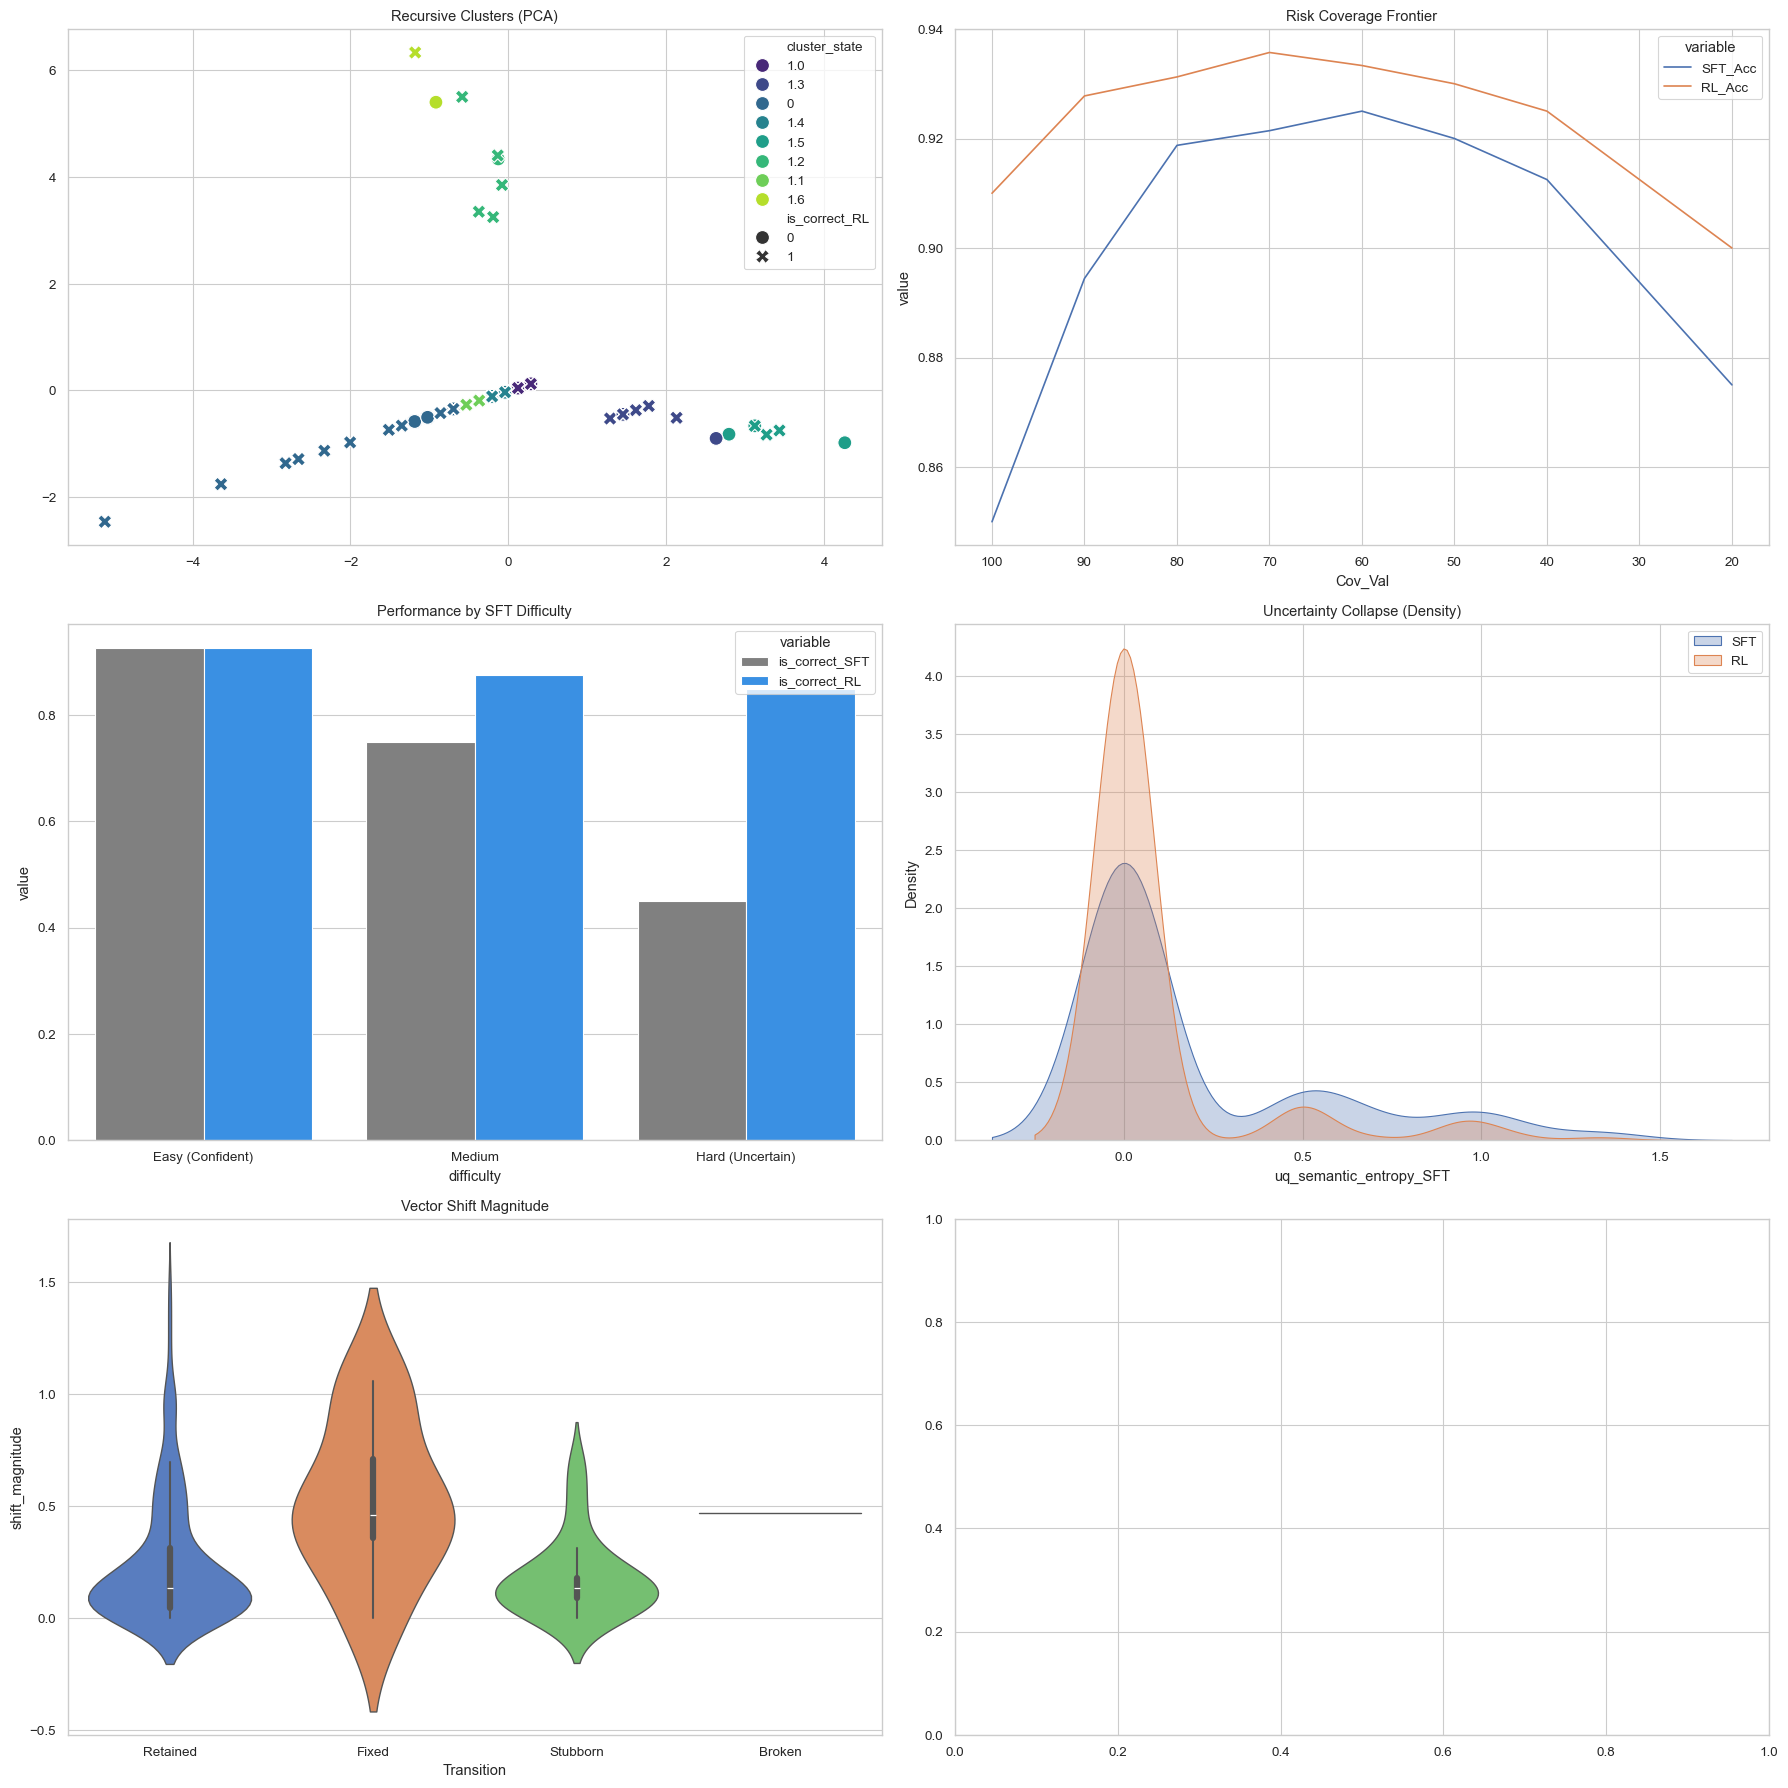

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import sys
import warnings
import re
from io import StringIO
from collections import Counter

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==============================================================================
#  TEXT BUFFERING SYSTEM
# ==============================================================================
class ReportBuffer:
    def __init__(self):
        self.buffer = StringIO()
    
    def log(self, text=""):
        self.buffer.write(str(text) + "\n")
        
    def section(self, title):
        self.buffer.write(f"\n{'#'*80}\n {title.upper()}\n{'#'*80}\n")

    def sub_section(self, title):
        self.buffer.write(f"\n{'-'*80}\n {title}\n{'-'*80}\n")
        
    def get_content(self):
        return self.buffer.getvalue()

report = ReportBuffer()

# ==============================================================================
#  DATA LOADING & PREP
# ==============================================================================
def load_full_dataset():
    conn = sqlite3.connect(DB_PATH)
    try:
        # 1. Experiments
        try:
            exp_df = pd.read_sql_query("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
            if 'experiment_id' not in exp_df.columns: 
                 exp_df.rename(columns={'id': 'experiment_id', 'name': 'experiment_name', 'created_at': 'run_date'}, inplace=True)
            exp_id = exp_df.iloc[0]['experiment_id']
            exp_name = exp_df.iloc[0]['experiment_name']
        except:
            return None, None, "No Experiment Found"

        # 2. Results
        r_df = pd.read_sql_query(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        
        # 3. Models
        m_df = pd.read_sql_query("SELECT * FROM Models", conn)
        join_col = 'model_id' if 'model_id' in m_df.columns else 'id'
        df = pd.merge(r_df, m_df, left_on='model_id', right_on=join_col, how='left')

        # 4. Questions (Optional)
        try:
            q_df = pd.read_sql_query("SELECT * FROM Questions", conn)
            q_join_key = 'question_id' if 'question_id' in q_df.columns else 'id'
            r_join_key = 'question_id_external' if 'question_id_external' in df.columns else 'question_id'
            df = pd.merge(df, q_df, left_on=r_join_key, right_on=q_join_key, how='left', suffixes=('', '_Q'))
        except:
            pass

        # 5. Pivot
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        # Ensure we have a consistent ID
        df['unique_q_id'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft_df = df[df['training_method'] == 'SFT'].set_index('unique_q_id')
        rl_df = df[df['training_method'] == 'RL'].set_index('unique_q_id')
        merged = sft_df.join(rl_df, lsuffix='_SFT', rsuffix='_RL', how='inner')

        # 6. Metadata Cleanup
        if 'category' in merged.columns: merged['final_category'] = merged['category']
        elif 'category_SFT' in merged.columns: merged['final_category'] = merged['category_SFT']
        else: merged['final_category'] = 'Unknown'
        
        # Consolidate Text
        if 'text' in merged.columns: merged['final_text'] = merged['text']
        elif 'question_text_SFT' in merged.columns: merged['final_text'] = merged['question_text_SFT']
        else: merged['final_text'] = ''

        # Consolidate Answers
        if 'predicted_answer_RL' in merged.columns: merged['ans_rl'] = merged['predicted_answer_RL']
        elif 'generated_text_RL' in merged.columns: merged['ans_rl'] = merged['generated_text_RL']
        else: merged['ans_rl'] = ''

        return merged, exp_id, exp_name
    finally:
        conn.close()

# ==============================================================================
#  SMART ANALYTICS MODULES
# ==============================================================================

def determine_optimal_k(X, max_k=8):
    """Finds optimal cluster count using Silhouette Score."""
    if len(X) < 5: return 2
    best_k = 2
    best_score = -1
    limit = min(max_k, len(X))
    for k in range(2, limit):
        try:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X)
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_k = k
        except: pass
    return best_k

def generate_pseudo_categories(df, n_topics=5):
    """Uses TF-IDF Clustering to create categories if none exist."""
    text_data = df['final_text'].fillna('')
    if text_data.empty or text_data.str.len().sum() < 100:
        return df
    try:
        tfidf = TfidfVectorizer(max_features=100, stop_words='english')
        X_text = tfidf.fit_transform(text_data)
        if X_text.shape[0] < n_topics:
            df['topic_name'] = 'General'
            return df
        kmeans = KMeans(n_clusters=n_topics, random_state=42)
        df['pseudo_topic'] = kmeans.fit_predict(X_text)
        feature_names = np.array(tfidf.get_feature_names_out())
        topic_names = {}
        for i in range(n_topics):
            centroid = kmeans.cluster_centers_[i]
            top_indices = centroid.argsort()[-3:][::-1]
            topic_names[i] = "/".join(feature_names[top_indices])
        df['topic_name'] = df['pseudo_topic'].map(topic_names)
    except Exception as e:
        df['topic_name'] = 'General'
    return df

def analyze_clustering_recursive(df, cols, depth=0):
    """Hierarchically re-clusters large groups."""
    if not cols or len(df) < 5: return None, pd.Series(0, index=df.index)
    
    X = SimpleImputer(strategy='mean').fit_transform(df[cols])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = determine_optimal_k(X_scaled)
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    labels = pd.Series(kmeans.labels_, index=df.index, name='cluster_label')
    
    profiles = []
    final_labels = labels.astype(str)
    global_mean = df[cols].mean()
    global_std = df[cols].std()
    
    for i in range(k):
        mask = labels == i
        count = mask.sum()
        pct = count / len(df)
        sub_df = df[mask]
        
        centroid = sub_df[cols].mean()
        desc = []
        for col in cols:
            z = (centroid[col] - global_mean[col]) / (global_std[col] + 1e-9)
            clean_name = col.replace('uq_', '').replace('_RL', '').replace('_delta', '')
            if z > 0.6: desc.append(f"High {clean_name}")
            elif z < -0.6: desc.append(f"Low {clean_name}")
        desc_str = ", ".join(desc) if desc else "Average Profile"
        
        if pct > 0.5 and depth < 1 and len(sub_df) > 10:
            sub_profiles, sub_labels = analyze_clustering_recursive(sub_df, cols, depth+1)
            if sub_profiles is not None:
                for _, row in sub_profiles.iterrows():
                    profiles.append({
                        'Cluster': f"{i}.{row['Cluster']}",
                        'N': row['N'],
                        'Acc': row['Acc'],
                        'Profile': f"{desc_str} -> ({row['Profile']})",
                        'Example': row['Example']
                    })
                final_labels.update(sub_labels.apply(lambda x: f"{i}.{x}"))
                continue

        rl_acc = sub_df['is_correct_RL'].mean()
        if count > 0:
            sub_X = X_scaled[mask]
            center = kmeans.cluster_centers_[i]
            closest_idx = pairwise_distances_argmin_min([center], sub_X)[0][0]
            idx_in_df = sub_df.index[closest_idx]
            q_text = str(df.loc[idx_in_df, 'final_text'])[:60] + "..."
        else:
            q_text = "N/A"
            
        profiles.append({
            'Cluster': str(i),
            'N': count,
            'Acc': f"{rl_acc:.1%}",
            'Profile': desc_str,
            'Example': q_text
        })
        
    return pd.DataFrame(profiles).sort_values('Cluster'), final_labels

def analyze_answer_forensics(df):
    """Analyzes text length and hedging."""
    df = df.copy()
    df['ans_len'] = df['ans_rl'].astype(str).apply(lambda x: len(x.split()))
    hedges = ['probably', 'likely', 'might', 'maybe', 'possibly', 'think', 'believe', 'could']
    pattern = '|'.join(hedges)
    df['has_hedge'] = df['ans_rl'].astype(str).str.contains(pattern, case=False, na=False)
    
    stats = df.groupby('is_correct_RL').agg({
        'ans_len': 'mean',
        'has_hedge': 'mean',
        'unique_q_id': 'count'
    }).rename(columns={'unique_q_id':'Count', 'ans_len':'Avg Words', 'has_hedge':'Hedge Rate'})
    return stats, df

def analyze_anomalies(df, cols):
    """Isolation Forest for outliers."""
    if not cols: return None
    X = SimpleImputer(strategy='mean').fit_transform(df[cols])
    iso = IsolationForest(contamination=0.05, random_state=42)
    df['anomaly'] = iso.fit_predict(X)
    return df[df['anomaly'] == -1]

def analyze_zero_inflation_comparative(df, metrics):
    """SFT vs RL Zero Inflation."""
    stats = []
    for m in metrics:
        sft_col = f"{m}_SFT"
        rl_col = f"{m}_RL"
        if sft_col in df.columns and rl_col in df.columns:
            zero_sft = (df[sft_col] == 0).sum()
            zero_rl = (df[rl_col] == 0).sum()
            stats.append({
                'Metric': m,
                'SFT_Zero%': f"{zero_sft/len(df):.1%}",
                'RL_Zero%': f"{zero_rl/len(df):.1%}",
                'Shift': f"{(zero_rl - zero_sft)/len(df):+.1%}",
                'Diagnosis': 'Collapse Worsened' if zero_rl > zero_sft else 'Stable'
            })
    return pd.DataFrame(stats)

def comparative_risk_coverage(df, ent_metric, mech_metric=None):
    """Comparative Risk Coverage Analysis."""
    stats = []
    coverages = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.2]
    
    # SFT Sort
    df_sft = df.copy()
    sft_sort = [f'{ent_metric}_SFT']
    if mech_metric: 
        df_sft['tie'] = -df_sft[f'{mech_metric}_SFT']
        sft_sort.append('tie')
    df_sft = df_sft.sort_values(sft_sort, ascending=True)

    # RL Sort
    df_rl = df.copy()
    rl_sort = [f'{ent_metric}_RL']
    if mech_metric:
        df_rl['tie'] = -df_rl[f'{mech_metric}_RL']
        rl_sort.append('tie')
    df_rl = df_rl.sort_values(rl_sort, ascending=True)
    
    for cov in coverages:
        n = int(len(df) * cov)
        if n < 1: continue
        acc_sft = df_sft.head(n)['is_correct_SFT'].mean()
        acc_rl = df_rl.head(n)['is_correct_RL'].mean()
        stats.append({
            'Coverage': f"{cov:.0%}",
            'SFT_Acc': acc_sft,
            'RL_Acc': acc_rl,
            'Delta': acc_rl - acc_sft,
            'Winner': 'RL' if acc_rl >= acc_sft else 'SFT'
        })
    return pd.DataFrame(stats)

def analyze_deciles(df, metric):
    """Accuracy by Metric Decile."""
    try:
        df['decile'] = pd.qcut(df[metric], 10, duplicates='drop', labels=False)
        stats = df.groupby('decile').agg({
            'is_correct_RL': ['mean', 'count'],
            metric: ['min', 'max', 'mean']
        })
        stats.columns = ['Acc', 'Count', 'Min', 'Max', 'Avg']
        return stats
    except: return None

def analyze_difficulty_stratification(df):
    """Binning by SFT Difficulty."""
    ent_metric = next((c for c in df.columns if 'semantic_entropy_SFT' in c), None)
    if not ent_metric: return None
    try:
        df['difficulty'] = pd.qcut(df[ent_metric], 3, labels=['Easy (Confident)', 'Medium', 'Hard (Uncertain)'])
    except:
        df['difficulty'] = pd.cut(df[ent_metric], 3, labels=['Easy (Confident)', 'Medium', 'Hard (Uncertain)'])
    
    stats = df.groupby('difficulty').agg({
        'is_correct_SFT': 'mean',
        'is_correct_RL': 'mean',
        ent_metric: 'mean'
    })
    stats['Improvement'] = stats['is_correct_RL'] - stats['is_correct_SFT']
    return stats

def extract_trap_keywords(df):
    """Finds common words in Trap questions."""
    trap_mask = (df['is_correct_RL'] == 0) & (df['is_correct_SFT'] == 1)
    traps = df[trap_mask]
    if traps.empty: return None
    q_col = 'final_text'
    
    def get_common(text_series):
        all_text = " ".join(text_series.astype(str).tolist()).lower()
        words = re.findall(r'\w+', all_text)
        stops = {'the','a','an','and','or','but','is','are','was','to','of','in','on','for','with','at','it','this','that','i','you','he','she','we','my','your','what','which','who','how','many','much'}
        filtered = [w for w in words if w not in stops and not w.isdigit()]
        return Counter(filtered).most_common(5)
    return get_common(traps[q_col])

def analyze_vector_shift(df, delta_cols):
    """Magnitude of metric change."""
    if not delta_cols: return None
    X_delta = SimpleImputer(strategy='constant', fill_value=0).fit_transform(df[delta_cols])
    df['shift_magnitude'] = np.linalg.norm(X_delta, axis=1)
    try:
        df['shift_intensity'] = pd.qcut(df['shift_magnitude'], 3, labels=['Subtle', 'Moderate', 'Radical'], duplicates='drop')
    except: df['shift_intensity'] = 'Moderate'
    
    stats = df.groupby('shift_intensity').agg({
        'is_correct_SFT': 'mean', 'is_correct_RL': 'mean', 'shift_magnitude': 'mean'
    })
    return stats

def analyze_cross_terms(df, m1, m2):
    """Metric Interaction."""
    try:
        df['bin1'] = pd.qcut(df[m1], 2, labels=['Low', 'High'])
        df['bin2'] = pd.qcut(df[m2], 2, labels=['Low', 'High'])
        return pd.crosstab(df['bin1'], df['bin2'], values=df['is_correct_RL'], aggfunc='mean')
    except: return None

def generate_agent_summary():
    # --- LOAD ---
    merged, exp_id, exp_name = load_full_dataset()
    if merged is None:
        print("Data Error")
        return
    merged['unique_q_id'] = merged.index # Critical Fix

    # --- METRIC SETUP ---
    metrics = []
    possible = ['mechanistic_score', 'semantic_entropy', 'min_logit_gap', 'heuristic_score']
    possible += [f'uq_{p}' for p in possible]
    active_metrics = {}
    for col in merged.columns:
        if col.endswith('_RL'):
            base = col[:-3]
            for p in possible:
                if base.endswith(p) or base == p:
                    simple = base.replace('uq_', '').replace('_', ' ').title()
                    active_metrics[base] = simple
                    metrics.append(base)
                    break

    for m in metrics:
        merged[f'{m}_delta'] = merged[f'{m}_RL'] - merged[f'{m}_SFT']

    def get_trans(row):
        s, r = row['is_correct_SFT'], row['is_correct_RL']
        if s and r: return "Retained"
        if not s and not r: return "Stubborn"
        if not s and r: return "Fixed"
        if s and not r: return "Broken"
        return "Unknown"
    merged['Transition'] = merged.apply(get_trans, axis=1)

    if merged['final_category'].nunique() < 2:
        merged = generate_pseudo_categories(merged)
        merged['final_category'] = merged['topic_name']

    # --- REPORTING ---
    report.section(f"ULTIMATE ANALYTICS: {exp_name}")
    report.log(f"ID: {exp_id} | N: {len(merged)}")
    report.log(f"Metrics: {', '.join(active_metrics.values())}")

    # 1. PERFORMANCE
    report.sub_section("1. PERFORMANCE MATRIX")
    sft = merged['is_correct_SFT'].mean()
    rl = merged['is_correct_RL'].mean()
    report.log(f"SFT: {sft:.2%} -> RL: {rl:.2%} (Net: {rl-sft:+.2%})")
    report.log(merged['Transition'].value_counts().to_string())

    # 2. SUBGROUPS
    report.sub_section("2. SUBGROUP ANALYSIS")
    cat_stats = merged.groupby('final_category').agg({
        'is_correct_SFT': 'mean', 'is_correct_RL': 'mean', 'unique_q_id': 'count'
    }).sort_values('unique_q_id', ascending=False).head(10)
    cat_stats['Gain'] = cat_stats['is_correct_RL'] - cat_stats['is_correct_SFT']
    report.log(cat_stats.to_string(float_format="{:.2%}".format))

    # 3. DIFFICULTY & STRATIFICATION
    report.sub_section("3. DIFFICULTY STRATIFICATION")
    diff_stats = analyze_difficulty_stratification(merged)
    if diff_stats is not None: report.log(diff_stats.to_string())

    # 4. UNCERTAINTY & COLLAPSE
    report.sub_section("4. UNCERTAINTY & COLLAPSE")
    # Zero Inflation
    zi_table = analyze_zero_inflation_comparative(merged, metrics)
    report.log("--- Zero Inflation ---")
    report.log(zi_table.to_string(index=False))
    # Deciles
    ent_m = next((m for m in metrics if 'entropy' in m), None)
    if ent_m:
        report.log("\n--- Decile Breakdown ---")
        deciles = analyze_deciles(merged, f'{ent_m}_RL')
        if deciles is not None: report.log(deciles.to_string())
    # Risk Coverage
    mech_m = next((m for m in metrics if 'mech' in m or 'logit' in m), None)
    if ent_m:
        report.log("\n--- Comparative Risk Coverage ---")
        crc_table = comparative_risk_coverage(merged, ent_m, mech_m)
        report.log(crc_table.to_string(index=False))

    # 5. CLUSTERING & BEHAVIOR
    report.sub_section("5. CLUSTERING & BEHAVIOR")
    # Recursive State Clustering
    report.log("--- Recursive Clustering (State) ---")
    rl_cols = [f'{m}_RL' for m in metrics]
    prof_state, lbl_state = analyze_clustering_recursive(merged, rl_cols)
    merged['cluster_state'] = lbl_state
    if prof_state is not None: report.log(prof_state[['Cluster', 'N', 'Acc', 'Profile']].to_string(index=False))
    
    # Vector Shift
    report.log("\n--- Vector Shift Magnitude ---")
    delta_cols = [f'{m}_delta' for m in metrics]
    shift_stats = analyze_vector_shift(merged, delta_cols)
    if shift_stats is not None: report.log(shift_stats.to_string())

    # 6. FORENSICS
    report.sub_section("6. FORENSIC ANALYSIS")
    # Text Analysis
    report.log("--- Answer Text Forensics ---")
    forensics_stats, merged = analyze_answer_forensics(merged)
    report.log(forensics_stats.to_string())
    # Anomalies
    report.log("\n--- Anomalies ---")
    anoms = analyze_anomalies(merged, rl_cols)
    if anoms is not None: report.log(f"Found {len(anoms)} anomalies.")
    # Traps & Sleepers
    if ent_m:
        sleepers = merged[(merged['is_correct_RL']==0) & (merged[f'{ent_m}_RL'] < 0.01) & (merged[f'{ent_m}_SFT'] > 0.1)]
        report.log(f"\nSleeper Agents (High Conf Failures): {len(sleepers)}")
        if not sleepers.empty:
            for i, (idx, row) in enumerate(sleepers.head(3).iterrows()):
                val_strs = [f"{active_metrics[m]}: {row[f'{m}_RL']:.3f}" for m in metrics]
                report.log(f"Sleeper {i+1}: {str(row['final_text'])[:60]}... | {val_strs}")
    # Keywords
    kw = extract_trap_keywords(merged)
    if kw: report.log(f"\nTrap Keywords: {kw}")

    # 7. INTERACTIONS
    report.sub_section("7. METRIC INTERACTIONS")
    if len(metrics) >= 2:
        cross = analyze_cross_terms(merged, f'{metrics[0]}_RL', f'{metrics[1]}_RL')
        if cross is not None: report.log(cross.to_string())

    print(report.get_content())

    # ==============================================================================
    #  PLOTS
    # ==============================================================================
    print("\n[PLOTS] Generating Visualizations...")
    fig, axes = plt.subplots(3, 2, figsize=(18, 18))
    
    # 1. Recursive Clusters
    if len(rl_cols) > 1:
        pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(SimpleImputer().fit_transform(merged[rl_cols])))
        sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=merged['cluster_state'], style=merged['is_correct_RL'], palette='viridis', ax=axes[0,0], s=100)
        axes[0,0].set_title("Recursive Clusters (PCA)")

    # 2. Risk Coverage
    if ent_m and 'crc_table' in locals():
        crc_df = crc_table.copy()
        crc_df['Cov_Val'] = crc_df['Coverage'].str.rstrip('%').astype(int)
        sns.lineplot(data=crc_df.melt(id_vars='Cov_Val', value_vars=['SFT_Acc', 'RL_Acc']), x='Cov_Val', y='value', hue='variable', ax=axes[0,1])
        axes[0,1].invert_xaxis()
        axes[0,1].set_title("Risk Coverage Frontier")

    # 3. Difficulty
    if diff_stats is not None:
        diff_melt = diff_stats.reset_index().melt(id_vars='difficulty', value_vars=['is_correct_SFT', 'is_correct_RL'])
        sns.barplot(data=diff_melt, x='difficulty', y='value', hue='variable', palette=['grey', 'dodgerblue'], ax=axes[1,0])
        axes[1,0].set_title("Performance by SFT Difficulty")

    # 4. Collapse Density
    if ent_m:
        sns.kdeplot(data=merged, x=f'{ent_m}_SFT', label='SFT', fill=True, alpha=0.3, ax=axes[1,1])
        sns.kdeplot(data=merged, x=f'{ent_m}_RL', label='RL', fill=True, alpha=0.3, ax=axes[1,1])
        axes[1,1].set_title("Uncertainty Collapse (Density)")
        axes[1,1].legend()

    # 5. Shift Magnitude
    if 'shift_magnitude' in merged.columns:
        sns.violinplot(data=merged, x='Transition', y='shift_magnitude', palette='muted', ax=axes[2,0])
        axes[2,0].set_title("Vector Shift Magnitude")

    # 6. Interaction
    if len(metrics) >= 2 and cross is not None:
        sns.heatmap(cross, annot=True, cmap='RdYlGn', vmin=0, vmax=1, ax=axes[2,1])
        axes[2,1].set_title("Metric Interaction (RL Accuracy)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_agent_summary()


################################################################################
 OMNI-ANALYTICS REPORT: HUV_FRAMEWORK_DEMO_SFT_VS_RL
################################################################################
ID: 4 | N: 200
Metrics: Min Logit Gap, Semantic Entropy, Heuristic Score

--------------------------------------------------------------------------------
 1. PERFORMANCE & CONFUSION MATRIX
--------------------------------------------------------------------------------
           RL Wrong  RL Right
SFT Wrong        17        13
SFT Right         1       169

Transition Counts:
Transition
Retained    169
Stubborn     17
Fixed        13
Broken        1

--------------------------------------------------------------------------------
 2. DISTRIBUTION STATISTICS (The Collapse)
--------------------------------------------------------------------------------
                   Mean    Std   Skew  Kurtosis
Metric                                         
Min Logit Gap    0.1373 0.

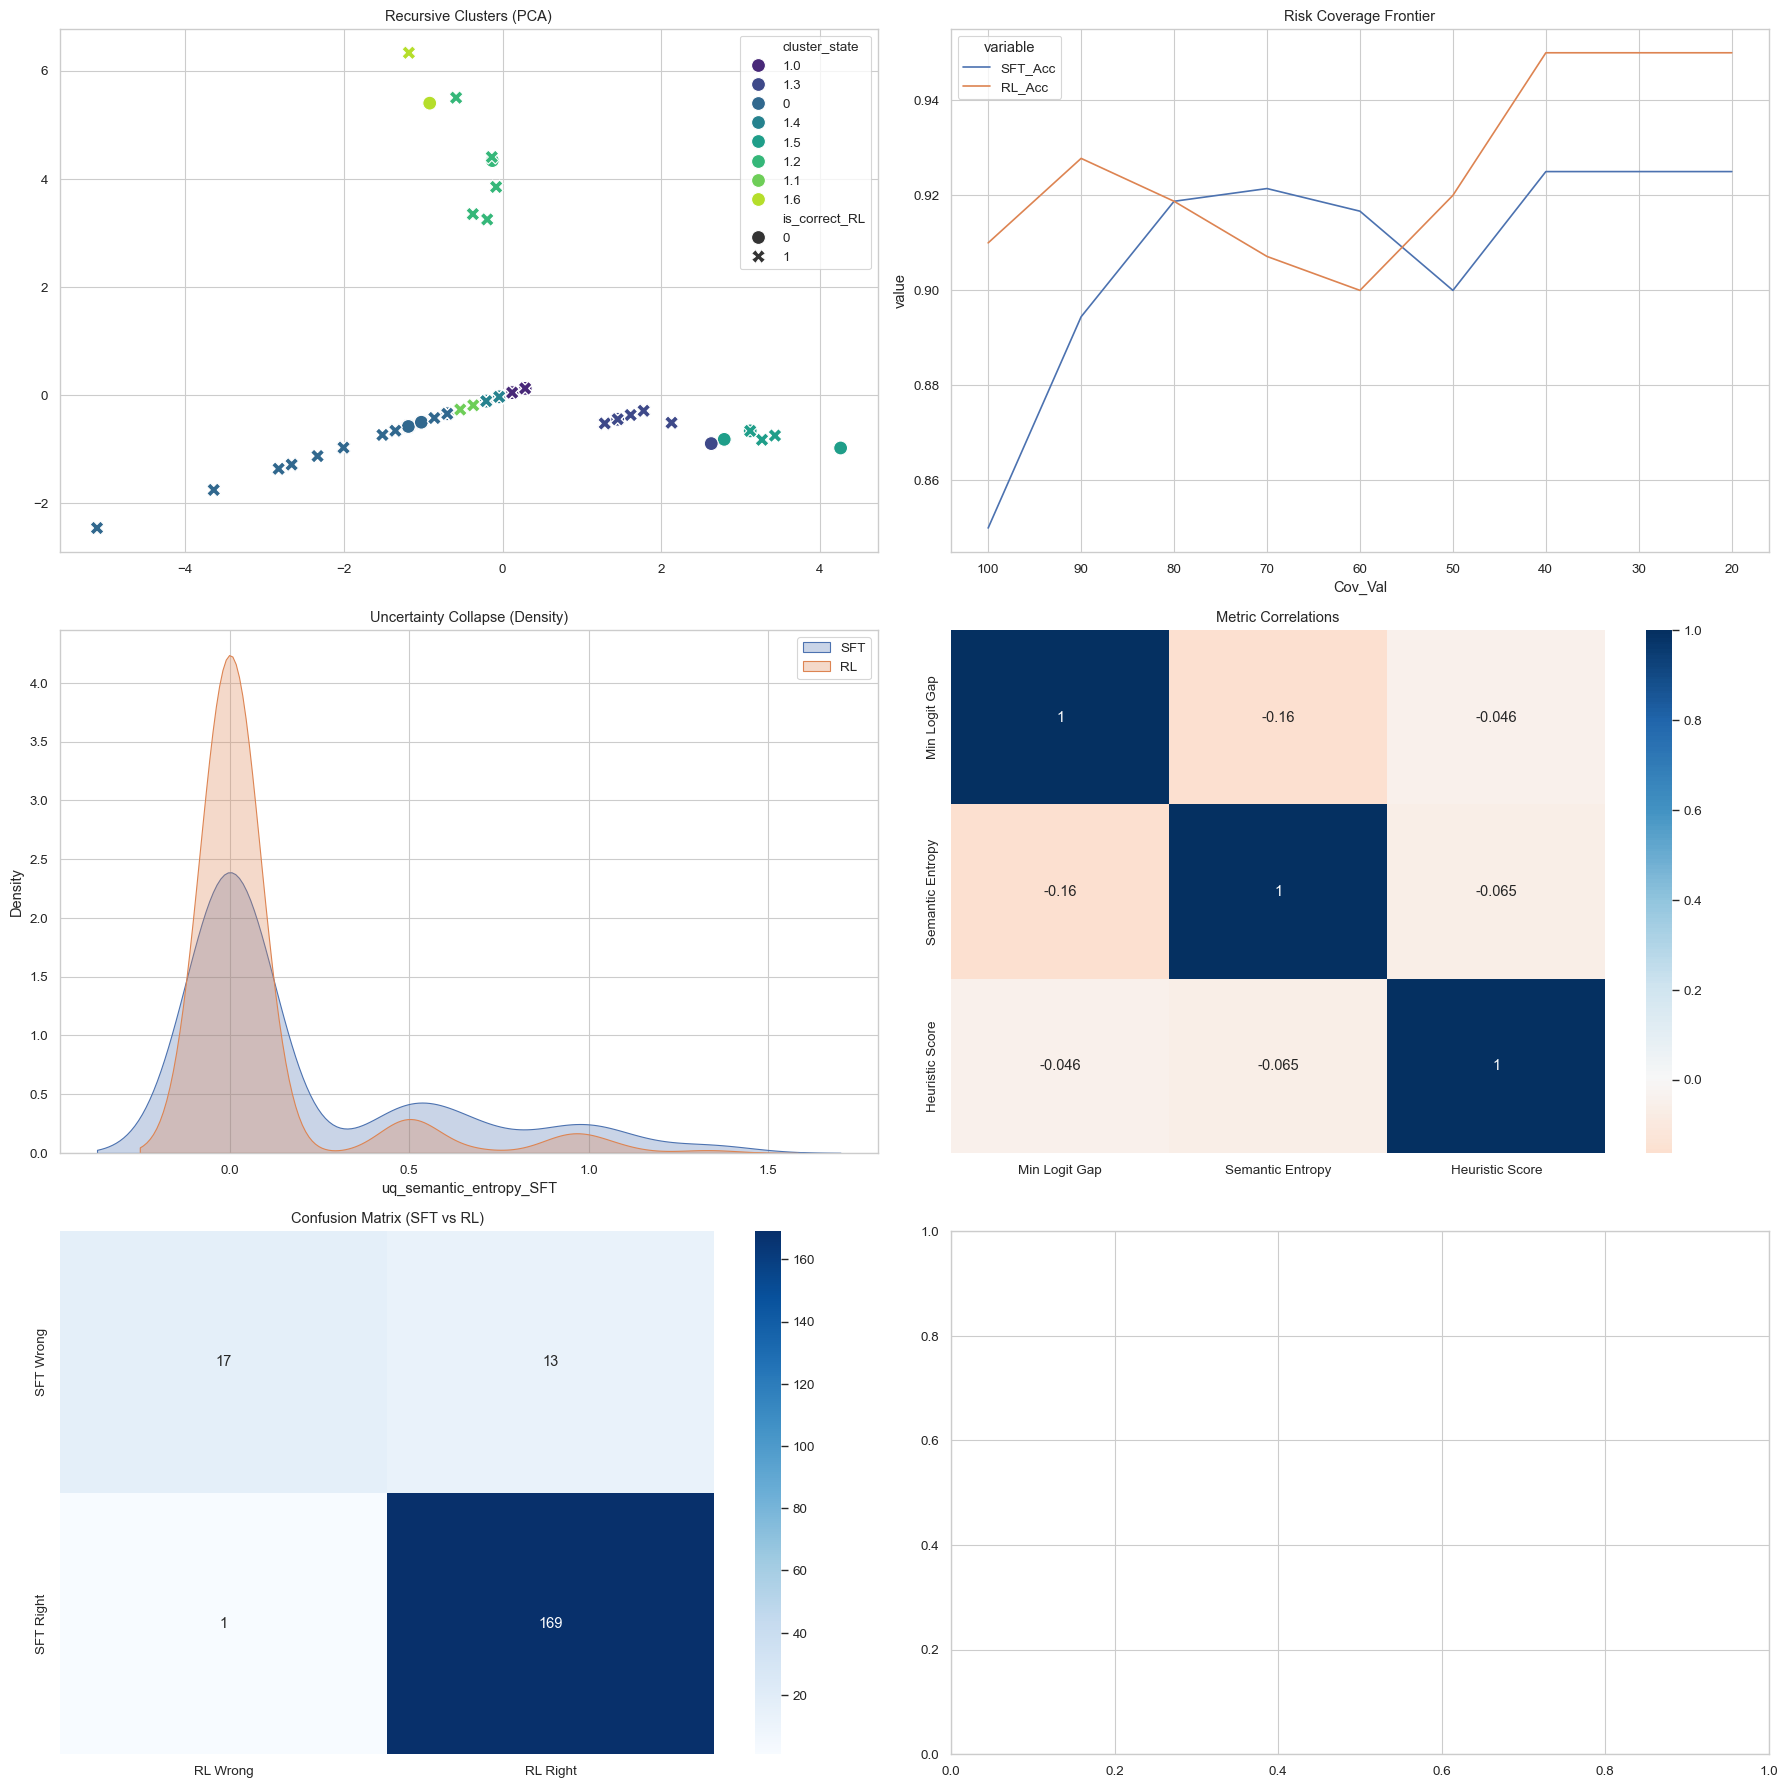

In [24]:
import sqlite3
import pandas as pd
import numpy as np
import sys
import warnings
import re
from io import StringIO
from collections import Counter

# Advanced Analytics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import skew, kurtosis

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.simplefilter(action='ignore')
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.display.float_format = '{:.4f}'.format

DB_PATH = 'db/results.sqlite'
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==============================================================================
#  TEXT BUFFERING SYSTEM
# ==============================================================================
class ReportBuffer:
    def __init__(self):
        self.buffer = StringIO()
    
    def log(self, text=""):
        self.buffer.write(str(text) + "\n")
        
    def section(self, title):
        self.buffer.write(f"\n{'#'*80}\n {title.upper()}\n{'#'*80}\n")

    def sub_section(self, title):
        self.buffer.write(f"\n{'-'*80}\n {title}\n{'-'*80}\n")
        
    def get_content(self):
        return self.buffer.getvalue()

report = ReportBuffer()

# ==============================================================================
#  DATA LOADING & PREP
# ==============================================================================
def load_full_dataset():
    conn = sqlite3.connect(DB_PATH)
    try:
        # 1. Experiments
        try:
            exp_df = pd.read_sql_query("SELECT * FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
            if 'experiment_id' not in exp_df.columns: 
                 exp_df.rename(columns={'id': 'experiment_id', 'name': 'experiment_name', 'created_at': 'run_date'}, inplace=True)
            exp_id = exp_df.iloc[0]['experiment_id']
            exp_name = exp_df.iloc[0]['experiment_name']
        except:
            return None, None, "No Experiment Found"

        # 2. Results
        r_df = pd.read_sql_query(f"SELECT * FROM Results WHERE experiment_id = {exp_id}", conn)
        
        # 3. Models
        m_df = pd.read_sql_query("SELECT * FROM Models", conn)
        join_col = 'model_id' if 'model_id' in m_df.columns else 'id'
        df = pd.merge(r_df, m_df, left_on='model_id', right_on=join_col, how='left')

        # 4. Questions (Optional - Attempt Join)
        try:
            q_df = pd.read_sql_query("SELECT * FROM Questions", conn)
            q_join_key = 'question_id' if 'question_id' in q_df.columns else 'id'
            r_join_key = 'question_id_external' if 'question_id_external' in df.columns else 'question_id'
            df = pd.merge(df, q_df, left_on=r_join_key, right_on=q_join_key, how='left', suffixes=('', '_Q'))
        except:
            pass

        # 5. Pivot
        if 'training_method' not in df.columns: df['training_method'] = df.get('type', 'Unknown')
        df['unique_q_id'] = df.get('question_id_external', df.get('question_id', df.index))
        
        sft_df = df[df['training_method'] == 'SFT'].set_index('unique_q_id')
        rl_df = df[df['training_method'] == 'RL'].set_index('unique_q_id')
        merged = sft_df.join(rl_df, lsuffix='_SFT', rsuffix='_RL', how='inner')

        # 6. Metadata Cleanup
        if 'category' in merged.columns: merged['final_category'] = merged['category']
        elif 'category_SFT' in merged.columns: merged['final_category'] = merged['category_SFT']
        else: merged['final_category'] = 'Unknown'
        
        # Consolidate Text
        if 'text' in merged.columns: merged['final_text'] = merged['text']
        elif 'question_text_SFT' in merged.columns: merged['final_text'] = merged['question_text_SFT']
        else: merged['final_text'] = ''

        # Consolidate Answers
        if 'predicted_answer_RL' in merged.columns: merged['ans_rl'] = merged['predicted_answer_RL']
        elif 'generated_text_RL' in merged.columns: merged['ans_rl'] = merged['generated_text_RL']
        else: merged['ans_rl'] = ''

        return merged, exp_id, exp_name
    finally:
        conn.close()

# ==============================================================================
#  ANALYTICS MODULES
# ==============================================================================

def determine_optimal_k(X, max_k=8):
    if len(X) < 5: return 2
    best_k = 2
    best_score = -1
    limit = min(max_k, len(X))
    for k in range(2, limit):
        try:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X)
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_k = k
        except: pass
    return best_k

def generate_pseudo_categories(df, n_topics=5):
    text_data = df['final_text'].fillna('')
    if text_data.empty or text_data.str.len().sum() < 100:
        return df
    try:
        tfidf = TfidfVectorizer(max_features=100, stop_words='english')
        X_text = tfidf.fit_transform(text_data)
        if X_text.shape[0] < n_topics:
            df['topic_name'] = 'General'
            return df
        kmeans = KMeans(n_clusters=n_topics, random_state=42)
        df['pseudo_topic'] = kmeans.fit_predict(X_text)
        feature_names = np.array(tfidf.get_feature_names_out())
        topic_names = {}
        for i in range(n_topics):
            centroid = kmeans.cluster_centers_[i]
            top_indices = centroid.argsort()[-3:][::-1]
            topic_names[i] = "/".join(feature_names[top_indices])
        df['topic_name'] = df['pseudo_topic'].map(topic_names)
    except:
        df['topic_name'] = 'General'
    return df

def analyze_clustering_recursive(df, cols, depth=0):
    if not cols or len(df) < 5: return None, pd.Series(0, index=df.index)
    
    X = SimpleImputer(strategy='mean').fit_transform(df[cols])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    k = determine_optimal_k(X_scaled)
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    labels = pd.Series(kmeans.labels_, index=df.index, name='cluster_label')
    
    profiles = []
    final_labels = labels.astype(str)
    global_mean = df[cols].mean()
    global_std = df[cols].std()
    
    for i in range(k):
        mask = labels == i
        count = mask.sum()
        pct = count / len(df)
        sub_df = df[mask]
        
        centroid = sub_df[cols].mean()
        desc = []
        for col in cols:
            z = (centroid[col] - global_mean[col]) / (global_std[col] + 1e-9)
            clean_name = col.replace('uq_', '').replace('_RL', '').replace('_delta', '')
            if z > 0.6: desc.append(f"High {clean_name}")
            elif z < -0.6: desc.append(f"Low {clean_name}")
        desc_str = ", ".join(desc) if desc else "Average Profile"
        
        if pct > 0.5 and depth < 1 and len(sub_df) > 10:
            sub_profiles, sub_labels = analyze_clustering_recursive(sub_df, cols, depth+1)
            if sub_profiles is not None:
                for _, row in sub_profiles.iterrows():
                    profiles.append({
                        'Cluster': f"{i}.{row['Cluster']}",
                        'N': row['N'],
                        'Acc': row['Acc'],
                        'Profile': f"{desc_str} -> ({row['Profile']})",
                        'Example': row['Example']
                    })
                final_labels.update(sub_labels.apply(lambda x: f"{i}.{x}"))
                continue

        rl_acc = sub_df['is_correct_RL'].mean()
        q_text = "N/A"
        if count > 0:
            sub_X = X_scaled[mask]
            center = kmeans.cluster_centers_[i]
            closest_idx = pairwise_distances_argmin_min([center], sub_X)[0][0]
            idx_in_df = sub_df.index[closest_idx]
            q_text = str(df.loc[idx_in_df, 'final_text'])[:60] + "..."
            
        profiles.append({
            'Cluster': str(i),
            'N': count,
            'Acc': f"{rl_acc:.1%}",
            'Profile': desc_str,
            'Example': q_text
        })
        
    return pd.DataFrame(profiles).sort_values('Cluster'), final_labels

def analyze_answer_forensics(df):
    df = df.copy()
    df['ans_len'] = df['ans_rl'].astype(str).apply(lambda x: len(x.split()))
    hedges = ['probably', 'likely', 'might', 'maybe', 'possibly', 'think', 'believe', 'could']
    pattern = '|'.join(hedges)
    df['has_hedge'] = df['ans_rl'].astype(str).str.contains(pattern, case=False, na=False)
    
    stats = df.groupby('is_correct_RL').agg({
        'ans_len': 'mean',
        'has_hedge': 'mean',
        'unique_q_id': 'count'
    }).rename(columns={'unique_q_id':'Count', 'ans_len':'Avg Words', 'has_hedge':'Hedge Rate'})
    return stats

def analyze_anomalies(df, cols):
    if not cols: return None
    X = SimpleImputer(strategy='mean').fit_transform(df[cols])
    iso = IsolationForest(contamination=0.05, random_state=42)
    df['anomaly'] = iso.fit_predict(X)
    return df[df['anomaly'] == -1]

def analyze_confusion_matrix(df):
    """SFT vs RL Confusion Matrix."""
    cm = confusion_matrix(df['is_correct_SFT'], df['is_correct_RL'])
    # 0=Wrong, 1=Right
    # [[Wrong->Wrong, Wrong->Right],
    #  [Right->Wrong, Right->Right]]
    try:
        return pd.DataFrame(cm, index=['SFT Wrong', 'SFT Right'], columns=['RL Wrong', 'RL Right'])
    except: return None

def analyze_distribution_stats(df, metric):
    """Skew and Kurtosis for a metric."""
    vals = df[metric].dropna()
    return {
        'Mean': vals.mean(),
        'Std': vals.std(),
        'Skew': skew(vals),
        'Kurtosis': kurtosis(vals)
    }

def analyze_correlations(df, cols):
    """Text-based correlation matrix."""
    return df[cols].corr()

def comparative_risk_coverage(df, ent_metric, mech_metric=None):
    stats = []
    coverages = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.2]
    
    df_sft = df.copy()
    sft_sort = [f'{ent_metric}_SFT']
    if mech_metric: sft_sort.append(f'{mech_metric}_SFT') # Logic: Higher Mech is usually better, handle sign in caller or here. Assuming raw for now.
    df_sft = df_sft.sort_values(sft_sort, ascending=True)

    df_rl = df.copy()
    rl_sort = [f'{ent_metric}_RL']
    if mech_metric: rl_sort.append(f'{mech_metric}_RL')
    df_rl = df_rl.sort_values(rl_sort, ascending=True)
    
    for cov in coverages:
        n = int(len(df) * cov)
        if n < 1: continue
        acc_sft = df_sft.head(n)['is_correct_SFT'].mean()
        acc_rl = df_rl.head(n)['is_correct_RL'].mean()
        stats.append({
            'Coverage': f"{cov:.0%}",
            'SFT_Acc': acc_sft,
            'RL_Acc': acc_rl,
            'Delta': acc_rl - acc_sft,
            'Winner': 'RL' if acc_rl >= acc_sft else 'SFT'
        })
    return pd.DataFrame(stats)

def analyze_cross_terms(df, m1, m2):
    """Metric Interaction."""
    try:
        # Use qcut with duplicates dropped
        df['bin1'] = pd.qcut(df[m1], 2, labels=['Low', 'High'], duplicates='drop')
        df['bin2'] = pd.qcut(df[m2], 2, labels=['Low', 'High'], duplicates='drop')
        return pd.crosstab(df['bin1'], df['bin2'], values=df['is_correct_RL'], aggfunc='mean')
    except: return None

def generate_agent_summary():
    # --- LOAD ---
    merged, exp_id, exp_name = load_full_dataset()
    if merged is None:
        print("Data Error")
        return
    merged['unique_q_id'] = merged.index

    # --- METRICS ---
    metrics = []
    possible = ['mechanistic_score', 'semantic_entropy', 'min_logit_gap', 'heuristic_score']
    possible += [f'uq_{p}' for p in possible]
    active_metrics = {}
    for col in merged.columns:
        if col.endswith('_RL'):
            base = col[:-3]
            for p in possible:
                if base.endswith(p) or base == p:
                    simple = base.replace('uq_', '').replace('_', ' ').title()
                    active_metrics[base] = simple
                    metrics.append(base)
                    break

    for m in metrics:
        merged[f'{m}_delta'] = merged[f'{m}_RL'] - merged[f'{m}_SFT']

    def get_trans(row):
        s, r = row['is_correct_SFT'], row['is_correct_RL']
        if s and r: return "Retained"
        if not s and not r: return "Stubborn"
        if not s and r: return "Fixed"
        if s and not r: return "Broken"
        return "Unknown"
    merged['Transition'] = merged.apply(get_trans, axis=1)

    if merged['final_category'].nunique() < 2:
        merged = generate_pseudo_categories(merged)
        merged['final_category'] = merged['topic_name']

    # --- REPORTING ---
    report.section(f"OMNI-ANALYTICS REPORT: {exp_name}")
    report.log(f"ID: {exp_id} | N: {len(merged)}")
    report.log(f"Metrics: {', '.join(active_metrics.values())}")

    # 1. PERFORMANCE & CONFUSION
    report.sub_section("1. PERFORMANCE & CONFUSION MATRIX")
    cm = analyze_confusion_matrix(merged)
    if cm is not None: report.log(cm.to_string())
    report.log("\nTransition Counts:")
    report.log(merged['Transition'].value_counts().to_string())

    # 2. DISTRIBUTIONS & COLLAPSE
    report.sub_section("2. DISTRIBUTION STATISTICS (The Collapse)")
    dist_stats = []
    for m in metrics:
        col = f'{m}_RL'
        stats = analyze_distribution_stats(merged, col)
        stats['Metric'] = active_metrics[m]
        dist_stats.append(stats)
    report.log(pd.DataFrame(dist_stats).set_index('Metric')[['Mean', 'Std', 'Skew', 'Kurtosis']].to_string())

    # 3. CORRELATIONS
    report.sub_section("3. METRIC CORRELATIONS")
    rl_cols = [f'{m}_RL' for m in metrics]
    corr_mat = analyze_correlations(merged, rl_cols)
    # FIX: Remove 'uq_' removal from key lookup to match active_metrics keys
    corr_mat.columns = [active_metrics[c.replace('_RL','')] for c in corr_mat.columns]
    corr_mat.index = corr_mat.columns
    report.log(corr_mat.to_string())

    # 4. SUBGROUPS
    report.sub_section("4. SUBGROUP ANALYSIS")
    cat_stats = merged.groupby('final_category').agg({
        'is_correct_SFT': 'mean', 'is_correct_RL': 'mean', 'unique_q_id': 'count'
    }).sort_values('unique_q_id', ascending=False).head(8)
    cat_stats['Gain'] = cat_stats['is_correct_RL'] - cat_stats['is_correct_SFT']
    report.log(cat_stats.to_string(float_format="{:.2%}".format))

    # 5. RECURSIVE CLUSTERING
    report.sub_section("5. RECURSIVE CLUSTERING (Drill-Down)")
    prof_state, lbl_state = analyze_clustering_recursive(merged, rl_cols)
    merged['cluster_state'] = lbl_state
    if prof_state is not None: report.log(prof_state[['Cluster', 'N', 'Acc', 'Profile']].to_string(index=False))

    # 6. FORENSICS (TRAPS & LUCKY GUESSES)
    report.sub_section("6. FORENSICS: TRAPS & LUCKY GUESSES")
    ent_m = next((m for m in metrics if 'entropy' in m), None)
    if ent_m:
        # Traps: Wrong & Confident
        traps = merged[(merged['is_correct_RL']==0) & (merged[f'{ent_m}_RL'] < 0.01)]
        # Lucky: Right & Uncertain
        lucky = merged[(merged['is_correct_RL']==1) & (merged[f'{ent_m}_RL'] > 0.5)]
        
        report.log(f"Traps (Confident Failures): {len(traps)}")
        if not traps.empty:
            for i, (idx, row) in enumerate(traps.head(3).iterrows()):
                val_strs = [f"{active_metrics[m]}: {row[f'{m}_RL']:.3f}" for m in metrics]
                report.log(f"  Trap {i+1}: {str(row['final_text'])[:60]}... | {val_strs}")
        
        report.log(f"\nLucky Guesses (Uncertain Successes): {len(lucky)}")
        if not lucky.empty:
            for i, (idx, row) in enumerate(lucky.head(3).iterrows()):
                val_strs = [f"{active_metrics[m]}: {row[f'{m}_RL']:.3f}" for m in metrics]
                report.log(f"  Lucky {i+1}: {str(row['final_text'])[:60]}... | {val_strs}")

    # 7. INTERACTIONS
    report.sub_section("7. METRIC INTERACTIONS")
    if len(metrics) >= 2:
        m1, m2 = metrics[0], metrics[1]
        report.log(f"Interaction: {active_metrics[m1]} (Rows) vs {active_metrics[m2]} (Cols)")
        cross = analyze_cross_terms(merged, f'{m1}_RL', f'{m2}_RL')
        if cross is not None: report.log(cross.to_string())
        else: report.log("Could not calculate interaction (likely zero variance).")

    # 8. RISK COVERAGE
    report.sub_section("8. RISK COVERAGE")
    if ent_m:
        crc = comparative_risk_coverage(merged, ent_m)
        report.log(crc.to_string(index=False))

    print(report.get_content())

    # ==============================================================================
    #  PLOTS
    # ==============================================================================
    print("\n[PLOTS] Generating Visualizations...")
    fig, axes = plt.subplots(3, 2, figsize=(18, 18))
    
    # 1. Recursive Clusters
    if len(rl_cols) > 1:
        pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(SimpleImputer().fit_transform(merged[rl_cols])))
        sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=merged['cluster_state'], style=merged['is_correct_RL'], palette='viridis', ax=axes[0,0], s=100)
        axes[0,0].set_title("Recursive Clusters (PCA)")

    # 2. Risk Coverage
    if ent_m and 'crc' in locals():
        crc_df = crc.copy()
        crc_df['Cov_Val'] = crc_df['Coverage'].str.rstrip('%').astype(int)
        sns.lineplot(data=crc_df.melt(id_vars='Cov_Val', value_vars=['SFT_Acc', 'RL_Acc']), x='Cov_Val', y='value', hue='variable', ax=axes[0,1])
        axes[0,1].invert_xaxis()
        axes[0,1].set_title("Risk Coverage Frontier")

    # 3. Collapse Density
    if ent_m:
        sns.kdeplot(data=merged, x=f'{ent_m}_SFT', label='SFT', fill=True, alpha=0.3, ax=axes[1,0])
        sns.kdeplot(data=merged, x=f'{ent_m}_RL', label='RL', fill=True, alpha=0.3, ax=axes[1,0])
        axes[1,0].set_title("Uncertainty Collapse (Density)")
        axes[1,0].legend()

    # 4. Correlation Heatmap
    sns.heatmap(corr_mat, annot=True, cmap='RdBu', center=0, ax=axes[1,1])
    axes[1,1].set_title("Metric Correlations")

    # 5. Confusion Matrix Heatmap
    if cm is not None:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2,0])
        axes[2,0].set_title("Confusion Matrix (SFT vs RL)")

    # 6. Interaction
    if len(metrics) >= 2 and cross is not None:
        sns.heatmap(cross, annot=True, cmap='RdYlGn', vmin=0, vmax=1, ax=axes[2,1])
        axes[2,1].set_title("Metric Interaction")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    generate_agent_summary()

ANALYZING EXPERIMENT: HUV_Framework_Demo_SFT_vs_RL (ID: 4)

PART 1: MECHANISTIC SIGNAL ANALYSIS (Category Relationships)


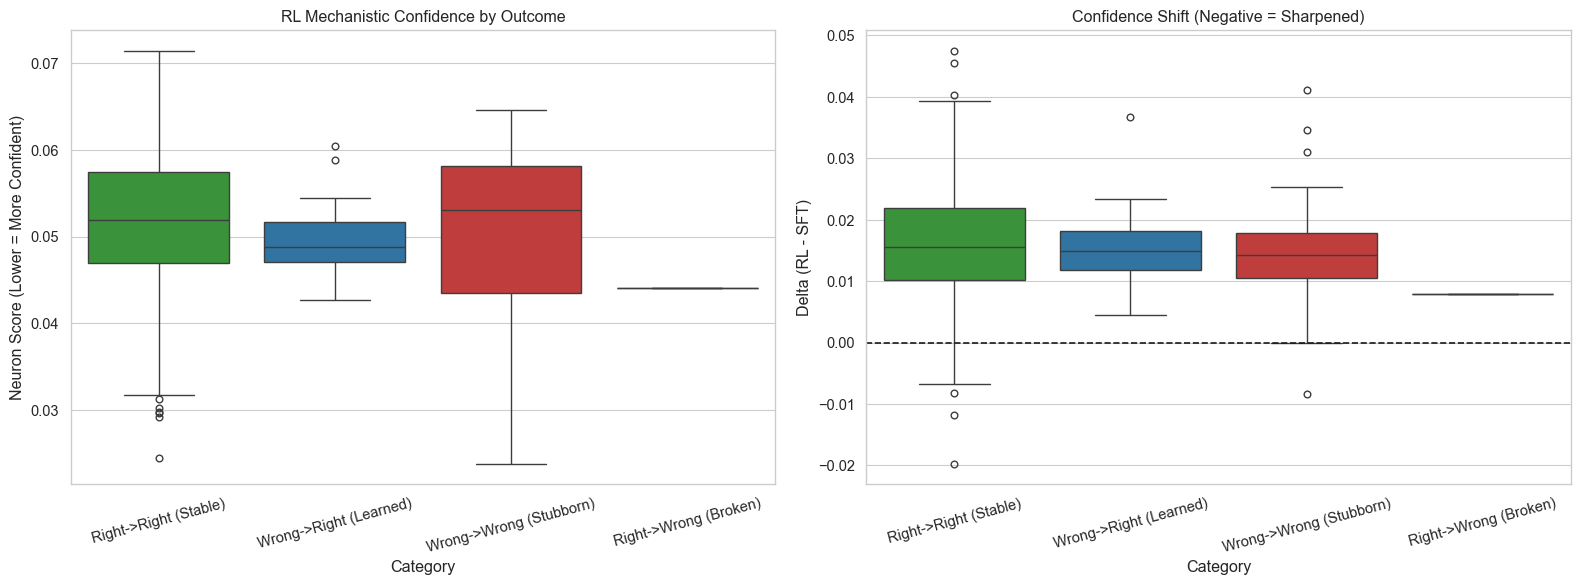

Avg Mechanistic Score (RL):
  - Stubborn Errors: 0.0504
  - Learned Rights:  0.0498
  - Insight: If Stubborn ~= Learned, the neurons cannot distinguish Truth from Delusion.

PART 2: GLOBAL METRIC DASHBOARD


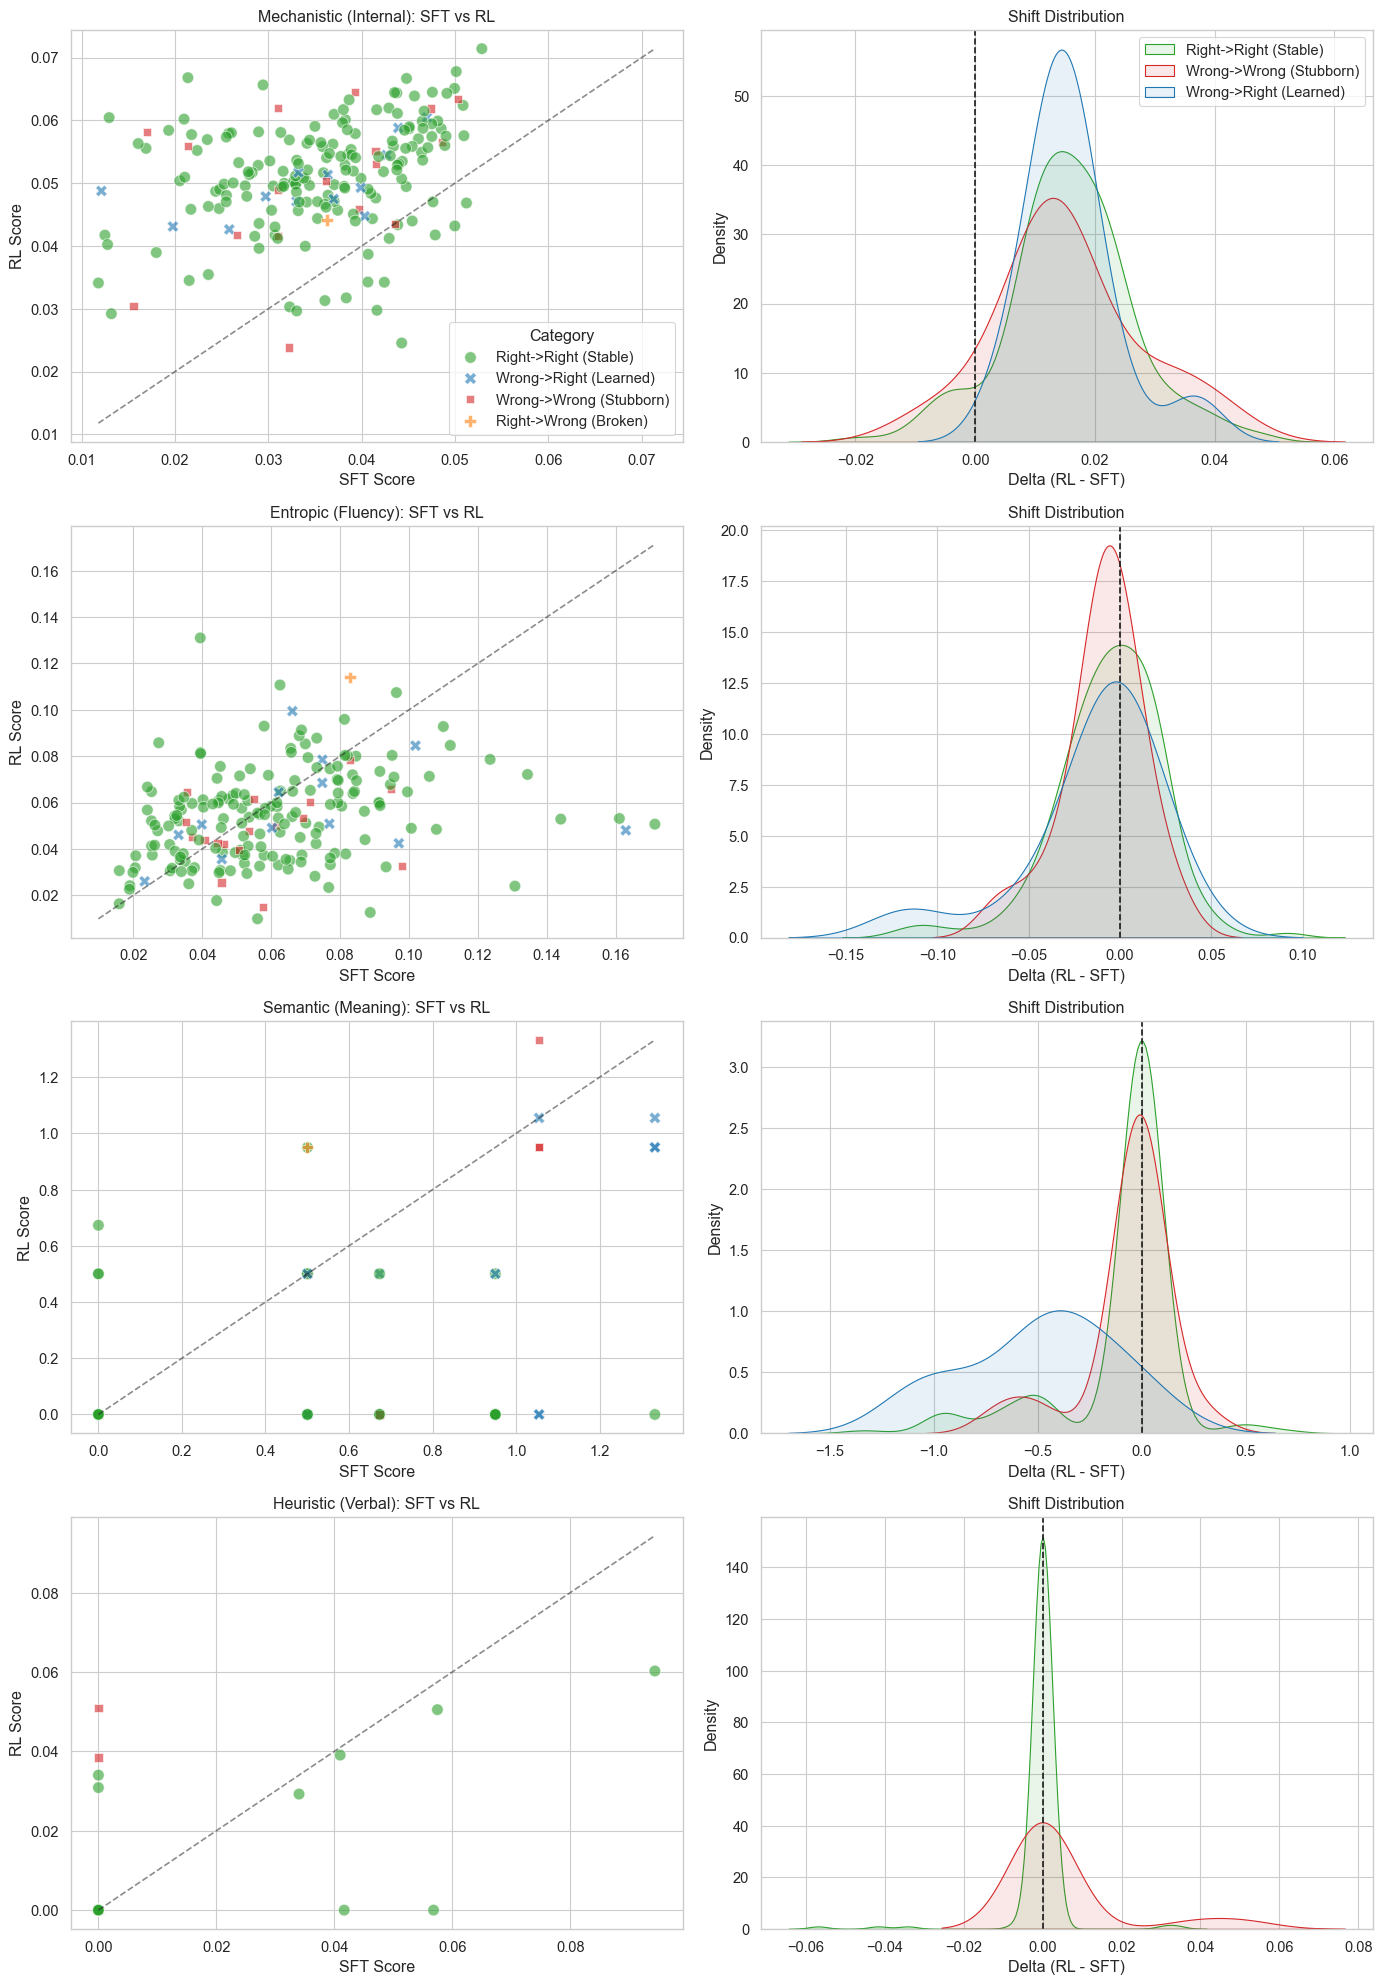


PART 3: FORENSIC REPORT & TRAPS
Metric                         | AUC (SFT->RL)   | KS (Rewire) | Hack Idx
---------------------------------------------------------------------------
Mechanistic (Internal)         | 0.469 -> 0.486   | 0.650      | +0.0006
Entropic (Fluency)             | 0.527 -> 0.454   | 0.160      | +0.0006
Semantic (Meaning)             | 0.746 -> 0.598   | 0.150      | -0.0868
Heuristic (Verbal)             | 0.482 -> 0.540   | 0.010      | -0.0054
---------------------------------------------------------------------------

[MECHANISTIC TRAPS] (N=0)
Definition: RL is Wrong, but Neurons fired with HIGHER confidence than SFT.


In [5]:
# ==============================================================================
#  HUV FRAMEWORK: MEGA ANALYSIS CELL
#  Consolidates Forensic, Statistical, and Visual Analysis into one dashboard.
# ==============================================================================

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, roc_curve
import os
import warnings

# Suppress minor warnings for cleaner output
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- CONFIGURATION ---
DB_PATH = "db/results.sqlite"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Metric Definitions (Label -> Column)
# Prioritizing Mechanistic Score as requested
METRICS = {
    'uq_mech_score': 'Mechanistic (Internal)',
    'uq_avg_entropy': 'Entropic (Fluency)',
    'uq_semantic_entropy': 'Semantic (Meaning)',
    'uq_heuristic_score': 'Heuristic (Verbal)'
}

# --- DATA LOADING & PREPROCESSING ---

def load_and_prep_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None, None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get Latest Experiment
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None, None
        exp_id = exp.iloc[0]['experiment_id']
        print(f"ANALYZING EXPERIMENT: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        # Auto-detect available columns
        cursor = conn.cursor()
        cursor.execute("PRAGMA table_info(Results)")
        available_cols = [r[1] for r in cursor.fetchall()]
        active_metrics = {k: v for k, v in METRICS.items() if k in available_cols}
        
        # Build Query
        metric_sql = ", ".join([f"r.{k}" for k in active_metrics.keys()])
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.predicted_answer,
            r.is_correct,
            {metric_sql},
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df_raw = pd.read_sql(query, conn)
        
        # Pivot SFT vs RL
        df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
        df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
        df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        # Categorize Outcomes
        def categorize(row):
            s, r = row['is_correct_SFT'], row['is_correct_RL']
            if s and r: return "Right->Right (Stable)"
            if not s and not r: return "Wrong->Wrong (Stubborn)"
            if not s and r: return "Wrong->Right (Learned)"
            if s and not r: return "Right->Wrong (Broken)"
            return "Error"

        df['Category'] = df.apply(categorize, axis=1)
        
        # Calculate Deltas
        for m in active_metrics:
            df[f'{m}_Delta'] = df[f'{m}_RL'] - df[f'{m}_SFT']
            
        return df, active_metrics
    finally:
        conn.close()

def safe_auroc(y_true, y_score):
    """Calculates AUROC (Higher Score = Predicted Error)."""
    try:
        if len(np.unique(y_true)) < 2: return 0.5
        # We assume High Score (Uncertainty) predicts Error (0).
        # So we predict label '1-y_true'
        return roc_auc_score(1 - y_true, y_score)
    except: return 0.5

# --- VISUALIZATION & REPORTING ---

def run_mega_analysis():
    df, metrics = load_and_prep_data()
    if df is None: return

    # Color Palette for Categories
    palette = {
        "Right->Right (Stable)": "#2ca02c",   # Green
        "Wrong->Wrong (Stubborn)": "#d62728", # Red
        "Wrong->Right (Learned)": "#1f77b4",  # Blue
        "Right->Wrong (Broken)": "#ff7f0e"    # Orange
    }

    # --- PART 1: MECHANISTIC DEEP DIVE (RELATIONSHIP BETWEEN CATEGORIES) ---
    print("\n" + "="*80)
    print("PART 1: MECHANISTIC SIGNAL ANALYSIS (Category Relationships)")
    print("="*80)
    
    if 'uq_mech_score' in metrics:
        fig_mech, ax_mech = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot A: How confident is the RL model in each category?
        sns.boxplot(data=df, x='Category', y='uq_mech_score_RL', palette=palette, ax=ax_mech[0])
        ax_mech[0].set_title("RL Mechanistic Confidence by Outcome")
        ax_mech[0].set_ylabel("Neuron Score (Lower = More Confident)")
        ax_mech[0].tick_params(axis='x', rotation=15)
        
        # Plot B: How much did confidence CHANGE?
        sns.boxplot(data=df, x='Category', y='uq_mech_score_Delta', palette=palette, ax=ax_mech[1])
        ax_mech[1].axhline(0, color='k', linestyle='--')
        ax_mech[1].set_title("Confidence Shift (Negative = Sharpened)")
        ax_mech[1].set_ylabel("Delta (RL - SFT)")
        ax_mech[1].tick_params(axis='x', rotation=15)
        
        plt.tight_layout()
        plt.show()
        
        # Text Stats for Mechanistic
        stubborn = df[df['Category']=="Wrong->Wrong (Stubborn)"]['uq_mech_score_RL'].mean()
        learned = df[df['Category']=="Wrong->Right (Learned)"]['uq_mech_score_RL'].mean()
        print(f"Avg Mechanistic Score (RL):")
        print(f"  - Stubborn Errors: {stubborn:.4f}")
        print(f"  - Learned Rights:  {learned:.4f}")
        print(f"  - Insight: If Stubborn ~= Learned, the neurons cannot distinguish Truth from Delusion.")

    # --- PART 2: THE GLOBAL DASHBOARD ---
    print("\n" + "="*80)
    print("PART 2: GLOBAL METRIC DASHBOARD")
    print("="*80)
    
    n_metrics = len(metrics)
    fig, axes = plt.subplots(n_metrics, 2, figsize=(14, 5 * n_metrics))
    if n_metrics == 1: axes = [axes]
    
    report_stats = []

    for idx, (col, label) in enumerate(metrics.items()):
        sft_col, rl_col, delta_col = f"{col}_SFT", f"{col}_RL", f"{col}_Delta"
        
        # Stats
        auc_sft = safe_auroc(df['is_correct_SFT'], df[sft_col])
        auc_rl = safe_auroc(df['is_correct_RL'], df[rl_col])
        ks, _ = ks_2samp(df[sft_col], df[rl_col])
        
        # Hack Index: (Delta Right - Delta Wrong). 
        # Positive = Good (Right answers got more boost relative to Wrong).
        # Negative = Bad (Wrong answers got more boost).
        d_right = df[df['is_correct_RL']==1][delta_col].mean()
        d_wrong = df[df['is_correct_RL']==0][delta_col].mean()
        hack_idx = d_right - d_wrong
        
        report_stats.append({
            "Metric": label, "AUC SFT": auc_sft, "AUC RL": auc_rl, "KS": ks, "Hack": hack_idx
        })

        # Plot Scatter
        ax_scat = axes[idx][0]
        sns.scatterplot(
            data=df, x=sft_col, y=rl_col, hue='Category', style='Category',
            palette=palette, alpha=0.6, s=70, ax=ax_scat, legend=(idx==0)
        )
        min_v = min(df[sft_col].min(), df[rl_col].min())
        max_v = max(df[sft_col].max(), df[rl_col].max())
        ax_scat.plot([min_v, max_v], [min_v, max_v], 'k--', alpha=0.5)
        ax_scat.set_title(f"{label}: SFT vs RL")
        ax_scat.set_xlabel("SFT Score")
        ax_scat.set_ylabel("RL Score")

        # Plot Hist
        ax_hist = axes[idx][1]
        for cat, color in palette.items():
            subset = df[df['Category'] == cat]
            if len(subset) > 1:
                sns.kdeplot(subset[delta_col], color=color, fill=True, alpha=0.1, label=cat, ax=ax_hist, warn_singular=False)
        ax_hist.axvline(0, color='k', linestyle='--')
        ax_hist.set_title("Shift Distribution")
        ax_hist.set_xlabel("Delta (RL - SFT)")
        
        if idx == 0 and len(df['Category'].unique()) > 0:
             ax_hist.legend()

    plt.tight_layout()
    plt.show()

    # --- PART 3: TEXTUAL FORENSICS ---
    print("\n" + "="*80)
    print("PART 3: FORENSIC REPORT & TRAPS")
    print("="*80)
    
    print(f"{'Metric':<30} | {'AUC (SFT->RL)':<15} | {'KS (Rewire)':<10} | {'Hack Idx'}")
    print("-" * 75)
    for stat in report_stats:
        print(f"{stat['Metric']:<30} | {stat['AUC SFT']:.3f} -> {stat['AUC RL']:.3f}   | {stat['KS']:.3f}      | {stat['Hack']:+.4f}")
    
    print("-" * 75)
    
    # Show Traps for Mechanistic specifically
    if 'uq_mech_score' in metrics:
        col = 'uq_mech_score'
        traps = df[(df['is_correct_RL'] == 0) & (df[f'{col}_Delta'] < -0.05)]
        
        print(f"\n[MECHANISTIC TRAPS] (N={len(traps)})")
        print("Definition: RL is Wrong, but Neurons fired with HIGHER confidence than SFT.")
        
        if not traps.empty:
            top_traps = traps.sort_values(f'{col}_Delta').head(3)
            for i, (_, row) in enumerate(top_traps.iterrows()):
                print(f"\n{i+1}. Q: {row['question_text'][:80]}...")
                print(f"   RL Answer (Wrong): {str(row['predicted_answer_RL'])[:50]}...")
                print(f"   Mech Score: {row[f'{col}_SFT']:.3f} (SFT) -> {row[f'{col}_RL']:.3f} (RL)")
                print(f"   Change: {row[f'{col}_Delta']:.3f} (Neurons became sharper)")

# EXECUTE
run_mega_analysis()

Analyze Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)

STATISTICAL SUMMARY & FORENSICS

Metric: Mechanistic (Internal Confidence)
  AUROC Change:  0.469 (SFT) -> 0.486 (RL)
  Distrib Shift: KS=0.650 (Higher = Brain Rewired)
  Mean Delta:    0.0156
  Hack Index:    +0.0006 (Negative = RL overconfident on errors)

Metric: Entropic (Token Fluency)
  AUROC Change:  0.527 (SFT) -> 0.454 (RL)
  Distrib Shift: KS=0.160 (Higher = Brain Rewired)
  Mean Delta:    -0.0066
  Hack Index:    +0.0006 (Negative = RL overconfident on errors)
  [!] Found 1 Overconfidence Traps (RL Wrong but More Sure):
      Q: Shawna's workout goal is 30 situps. On Monday, Shawna was on...
      RL Answer (Wrong): 18...
      Score Drop: -0.0651

Metric: Semantic (Meaning Uncertainty)
  AUROC Change:  0.746 (SFT) -> 0.598 (RL)
  Distrib Shift: KS=0.150 (Higher = Brain Rewired)
  Mean Delta:    -0.1154
  Hack Index:    -0.0868 (Negative = RL overconfident on errors)
  [!] Found 4 Overconfidence Traps (RL Wrong but Mo

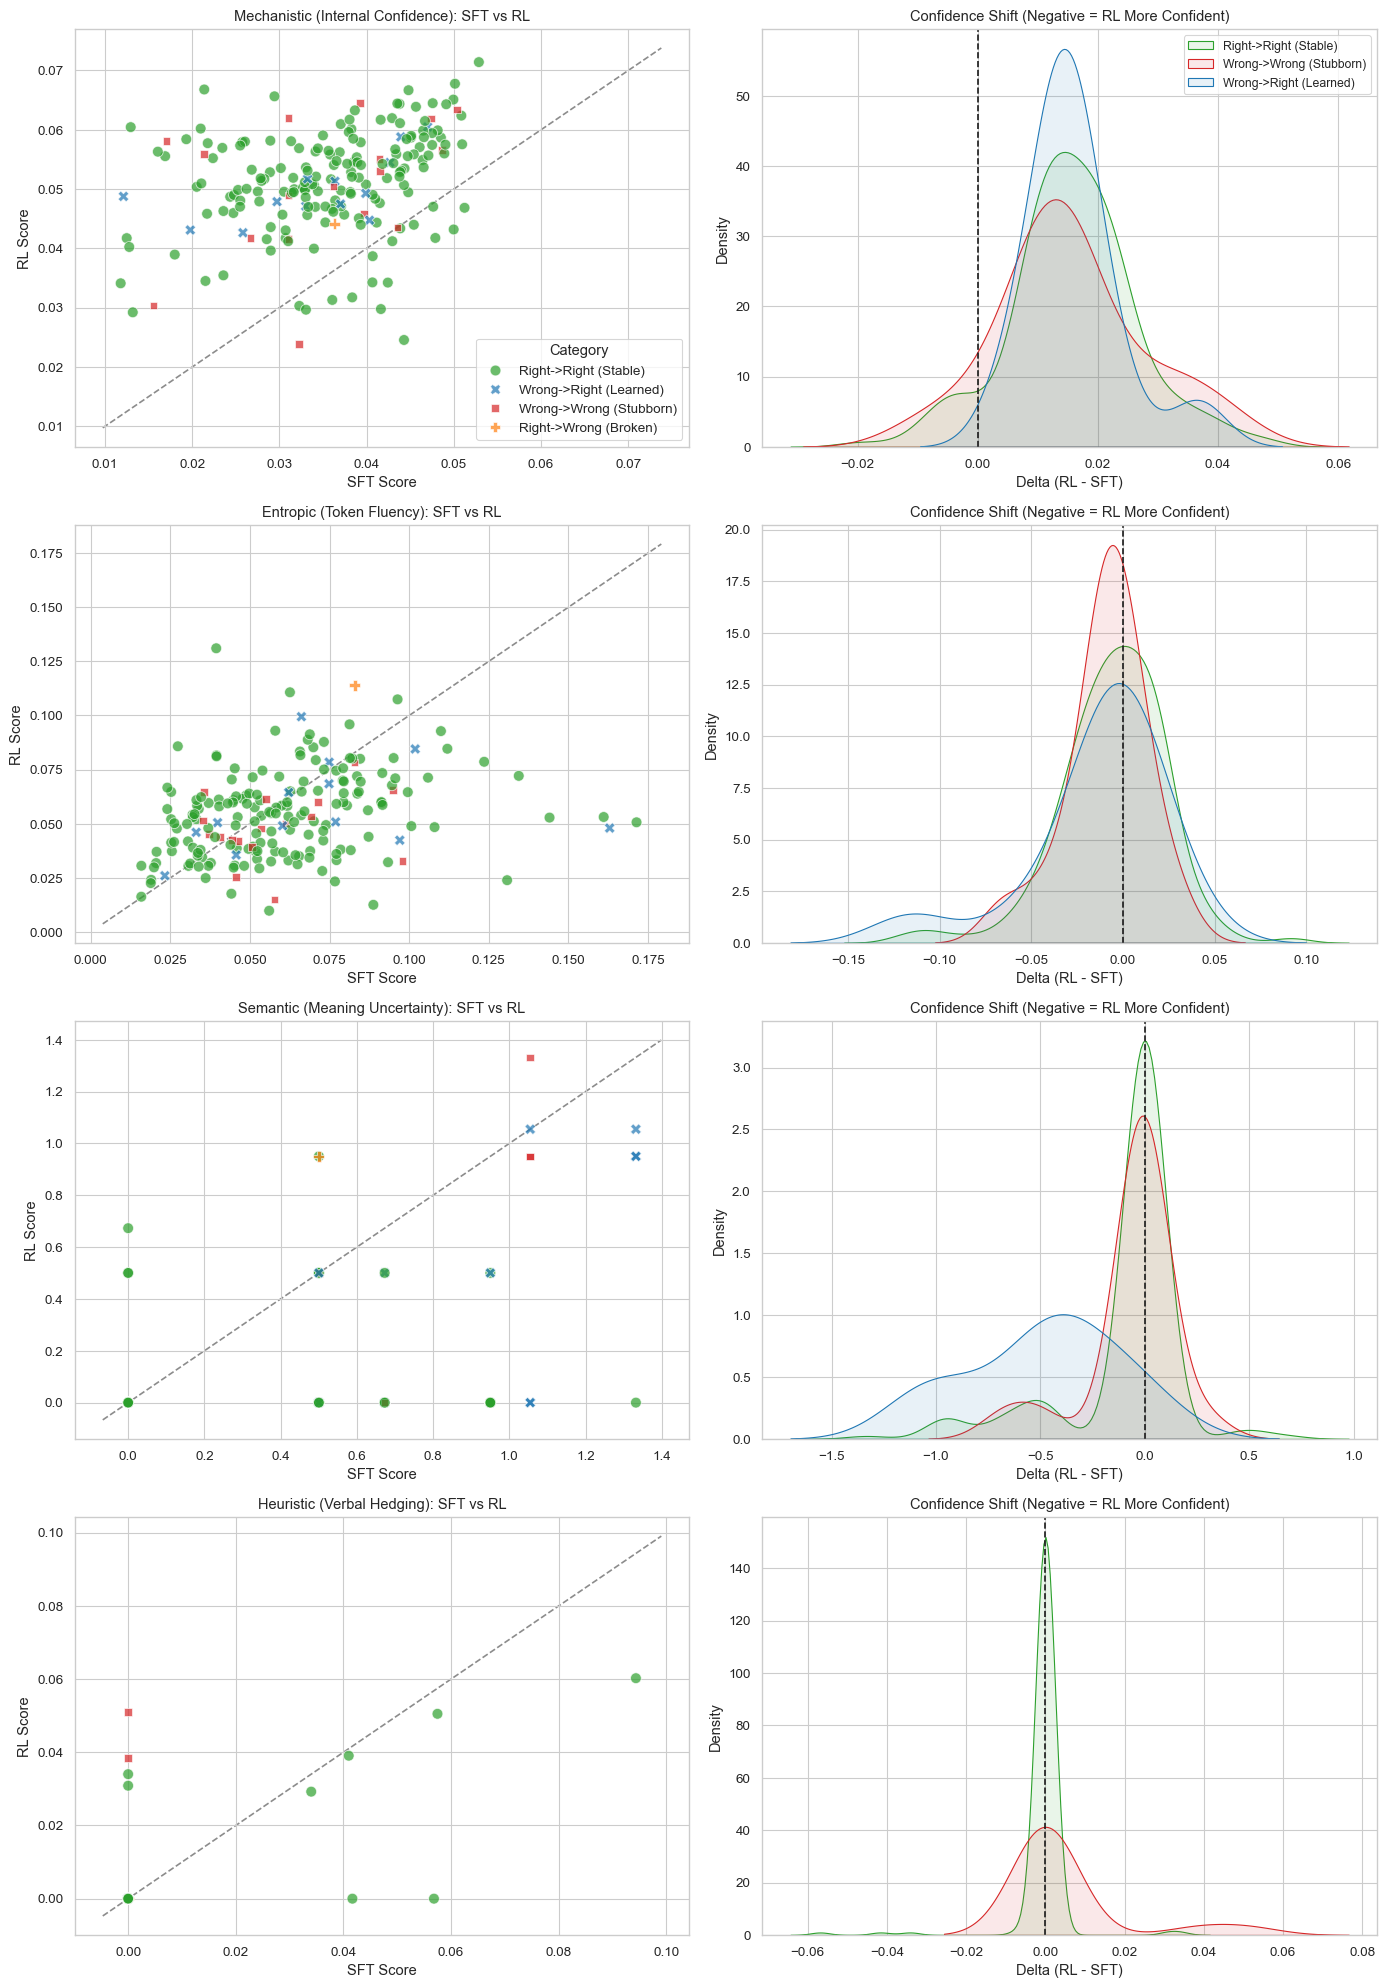

In [19]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, roc_curve

# --- CONFIGURATION ---
DB_PATH = "db/results.sqlite"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Metrics to Analyze (Column Name -> Display Label)
METRICS = {
    'uq_mech_score': 'Mechanistic (Internal Confidence)',  # PRIMARY INTEREST
    'uq_avg_entropy': 'Entropic (Token Fluency)',
    'uq_semantic_entropy': 'Semantic (Meaning Uncertainty)',
    'uq_heuristic_score': 'Heuristic (Verbal Hedging)'
}

def load_paired_data():
    """Loads and pivots SFT vs RL data from the latest experiment."""
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get Latest Experiment
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyze Experiment: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        # Auto-detect columns present in DB
        cursor = conn.cursor()
        cursor.execute("PRAGMA table_info(Results)")
        db_cols = [r[1] for r in cursor.fetchall()]
        
        # Build Query
        valid_metrics = [m for m in METRICS.keys() if m in db_cols]
        metric_sql = ", ".join([f"r.{m}" for m in valid_metrics])
        
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.gold_answer,
            r.predicted_answer,
            r.is_correct,
            {metric_sql},
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df_raw = pd.read_sql(query, conn)
        
        # Pivot to SFT vs RL
        df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
        df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
        df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
        
        return df, valid_metrics
    finally:
        conn.close()

def categorize_shift(row):
    """Categorizes the learning outcome."""
    sft, rl = row['is_correct_SFT'], row['is_correct_RL']
    if sft == 1 and rl == 1: return "Right->Right (Stable)"
    if sft == 0 and rl == 0: return "Wrong->Wrong (Stubborn)"
    if sft == 0 and rl == 1: return "Wrong->Right (Learned)"
    if sft == 1 and rl == 0: return "Right->Wrong (Broken)"
    return "Error"

def safe_auroc(y_true, y_score):
    """Calculates AUROC where Higher Score = Higher Probability of Error."""
    try:
        if len(np.unique(y_true)) < 2: return 0.5
        # Predict Error (1) based on Uncertainty Score
        return roc_auc_score(1 - y_true, y_score)
    except: return 0.5

def run_mega_analysis():
    df, active_metrics = load_paired_data()
    if df is None: return

    # 1. Preprocessing
    df['Category'] = df.apply(categorize_shift, axis=1)
    
    # Custom Palette
    palette = {
        "Right->Right (Stable)": "#2ca02c",  # Green
        "Wrong->Wrong (Stubborn)": "#d62728", # Red
        "Wrong->Right (Learned)": "#1f77b4",  # Blue
        "Right->Wrong (Broken)": "#ff7f0e"    # Orange
    }

    # 2. MASTER DASHBOARD PLOT
    # Layout: One row per metric. Left=Scatter, Right=Histogram of Shift
    n_metrics = len(active_metrics)
    fig, axes = plt.subplots(n_metrics, 2, figsize=(14, 5 * n_metrics))
    if n_metrics == 1: axes = [axes]
    
    print("\n" + "="*80)
    print("STATISTICAL SUMMARY & FORENSICS")
    print("="*80)
    
    for i, metric in enumerate(active_metrics):
        label = METRICS[metric]
        sft_col, rl_col = f"{metric}_SFT", f"{metric}_RL"
        
        # Calculate Delta (RL - SFT)
        # Negative = RL became MORE Confident (Score Lowered)
        df[f'{metric}_Delta'] = df[rl_col] - df[sft_col]
        
        # --- A. SCATTER PLOT (SFT vs RL) ---
        ax_scat = axes[i][0]
        sns.scatterplot(
            data=df, x=sft_col, y=rl_col, hue='Category', style='Category',
            palette=palette, alpha=0.7, s=60, ax=ax_scat, legend=(i==0)
        )
        # Diagonal Line
        lims = [
            np.min([ax_scat.get_xlim(), ax_scat.get_ylim()]),
            np.max([ax_scat.get_xlim(), ax_scat.get_ylim()])
        ]
        ax_scat.plot(lims, lims, 'k--', alpha=0.5, zorder=0)
        ax_scat.set_title(f"{label}: SFT vs RL")
        ax_scat.set_xlabel("SFT Score")
        ax_scat.set_ylabel("RL Score")
        
        # --- B. SHIFT HISTOGRAM (By Category) ---
        ax_hist = axes[i][1]
        for cat, color in palette.items():
            subset = df[df['Category'] == cat]
            if len(subset) > 1:
                sns.kdeplot(subset[f'{metric}_Delta'], color=color, fill=True, alpha=0.1, label=cat, ax=ax_hist, warn_singular=False)
        
        ax_hist.axvline(0, color='k', linestyle='--')
        ax_hist.set_title(f"Confidence Shift (Negative = RL More Confident)")
        ax_hist.set_xlabel("Delta (RL - SFT)")
        if i == 0: ax_hist.legend(fontsize='small')

        # --- C. STATS CALCULATION ---
        auc_sft = safe_auroc(df['is_correct_SFT'], df[sft_col])
        auc_rl = safe_auroc(df['is_correct_RL'], df[rl_col])
        ks_stat, _ = ks_2samp(df[sft_col], df[rl_col])
        
        # Reward Hacking Index: (Right Answers Confidence Boost - Wrong Answers Confidence Boost)
        # We want Right answers to drop score (negative delta) MORE than Wrong answers.
        # Hack = Wrong_Delta < Right_Delta (Wrong answers got bigger boost)
        delta_right = df[df['is_correct_RL']==1][f'{metric}_Delta'].mean()
        delta_wrong = df[df['is_correct_RL']==0][f'{metric}_Delta'].mean()
        hack_index = delta_right - delta_wrong # Positive means Wrong answers stayed higher (Good), Negative means Wrong answers dropped more (Bad/Hack)

        print(f"\nMetric: {label}")
        print(f"  AUROC Change:  {auc_sft:.3f} (SFT) -> {auc_rl:.3f} (RL)")
        print(f"  Distrib Shift: KS={ks_stat:.3f} (Higher = Brain Rewired)")
        print(f"  Mean Delta:    {df[f'{metric}_Delta'].mean():.4f}")
        print(f"  Hack Index:    {hack_index:+.4f} (Negative = RL overconfident on errors)")
        
        # --- D. FORENSIC EXAMPLES (Traps) ---
        # Find "Traps": RL Wrong + RL More Confident than SFT (Delta < -0.05)
        traps = df[(df['is_correct_RL'] == 0) & (df[f'{metric}_Delta'] < -0.05)]
        if not traps.empty:
            print(f"  [!] Found {len(traps)} Overconfidence Traps (RL Wrong but More Sure):")
            top_trap = traps.sort_values(f'{metric}_Delta').iloc[0]
            print(f"      Q: {top_trap['question_text_SFT'][:60]}...")
            print(f"      RL Answer (Wrong): {top_trap['predicted_answer_RL'][:30]}...")
            print(f"      Score Drop: {top_trap[f'{metric}_Delta']:.4f}")
    
    plt.tight_layout()
    plt.savefig("mega_analysis_dashboard.png")
    print(f"\n[Visuals] Dashboard saved to 'mega_analysis_dashboard.png'")

    # --- 3. SAFETY NET SIMULATION (The Finale) ---
    print("\n" + "="*80)
    print("SAFETY NET RECOMMENDATION")
    print("="*80)
    
    # Check if Semantic Entropy exists
    if 'uq_semantic_entropy_RL' in df.columns:
        # Find Optimal Threshold for RL Semantic Entropy
        y_true = 1 - df['is_correct_RL']
        fpr, tpr, threshs = roc_curve(y_true, df['uq_semantic_entropy_RL'])
        idx = np.argmax(tpr - fpr)
        opt_thresh = threshs[idx]
        
        catch_rate = tpr[idx]
        false_alarms = fpr[idx]
        
        print(f"Optimal Threshold for RL Self-Check: {opt_thresh:.4f}")
        print(f"  Errors Caught: {catch_rate:.1%} | False Alarms: {false_alarms:.1%}")
        
        if catch_rate < 0.5:
            print("  VERDICT: UNSAFE. RL model cannot detect its own errors reliably.")
            print("  RECOMMENDATION: Use external Reward Model or SFT Watchdog.")
        else:
            print("  VERDICT: VIABLE. RL model has retained calibration.")

if __name__ == "__main__":
    run_mega_analysis()

In [18]:
import sqlite3
import pandas as pd
import numpy as np
import os
from sklearn.metrics import roc_curve

DB_PATH = "db/results.sqlite"

def get_data():
    if not os.path.exists(DB_PATH):
        return None
    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.is_correct,
            r.uq_semantic_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        return pd.read_sql(query, conn)
    finally:
        conn.close()

def get_optimal_threshold(y_true, y_score):
    if len(y_score) == 0: return 0
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    # Youden's J
    idx = np.argmax(tpr - fpr)
    return thresholds[idx]

def print_scenario(name, y_true, y_flag):
    """Prints a confusion matrix and operational stats."""
    # Counts
    tp = np.sum((y_true == 1) & (y_flag == 1)) # Caught Error
    fn = np.sum((y_true == 1) & (y_flag == 0)) # Missed Error
    fp = np.sum((y_true == 0) & (y_flag == 1)) # False Alarm
    tn = np.sum((y_true == 0) & (y_flag == 0)) # Clean Pass
    
    total_errors = tp + fn
    total_flags = tp + fp
    
    print(f"\n>>> SCENARIO: {name}")
    print(f"{'-'*40}")
    print(f"       [PREDICTED]")
    print(f"       Flag      Pass")
    print(f"[REAL] {tp:<9} {fn:<9} (Errors)")
    print(f"       {fp:<9} {tn:<9} (Corrects)")
    print(f"{'-'*40}")
    
    print(f"1. SAFETY: Caught {tp}/{total_errors} errors ({tp/total_errors:.1%})")
    print(f"2. NOISE:  {fp} false alarms (Annoyed {fp} users)")
    
    if tp > 0:
        ratio = fp / tp
        print(f"3. COST:   For every 1 error caught, you flag {ratio:.1f} correct answers.")
    else:
        print(f"3. COST:   Infinite (Caught nothing).")

def run_simulation():
    df_raw = get_data()
    if df_raw is None or df_raw.empty: return

    # Pivot
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    df = df_rl.join(df_sft, lsuffix='_RL', rsuffix='_SFT', how='inner')
    
    # Ground Truth: RL Errors
    y_true = 1 - df['is_correct_RL']
    
    # Calculate Thresholds
    t_rl = get_optimal_threshold(y_true, df['uq_semantic_entropy_RL'])
    t_sft = get_optimal_threshold(y_true, df['uq_semantic_entropy_SFT'])
    
    print("="*60)
    print(f"OPERATIONAL SAFETY REPORT (N={len(df)})")
    print(f"Total RL Errors to Catch: {y_true.sum()}")
    print("="*60)
    print(f"Thresholds (Youden): RL={t_rl:.4f}, SFT={t_sft:.4f}")

    # --- SCENARIO 1: RL SELF-CHECK ---
    flags_rl = (df['uq_semantic_entropy_RL'] >= t_rl).astype(int)
    print_scenario("RL Introspection", y_true, flags_rl)
    
    # --- SCENARIO 2: SFT WATCHDOG ---
    flags_sft = (df['uq_semantic_entropy_SFT'] >= t_sft).astype(int)
    print_scenario("SFT Watchdog", y_true, flags_sft)
    
    # --- SCENARIO 3: UNION (MAX SAFETY) ---
    # Flag if EITHER model is unsure
    flags_union = ((flags_rl == 1) | (flags_sft == 1)).astype(int)
    print_scenario("Combined Safety Net (Union)", y_true, flags_union)
    
    # --- SCENARIO 4: ENSEMBLE (SFT Entropy + RL Heuristic) ---
    # Simple heuristic: If SFT is unsure OR RL says 'I think...' (Heuristic > 0)
    # Note: RL heuristic was 0.00 for almost all, so this might not add much, 
    # but let's check the logic.
    if 'uq_heuristic_score_RL' in df.columns:
        # Heuristic score is usually 0 to 1. Let's say > 0.1 is 'hedged'.
        flags_heu = (df['uq_heuristic_score_RL'] > 0.05).astype(int)
        flags_ens = ((flags_sft == 1) | (flags_heu == 1)).astype(int)
        print_scenario("Ensemble (SFT Entropy + RL Verbal)", y_true, flags_ens)

if __name__ == "__main__":
    run_simulation()

OPERATIONAL SAFETY REPORT (N=200)
Total RL Errors to Catch: 18
Thresholds (Youden): RL=0.9503, SFT=0.5004

>>> SCENARIO: RL Introspection
----------------------------------------
       [PREDICTED]
       Flag      Pass
[REAL] 4         14        (Errors)
       5         177       (Corrects)
----------------------------------------
1. SAFETY: Caught 4/18 errors (22.2%)
2. NOISE:  5 false alarms (Annoyed 5 users)
3. COST:   For every 1 error caught, you flag 1.2 correct answers.

>>> SCENARIO: SFT Watchdog
----------------------------------------
       [PREDICTED]
       Flag      Pass
[REAL] 7         11        (Errors)
       45        137       (Corrects)
----------------------------------------
1. SAFETY: Caught 7/18 errors (38.9%)
2. NOISE:  45 false alarms (Annoyed 45 users)
3. COST:   For every 1 error caught, you flag 6.4 correct answers.

>>> SCENARIO: Combined Safety Net (Union)
----------------------------------------
       [PREDICTED]
       Flag      Pass
[REAL] 7       

Analyzing Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)

OPTIMAL THRESHOLDS (Maximize Recall - False Alarm Rate)
RL Self-Check Threshold: 0.9503
  -> Errors Caught: 22.22%
  -> False Alarms:  2.75%
----------------------------------------
SFT Watchdog Threshold:  0.5004
  -> Errors Caught: 38.89%
  -> False Alarms:  24.73%

Graph saved to: safety_net_final.png


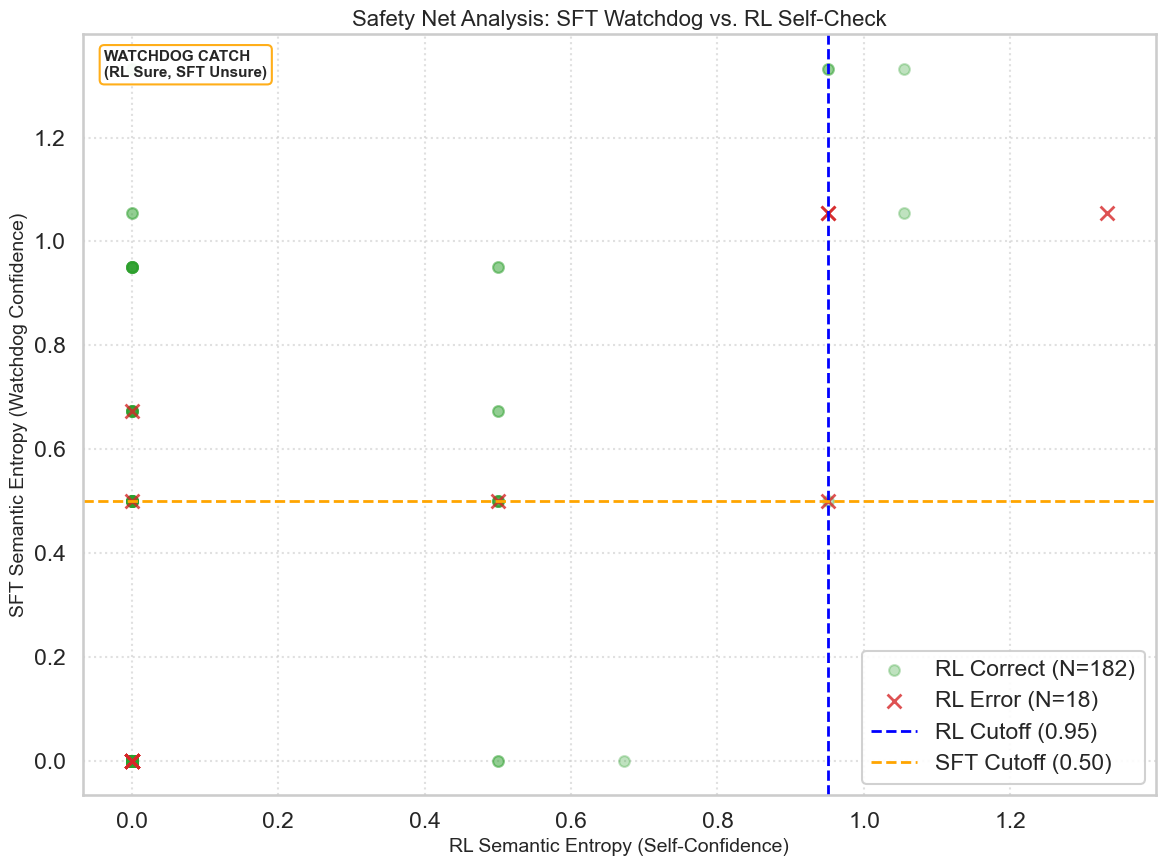

In [17]:
import sqlite3
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        # Fetch semantic entropy results for both models
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.is_correct,
            r.uq_semantic_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def find_optimal_threshold(y_true_error, y_score):
    """
    Finds the threshold that maximizes Youden's J statistic (TPR - FPR).
    y_true_error: 1 if Error, 0 if Correct.
    y_score: Higher score should indicate higher probability of error.
    """
    if len(y_score) == 0: return 0, 0, 0
    
    fpr, tpr, thresholds = roc_curve(y_true_error, y_score)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    
    return thresholds[best_idx], tpr[best_idx], fpr[best_idx]

def analyze_safety_net():
    df_raw = get_data()
    if df_raw is None or df_raw.empty:
        print("No data found.")
        return

    # Pivot Data: Separate SFT and RL into columns
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    # Merge on Question ID
    df = df_rl.join(df_sft, lsuffix='_RL', rsuffix='_SFT', how='inner')
    
    # Target: Detect RL Errors (1 = Error, 0 = Correct)
    y_target = 1 - df['is_correct_RL']
    
    # 1. Calculate Optimal Thresholds
    thresh_rl, recall_rl, fpr_rl = find_optimal_threshold(y_target, df['uq_semantic_entropy_RL'])
    thresh_sft, recall_sft, fpr_sft = find_optimal_threshold(y_target, df['uq_semantic_entropy_SFT'])
    
    print("\n" + "="*80)
    print("OPTIMAL THRESHOLDS (Maximize Recall - False Alarm Rate)")
    print("="*80)
    print(f"RL Self-Check Threshold: {thresh_rl:.4f}")
    print(f"  -> Errors Caught: {recall_rl:.2%}")
    print(f"  -> False Alarms:  {fpr_rl:.2%}")
    print("-" * 40)
    print(f"SFT Watchdog Threshold:  {thresh_sft:.4f}")
    print(f"  -> Errors Caught: {recall_sft:.2%}")
    print(f"  -> False Alarms:  {fpr_sft:.2%}")
    
    # 2. Generate Scatter Plot
    plt.figure(figsize=(12, 9))
    
    # Subset data for plotting
    corrects = df[df['is_correct_RL'] == 1]
    errors = df[df['is_correct_RL'] == 0]
    
    # Scatter: Correct Answers (Green Circles)
    plt.scatter(
        corrects['uq_semantic_entropy_RL'], 
        corrects['uq_semantic_entropy_SFT'], 
        c='#2ca02c', alpha=0.3, s=60, label=f'RL Correct (N={len(corrects)})'
    )
    
    # Scatter: Wrong Answers (Red 'X')
    plt.scatter(
        errors['uq_semantic_entropy_RL'], 
        errors['uq_semantic_entropy_SFT'], 
        c='#d62728', alpha=0.8, s=100, marker='x', linewidth=2, label=f'RL Error (N={len(errors)})'
    )
    
    # Add Threshold Lines
    plt.axvline(thresh_rl, color='blue', linestyle='--', linewidth=2, label=f'RL Cutoff ({thresh_rl:.2f})')
    plt.axhline(thresh_sft, color='orange', linestyle='--', linewidth=2, label=f'SFT Cutoff ({thresh_sft:.2f})')
    
    # Formatting
    plt.title("Safety Net Analysis: SFT Watchdog vs. RL Self-Check", fontsize=16)
    plt.xlabel("RL Semantic Entropy (Self-Confidence)", fontsize=14)
    plt.ylabel("SFT Semantic Entropy (Watchdog Confidence)", fontsize=14)
    
    # Annotate the "Watchdog Zone" (Top-Left Quadrant)
    # This is where RL is confident (Left) but SFT is confused (Top)
    plt.text(
        0.02, 0.98, "WATCHDOG CATCH\n(RL Sure, SFT Unsure)", 
        transform=plt.gca().transAxes, 
        fontsize=11, weight='bold', verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="orange", alpha=0.9)
    )

    plt.legend(loc='lower right', frameon=True, framealpha=0.9)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # Save
    out_file = 'safety_net_final.png'
    plt.savefig(out_file, dpi=150)
    print(f"\nGraph saved to: {out_file}")

if __name__ == "__main__":
    analyze_safety_net()

In [16]:
import sqlite3
import pandas as pd
import numpy as np
import os
from sklearn.metrics import roc_curve, roc_auc_score

DB_PATH = "db/results.sqlite"

def get_optimal_stat(y_true_error, y_score, label):
    """
    Finds the optimal threshold to detect Errors (y_true=1).
    """
    if len(y_score) == 0: return None

    # 1. Determine Directionality (Higher Score = Error?)
    try:
        auc = roc_auc_score(y_true_error, y_score)
    except:
        return None

    direction = "High Score = Error"
    features = y_score.values
    
    # If AUC < 0.5, it means Lower Score indicates Error (Anti-correlated)
    # We invert the score to calculate the threshold correctly
    if auc < 0.5:
        auc = 1.0 - auc
        direction = "Low Score = Error"
        features = -features

    # 2. Calculate ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true_error, features)
    
    # 3. Find Optimal Threshold (Youden's J)
    # J = Sensitivity + Specificity - 1 = TPR - FPR
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    
    best_thresh = thresholds[best_idx]
    
    # If we inverted, flip the threshold back
    if direction == "Low Score = Error":
        best_thresh = -best_thresh
        
    return {
        "Metric": label,
        "Direction": direction,
        "Optimal Threshold": best_thresh,
        "AUROC": auc,
        "Recall (Catch Rate)": tpr[best_idx],
        "FPR (False Alarms)": fpr[best_idx],
        "Youden J": j_scores[best_idx]
    }

def calculate_thresholds():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return

    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return
        exp_id = exp.iloc[0]['experiment_id']
        
        # Fetch Data: RL Outcomes + RL Metrics + SFT Metrics
        # We join SFT and RL tables
        query = """
        SELECT 
            r1.question_id_external as q_id,
            r1.is_correct as rl_is_correct,
            r1.uq_semantic_entropy as rl_sem_ent,
            r1.uq_mech_score as rl_mech,
            r2.uq_semantic_entropy as sft_sem_ent
        FROM Results r1
        JOIN Results r2 ON r1.question_id_external = r2.question_id_external
        JOIN Models m1 ON r1.model_id = m1.model_id
        JOIN Models m2 ON r2.model_id = m2.model_id
        WHERE r1.experiment_id = ? AND m1.training_method = 'RL' AND m2.training_method = 'SFT'
        """
        # Note: We need to pass exp_id twice if we filtered r2 by exp_id too, 
        # but typically question_ids are unique enough per experiment run.
        # Let's simple filter r1 by exp_id.
        df = pd.read_sql(query, conn, params=(exp_id,))
    except Exception as e:
        print(f"DB Error: {e}")
        return
    finally:
        conn.close()

    if df.empty:
        print("No paired data found.")
        return

    # Target: Detect RL Errors
    y_target = 1 - df['rl_is_correct']
    
    print("\n" + "="*100)
    print("OPTIMAL SAFETY THRESHOLDS (Maximize TPR - FPR)")
    print(f"Target: Detect RL Model Errors (N={y_target.sum()})")
    print("="*100)
    
    scenarios = [
        ('RL Self-Check (Semantic Ent)', df['rl_sem_ent']),
        ('RL Self-Check (Mechanistic)', df['rl_mech']),
        ('SFT Watchdog (Semantic Ent)', df['sft_sem_ent'])
    ]
    
    print(f"{'Strategy':<30} | {'Threshold':<10} | {'AUROC':<6} | {'Recall':<6} | {'FPR':<6} | {'Direction'}")
    print("-" * 100)
    
    for label, scores in scenarios:
        res = get_optimal_stat(y_target, scores, label)
        if res:
            print(f"{res['Metric']:<30} | {res['Optimal Threshold']:<10.4f} | {res['AUROC']:<6.3f} | {res['Recall (Catch Rate)']:<6.2%} | {res['FPR (False Alarms)']:<6.2%} | {res['Direction']}")

    print("-" * 100)
    print("Legend:")
    print(" * Threshold: The cutoff value to trigger 'I don't know'.")
    print(" * Recall: % of Errors caught.")
    print(" * FPR: % of Correct answers incorrectly flagged as errors.")

if __name__ == "__main__":
    calculate_thresholds()

No paired data found.



SIMULATION: DETECTING RL ERRORS
Total RL Errors to Catch: 18
Metric               | AUPRC (Higher=Better) | Precision @ 90% Recall
----------------------------------------------------------------------
RL Self-Check        | 0.2524               | 0.0900
SFT Watchdog         | 0.1238               | 0.0900
----------------------------------------------------------------------

FORENSIC ANALYSIS: 'WRONG -> WRONG' CASES (N=17)
1. RL Self-Check catch rate: 23.5% (Threshold: 0.000)
2. SFT Watchdog catch rate:  35.3% (Threshold: 0.000)

[Generated 'proxy_uq_safety_net.png']
Interpretation: Points in the top-left quadrant are errors that RL 'lied' about
but the SFT Watchdog successfully caught.


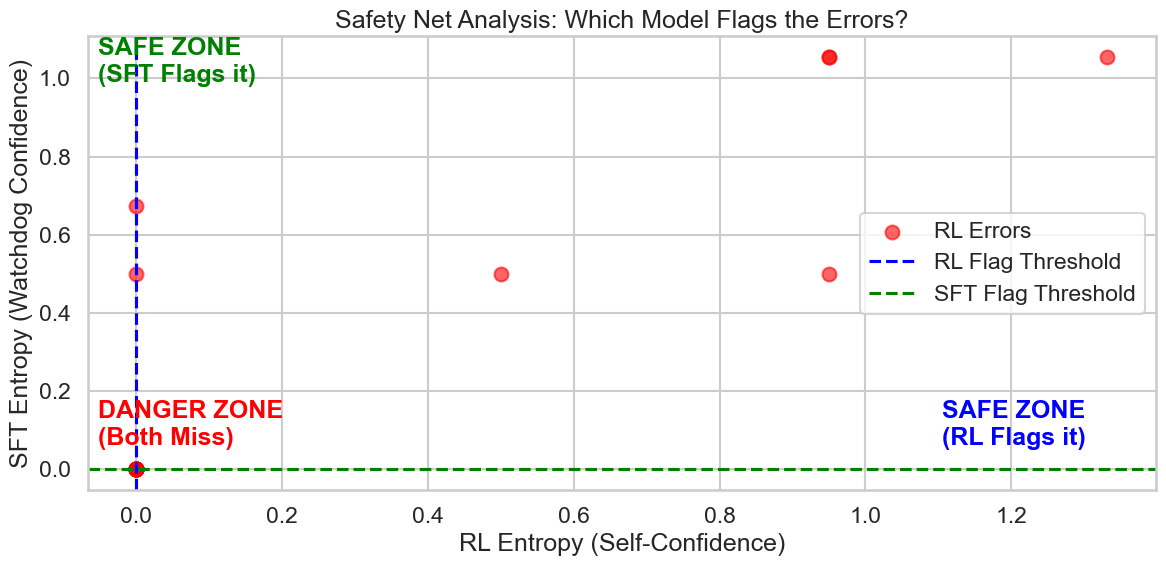

In [15]:
import sqlite3
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']

        # Select Semantic Entropy specifically (or Divergence if Ent is missing)
        # We prefer Semantic Entropy as requested
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.predicted_answer,
            r.is_correct,
            r.uq_semantic_entropy, 
            r.uq_semantic_div,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def simulate_scenarios():
    df_raw = get_data()
    if df_raw is None or df_raw.empty: return

    # Pivot SFT vs RL
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    # Master DataFrame: RL is the "Actor", SFT is the "Watchdog"
    df = df_rl.join(df_sft, lsuffix='_RL', rsuffix='_SFT', how='inner')
    
    # Metric to use: Semantic Entropy
    # (Fallback to divergence if entropy is 0/null, but usually entropy is cleaner)
    metric_rl = 'uq_semantic_entropy_RL'
    metric_sft = 'uq_semantic_entropy_SFT'

    # Ground Truth: We are trying to detect RL Errors
    y_true_error = 1 - df['is_correct_RL'] # 1 if Error, 0 if Correct
    
    print("\n" + "="*80)
    print("SIMULATION: DETECTING RL ERRORS")
    print(f"Total RL Errors to Catch: {y_true_error.sum()}")
    print("="*80)

    # --- SCENARIO 1: INTROSPECTIVE (RL judges RL) ---
    precision_rl, recall_rl, thresholds_rl = precision_recall_curve(y_true_error, df[metric_rl])
    auprc_rl = auc(recall_rl, precision_rl)
    
    # Find threshold at 90% Recall (Catch 90% of errors)
    idx_rl = np.argmax(recall_rl >= 0.90) if any(recall_rl >= 0.90) else 0
    thresh_rl = thresholds_rl[idx_rl] if idx_rl < len(thresholds_rl) else 0
    prec_at_90_rl = precision_rl[idx_rl]

    # --- SCENARIO 2: PROXY WATCHDOG (SFT judges RL) ---
    precision_sft, recall_sft, thresholds_sft = precision_recall_curve(y_true_error, df[metric_sft])
    auprc_sft = auc(recall_sft, precision_sft)
    
    # Find threshold at 90% Recall
    idx_sft = np.argmax(recall_sft >= 0.90) if any(recall_sft >= 0.90) else 0
    thresh_sft = thresholds_sft[idx_sft] if idx_sft < len(thresholds_sft) else 0
    prec_at_90_sft = precision_sft[idx_sft]

    print(f"{'Metric':<20} | {'AUPRC (Higher=Better)':<20} | {'Precision @ 90% Recall':<20}")
    print("-" * 70)
    print(f"{'RL Self-Check':<20} | {auprc_rl:.4f}               | {prec_at_90_rl:.4f}")
    print(f"{'SFT Watchdog':<20} | {auprc_sft:.4f}               | {prec_at_90_sft:.4f}")
    print("-" * 70)

    # --- DEEP DIVE: WRONG -> WRONG CASES ---
    # These are the hardest errors. RL is wrong. SFT was wrong.
    # Does SFT still know it's confused?
    
    mask_ww = (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0)
    df_ww = df[mask_ww].copy()
    
    print(f"\nFORENSIC ANALYSIS: 'WRONG -> WRONG' CASES (N={len(df_ww)})")
    
    # Count how many are flagged by the "90% Recall" thresholds derived above
    df_ww['Caught_by_RL'] = df_ww[metric_rl] > thresh_rl
    df_ww['Caught_by_SFT'] = df_ww[metric_sft] > thresh_sft
    
    rl_catch_rate = df_ww['Caught_by_RL'].mean()
    sft_catch_rate = df_ww['Caught_by_SFT'].mean()
    
    print(f"1. RL Self-Check catch rate: {rl_catch_rate:.1%} (Threshold: {thresh_rl:.3f})")
    print(f"2. SFT Watchdog catch rate:  {sft_catch_rate:.1%} (Threshold: {thresh_sft:.3f})")
    
    # --- VISUALIZATION: THE SAFETY NET ---
    plt.figure(figsize=(12, 6))
    
    # Filter to only RL Errors
    errors = df[df['is_correct_RL'] == 0]
    
    plt.scatter(errors[metric_rl], errors[metric_sft], c='red', alpha=0.6, s=100, label='RL Errors')
    
    # Add thresholds
    plt.axvline(thresh_rl, color='blue', linestyle='--', label='RL Flag Threshold')
    plt.axhline(thresh_sft, color='green', linestyle='--', label='SFT Flag Threshold')
    
    plt.title("Safety Net Analysis: Which Model Flags the Errors?")
    plt.xlabel("RL Entropy (Self-Confidence)")
    plt.ylabel("SFT Entropy (Watchdog Confidence)")
    
    # Annotate Quadrants
    plt.text(0.01, 0.9, "SAFE ZONE\n(SFT Flags it)", color='green', fontweight='bold', transform=plt.gca().transAxes)
    plt.text(0.8, 0.1, "SAFE ZONE\n(RL Flags it)", color='blue', fontweight='bold', transform=plt.gca().transAxes)
    plt.text(0.01, 0.1, "DANGER ZONE\n(Both Miss)", color='red', fontweight='bold', transform=plt.gca().transAxes)
    
    plt.legend()
    plt.tight_layout()
    plt.savefig('proxy_uq_safety_net.png')
    
    print("\n[Generated 'proxy_uq_safety_net.png']")
    print("Interpretation: Points in the top-left quadrant are errors that RL 'lied' about")
    print("but the SFT Watchdog successfully caught.")

if __name__ == "__main__":
    simulate_scenarios()

In [14]:
import sqlite3
import pandas as pd
import numpy as np
import os
from scipy.stats import ks_2samp, pointbiserialr
from sklearn.metrics import roc_auc_score

DB_PATH = "db/results.sqlite"

def get_db_columns(conn):
    """Auto-detects available UQ columns."""
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(Results)")
    all_cols = [row[1] for row in cursor.fetchall()]
    # Filter for uncertainty columns
    return [c for c in all_cols if c.startswith('uq_')]

def safe_auroc(y_true, y_score):
    """Calculates AUROC, handling edge cases and NaNs."""
    try:
        # Check for NaN
        mask = ~np.isnan(y_score)
        y_true = y_true[mask]
        y_score = y_score[mask]
        
        # Check for single class
        if len(np.unique(y_true)) < 2: return 0.5
        
        # We assume Higher Score = Higher Uncertainty = Higher Probability of Error (Class 0)
        # ROC expects y_score to predict Class 1. 
        # So we predict "Error" (1 - is_correct).
        return roc_auc_score(1 - y_true, y_score)
    except:
        return 0.5

def generate_stats():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get Experiment
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        # Get Columns
        uq_cols = get_db_columns(conn)
        cols_sql = ", ".join([f"r.{c}" for c in uq_cols])

        # Fetch Data
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.is_correct,
            {cols_sql},
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
    finally:
        conn.close()

    if df.empty: return

    # Pivot Data
    df_sft = df[df['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df[df['training_method'] == 'RL'].set_index('q_id')
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')

    print("\n" + "="*80)
    print("COMPREHENSIVE EXPERIMENTAL STATISTICS")
    print("="*80)
    
    # 1. Global Performance
    acc_sft = df['is_correct_SFT'].mean()
    acc_rl = df['is_correct_RL'].mean()
    print(f"Global Accuracy:")
    print(f"  SFT: {acc_sft:.2%} ({df['is_correct_SFT'].sum()}/{len(df)})")
    print(f"  RL:  {acc_rl:.2%} ({df['is_correct_RL'].sum()}/{len(df)})")
    print(f"  Delta: {acc_rl - acc_sft:+.2%}")
    print("-" * 80)

    # 2. Metric Deep Dive
    print(f"{'METRIC':<30} | {'AUROC (SFT->RL)':<17} | {'Mean (Right/Wrong)':<25} | {'KS Stat':<8}")
    print("-" * 120)

    for col in uq_cols:
        sft_col = f"{col}_SFT"
        rl_col = f"{col}_RL"
        
        # AUROC (Higher = Better Error Detection)
        auc_sft = safe_auroc(df['is_correct_SFT'], df[sft_col])
        auc_rl = safe_auroc(df['is_correct_RL'], df[rl_col])
        
        # Means
        # SFT
        mean_r_sft = df[df['is_correct_SFT']==1][sft_col].mean()
        mean_w_sft = df[df['is_correct_SFT']==0][sft_col].mean()
        # RL
        mean_r_rl = df[df['is_correct_RL']==1][rl_col].mean()
        mean_w_rl = df[df['is_correct_RL']==0][rl_col].mean()
        
        # KS Test (Distribution Shift)
        ks, _ = ks_2samp(df[sft_col], df[rl_col])
        
        label = col.replace('uq_', '').replace('_', ' ').title()
        print(f"{label:<30} | {auc_sft:.3f} -> {auc_rl:.3f}     | SFT: {mean_r_sft:.2f}/{mean_w_sft:.2f}       | {ks:.3f}")
        print(f"{'':<30} | {'':<17} | RL:  {mean_r_rl:.2f}/{mean_w_rl:.2f}       |")
        print("-" * 120)

    # 3. Correlation Matrix (RL Model Only)
    print("\n[RL Model Metric Correlations]")
    print("(Do the metrics agree with each other?)")
    rl_cols = [f"{c}_RL" for c in uq_cols]
    corr_mat = df[rl_cols].corr()
    # Rename index/cols for display
    short_names = [c.replace('uq_', '').replace('_RL', '') for c in rl_cols]
    corr_mat.index = short_names
    corr_mat.columns = short_names
    print(corr_mat.round(2))

    # 4. Confidence Shift Analysis
    print("\n[Confidence Shift Analysis]")
    print("(Did RL make the model more confident (Lower Score) or less?)")
    
    for col in uq_cols:
        delta = df[f"{col}_RL"] - df[f"{col}_SFT"]
        
        # Conditionals
        # 1. Right -> Right (Stability)
        mask_rr = (df['is_correct_SFT']==1) & (df['is_correct_RL']==1)
        rr_change = delta[mask_rr].mean()
        
        # 2. Wrong -> Wrong (Stubbornness)
        mask_ww = (df['is_correct_SFT']==0) & (df['is_correct_RL']==0)
        ww_change = delta[mask_ww].mean()
        
        # 3. Wrong -> Right (Learning)
        mask_wr = (df['is_correct_SFT']==0) & (df['is_correct_RL']==1)
        wr_change = delta[mask_wr].mean()
        
        label = col.replace('uq_', '')
        print(f"\nMetric: {label}")
        print(f"  Right->Right (Stable):   {rr_change:+.4f} (Negative = Sharpened)")
        print(f"  Wrong->Wrong (Stubborn): {ww_change:+.4f} (Negative = Overconfident)")
        print(f"  Wrong->Right (Learned):  {wr_change:+.4f} (Ideally huge negative)")

if __name__ == "__main__":
    generate_stats()

Analyzing Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)

COMPREHENSIVE EXPERIMENTAL STATISTICS
Global Accuracy:
  SFT: 85.00% (170/200)
  RL:  91.00% (182/200)
  Delta: +6.00%
--------------------------------------------------------------------------------
METRIC                         | AUROC (SFT->RL)   | Mean (Right/Wrong)        | KS Stat 
------------------------------------------------------------------------------------------------------------------------
Mech Score                     | 0.469 -> 0.486     | SFT: 0.04/0.03       | 0.650
                               |                   | RL:  0.05/0.05       |
------------------------------------------------------------------------------------------------------------------------
Avg Entropy                    | 0.527 -> 0.454     | SFT: 0.06/0.06       | 0.160
                               |                   | RL:  0.05/0.05       |
------------------------------------------------------------------------------------------

In [13]:
import sqlite3
import pandas as pd
import numpy as np
import os

DB_PATH = "db/results.sqlite"

def get_db_columns(conn):
    """Auto-detects the semantic divergence column name."""
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(Results)")
    all_cols = [row[1] for row in cursor.fetchall()]
    # Look for the correct column name (usually uq_semantic_div)
    for c in all_cols:
        if 'semantic_div' in c: return c
    return None

def analyze_semantic_traps():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        # Auto-detect column
        sem_col = get_db_columns(conn)
        if not sem_col:
            print("Error: Could not find Semantic Divergence column in DB.")
            return
        print(f"Targeting Column: {sem_col}")

        # Fetch Data
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.gold_answer,
            r.predicted_answer,
            r.is_correct,
            r.{sem_col} as sem_div,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
    finally:
        conn.close()

    if df.empty: return

    # Pivot Data
    df_sft = df[df['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df[df['training_method'] == 'RL'].set_index('q_id')
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')

    # --- ANALYSIS ---
    
    # 1. Establish the "Trust Threshold"
    # What is the normal semantic divergence for a CORRECT RL answer?
    correct_rl = df[df['is_correct_RL'] == 1]
    
    if correct_rl.empty:
        print("Warning: RL model has 0 correct answers. Cannot establish baseline.")
        return

    threshold_mean = correct_rl['sem_div_RL'].mean()
    print(f"\n[Baseline Statistics]")
    print(f"Avg Divergence for CORRECT answers: {threshold_mean:.4f}")
    print(f"(We define a 'Trap' as a WRONG answer with divergence <= {threshold_mean:.4f})")

    # 2. Find the Traps
    # Condition: Wrong -> Wrong AND RL_Divergence <= Threshold
    wrong_wrong = df[(df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0)].copy()
    traps = wrong_wrong[wrong_wrong['sem_div_RL'] <= threshold_mean].sort_values('sem_div_RL')
    
    print("\n" + "="*80)
    print(f"SEMANTIC DIVERGENCE FORENSIC REPORT")
    print(f"Total 'Wrong -> Wrong' cases: {len(wrong_wrong)}")
    print(f"Detected TRAPS (Misleadingly High Confidence): {len(traps)}")
    print("="*80)

    if traps.empty:
        print("Good news: No semantic traps found. All wrong answers had high divergence.")
    
    for i, (_, row) in enumerate(traps.iterrows()):
        print(f"\n[Trap #{i+1}]")
        print(f"Q: {row['question_text_SFT'][:100]}...")
        print(f"Gold Answer: {row['gold_answer_SFT']}")
        print("-" * 40)
        print(f"SFT Answer (Wrong): {str(row['predicted_answer_SFT'])[:60]}...")
        print(f"   Div Score: {row['sem_div_SFT']:.4f}")
        print("-" * 40)
        print(f"RL Answer (Wrong):  {str(row['predicted_answer_RL'])[:60]}...")
        print(f"   Div Score: {row['sem_div_RL']:.4f}  <-- MISLEADINGLY LOW")
        print(f"   (Confidence Gain: {row['sem_div_SFT'] - row['sem_div_RL']:.4f})")
        print("="*80)

if __name__ == "__main__":
    analyze_semantic_traps()

Analyzing Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)
Targeting Column: uq_semantic_div

[Baseline Statistics]
Avg Divergence for CORRECT answers: 0.2242
(We define a 'Trap' as a WRONG answer with divergence <= 0.2242)

SEMANTIC DIVERGENCE FORENSIC REPORT
Total 'Wrong -> Wrong' cases: 17
Detected TRAPS (Misleadingly High Confidence): 13

[Trap #1]
Q: Each bird eats 12 beetles per day, each snake eats 3 birds per day, and each jaguar eats 5 snakes pe...
Gold Answer: 1080
----------------------------------------
SFT Answer (Wrong): 0...
   Div Score: 0.4000
----------------------------------------
RL Answer (Wrong):  0...
   Div Score: 0.2000  <-- MISLEADINGLY LOW
   (Confidence Gain: 0.2000)

[Trap #2]
Q: Mrs. Snyder used to spend 40% of her monthly income on rent and utilities. Her salary was recently i...
Gold Answer: 1000
----------------------------------------
SFT Answer (Wrong): 0...
   Div Score: 0.2000
----------------------------------------
RL Answer (Wrong):  0...
   Div

In [12]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import ks_2samp, ttest_rel
from sklearn.metrics import roc_auc_score

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_db_columns(conn):
    """Auto-detects available UQ columns and maps them to distinct names."""
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(Results)")
    all_cols = [row[1] for row in cursor.fetchall()]
    uq_cols = [c for c in all_cols if c.startswith('uq_')]
    
    mapping = {}
    for c in uq_cols:
        if 'avg_entropy' in c:    mapping[c] = 'Entropic: Avg Entropy'
        elif 'min_logit' in c:    mapping[c] = 'Entropic: Min Logit Gap'
        elif 'saup' in c:         mapping[c] = 'Entropic: SAUP'
        elif 'mech' in c:         mapping[c] = 'Mechanistic: Neuron Confidence'
        elif 'semantic_div' in c: mapping[c] = 'Semantic: Divergence'
        elif 'semantic_ent' in c: mapping[c] = 'Semantic: Entropy'
        elif 'heuristic' in c:    mapping[c] = 'Heuristic: Verbal Score'
        else:                     mapping[c] = c.replace('uq_', '').title()
    
    return mapping

def calculate_snr(df, metric_col, is_correct_col):
    """Signal-to-Noise Ratio: (Mean_Wrong - Mean_Right) / Std_Combined"""
    right = df[df[is_correct_col] == 1][metric_col]
    wrong = df[df[is_correct_col] == 0][metric_col]
    
    if len(right) < 2 or len(wrong) < 2: return 0.0
    
    mu_diff = wrong.mean() - right.mean() # Expect Positive for Uncertainty
    sigma = df[metric_col].std()
    return mu_diff / (sigma + 1e-9)

def analyze_holistic_advanced():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return

    conn = sqlite3.connect(DB_PATH)
    try:
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        METRICS = get_db_columns(conn)
        cols_sql = ", ".join([f"r.{col}" for col in METRICS.keys()])
        
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.is_correct,
            {cols_sql},
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
    except Exception as e:
        print(f"DB Error: {e}")
        return
    finally:
        conn.close()

    if df.empty: return

    # Pivot SFT/RL
    df_sft = df[df['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df[df['training_method'] == 'RL'].set_index('q_id')
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    print("\n" + "="*120)
    print(f"{'METRIC':<30} | {'AUROC (SFT->RL)':<15} | {'SNR (SFT->RL)':<15} | {'Shift (KS)':<10} | {'Hack Idx':<10}")
    print("-" * 120)

    stats_list = []

    for col, label in METRICS.items():
        sft_col = f"{col}_SFT"
        rl_col = f"{col}_RL"
        
        if sft_col not in df.columns: continue

        # 1. AUROC (Utility) - Higher is Better
        # We assume higher metric = higher uncertainty = higher prob of error (is_correct=0)
        # So we invert is_correct (0->1, 1->0) for standard ROC calculation
        try:
            auc_sft = roc_auc_score(1 - df['is_correct_SFT'], df[sft_col])
            auc_rl = roc_auc_score(1 - df['is_correct_RL'], df[rl_col])
        except:
            auc_sft, auc_rl = 0.5, 0.5

        # 2. SNR (Separability) - Higher is Better
        snr_sft = calculate_snr(df, sft_col, 'is_correct_SFT')
        snr_rl = calculate_snr(df, rl_col, 'is_correct_RL')

        # 3. Distribution Shift (KS Test) - Higher = More Drastic Change
        ks_stat, _ = ks_2samp(df[sft_col], df[rl_col])

        # 4. Reward Hacking Index
        # Compare Mean Delta for Right answers vs Wrong answers.
        # Ideally: Right answers drop uncertainty (-), Wrong answers increase (+).
        # Hacking = Wrong answers drop MORE than Right answers.
        delta = df[rl_col] - df[sft_col]
        
        mean_delta_right = delta[df['is_correct_RL'] == 1].mean()
        mean_delta_wrong = delta[df['is_correct_RL'] == 0].mean()
        
        # If both are negative (confidence boost), did wrong boost more?
        # A positive "Hack Idx" means RL made Wrong answers relatively MORE confident than Right ones compared to baseline.
        hack_idx = mean_delta_right - mean_delta_wrong 

        print(f"{label:<30} | {auc_sft:.3f} -> {auc_rl:.3f}   | {snr_sft:.3f} -> {snr_rl:.3f}   | {ks_stat:.3f}      | {hack_idx:+.4f}")
        
        stats_list.append({
            'Metric': label,
            'AUC_Gain': auc_rl - auc_sft,
            'SNR_Gain': snr_rl - snr_sft,
            'KS': ks_stat,
            'Hack_Idx': hack_idx
        })

    print("-" * 120)
    
    # Interpretation
    best_utility = max(stats_list, key=lambda x: x['AUC_Gain'])
    worst_hack = max(stats_list, key=lambda x: x['Hack_Idx'])
    
    print("\n[KEY INSIGHTS]")
    print(f"1. Best Improver: '{best_utility['Metric']}' gained +{best_utility['AUC_Gain']:.3f} AUROC.")
    print(f"   (This metric became much better at detecting errors after RL).")
    
    print(f"2. Risk Flag:     '{worst_hack['Metric']}' has Hack Index {worst_hack['Hack_Idx']:+.4f}.")
    if worst_hack['Hack_Idx'] > 0:
        print("   (Warning: RL made Wrong answers disproportionately more confident on this metric.)")
    else:
        print("   (Good: RL improved calibration; Right answers gained more confidence than Wrong ones.)")

    print("\nGlossary:")
    print(" * AUROC: Ability to distinguish Right vs Wrong (0.5=Random, 1.0=Perfect).")
    print(" * SNR: Signal-to-Noise Ratio (Distance between Right/Wrong clusters).")
    print(" * KS: Kolmogorov-Smirnov stat (How much did RL change the distribution shape?).")
    print(" * Hack Idx: (Right_Delta - Wrong_Delta). Positive = Wrong answers got greater confidence boost.")

if __name__ == "__main__":
    analyze_holistic_advanced()

Analyzing Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)

METRIC                         | AUROC (SFT->RL) | SNR (SFT->RL)   | Shift (KS) | Hack Idx  
------------------------------------------------------------------------------------------------------------------------
Mechanistic: Neuron Confidence | 0.469 -> 0.486   | -0.137 -> -0.146   | 0.650      | +0.0006
Entropic: Avg Entropy          | 0.527 -> 0.454   | 0.099 -> -0.134   | 0.160      | +0.0006
Entropic: Min Logit Gap        | 0.459 -> 0.481   | -0.074 -> -0.077   | 0.085      | +0.0037
Entropic: SAUP                 | 0.559 -> 0.470   | 0.175 -> -0.083   | 0.210      | +0.0040
Semantic: Divergence           | 0.740 -> 0.600   | 1.177 -> 0.877   | 0.150      | -0.0484
Semantic: Entropy              | 0.746 -> 0.598   | 1.201 -> 0.823   | 0.150      | -0.0868
Heuristic: Verbal Score        | 0.482 -> 0.540   | -0.193 -> 0.430   | 0.010      | -0.0054
---------------------------------------------------------------------------

In [11]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_db_columns(conn):
    """Auto-detects available UQ columns from the Results table."""
    cursor = conn.cursor()
    cursor.execute("PRAGMA table_info(Results)")
    all_cols = [row[1] for row in cursor.fetchall()]
    
    # Filter for uncertainty columns (usually start with uq_)
    uq_cols = [c for c in all_cols if c.startswith('uq_')]
    
    # Create a pretty mapping
    mapping = {}
    for c in uq_cols:
        if 'avg_entropy' in c: mapping[c] = 'Semantic Entropy (Fluency)'
        elif 'mech' in c:      mapping[c] = 'Mechanistic Score (Internal)'
        elif 'sem' in c:       mapping[c] = 'Semantic Divergence (Consistency)'
        elif 'heu' in c:       mapping[c] = 'Heuristic Score (Verbal)'
        else:                  mapping[c] = c.replace('uq_', '').replace('_', ' ').title()
    
    print(f"Auto-detected Metrics: {list(mapping.keys())}")
    return mapping

def analyze_holistic():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return

    conn = sqlite3.connect(DB_PATH)
    try:
        # 1. Get Latest Experiment
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        # 2. Auto-Detect Columns
        METRICS = get_db_columns(conn)
        
        # 3. Construct Query
        cols_sql = ", ".join([f"r.{col}" for col in METRICS.keys()])
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.gold_answer,
            r.predicted_answer,
            r.is_correct,
            {cols_sql},
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        
    except Exception as e:
        print(f"Database Error: {e}")
        return
    finally:
        conn.close()

    if df.empty:
        print("No results found.")
        return

    # Pivot SFT/RL
    df_sft = df[df['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df[df['training_method'] == 'RL'].set_index('q_id')
    
    # Merge
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    # Categorize
    conditions = [
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 0)
    ]
    choices = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    df['Category'] = np.select(conditions, choices, default='Other')

    palette = {
        'Wrong -> Wrong': '#d62728', 'Right -> Right': '#2ca02c',
        'Fixed (W->R)':   '#1f77b4', 'Broken (R->W)':  '#ff7f0e'
    }

    print("\n" + "="*60)
    print("HOLISTIC METRIC ANALYSIS REPORT")
    print("="*60)

    summary_stats = []

    for col, label in METRICS.items():
        if f"{col}_SFT" not in df.columns: continue
            
        print(f"Plotting: {label}...")
        
        # Calculate Delta
        delta_col = f"{col}_Delta"
        df[delta_col] = df[f"{col}_RL"] - df[f"{col}_SFT"]

        # --- PLOT 1: SCATTER ---
        plt.figure(figsize=(10, 8))
        sns.scatterplot(
            data=df, x=f"{col}_SFT", y=f"{col}_RL", 
            hue='Category', style='Category', palette=palette, s=100, alpha=0.7
        )
        
        # Diagonal Line
        min_val = min(df[f"{col}_SFT"].min(), df[f"{col}_RL"].min())
        max_val = max(df[f"{col}_SFT"].max(), df[f"{col}_RL"].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='No Change')
        
        plt.title(f"SFT vs. RL: {label}")
        plt.xlabel(f"SFT {label}")
        plt.ylabel(f"RL {label}")
        plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
        plt.tight_layout()
        safe_name = label.split(' ')[0].lower()
        plt.savefig(f"scatter_{safe_name}.png")
        plt.close()

        # --- PLOT 2: HISTOGRAM ---
        g = sns.FacetGrid(df, col="Category", col_wrap=2, hue="Category", 
                          palette=palette, sharex=True, sharey=False, height=4, aspect=1.5)
        g.map(sns.histplot, delta_col, kde=True, bins=15)
        g.refline(x=0, linestyle="--", color="black")
        g.fig.suptitle(f"Shift in {label} (RL - SFT)", y=1.02)
        plt.tight_layout()
        plt.savefig(f"hist_{safe_name}.png")
        plt.close()

        # Stats
        rl_correct_mean = df[df['is_correct_RL']==1][f"{col}_RL"].mean()
        rl_wrong_mean = df[df['is_correct_RL']==0][f"{col}_RL"].mean()
        
        # FIXED: Ensure key consistency
        summary_stats.append({
            "Metric": label,
            "Delta (RL-SFT)": df[delta_col].mean(), 
            "Correlation": df[f"{col}_SFT"].corr(df[f"{col}_RL"]),
            "Discrim (W-R)": rl_wrong_mean - rl_correct_mean
        })

    print("\n" + "="*85)
    print(f"{'Metric':<40} | {'Delta':<10} | {'Corr':<8} | {'Discrim (W-R)':<15}")
    print("-" * 85)
    for stat in summary_stats:
        # FIXED: Accessing the correct key 'Delta (RL-SFT)'
        print(f"{stat['Metric']:<40} | {stat['Delta (RL-SFT)']:<10.4f} | {stat['Correlation']:<8.4f} | {stat['Discrim (W-R)']:<15.4f}")
    print("="*85)

if __name__ == "__main__":
    analyze_holistic()

Analyzing Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)
Auto-detected Metrics: ['uq_mech_score', 'uq_avg_entropy', 'uq_min_logit_gap', 'uq_saup_score', 'uq_semantic_div', 'uq_semantic_entropy', 'uq_heuristic_score']

HOLISTIC METRIC ANALYSIS REPORT
Plotting: Mechanistic Score (Internal)...
Plotting: Semantic Entropy (Fluency)...
Plotting: Min Logit Gap...
Plotting: Saup Score...
Plotting: Semantic Divergence (Consistency)...
Plotting: Semantic Divergence (Consistency)...
Plotting: Heuristic Score (Verbal)...

Metric                                   | Delta      | Corr     | Discrim (W-R)  
-------------------------------------------------------------------------------------
Mechanistic Score (Internal)             | 0.0156     | 0.3134   | -0.0013        
Semantic Entropy (Fluency)               | -0.0066    | 0.2758   | -0.0027        
Min Logit Gap                            | 0.0257     | 0.0594   | -0.0146        
Saup Score                               | -0.0166    | 0.2211  

Analyzing Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)
Graphs saved to project root.

DATA ANALYSIS REPORT (COPY THIS)
Total Samples: 200

--- 1. CATEGORY BREAKDOWN ---
                count      mean    median       std
Category                                           
Broken (R->W)       1  0.031091  0.031091       NaN
Fixed (W->R)       13 -0.013469 -0.006358  0.037070
Right -> Right    169 -0.006046 -0.002540  0.029349
Wrong -> Wrong     17 -0.009377 -0.005744  0.021999

--- 2. OVERCONFIDENCE TRAPS ---
Count: 1 (0.5% of total)
Avg Confidence Gain in Traps: -0.0651

--- 3. SFT-RL CORRELATION ---
Pearson Correlation: 0.2758

--- 4. REPRESENTATIVE EXAMPLES ---

[Category: Wrong -> Wrong]
  Example 1:
    Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 sit...
    Gold: 59
    SFT Answer: 0 (Ent: 0.098)
    RL  Answer: 18 (Ent: 0.033)
    >> Delta: -0.065
  Example 2:
    Q: Each bird eats 12 beetles per day, each snake eats 3 birds per day, and eac

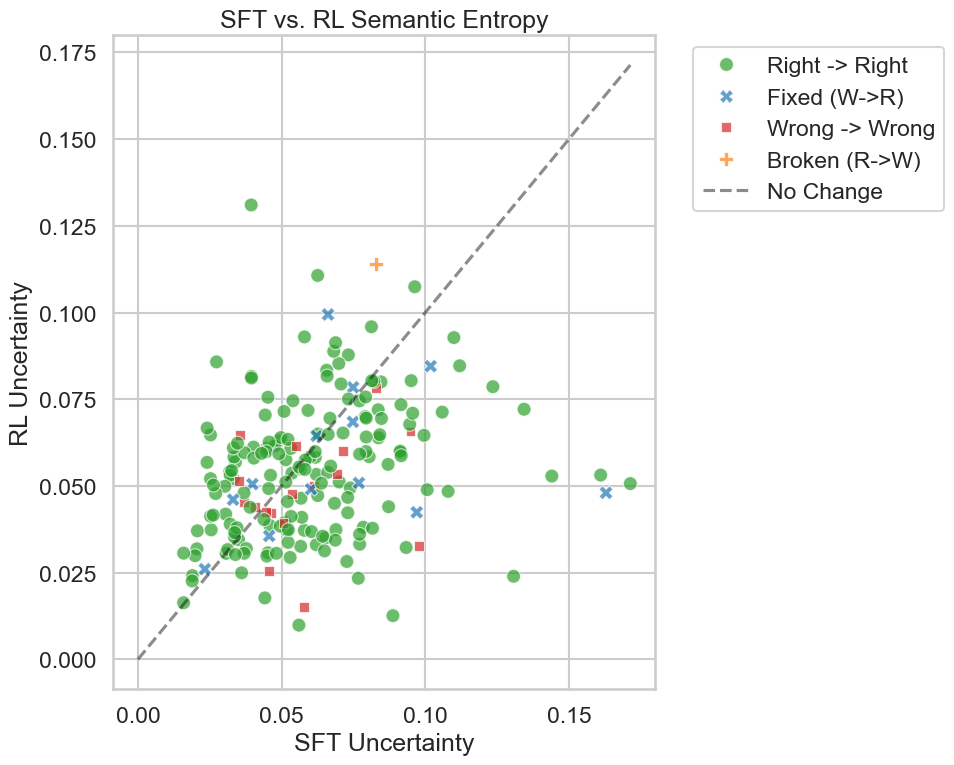

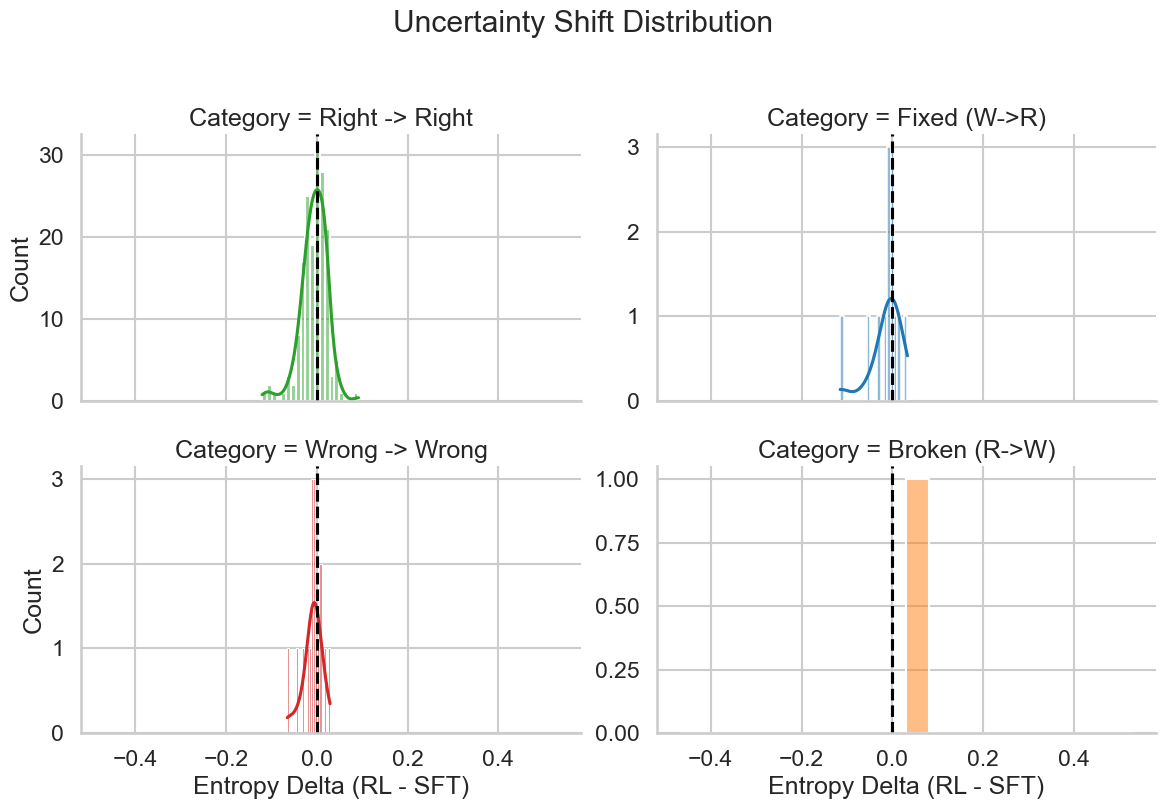

In [8]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment ID
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        exp_name = exp.iloc[0]['experiment_name']
        print(f"Analyzing Experiment: {exp_name} (ID: {exp_id})")

        # Fetch paired results
        # FIXED: Added r.gold_answer to the SELECT list
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.gold_answer, 
            r.predicted_answer,
            r.is_correct,
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def analyze_entropy_shift():
    df_raw = get_data()
    if df_raw is None or df_raw.empty:
        print("No data found.")
        return

    # Pivot Data: SFT vs RL
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    # Merge (Inner Join)
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    # Categorize Outcomes
    conditions = [
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 0)
    ]
    choices = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    df['Category'] = np.select(conditions, choices, default='Other')
    
    # Calculate Delta
    df['Entropy_Delta'] = df['uq_avg_entropy_RL'] - df['uq_avg_entropy_SFT']

    # --- PLOT 1: SCATTER ---
    plt.figure(figsize=(10, 8))
    palette = {
        'Wrong -> Wrong': '#d62728',  # Red
        'Right -> Right': '#2ca02c',  # Green
        'Fixed (W->R)':   '#1f77b4',  # Blue
        'Broken (R->W)':  '#ff7f0e'   # Orange
    }
    sns.scatterplot(
        data=df, x='uq_avg_entropy_SFT', y='uq_avg_entropy_RL', 
        hue='Category', style='Category', palette=palette, s=100, alpha=0.7
    )
    limit = max(df['uq_avg_entropy_SFT'].max(), df['uq_avg_entropy_RL'].max())
    plt.plot([0, limit], [0, limit], 'k--', alpha=0.5, label='No Change')
    plt.title("SFT vs. RL Semantic Entropy")
    plt.xlabel("SFT Uncertainty")
    plt.ylabel("RL Uncertainty")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.tight_layout()
    plt.savefig('scatter_entropy.png')

    # --- PLOT 2: HISTOGRAMS ---
    g = sns.FacetGrid(df, col="Category", col_wrap=2, hue="Category", 
                      palette=palette, sharex=True, sharey=False, height=4, aspect=1.5)
    g.map(sns.histplot, "Entropy_Delta", kde=True, bins=20)
    g.refline(x=0, linestyle="--", color="black")
    g.set_axis_labels("Entropy Delta (RL - SFT)", "Count")
    g.fig.suptitle("Uncertainty Shift Distribution", y=1.02)
    plt.tight_layout()
    plt.savefig('hist_entropy_delta.png')
    
    print("Graphs saved to project root.")

    # --- TEXT ANALYSIS OUTPUT ---
    print("\n" + "="*50)
    print("DATA ANALYSIS REPORT (COPY THIS)")
    print("="*50)
    
    print(f"Total Samples: {len(df)}")
    
    # 1. Category Summary
    print("\n--- 1. CATEGORY BREAKDOWN ---")
    summary = df.groupby('Category')['Entropy_Delta'].agg(['count', 'mean', 'median', 'std'])
    print(summary.to_string())

    # 2. Trap Analysis
    traps = df[(df['is_correct_RL'] == 0) & (df['Entropy_Delta'] < -0.05)]
    print(f"\n--- 2. OVERCONFIDENCE TRAPS ---")
    print(f"Count: {len(traps)} ({len(traps)/len(df)*100:.1f}% of total)")
    if not traps.empty:
        print(f"Avg Confidence Gain in Traps: {traps['Entropy_Delta'].mean():.4f}")

    # 3. Correlation
    corr = df['uq_avg_entropy_SFT'].corr(df['uq_avg_entropy_RL'])
    print(f"\n--- 3. SFT-RL CORRELATION ---")
    print(f"Pearson Correlation: {corr:.4f}")

    # 4. Detailed Examples
    print("\n--- 4. REPRESENTATIVE EXAMPLES ---")
    df['abs_change'] = df['Entropy_Delta'].abs()
    
    for cat in choices:
        subset = df[df['Category'] == cat]
        if subset.empty: continue
        
        examples = subset.sort_values('abs_change', ascending=False).head(2)
        
        print(f"\n[Category: {cat}]")
        for i, (_, row) in enumerate(examples.iterrows()):
            print(f"  Example {i+1}:")
            print(f"    Q: {row['question_text_SFT'][:80]}...")
            # Note: gold_answer_SFT and gold_answer_RL will be identical, so we can use SFT
            print(f"    Gold: {row['gold_answer_SFT']}")
            print(f"    SFT Answer: {str(row['predicted_answer_SFT'])[:]} (Ent: {row['uq_avg_entropy_SFT']:.3f})")
            print(f"    RL  Answer: {str(row['predicted_answer_RL'])[:]} (Ent: {row['uq_avg_entropy_RL']:.3f})")
            print(f"    >> Delta: {row['Entropy_Delta']:.3f}")

    print("="*50)

if __name__ == "__main__":
    analyze_entropy_shift()

Analyzing Experiment ID: 4
Loaded 200 paired samples.
Saved scatter_entropy.png
Saved hist_entropy_delta.png

FORENSIC EXAMPLES

Category: Wrong -> Wrong
Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 sit...
SFT Answer (0.098): 0
RL  Answer (0.033): 18
Change: -0.065
--------------------------------------------------------------------------------

Category: Right -> Right
Q: Irene earns $500 if she works for 40 hours a week and gets an extra $20 for ever...
SFT Answer (0.171): 700
RL  Answer (0.051): 700
Change: -0.121
--------------------------------------------------------------------------------

Category: Fixed (W->R)
Q: Jerome is taking a 150-mile bicycle trip. He wants to ride 12 miles for 12 days....
SFT Answer (0.163): 13
RL  Answer (0.048): 6
Change: -0.115
--------------------------------------------------------------------------------

Category: Broken (R->W)
Q: Dan owns an ice cream shop and every sixth customer gets a free ice cream cone. .

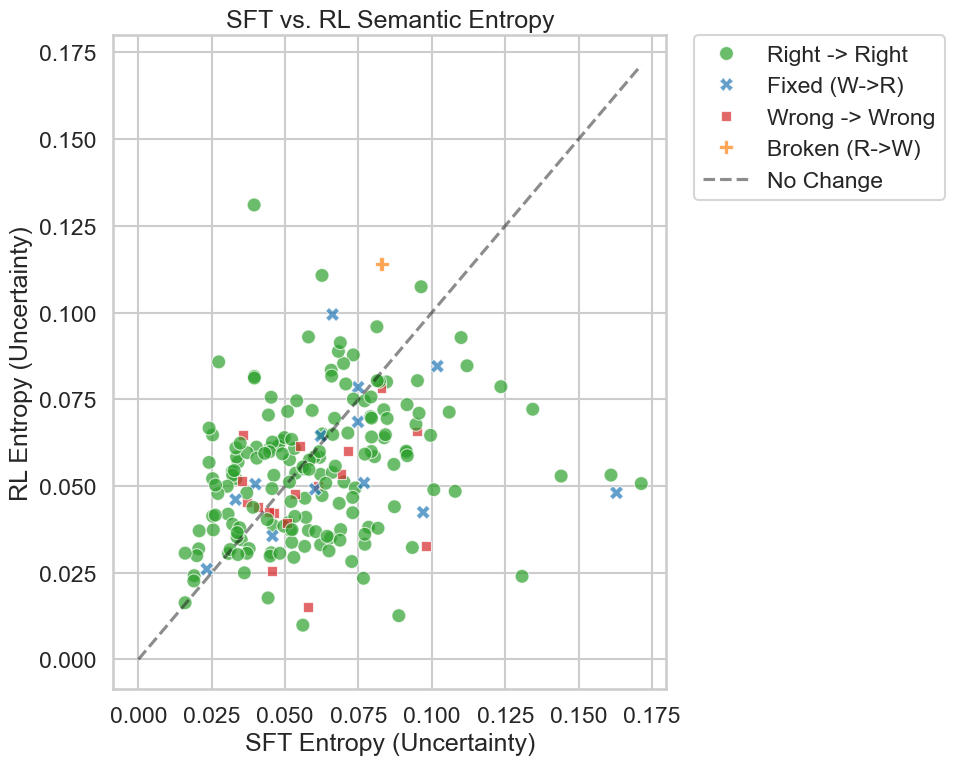

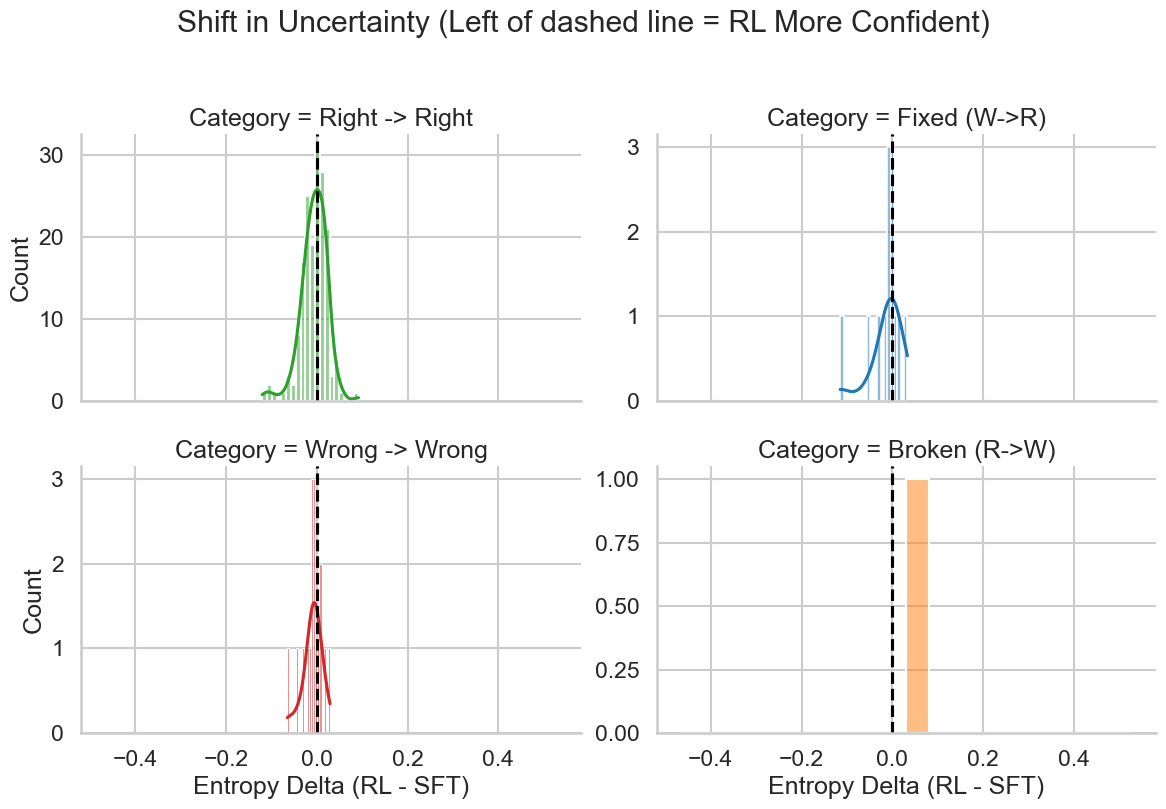

In [5]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment ID
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment ID: {exp_id}")

        # Fetch paired results
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.predicted_answer,
            r.is_correct,
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def analyze_scatter_hist():
    df_raw = get_data()
    if df_raw is None or df_raw.empty:
        print("No data found.")
        return

    # Pivot Data
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    # Define Categories
    conditions = [
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 1),
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 0)
    ]
    choices = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    df['Category'] = np.select(conditions, choices, default='Other')
    
    # Calculate Delta (Negative = RL More Confident)
    df['Entropy_Delta'] = df['uq_avg_entropy_RL'] - df['uq_avg_entropy_SFT']

    print(f"Loaded {len(df)} paired samples.")

    # --- PLOT 1: SCATTER PLOT ---
    plt.figure(figsize=(10, 8))
    
    # Create custom palette
    palette = {
        'Wrong -> Wrong': '#d62728',  # Red
        'Right -> Right': '#2ca02c',  # Green
        'Fixed (W->R)':   '#1f77b4',  # Blue
        'Broken (R->W)':  '#ff7f0e'   # Orange
    }
    
    sns.scatterplot(
        data=df, x='uq_avg_entropy_SFT', y='uq_avg_entropy_RL', 
        hue='Category', style='Category', palette=palette,
        s=100, alpha=0.7
    )
    
    # Add diagonal "No Change" line
    limit = max(df['uq_avg_entropy_SFT'].max(), df['uq_avg_entropy_RL'].max())
    plt.plot([0, limit], [0, limit], 'k--', alpha=0.5, label='No Change')
    
    plt.title("SFT vs. RL Semantic Entropy")
    plt.xlabel("SFT Entropy (Uncertainty)")
    plt.ylabel("RL Entropy (Uncertainty)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.savefig('scatter_entropy.png')
    print("Saved scatter_entropy.png")

    # --- PLOT 2: FACETED HISTOGRAMS ---
    g = sns.FacetGrid(df, col="Category", col_wrap=2, hue="Category", 
                      palette=palette, sharex=True, sharey=False, 
                      height=4, aspect=1.5)
    
    g.map(sns.histplot, "Entropy_Delta", kde=True, bins=20)
    
    # Add reference line at 0
    g.refline(x=0, linestyle="--", color="black")
    
    g.set_axis_labels("Entropy Delta (RL - SFT)", "Count")
    g.fig.suptitle("Shift in Uncertainty (Left of dashed line = RL More Confident)", y=1.02)
    plt.tight_layout()
    plt.savefig('hist_entropy_delta.png')
    print("Saved hist_entropy_delta.png")

    # --- PRINT EXAMPLES ---
    print("\n" + "="*80)
    print("FORENSIC EXAMPLES")
    print("="*80)
    
    # Sort by magnitude of change to find interesting cases
    df_sorted = df.reindex(df['Entropy_Delta'].abs().sort_values(ascending=False).index)
    
    for cat in choices:
        subset = df_sorted[df_sorted['Category'] == cat]
        if subset.empty: continue
        
        # Take the top example
        ex = subset.iloc[0]
        
        print(f"\nCategory: {cat}")
        print(f"Q: {ex['question_text_SFT'][:80]}...")
        print(f"SFT Answer ({ex['uq_avg_entropy_SFT']:.3f}): {str(ex['predicted_answer_SFT'])[:50]}")
        print(f"RL  Answer ({ex['uq_avg_entropy_RL']:.3f}): {str(ex['predicted_answer_RL'])[:50]}")
        print(f"Change: {ex['Entropy_Delta']:.3f}")
        print("-" * 80)

if __name__ == "__main__":
    analyze_scatter_hist()

Analyzing Experiment ID: 4
Data Loaded: 200 paired questions.
Category
Right -> Right    169
Wrong -> Wrong     17
Fixed (W->R)       13
Broken (R->W)       1
Name: count, dtype: int64
Saved: sft_rl_entropy_violin.png
Saved: sft_rl_entropy_delta.png

REPRESENTATIVE EXAMPLES

Category: Wrong -> Wrong
Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
SFT (0.098): 0
RL  (0.033): 18
------------------------------------------------------------

Category: Right -> Right
Q: Irene earns $500 if she works for 40 hours a week and gets an extra $20 for every hour of overtime. ...
SFT (0.171): 700
RL  (0.051): 700
------------------------------------------------------------

Category: Fixed (W->R)
Q: Jerome is taking a 150-mile bicycle trip. He wants to ride 12 miles for 12 days. How long will he ri...
SFT (0.163): 13
RL  (0.048): 6
------------------------------------------------------------

Category: Broken (R->W)
Q: Dan owns an ice cream

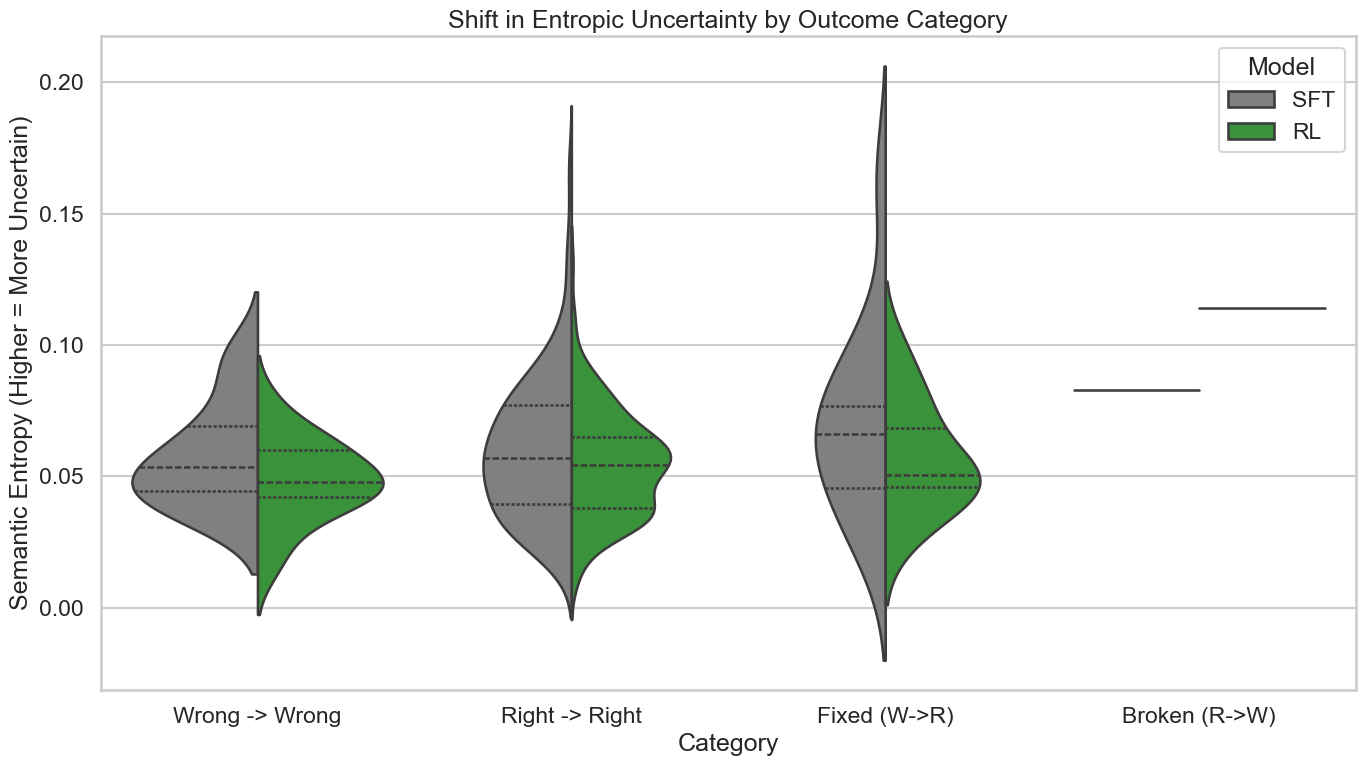

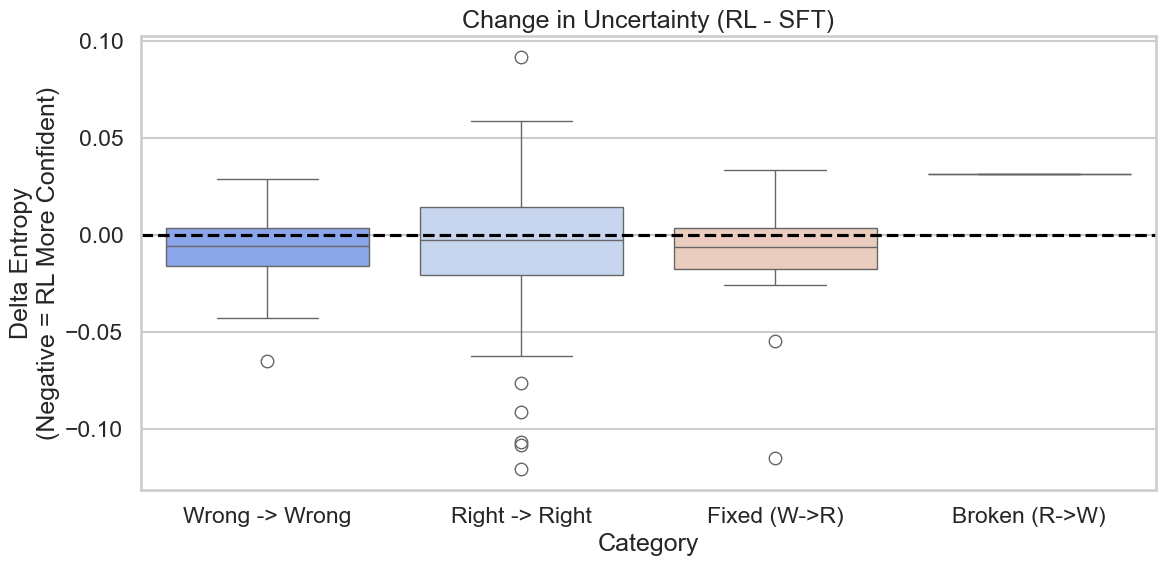

In [4]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set visual style
sns.set_theme(style="whitegrid", context="talk")

DB_PATH = "db/results.sqlite"

def get_latest_experiment_data():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return None

    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment ID
        exp = pd.read_sql("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Analyzing Experiment ID: {exp_id}")

        # Fetch paired results
        query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.predicted_answer,
            r.is_correct,
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        return df
    finally:
        conn.close()

def analyze_entropy_shift():
    df_raw = get_latest_experiment_data()
    if df_raw is None or df_raw.empty:
        print("No data found.")
        return

    # Pivot Data: SFT vs RL
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')
    
    # Merge on Question ID
    df = df_sft.join(df_rl, lsuffix='_SFT', rsuffix='_RL', how='inner')
    
    # Define Categories
    conditions = [
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 0), # Wrong -> Wrong
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 1), # Right -> Right
        (df['is_correct_SFT'] == 0) & (df['is_correct_RL'] == 1), # Wrong -> Right (Fixed)
        (df['is_correct_SFT'] == 1) & (df['is_correct_RL'] == 0)  # Right -> Wrong (Broken)
    ]
    choices = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    df['Category'] = np.select(conditions, choices, default='Other')
    
    # Calculate Delta
    df['Entropy_Delta'] = df['uq_avg_entropy_RL'] - df['uq_avg_entropy_SFT']

    print(f"Data Loaded: {len(df)} paired questions.")
    print(df['Category'].value_counts())

    # --- PLOT 1: Split Violin Plot (Absolute Scores) ---
    plt.figure(figsize=(14, 8))
    
    # Melt for seaborn
    plot_df = df.reset_index().melt(
        id_vars=['q_id', 'Category'], 
        value_vars=['uq_avg_entropy_SFT', 'uq_avg_entropy_RL'],
        var_name='Model', value_name='Entropy'
    )
    plot_df['Model'] = plot_df['Model'].apply(lambda x: 'SFT' if 'SFT' in x else 'RL')
    
    order = ['Wrong -> Wrong', 'Right -> Right', 'Fixed (W->R)', 'Broken (R->W)']
    
    sns.violinplot(
        data=plot_df, x='Category', y='Entropy', hue='Model',
        split=True, inner='quart', palette={'SFT': 'grey', 'RL': '#2ca02c'},
        order=order
    )
    plt.title("Shift in Entropic Uncertainty by Outcome Category")
    plt.ylabel("Semantic Entropy (Higher = More Uncertain)")
    plt.tight_layout()
    plt.savefig('sft_rl_entropy_violin.png')
    print("Saved: sft_rl_entropy_violin.png")

    # --- PLOT 2: Delta Boxplot ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='Category', y='Entropy_Delta', order=order, palette="coolwarm")
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Change in Uncertainty (RL - SFT)")
    plt.ylabel("Delta Entropy\n(Negative = RL More Confident)")
    plt.tight_layout()
    plt.savefig('sft_rl_entropy_delta.png')
    print("Saved: sft_rl_entropy_delta.png")

    # --- PRINT EXAMPLES ---
    print("\n" + "="*60)
    print("REPRESENTATIVE EXAMPLES")
    print("="*60)
    
    for cat in order:
        subset = df[df['Category'] == cat]
        if subset.empty: continue
        
        # Pick example with largest entropy change
        ex = subset.loc[subset['Entropy_Delta'].abs().idxmax()]
        
        print(f"\nCategory: {cat}")
        print(f"Q: {ex['question_text_SFT'][:100]}...")
        print(f"SFT ({ex['uq_avg_entropy_SFT']:.3f}): {ex['predicted_answer_SFT']}")
        print(f"RL  ({ex['uq_avg_entropy_RL']:.3f}): {ex['predicted_answer_RL']}")
        print("-" * 60)

if __name__ == "__main__":
    analyze_entropy_shift()

Loaded Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4, Date: 2025-11-27 06:12:52)

FORENSIC ANALYSIS (N=200)
Q15: [ENT TRAP] James creates a media empire.  He creates a movie for $2000....
  Gold: 448000
  SFT (✘): 20... (Mech: 0.0310)
  RL  (✘): 000... (Mech: 0.0415)
  >> Decoupling: Mech suppressed by -0.0105
--------------------------------------------------------------------------------
Q21: [ENT TRAP] Each bird eats 12 beetles per day, each snake eats 3 birds p...
  Gold: 1080
  SFT (✘): 0... (Mech: 0.0397)
  RL  (✘): 0... (Mech: 0.0459)
  >> Decoupling: Mech suppressed by -0.0062
--------------------------------------------------------------------------------
Q29: [ENT TRAP] Mrs. Snyder used to spend 40% of her monthly income on rent ...
  Gold: 1000
  SFT (✘): 0... (Mech: 0.0486)
  RL  (✘): 0... (Mech: 0.0566)
  >> Decoupling: Mech suppressed by -0.0080
--------------------------------------------------------------------------------
Q31: [ENT TRAP] Noah is a painter. He paints 

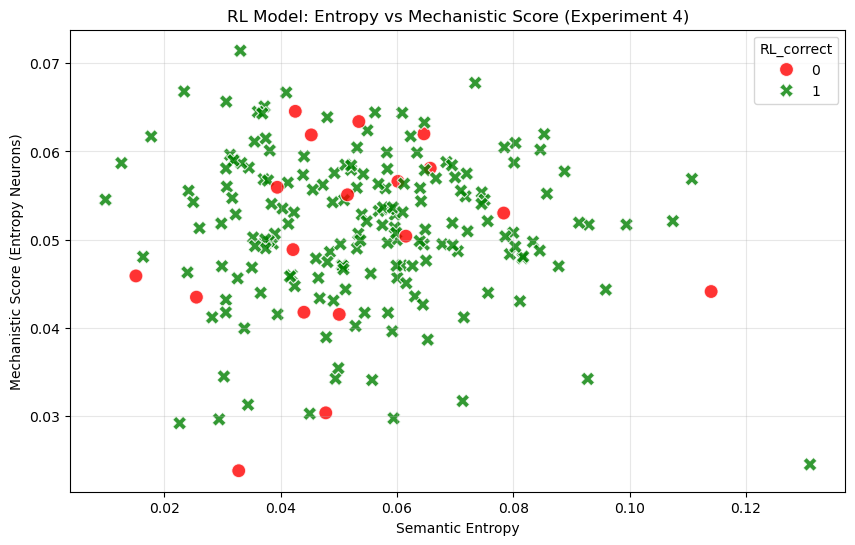

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- Configuration ---
DB_PATH = "db/results.sqlite"

if not os.path.exists(DB_PATH):
    print(f"Error: Database not found at {DB_PATH}")
else:
    conn = sqlite3.connect(DB_PATH)

    # 1. Get Latest Experiment ID (Corrected Column Name: experiment_id)
    try:
        exp_query = "SELECT experiment_id, experiment_name, run_date FROM Experiments ORDER BY run_date DESC LIMIT 1"
        exp_df = pd.read_sql_query(exp_query, conn)
        
        if exp_df.empty:
            print("No experiments found in DB.")
        else:
            exp_id = exp_df.iloc[0]['experiment_id']
            print(f"Loaded Experiment: {exp_df.iloc[0]['experiment_name']} (ID: {exp_id}, Date: {exp_df.iloc[0]['run_date']})")

            # 2. Fetch Results (Joining Results + Models)
            # We pull SFT/RL distinctions from the Models table
            data_query = f"""
            SELECT 
                r.question_id_external as q_id,
                r.question_text,
                r.gold_answer,
                r.predicted_answer,
                r.is_correct,
                r.uq_mech_score,   -- Using schema column name
                r.uq_avg_entropy,  -- Using schema column name
                m.training_method
            FROM Results r
            JOIN Models m ON r.model_id = m.model_id
            WHERE r.experiment_id = {exp_id}
            """
            df_raw = pd.read_sql_query(data_query, conn)
            
            # 3. Pivot Data (SFT vs RL)
            # This splits the single dataframe into two and merges them side-by-side
            df_sft = df_raw[df_raw['training_method'] == 'SFT'].copy()
            df_rl  = df_raw[df_raw['training_method'] == 'RL'].copy()

            # Rename columns for clarity
            sft_cols = {'predicted_answer': 'SFT_ans', 'is_correct': 'SFT_correct', 'uq_mech_score': 'SFT_mech', 'uq_avg_entropy': 'SFT_ent'}
            rl_cols  = {'predicted_answer': 'RL_ans',  'is_correct': 'RL_correct',  'uq_mech_score': 'RL_mech',  'uq_avg_entropy': 'RL_ent'}
            
            df_sft.rename(columns=sft_cols, inplace=True)
            df_rl.rename(columns=rl_cols, inplace=True)

            # Merge on Question ID
            df = pd.merge(df_sft[['q_id', 'question_text', 'gold_answer'] + list(sft_cols.values())],
                          df_rl[['q_id'] + list(rl_cols.values())],
                          on='q_id')

            # 4. Forensic Analysis (Double Traps)
            print(f"\n{'='*80}\nFORENSIC ANALYSIS (N={len(df)})\n{'='*80}")
            
            traps = 0
            for _, row in df.iterrows():
                # Trap Definition: RL is WRONG (0) but has LOWER uncertainty (higher confidence) than SFT
                # Note: Mechanistic score is usually lower = more confident/suppressed variance
                mech_trap = (not row['RL_correct']) and (row['RL_mech'] < row['SFT_mech'])
                ent_trap  = (not row['RL_correct']) and (row['RL_ent'] < row['SFT_ent'])
                
                if mech_trap or ent_trap:
                    traps += 1
                    t_type = "DOUBLE" if (mech_trap and ent_trap) else ("MECH" if mech_trap else "ENT")
                    q_short = row['question_text'][:60].replace('\n', ' ') + "..."
                    
                    print(f"Q{row['q_id']}: [{t_type} TRAP] {q_short}")
                    print(f"  Gold: {row['gold_answer']}")
                    print(f"  SFT ({'✔' if row['SFT_correct'] else '✘'}): {str(row['SFT_ans'])[:20]}... (Mech: {row['SFT_mech']:.4f})")
                    print(f"  RL  ({'✔' if row['RL_correct'] else '✘'}): {str(row['RL_ans'])[:20]}... (Mech: {row['RL_mech']:.4f})")
                    print(f"  >> Decoupling: Mech suppressed by {row['SFT_mech'] - row['RL_mech']:.4f}")
                    print("-" * 80)

            print(f"\nSummary: Found {traps} traps in {len(df)} questions.")

            # 5. Visualization
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=df, x='RL_ent', y='RL_mech', hue='RL_correct', style='RL_correct', palette={1: 'green', 0: 'red'}, s=100, alpha=0.8)
            plt.title(f"RL Model: Entropy vs Mechanistic Score (Experiment {exp_id})")
            plt.xlabel("Semantic Entropy")
            plt.ylabel("Mechanistic Score (Entropy Neurons)")
            plt.grid(True, alpha=0.3)
            plt.show()

    except Exception as e:
        print(f"Query Error: {e}")
    finally:
        conn.close()


>>> ANALYZING: SFT Model (Baseline) <<<

Data Shape: (200, 16) | Failures: 30
SINGLE METRIC ANALYSIS
Metric: SemanticEntropy (AUC=0.746)
  True Positives:
    • [id=99] Q: Gail has two fish tanks. The first tank is twice the size of the second tank. There are 48 gallons o...
      Gold: 3 | Pred: 23
      Correct: 0 | SemanticEntropy=1.332

------------------------------------------------------------
Metric: Entropy (AUC=0.527)
  True Positives:
    • [id=158] Q: Jerome is taking a 150-mile bicycle trip. He wants to ride 12 miles for 12 days. How long will he ri...
      Gold: 6 | Pred: 13
      Correct: 0 | Entropy=0.163

------------------------------------------------------------
Metric: Heuristic (AUC=0.482)
  True Positives:
    • [id=63] Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
      Gold: 59 | Pred: 0
      Correct: 0 | Heuristic=0.000

------------------------------------------------------------
Metric: Mechanis

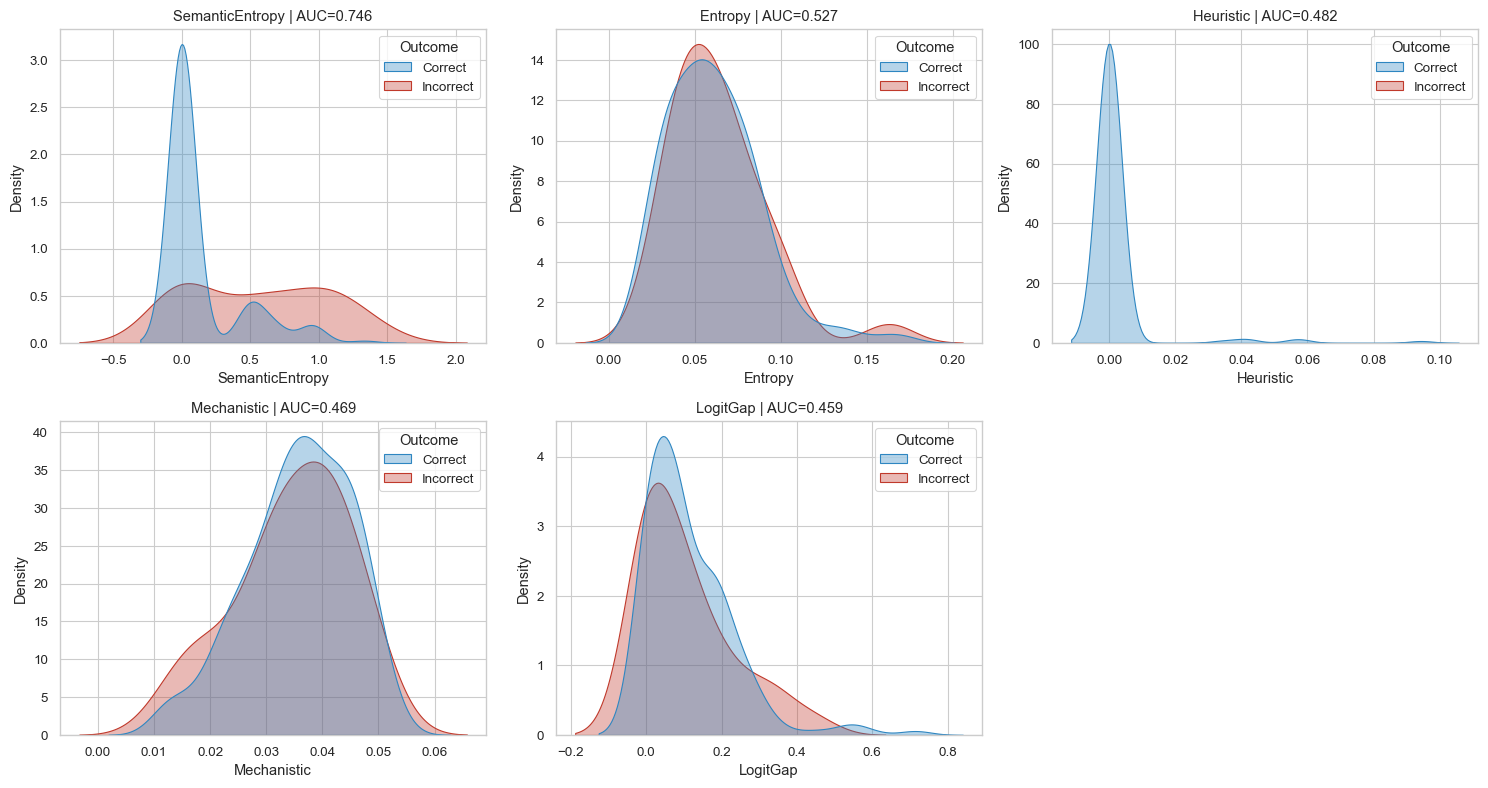

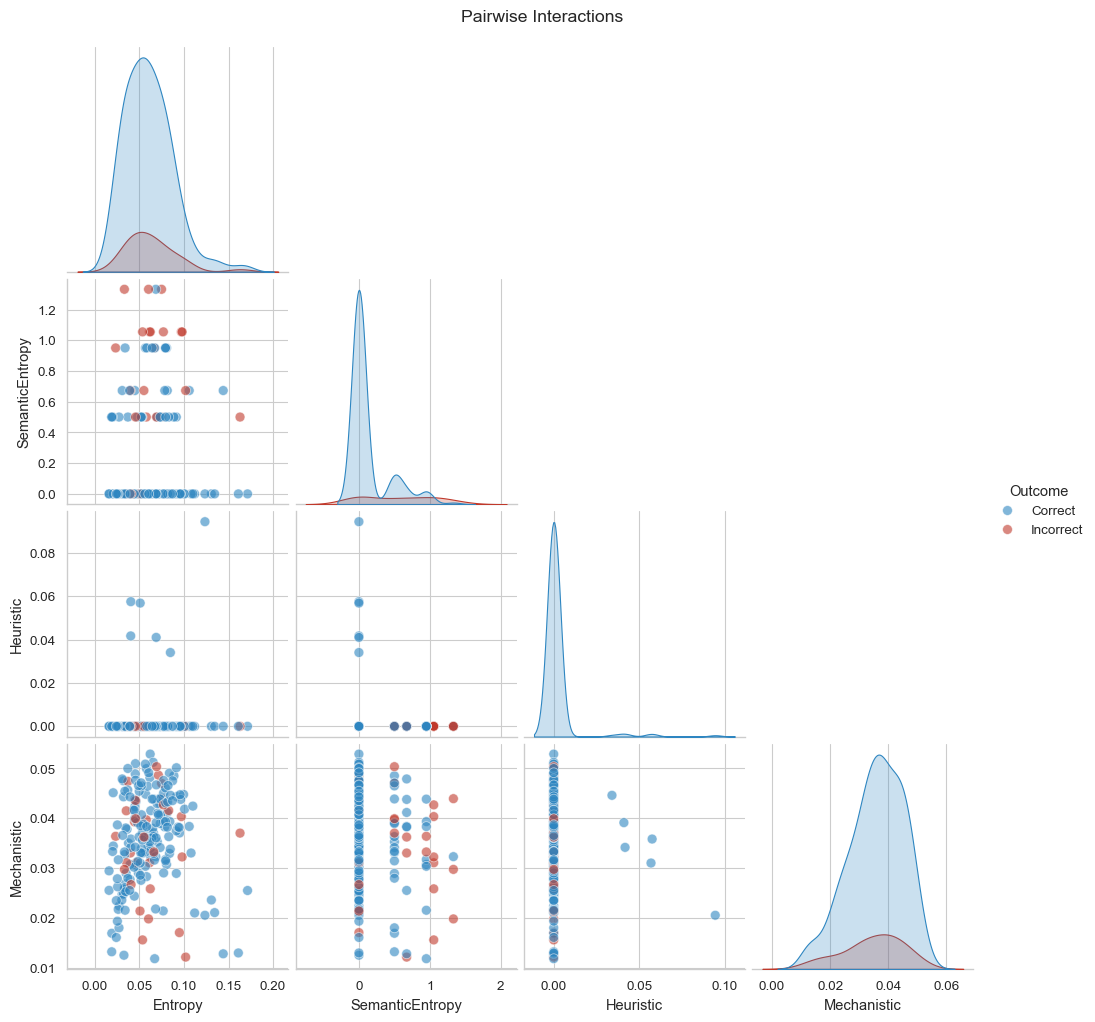

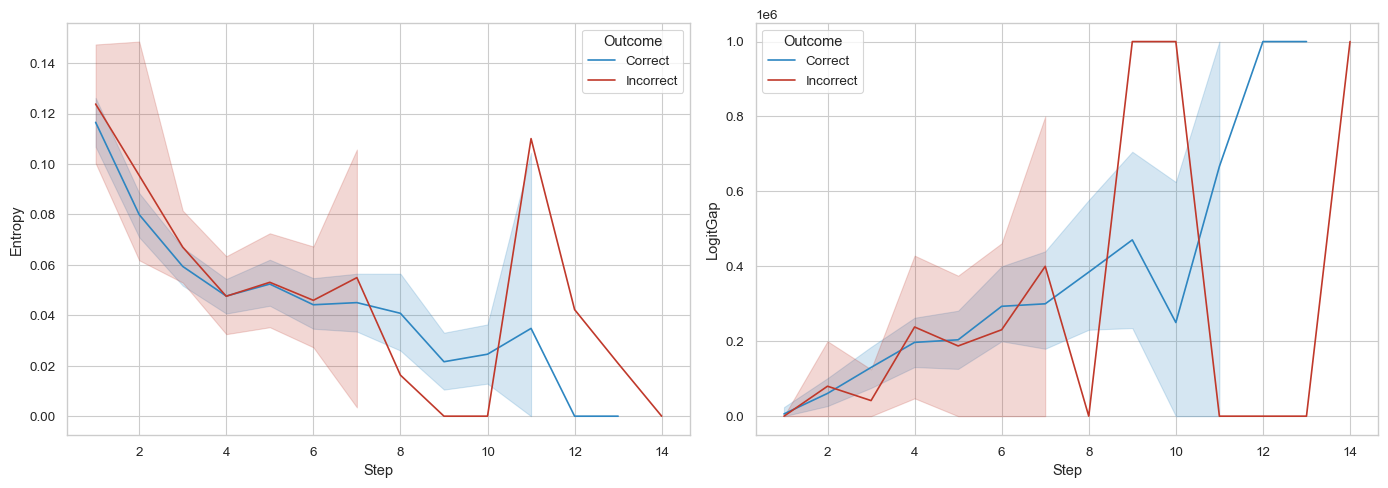

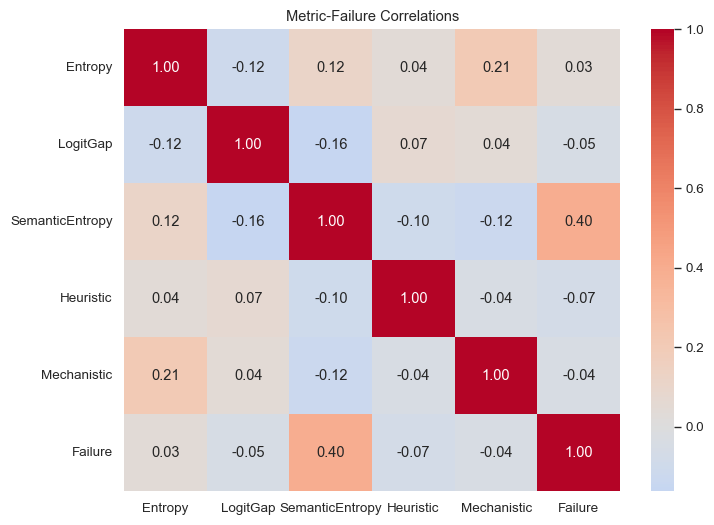


TOP PAIRS (ABSOLUTE)
Pair #1: (SemanticEntropy, LogitGap) | Combined AUC=0.766 (Lift: +0.020)
Pair #2: (SemanticEntropy, Heuristic) | Combined AUC=0.753 (Lift: +0.006)
Pair #3: (SemanticEntropy, Mechanistic) | Combined AUC=0.744 (Lift: +-0.002)

>>> ANALYZING: RL Model (Fine-Tuned) <<<

Data Shape: (200, 16) | Failures: 18
SINGLE METRIC ANALYSIS
Metric: SemanticEntropy (AUC=0.598)
  True Positives:
    • [id=63] Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
      Gold: 59 | Pred: 18
      Correct: 0 | SemanticEntropy=1.332

------------------------------------------------------------
Metric: Heuristic (AUC=0.540)
  True Positives:
    • [id=135] Q: Kennedy's house is 600 square feet larger than 4 times Benedict's house. If Kennedy's house is 10000...
      Gold: 2350 | Pred: 0
      Correct: 0 | Heuristic=0.051

------------------------------------------------------------
Metric: Mechanistic (AUC=0.486)
  True Positives:
   

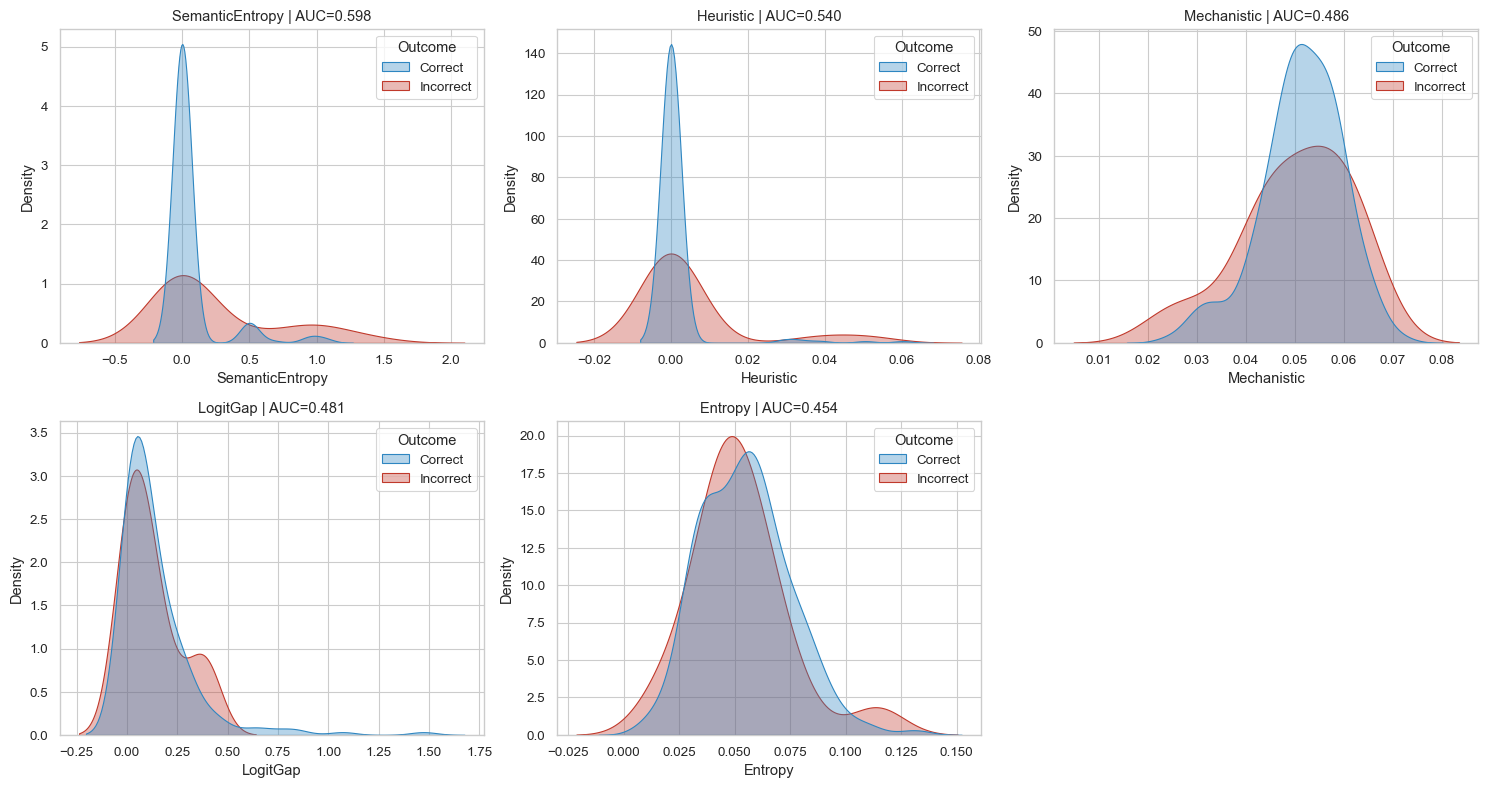

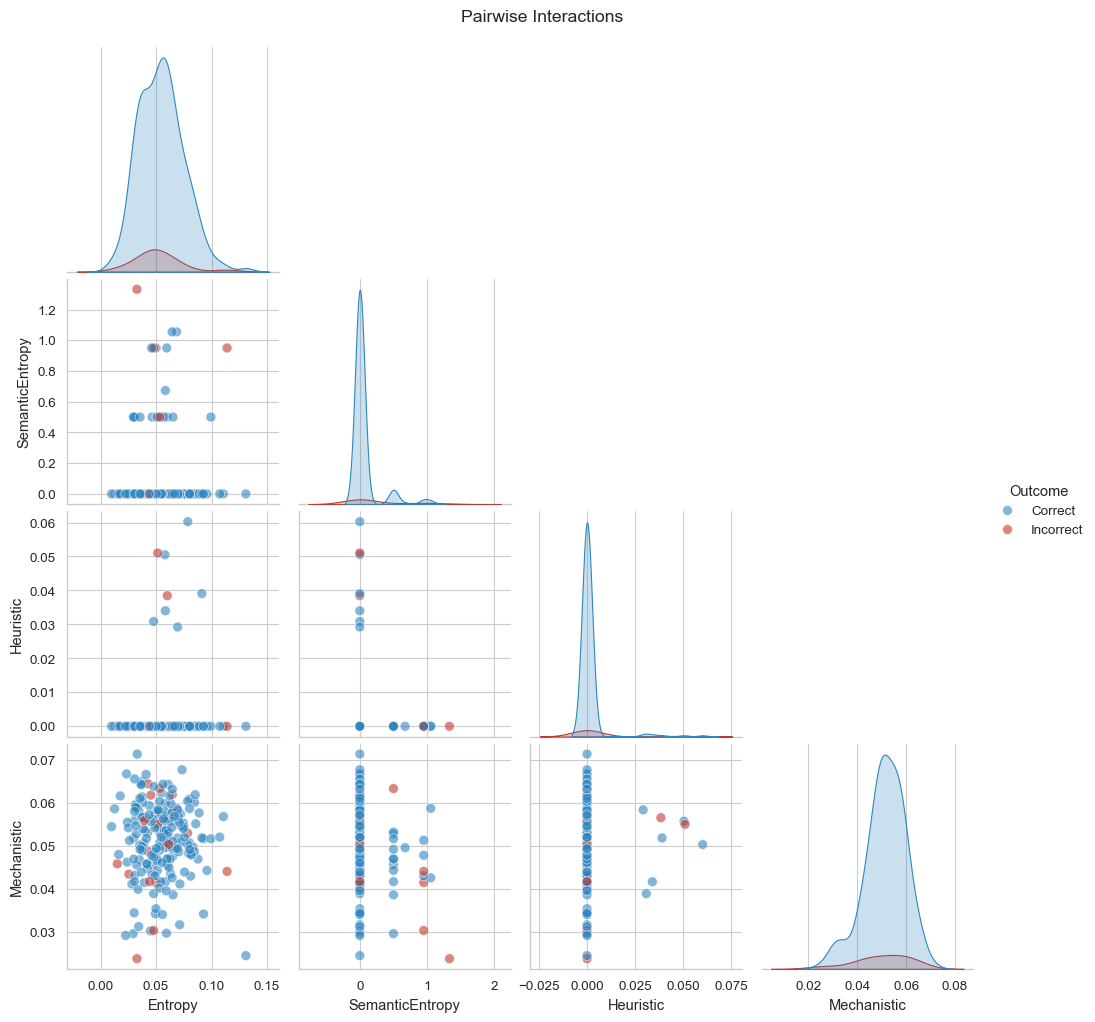

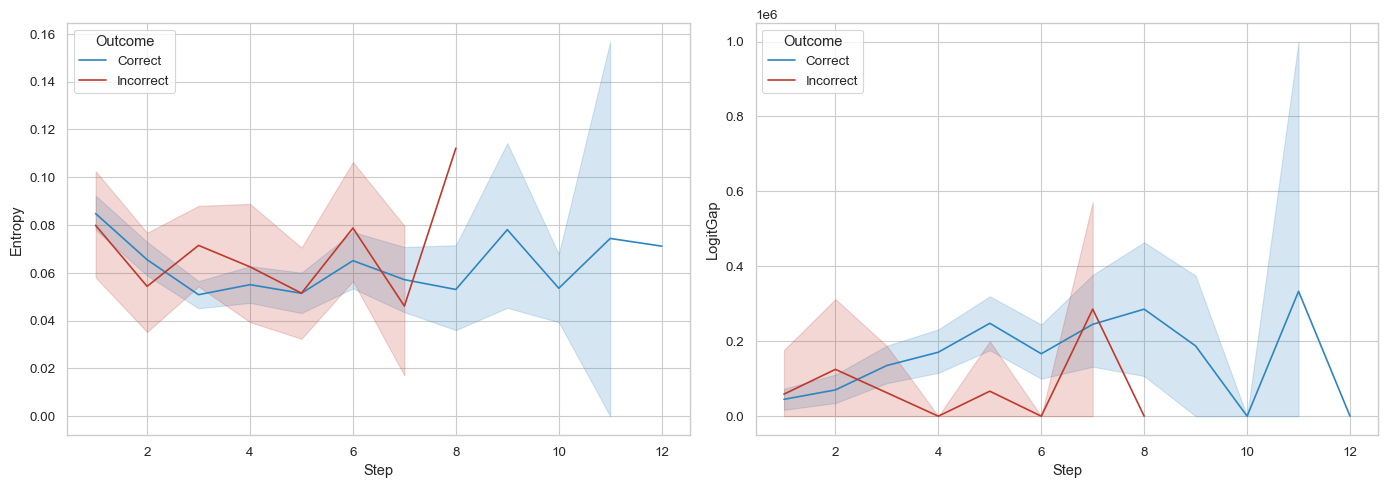

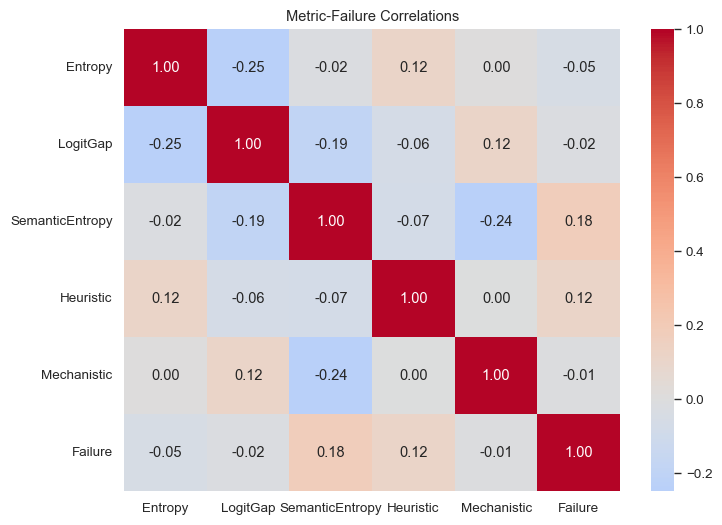


TOP PAIRS (ABSOLUTE)
Pair #1: (SemanticEntropy, Heuristic) | Combined AUC=0.642 (Lift: +0.043)
Pair #2: (SemanticEntropy, Mechanistic) | Combined AUC=0.637 (Lift: +0.039)
Pair #3: (SemanticEntropy, Entropy) | Combined AUC=0.636 (Lift: +0.037)


In [2]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from itertools import combinations
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set plotting style from the notebook
sns.set_context("paper", font_scale=1.1)
sns.set_style("whitegrid")
palette = {"Correct": "#2E86C1", "Incorrect": "#C0392B"}

# Point to the 'db' directory
DB_PATH = "db/results.sqlite"

def load_data_from_sqlite(model_label):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    
    # Get Exp ID
    cursor.execute("SELECT experiment_id FROM Experiments ORDER BY run_date DESC LIMIT 1")
    exp_id = cursor.fetchone()[0]
    
    # Get Model ID for the label (SFT or RL)
    # We assume training_method corresponds to the label for this demo
    # model_label should be 'SFT' or 'RL'
    query_model = f"""
    SELECT model_id FROM Models 
    WHERE training_method = '{model_label}'
    """
    res = cursor.execute(query_model).fetchone()
    if not res:
        conn.close()
        return None, None
    model_id = res[0]
    
    # 1. Fetch Summary DF
    query_df = f"""
    SELECT 
        result_id,
        is_correct,
        uq_avg_entropy as avg_entropy,
        uq_min_logit_gap as min_logit_gap,
        uq_semantic_entropy as semantic_entropy,
        uq_heuristic_score as heuristic_score,
        uq_mech_score as mechanistic_score,
        question_text as question,
        gold_answer,
        predicted_answer
    FROM Results
    WHERE experiment_id = {exp_id} AND model_id = {model_id}
    """
    df = pd.read_sql_query(query_df, conn)
    
    # 2. Fetch Full Trace Data (Stage_Results)
    full = []
    for _, row in df.iterrows():
        r_id = row['result_id']
        is_cor = row['is_correct']
        
        query_stages = f"""
        SELECT stage_name, uq_avg_entropy, uq_min_logit_gap
        FROM Stage_Results
        WHERE result_id = {r_id}
        ORDER BY stage_index
        """
        stages = pd.read_sql_query(query_stages, conn)
        
        stage_vectors = []
        for _, st in stages.iterrows():
            stage_vectors.append({
                "stage_name": st['stage_name'],
                "avg_entropy": st['uq_avg_entropy'],
                "min_logit_gap": st['uq_min_logit_gap']
            })
            
        full.append({
            "is_correct": is_cor,
            "stage_vectors": stage_vectors
        })
        
    conn.close()
    return df, full

# --- Analysis Functions Adapted from Notebook ---

def preprocess(df):
    metric_map = [
        ("avg_entropy",          "Entropy"),
        ("min_logit_gap",        "LogitGap"),
        ("semantic_entropy",     "SemanticEntropy"),
        ("heuristic_score",      "Heuristic"),
        ("mechanistic_score",    "Mechanistic"),
    ]
    df = df.copy()
    df["Outcome"] = df["is_correct"].map({1:"Correct", 0:"Incorrect"})
    metrics = []
    for col,new in metric_map:
        if col in df.columns:
            df[new] = df[col]
            metrics.append(new)
    return df, metrics

def get_extreme_examples(df, probs, y_true, n=2):
    if len(probs) != len(y_true): return {} # Safety
    sorted_indices = np.argsort(probs)
    high_prob = sorted_indices[::-1] 
    low_prob = sorted_indices        
    
    # Map indices back to df index
    # y_true is series, probs is array
    # We need integer locations
    
    tp = []
    fp = []
    fn = []
    tn = []
    
    y_vals = y_true.values
    df_indices = df.index.values
    
    for idx_int in high_prob:
        real_idx = df_indices[idx_int]
        if y_vals[idx_int] == 1:
            if len(tp) < n: tp.append(real_idx)
        else:
            if len(fp) < n: fp.append(real_idx)
            
    for idx_int in low_prob:
        real_idx = df_indices[idx_int]
        if y_vals[idx_int] == 1:
            if len(fn) < n: fn.append(real_idx)
        else:
            if len(tn) < n: tn.append(real_idx)

    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn}

def print_full_details(df, indices, label, metric_col=None):
    if len(indices) == 0: return
    print(f"  {label}:")
    for idx in indices:
        if idx not in df.index: continue
        r = df.loc[idx]
        txt = r['question'][:100] + "..." if len(r['question']) > 100 else r['question']
        m_val = f" | {metric_col}={r[metric_col]:.3f}" if metric_col else ""
        print(f"    • [id={idx}] Q: {txt}")
        print(f"      Gold: {r['gold_answer']} | Pred: {r['predicted_answer']}")
        print(f"      Correct: {r['is_correct']}{m_val}")
        print()

def plot_distributions(df, metrics):
    y_fail = 1 - df["is_correct"]
    
    # Check if we can calculate AUC
    if y_fail.nunique() < 2:
        print("  [Info] Skipping AUC/LogisticRegression (Only one class present)")
        # Just plot KDEs
        cols = 3
        rows = (len(metrics) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
        if rows*cols > 1: axes = axes.flatten()
        else: axes = [axes]
        
        for i, m in enumerate(metrics):
            ax = axes[i]
            # Handle singular data better
            try:
                sns.kdeplot(data=df, x=m, hue="Outcome", palette=palette, fill=True, alpha=0.35, common_norm=False, ax=ax, warn_singular=False)
            except:
                sns.histplot(data=df, x=m, hue="Outcome", palette=palette, ax=ax, kde=False)
            ax.set_title(f"{m}")
        
        for j in range(i+1, len(axes)): fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()
        return

    # Normal flow
    auc_map = {m: roc_auc_score(y_fail, df[m]) for m in metrics if not df[m].isnull().all()}
    top_metrics = sorted(auc_map.items(), key=lambda x: x[1], reverse=True)[:5]

    cols = 3
    rows = (len(top_metrics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
    if rows*cols > 1: axes = axes.flatten()
    else: axes = [axes]

    print("="*60 + "\nSINGLE METRIC ANALYSIS\n" + "="*60)
    for i, (m, auc) in enumerate(top_metrics):
        ax = axes[i]
        try:
            sns.kdeplot(data=df, x=m, hue="Outcome", palette=palette, fill=True, alpha=0.35, common_norm=False, ax=ax, warn_singular=False)
        except:
            pass # Skip plot if KDE fails
        ax.set_title(f"{m} | AUC={auc:.3f}")

        # Logic for examples
        X = df[[m]].fillna(df[m].mean()).values
        if len(X) > 0:
            lr = LogisticRegression().fit(X, y_fail)
            probs = lr.predict_proba(X)[:, 1]
            ex = get_extreme_examples(df, probs, y_fail, n=1) # Reduced n for small data
            print(f"Metric: {m} (AUC={auc:.3f})")
            print_full_details(df, ex["TP"], "True Positives", m)
            print("-" * 60)

    for j in range(i+1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

def plot_pairwise(df, metrics):
    sel = [m for m in ["Entropy", "SemanticEntropy", "Heuristic", "Mechanistic"] if m in metrics]
    if len(sel) < 2: return
    
    # Check if we have both outcomes for hue
    if df["Outcome"].nunique() < 2:
        g = sns.pairplot(df, vars=sel, corner=True, plot_kws={'alpha':0.6, 's':50})
    else:
        g = sns.pairplot(df, vars=sel, hue="Outcome", palette=palette, corner=True, plot_kws={'alpha':0.6, 's':50})
    g.fig.suptitle("Pairwise Interactions", y=1.02)
    plt.show()

def plot_trace(full):
    steps = []
    for item in full:
        outcome = "Correct" if item.get("is_correct") else "Incorrect"
        for i, st in enumerate(item.get("stage_vectors", [])):
            if "Full" in st.get("stage_name", ""): continue
            steps.append({
                "Step": i+1, "Outcome": outcome,
                "Entropy": st.get("avg_entropy", 0), "LogitGap": st.get("min_logit_gap", 0)
            })
    if not steps: return
    df_tr = pd.DataFrame(steps)
    
    # Check if we have enough data to plot
    if len(df_tr) == 0: return

    fig, ax = plt.subplots(1,2,figsize=(14,5))
    
    # Handle single outcome case
    h_kws = {}
    if df_tr["Outcome"].nunique() > 1:
        h_kws = {"hue": "Outcome", "palette": palette}
        
    sns.lineplot(data=df_tr, x="Step", y="Entropy", ax=ax[0], **h_kws)
    sns.lineplot(data=df_tr, x="Step", y="LogitGap", ax=ax[1], **h_kws)
    plt.tight_layout()
    plt.show()

def plot_corrs(df, metrics):
    df["Failure"] = 1 - df["is_correct"]
    plt.figure(figsize=(8,6))
    # Spearman corr requires variation
    try:
        corr = df[metrics+["Failure"]].corr("spearman")
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title("Metric-Failure Correlations")
        plt.show()
    except:
        print("  [Info] Skipping Correlation Plot (Insufficient variance)")

def analyze_pairs(df, metrics, top_k=3):
    y = 1 - df["is_correct"]
    if y.nunique() < 2: return

    single_aucs = {m: roc_auc_score(y, df[m]) for m in metrics if not df[m].isnull().all()}
    
    pairs = []
    for m1, m2 in combinations(metrics, 2):
        a1, a2 = single_aucs[m1], single_aucs[m2]
        if a2 > a1: m1, m2, a1, a2 = m2, m1, a2, a1
        
        X = df[[m1, m2]].fillna(0).values
        model = make_pipeline(StandardScaler(), LogisticRegression())
        try:
            model.fit(X, y)
            probs = model.predict_proba(X)[:, 1]
            auc_comb = roc_auc_score(y, probs)
            pairs.append({
                "m1": m1, "m2": m2, "a1": a1, "a2": a2, "auc": auc_comb, 
                "lift": auc_comb - a1
            })
        except: pass

    top_abs = sorted(pairs, key=lambda x: x['auc'], reverse=True)[:top_k]
    
    if not top_abs: return

    print(f"\n{'='*60}\nTOP PAIRS (ABSOLUTE)\n{'='*60}")
    for i, p in enumerate(top_abs, 1):
        print(f"Pair #{i}: ({p['m1']}, {p['m2']}) | Combined AUC={p['auc']:.3f} (Lift: +{p['lift']:.3f})")

def run_analysis(model_name, label):
    print(f"\n>>> ANALYZING: {label} <<<\n")
    df, full = load_data_from_sqlite(model_name)
    if df is None or df.empty:
        print("No data found.")
        return

    df_proc, metrics = preprocess(df)
    
    print(f"Data Shape: {df_proc.shape} | Failures: { (1-df_proc['is_correct']).sum() }")
    
    plot_distributions(df_proc, metrics)
    plot_pairwise(df_proc, metrics)
    plot_trace(full)
    plot_corrs(df_proc, metrics)
    analyze_pairs(df_proc, metrics)

# Run for SFT and RL
run_analysis('SFT', 'SFT Model (Baseline)')
run_analysis('RL', 'RL Model (Fine-Tuned)')

Loaded Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)
Compared 200 questions present in both SFT and RL runs.


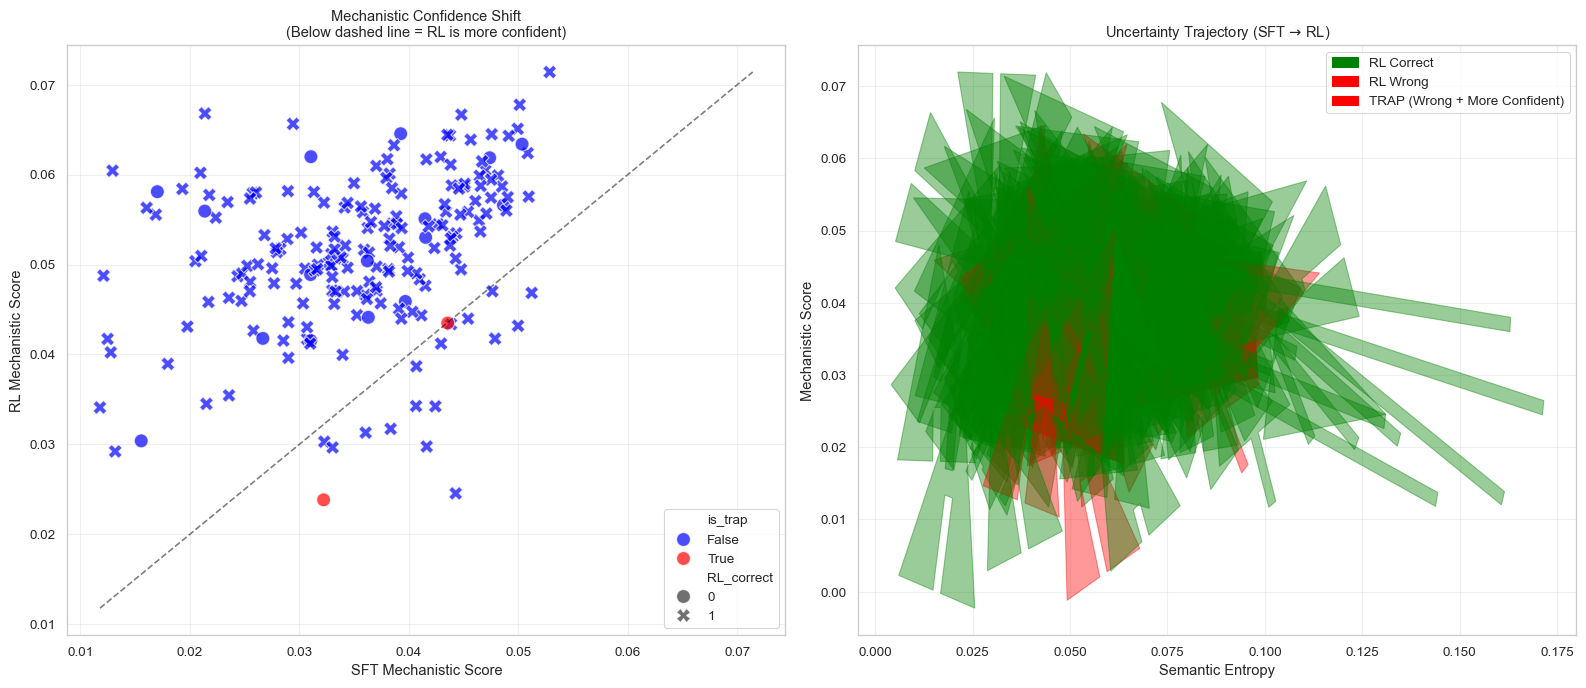


FORENSIC TRAP ANALYSIS
Found 2 Overconfidence Traps (RL Wrong but more confident than SFT):
Q63: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 sit...
  Gold: 59
  SFT Answer (Wrong): 0... [Mech: 0.0322]
  RL  Answer (Wrong):   18... [Mech: 0.0238]
  >> Confidence Increased by: 0.0084 (Mechanistic Score Drop)
--------------------------------------------------
Q115: There are some jelly beans in a jar. Three fourths of the jelly beans are red, a...
  Gold: 4000
  SFT Answer (Wrong): 0... [Mech: 0.0436]
  RL  Answer (Wrong):   0... [Mech: 0.0435]
  >> Confidence Increased by: 0.0001 (Mechanistic Score Drop)
--------------------------------------------------


In [3]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import numpy as np

# --- Configuration ---
DB_PATH = "db/results.sqlite"

def analyze_experiment():
    if not os.path.exists(DB_PATH):
        print(f"Error: Database not found at {DB_PATH}")
        return

    conn = sqlite3.connect(DB_PATH)

    try:
        # 1. Get Latest Experiment
        exp_query = "SELECT experiment_id, experiment_name, run_date FROM Experiments ORDER BY run_date DESC LIMIT 1"
        exp_df = pd.read_sql_query(exp_query, conn)
        
        if exp_df.empty:
            print("No experiments found in DB.")
            return

        exp_id = exp_df.iloc[0]['experiment_id']
        exp_name = exp_df.iloc[0]['experiment_name']
        print(f"Loaded Experiment: {exp_name} (ID: {exp_id})")

        # 2. Fetch Results (SFT and RL)
        # Note: Adjust column names (uq_mech_score vs mechanistic_score) based on your specific DB schema version
        data_query = f"""
        SELECT 
            r.question_id_external as q_id,
            r.question_text,
            r.gold_answer,
            r.predicted_answer,
            r.is_correct,
            r.uq_mech_score, 
            r.uq_avg_entropy,
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df_raw = pd.read_sql_query(data_query, conn)
        
        if df_raw.empty:
            print("No results found for this experiment.")
            return

        # 3. Pivot Data: Create a single row per question with SFT and RL columns
        df_sft = df_raw[df_raw['training_method'] == 'SFT'].copy()
        df_rl  = df_raw[df_raw['training_method'] == 'RL'].copy()

        cols = {'predicted_answer': 'ans', 'is_correct': 'correct', 'uq_mech_score': 'mech', 'uq_avg_entropy': 'ent'}
        
        # Rename SFT columns
        df_sft = df_sft.rename(columns={k: f"SFT_{v}" for k, v in cols.items()})
        # Rename RL columns
        df_rl = df_rl.rename(columns={k: f"RL_{v}" for k, v in cols.items()})

        # Merge
        df = pd.merge(
            df_sft[['q_id', 'question_text', 'gold_answer', 'SFT_ans', 'SFT_correct', 'SFT_mech', 'SFT_ent']],
            df_rl[['q_id', 'RL_ans', 'RL_correct', 'RL_mech', 'RL_ent']],
            on='q_id', how='inner'
        )

        print(f"Compared {len(df)} questions present in both SFT and RL runs.")

        # 4. Calculate Deltas
        # Negative Delta = RL is MORE confident (Score went down)
        df['delta_mech'] = df['RL_mech'] - df['SFT_mech']
        df['delta_ent'] = df['RL_ent'] - df['SFT_ent']
        
        # Identify "Traps" (RL is Wrong, but RL Uncertainty < SFT Uncertainty)
        # i.e., RL became more confident but failed.
        df['is_trap'] = (~df['RL_correct'].astype(bool)) & (df['delta_mech'] < 0)

        # --- VISUALIZATION ---
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # PLOT 1: Mechanistic Shift (SFT vs RL)
        # X-axis: SFT Score, Y-axis: RL Score
        # Points below the diagonal line mean RL is MORE confident (lower score)
        sns.scatterplot(
            data=df, 
            x='SFT_mech', y='RL_mech', 
            hue='is_trap', style='RL_correct',
            palette={True: 'red', False: 'blue'}, # Red for Traps
            s=100, alpha=0.7, ax=axes[0]
        )
        
        # Add diagonal line (No Change line)
        min_val = min(df['SFT_mech'].min(), df['RL_mech'].min())
        max_val = max(df['SFT_mech'].max(), df['RL_mech'].max())
        axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label="No Change")
        
        axes[0].set_title(f"Mechanistic Confidence Shift\n(Below dashed line = RL is more confident)")
        axes[0].set_xlabel("SFT Mechanistic Score")
        axes[0].set_ylabel("RL Mechanistic Score")
        axes[0].grid(True, alpha=0.3)

        # PLOT 2: Vector Field (Movement in Uncertainty Space)
        # Shows how questions move in (Entropy, Mechanistic) space from SFT -> RL
        axes[1].set_title("Uncertainty Trajectory (SFT $\u2192$ RL)")
        axes[1].set_xlabel("Semantic Entropy")
        axes[1].set_ylabel("Mechanistic Score")
        
        for _, row in df.iterrows():
            # Color logic: Red if it ended up Wrong, Green if Correct
            color = 'green' if row['RL_correct'] else 'red'
            # If it's a "Trap" (Wrong + High Confidence), make it bright red and thicker
            width = 0.005 if row['is_trap'] else 0.002
            alpha = 0.9 if row['is_trap'] else 0.4
            
            axes[1].arrow(
                row['SFT_ent'], row['SFT_mech'],      # Start (SFT)
                row['delta_ent'], row['delta_mech'],  # Change (Delta)
                color=color, alpha=alpha, width=width,
                head_width=0.02, length_includes_head=True
            )

        # Dummy points for legend
        legend_patches = [
            mpatches.Patch(color='green', label='RL Correct'),
            mpatches.Patch(color='red', label='RL Wrong'),
            mpatches.Patch(color='red', alpha=1.0, label='TRAP (Wrong + More Confident)'),
        ]
        axes[1].legend(handles=legend_patches)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # --- TEXT REPORT ---
        print(f"\n{'='*80}\nFORENSIC TRAP ANALYSIS\n{'='*80}")
        traps = df[df['is_trap']]
        
        if traps.empty:
            print("No overconfidence traps detected.")
        else:
            print(f"Found {len(traps)} Overconfidence Traps (RL Wrong but more confident than SFT):")
            for _, row in traps.iterrows():
                print(f"Q{row['q_id']}: {row['question_text'][:80]}...")
                print(f"  Gold: {row['gold_answer']}")
                print(f"  SFT Answer ({'Correct' if row['SFT_correct'] else 'Wrong'}): {str(row['SFT_ans'])[:20]}... [Mech: {row['SFT_mech']:.4f}]")
                print(f"  RL  Answer (Wrong):   {str(row['RL_ans'])[:20]}... [Mech: {row['RL_mech']:.4f}]")
                print(f"  >> Confidence Increased by: {abs(row['delta_mech']):.4f} (Mechanistic Score Drop)")
                print("-" * 50)

    except Exception as e:
        print(f"Analysis Error: {e}")
        import traceback
        traceback.print_exc()
    finally:
        conn.close()

if __name__ == "__main__":
    analyze_experiment()